<a href="https://colab.research.google.com/github/sarah2005-cyber/auspex/blob/main/Best_AUC_full_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SCOPE AND ASSUMPTIONS**

## **1. Scope of the study**

This research proposes AUSPEX, a lightweight, forensically inspired deep learning framework for detecting audio steganography in compressed speech signals under low embedding rate conditions, with integrated post-hoc explainability mechanisms.

The scope of the implementation is explicitly constrained as follows:

### **1.1 Audio Domain Scope**



*   The study focuses exclusively on:

    *   Compressed speech audio
    *   Specifically G.729A codec streams
*   The analysis operates at:

    *   Bitstream level representations
    *   Not raw waveform or spectrogram-based pipelines


*   Input samples are:
    *   Short-duration segments (~1 second)
    *   Fixed-size representations derived from encoded frames









###**1.2 Steganographic Methods Covered**

The framework is evaluated only on:


*   Codeword Neighbour Variation (CNV)
*   Pitch Modification Substitution (PMS)

These represent:

*   Two distinct embedding strategies within compressed speech


The study does not claim generalization to:


*   Other steganographic algorithms
*   Adaptive or adversarial embedding methods
*   Unknown or unseen hiding techniques









###**1.3 Embedding Rate Scope (Low-payload focus)**

The central research focus is:

*  Low embedding rate detection

Operationalized as:

*   Training and evaluation across 10%-40% embedding rates

With emphasis on:

*   Performance degradation at lower payloads

*   Detection difficulty under weak embedding signals








###**1.4 Language and Data Scope**

The dataset includes:


*   English speech samples
*   Chinese speech samples

However:


*   Language is not treated as a controlled experimental variable
*   Cross-language generalization is not fully evaluated





###**1.5 Representation Scope**

The framework evaluates multiple input representations:

* Raw binary bitstream matrices
* Multi-channel representations:
  * Raw bits
  * Temporal differences
  * Stability indicators
* Handcrafted codec-aware features:
  * Derived using G.729A parameter structures (DVSF-like features)

Representation design is:

* Codec-aware and domain-specific
* Not intended to generalize to other codecs or modalities

###**1.6 Model Scope**

The proposed model:

* A lightweight CNN-based architecture incorporating:
  * High-pass forensic filters
  * Depthwise separable convolutions
  * Residual connections
  * Attention mechanisms (SE + spatial attention)

Additionally, the study includes:

* Classical baselines:
  * Logistic Regression
  * SVM
  * Random Forest
  * XGBoost
* Deep learning baselines:
  * Simple CNN
  * 1D CNN
* Ablation variants:
  * Without high-pass filters
  * Without multi-channel representation
  * Without attention mechanisms

###**1.7 Explainability Scope (Post-hoc XAI)**

Explainability is incorporated via:

* Post-hoc attribution methods:
  * Integrated Gradients
  * Occlusion-based attribution

Explainability analysis includes:

* Attribution visualization
* Faithfulness testing:
  * Deletion and insertion tests
  * Top-k and bottom-k perturbation analysis
* Stability analysis:
  * Sensitivity to perturbations

Additionally:

* Attributions are interpreted using:
  * Codec-aware bit mapping (G.729A parameter mapping)

###**1.8 Evaluation Scope**

The evaluation includes:

* Standard classification metrics:
  * Accuracy
  * Precision
  * Recall
  * F1-score
  * AUC
* Subgroup analysis:
  * By embedding rate
  * By method (CNV vs PMS)
* Efficiency evaluation:
  * Parameter count
  * Model size
  * Inference latency
* Threshold-based decision analysis:
  * Validation-based threshold selection
  * Fixed threshold application on test data

###**1.9 Experimental Structure Scope**

The study includes:

* Main proposed model evaluation
* Baseline comparisons
* Representation comparisons (partial)
* Architecture ablation studies
* XAI-based forensic analysis

##**2. Assumptions**

The following assumptions are made throughout the study:

###**2.1 Data Assumptions**

* The dataset is assumed to be:
  * Correctly labeled (cover vs stego)
  * Free from systematic annotation errors
* Cover and stego samples are:
  * Unpaired
  * Evaluated against a shared cover distribution
* Metadata provided is:
  * Accurate and consistent across samples

###**2.2 Splitting and Leakage Assumptions**

* Grouped splitting (e.g., by base filename) ensures:
  * No overlap between train, validation, and test sets
* This is assumed to:
  * Prevent data leakage
  * Ensure fair evaluation

###**2.3 Representation Assumptions**

* Bitstream-derived representations:
  * Preserve sufficient information for detecting embedding artifacts
* Multi-channel features:
  * Capture complementary signals (raw + temporal + stability)
* Handcrafted features:
  * Accurately reflect codec parameter behavior

###**2.4 Model Assumptions**

* Lightweight CNN architectures are sufficient to:
  * Capture embedding artifacts at low payloads
* High-pass filters:
  * Enhance subtle embedding signals
* Attention mechanisms:
  * Improve feature discrimination

###**2.5 Thresholding Assumptions**

* Validation-based threshold selection:
  * Generalizes to test data
* Fixed thresholds:
  * Are appropriate for deployment-like scenarios

###**2.6 Explainability Assumptions**

* Attribution methods:
  * Provide meaningful insight into model decisions
* Perturbation-based tests:
  * Reflect explanation faithfulness
* Codec-aware mapping:
  * Enables interpretable forensic reasoning

###**2.7 Efficiency Assumptions**

* Parameter count and latency:
  * Are sufficient proxies for “lightweight” performance
* Hardware variability:
  * Does not significantly alter comparative conclusions

## **3. Out of Scope**

The following are explicitly out of scope for this study:

###**3.1 Generalization**

* Universal audio steganalysis across:

  * Multiple codecs
  * Multiple domains
  * Arbitrary embedding methods

###**3.2 Cross-Domain Evaluation**

* Training on one language and testing on another
* Generalization to unseen distributions

### **3.3 Advanced Model Architectures**

* Siamese or contrastive models
* Transformer-based architectures
* Multi-task learning (payload or method prediction heads)

###**3.4 Extensive Hyperparameter Optimization**

* Full-scale search (e.g., Optuna, Bayesian optimization)

###**3.5 Robustness Benchmarking**

* Extensive corruption testing:

  * Compression artifacts
  * Packet loss
  * Adversarial perturbations

###**3.6 Calibration and Uncertainty Quantification**

* Formal calibration techniques:
  * Temperature scaling
  * Reliability diagrams
  * ECE/Brier score analysis (if not fully implemented)

###**3.7 Ground-Truth Explainability Validation**

* No ground-truth attribution labels exist for:
  * Exact embedding locations in compressed audio

###**3.8 Real-world Deployment**

* No real-time system integration
* No large-scale production testing

###**3.9 Full Statistical Rigor**

* Limited multi-seed experiments
* Limited statistical significance testing across models

## **4. Summary of Scope Positioning**

This study should be interpreted as:

* A focused, codec-aware, lightweight steganalysis framework evaluated on selected embedding methods under controlled conditions, with integrated post-hoc explainability analysis.

It is not:

* A universal steganalysis solution
* A fully generalized system

#**DATASET PREPROCESSING - (Evaluating the audio)**

##**Imports + Paths**

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

cover_path = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/cover"
stego_path = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/stego"

excel_path = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/train_lable.xlsx"

In [ ]:
!find '/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/cover' -type f | wc -l


49992


##**Pair Integrity Check**

In [ ]:
cover_files = sorted(os.listdir(cover_path))
stego_files = sorted(os.listdir(stego_path))

print("Cover count:", len(cover_files))
print("Stego count:", len(stego_files))

cover_set = set(cover_files)
stego_set = set(stego_files)

missing_in_stego = cover_set - stego_set
missing_in_cover = stego_set - cover_set

print("Missing in stego:", len(missing_in_stego))
print("Missing in cover:", len(missing_in_cover))

if len(missing_in_stego) == 0 and len(missing_in_cover) == 0:
    print(" Filenames perfectly aligned.")
else:
    print(" Pair mismatch detected. STOP.")

    # --- SEE THE EXACT FILES ---
    if missing_in_stego:
        print("\nFiles in Cover but missing in Stego (showing up to 10):")
        print(list(missing_in_stego)[:10])

    if missing_in_cover:
        print("\nFiles in Stego but missing in Cover (showing up to 10):")
        print(list(missing_in_cover)[:10])

Cover count: 49992
Stego count: 49992
Missing in stego: 0
Missing in cover: 0
 Filenames perfectly aligned.


##**File size comaprison**

In [ ]:
size_diffs = []

for f in tqdm(cover_files):
    cover_file = os.path.join(cover_path, f)
    stego_file = os.path.join(stego_path, f)

    size_cover = os.path.getsize(cover_file)
    size_stego = os.path.getsize(stego_file)

    size_diffs.append(size_stego - size_cover)

print("Mean size diff:", np.mean(size_diffs))
print("Std size diff:", np.std(size_diffs))

100%|██████████| 49992/49992 [00:50<00:00, 993.76it/s]

Mean size diff: 0.0
Std size diff: 0.0


##**Byte level Analysis**

### **Byte level analysis function**

In [ ]:
def analyze_pair(file_name):
    cover_file = os.path.join(cover_path, file_name)
    stego_file = os.path.join(stego_path, file_name)

    with open(cover_file, 'rb') as f:
        cover_bytes = np.frombuffer(f.read(), dtype=np.uint8)

    with open(stego_file, 'rb') as f:
        stego_bytes = np.frombuffer(f.read(), dtype=np.uint8)

    min_len = min(len(cover_bytes), len(stego_bytes))
    cover_bytes = cover_bytes[:min_len]
    stego_bytes = stego_bytes[:min_len]

    xor = cover_bytes ^ stego_bytes
    changed = np.sum(xor != 0)

    percent_changed = (changed / min_len) * 100

    diff_indices = np.where(xor != 0)[0][:10]

    return {
        "filename": file_name,
        "total_bytes": min_len,
        "changed_bytes": int(changed),
        "percent_changed": percent_changed,
        "first_diff_indices": diff_indices.tolist()
    }

###**Random 100 Pair audit**

In [ ]:
random.seed(42)
sample_files = random.sample(cover_files, 100)

results = []

for f in tqdm(sample_files):
    results.append(analyze_pair(f))

df = pd.DataFrame(results)
df.head()

100%|██████████| 100/100 [02:15<00:00,  1.36s/it]


,filename,total_bytes,changed_bytes,percent_changed,first_diff_indices
0,English142084.g729a,1000,592,59.2,"[6, 7, 8, 9, 12, 13, 14, 15, 16, 17]"
1,Chinese110322.g729a,1000,512,51.2,"[6, 9, 15, 16, 19, 22, 23, 24, 25, 26]"
2,Chinese102278.g729a,1000,681,68.1,"[6, 7, 9, 10, 11, 13, 14, 15, 16, 17]"
3,English182618.g729a,1000,362,36.2,"[6, 19, 21, 22, 23, 24, 25, 26, 29, 33]"
4,Chinese30293.g729a,1000,590,59.0,"[6, 9, 12, 13, 16, 17, 18, 19, 20, 21]"


###**Distribution Analysis**

Mean % changed: 58.77000000000001
Std % changed: 8.732668260588795


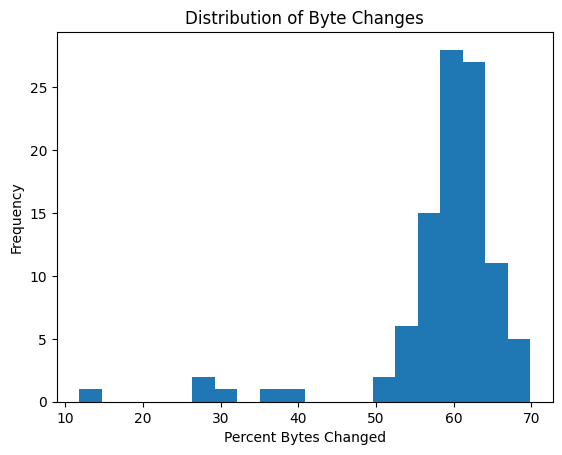

In [ ]:
print("Mean % changed:", df["percent_changed"].mean())
print("Std % changed:", df["percent_changed"].std())

plt.hist(df["percent_changed"], bins=20)
plt.xlabel("Percent Bytes Changed")
plt.ylabel("Frequency")
plt.title("Distribution of Byte Changes")
plt.show()

###**Load Excel Embedding Metadata**

In [ ]:
# Load the specific tab
df_meta = pd.read_excel(excel_path, sheet_name="train_lable_chinese_CNV")

# Force selection of Column 0 (Filename) and Column 2 (0.1, 0.2...)
df_meta = df_meta.iloc[:, [0, 2]].copy()
df_meta.columns = ['Filename_ID', 'Embedding_Rate']

# Clean up: Remove any spaces and add the .g729a extension
df_meta['Filename_ID'] = df_meta['Filename_ID'].astype(str).str.strip() + ".g729a"

print(df_meta.head())

           Filename_ID  Embedding_Rate
0    Chinese1000.g729a             0.1
1  Chinese100003.g729a             0.1
2  Chinese100004.g729a             0.1
3  Chinese100020.g729a             0.1
4  Chinese100032.g729a             0.1


In [ ]:
import pandas as pd

# Initialize a list to hold dataframes from each tab
all_tabs = []

xls = pd.ExcelFile(excel_path)

for sheet in xls.sheet_names:
    # Load the current sheet
    temp_df = pd.read_excel(excel_path, sheet_name=sheet)

    # Grab column 0 (Filename) and column 2 (Embedding Rate)
    temp_df = temp_df.iloc[:, [0, 2]].copy()
    temp_df.columns = ['Filename_ID', 'Embedding_Rate']

    # Add a column to track which category/tab the data came from
    temp_df['Category'] = sheet

    # Clean the Filename_ID: remove spaces, lowercase, and add extension
    temp_df['Filename_ID'] = temp_df['Filename_ID'].astype(str).str.strip().str.lower() + ".g729a"

    all_tabs.append(temp_df)

# Stack all tabs into one master metadata dataframe
df_meta_all = pd.concat(all_tabs, ignore_index=True)

# Remove any empty rows that might have existed in Excel
df_meta_all = df_meta_all.dropna(subset=['Filename_ID'])

print(f"Total metadata records loaded across {len(xls.sheet_names)} tabs: {len(df_meta_all)}")

Total metadata records loaded across 4 tabs: 382296


In [ ]:
# Create a clean matching key in analysis dataframe
df['filename_match_key'] = df['filename'].astype(str).str.strip().str.lower()

# Merge with the consolidated metadata
merged = df.merge(df_meta_all, left_on="filename_match_key", right_on="Filename_ID", how="left")

# Cleanup, Drop the temporary matching columns
merged = merged.drop(columns=['filename_match_key', 'Filename_ID'])

# Check results
missing = merged["Embedding_Rate"].isna().sum()
if missing == 0:
    print(" Success! All files matched across all tabs.")
else:
    print(f" {missing} files still have no metadata. They might be missing from the Excel entirely.")

merged.head()

 Success! All files matched across all tabs.


,filename,total_bytes,changed_bytes,percent_changed,first_diff_indices,Embedding_Rate,Category
0,English142084.g729a,1000,592,59.2,"[6, 7, 8, 9, 12, 13, 14, 15, 16, 17]",0.1,train_lable_english_PMS
1,Chinese110322.g729a,1000,512,51.2,"[6, 9, 15, 16, 19, 22, 23, 24, 25, 26]",0.1,train_lable_chinese_CNV
2,Chinese102278.g729a,1000,681,68.1,"[6, 7, 9, 10, 11, 13, 14, 15, 16, 17]",0.2,train_lable_chinese_CNV
3,English182618.g729a,1000,362,36.2,"[6, 19, 21, 22, 23, 24, 25, 26, 29, 33]",0.1,train_lable_english_CNV
4,Chinese30293.g729a,1000,590,59.0,"[6, 9, 12, 13, 16, 17, 18, 19, 20, 21]",0.1,train_lable_chinese_CNV


###**Embedding rate consistency**

In [ ]:
# Double-check the column names in merged dataframe
print("Columns in merged:", merged.columns.tolist())

# Use the correct column name from merge (e.g., 'Embedding_Rate')
grouped = merged.groupby("Embedding_Rate")["percent_changed"].agg(["mean", "std", "count"])

print("\n--- Steganography Impact Analysis ---")
print(grouped)

Columns in merged: ['filename', 'total_bytes', 'changed_bytes', 'percent_changed', 'first_diff_indices', 'Embedding_Rate', 'Category']

--- Steganography Impact Analysis ---
                     mean        std  count
Embedding_Rate                             
0.1             57.840000   9.015034     70
0.2             62.133333   3.845777      9
0.3             58.269231  10.475558     13
0.4             63.937500   4.269472      8


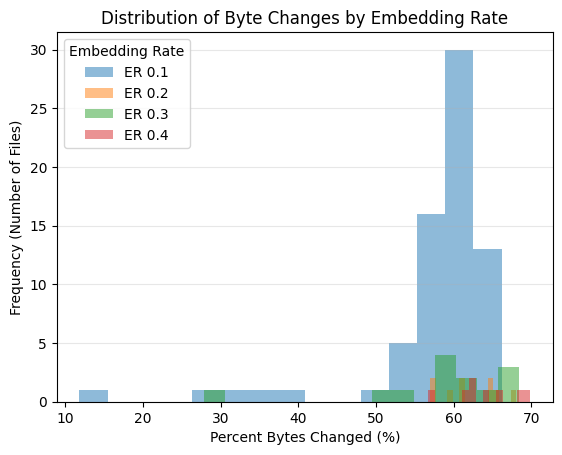

In [ ]:
import matplotlib.pyplot as plt

# Clear any previous plots
plt.clf()

# Get the unique rates available in your data
available_rates = sorted(merged["Embedding_Rate"].dropna().unique())

for rate in available_rates:
    # Filter for the specific rate
    subset = merged[merged["Embedding_Rate"] == rate]

    # Plot the histogram
    plt.hist(subset["percent_changed"],
             bins=15,
             alpha=0.5,
             label=f"ER {rate}")

plt.legend(title="Embedding Rate")
plt.xlabel("Percent Bytes Changed (%)")
plt.ylabel("Frequency (Number of Files)")
plt.title("Distribution of Byte Changes by Embedding Rate")
plt.grid(axis='y', alpha=0.3)

# Save the plot
plt.savefig("byte_change_distribution.png")

###**CNV vs PMS comparison**

In [ ]:
merged["Method"] = "CNV"  # or PMS per sheet

In [ ]:
method_group = merged.groupby("Method")["percent_changed"].agg(["mean","std"])
print(method_group)

         mean       std
Method                 
CNV     58.77  8.732668


##**Frame level Clustering**

Total files after filtering missing ones: 40


  2%|▎         | 1/40 [00:02<01:41,  2.61s/it]

File: English136526.g729a, Frame changes: [np.int64(2), np.int64(7), np.int64(6), np.int64(4), np.int64(6), np.int64(7), np.int64(6), np.int64(7), np.int64(6), np.int64(8), np.int64(7), np.int64(6), np.int64(6), np.int64(7), np.int64(7), np.int64(7), np.int64(7), np.int64(6), np.int64(6), np.int64(7), np.int64(6), np.int64(6), np.int64(7), np.int64(6), np.int64(6), np.int64(7), np.int64(2), np.int64(4), np.int64(7), np.int64(7), np.int64(5), np.int64(6), np.int64(6), np.int64(8), np.int64(5), np.int64(5), np.int64(6), np.int64(3), np.int64(5), np.int64(6), np.int64(8), np.int64(5), np.int64(6), np.int64(5), np.int64(3), np.int64(4), np.int64(0), np.int64(4), np.int64(6), np.int64(3), np.int64(6), np.int64(7), np.int64(4), np.int64(6), np.int64(6), np.int64(7), np.int64(7), np.int64(8), np.int64(7), np.int64(7), np.int64(8), np.int64(6), np.int64(6), np.int64(6), np.int64(2), np.int64(8), np.int64(5), np.int64(5), np.int64(3), np.int64(2), np.int64(3), np.int64(0), np.int64(0), np.int64

  5%|▌         | 2/40 [00:04<01:19,  2.10s/it]

File: Chinese121562.g729a, Frame changes: [np.int64(2), np.int64(5), np.int64(6), np.int64(7), np.int64(5), np.int64(8), np.int64(7), np.int64(8), np.int64(5), np.int64(5), np.int64(5), np.int64(4), np.int64(7), np.int64(8), np.int64(6), np.int64(8), np.int64(5), np.int64(4), np.int64(8), np.int64(8), np.int64(4), np.int64(7), np.int64(7), np.int64(6), np.int64(7), np.int64(4), np.int64(6), np.int64(7), np.int64(6), np.int64(6), np.int64(5), np.int64(8), np.int64(7), np.int64(6), np.int64(7), np.int64(3), np.int64(7), np.int64(5), np.int64(4), np.int64(3), np.int64(6), np.int64(5), np.int64(4), np.int64(3), np.int64(7), np.int64(6), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(6), np.int64(7), np.int64(7), np.int64(6), np.int64(5), np.int64(5), np.int64(2), np.int64(5), np.int64(7), np.int64(6), np.int64(5), np.int64(5), np.int64(3), np.int64(2), np.int64(3), np.int64(6), np.int64(5), np.int64(7), np.int64(1), np.int64(0), np.int64(2), np.int64(0), np.int64(0), np.int64

...

File: English116291.g729a, Frame changes: [np.int64(1), np.int64(2), np.int64(2), np.int64(6), np.int64(8), np.int64(8), np.int64(5), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(8), np.int64(7), np.int64(7), np.int64(8), np.int64(5), np.int64(7), np.int64(8), np.int64(7), np.int64(6), np.int64(7), np.int64(7), np.int64(6), np.int64(7), np.int64(8), np.int64(7), np.int64(7), np.int64(7), np.int64(4), np.int64(5), np.int64(6), np.int64(5), np.int64(3), np.int64(7), np.int64(6), np.int64(6), np.int64(3), np.int64(6), np.int64(6), np.int64(7), np.int64(6), np.int64(6), np.int64(8), np.int64(6), np.int64(7), np.int64(6), np.int64(8), np.int64(7), np.int64(7), np.int64(6), np.int64(6), np.int64(8), np.int64(7), np.int64(6), np.int64(7), np.int64(7), np.int64(7), np.int64(7), np.int64(7), np.int64(8), np.int64(8), np.int64(6), np.int64(7), np.int64(7), np.int64(6), np.int64(8), np.int64(8), np.int64(8), np.int64(8), np.int64(7), np.int64(7), np.int64(6), np.int64(6), np.int64

 98%|█████████▊| 39/40 [00:57<00:01,  1.31s/it]

File: English118497.g729a, Frame changes: [np.int64(2), np.int64(8), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(3), np.int64(6), np.int64(2), np.int64(7), np.int64(8), np.int64(5), np.int64(6), np.int64(7), np.int64(6), np.int64(3), np.int64(4), np.int64(6), np.int64(3), np.int64(1), np.int64(2), np.int64(5), np.int64(5), np.int64(6), np.int64(7), np.int64(6), np.int64(8), np.int64(4), np.int64(6), np.int64(8), np.int64(7), np.int64(7), np.int64(6), np.int64(8), np.int64(6), np.int64(8), np.int64(7), np.int64(7), np.int64(5), np.int64(5), np.int64(6), np.int64(8), np.int64(4), np.int64(6), np.int64(7), np.int64(7), np.int64(3), np.int64(7), np.int64(5), np.int64(7), np.int64(8), np.int64(8), np.int64(7), np.int64(8), np.int64(7), np.int64(7), np.int64(6), np.int64(6), np.int64(8), np.int64(7), np.int64(6), np.int64(6), np.int64(8), np.int64(7), np.int64(6), np.int64(7), np.int64(7), np.int64(8), np.int64(5), np.int64(7), np.int64(6), np.int64(7), np.int64(7), np.int64

100%|██████████| 40/40 [00:58<00:00,  1.47s/it]

File: Chinese107483.g729a, Frame changes: [np.int64(2), np.int64(6), np.int64(8), np.int64(7), np.int64(4), np.int64(6), np.int64(5), np.int64(6), np.int64(6), np.int64(1), np.int64(3), np.int64(6), np.int64(7), np.int64(5), np.int64(8), np.int64(6), np.int64(7), np.int64(6), np.int64(6), np.int64(8), np.int64(5), np.int64(8), np.int64(7), np.int64(6), np.int64(8), np.int64(7), np.int64(6), np.int64(6), np.int64(8), np.int64(7), np.int64(8), np.int64(8), np.int64(6), np.int64(6), np.int64(5), np.int64(6), np.int64(6), np.int64(6), np.int64(7), np.int64(7), np.int64(5), np.int64(5), np.int64(7), np.int64(6), np.int64(6), np.int64(5), np.int64(7), np.int64(5), np.int64(2), np.int64(3), np.int64(7), np.int64(7), np.int64(5), np.int64(7), np.int64(6), np.int64(8), np.int64(5), np.int64(5), np.int64(7), np.int64(6), np.int64(7), np.int64(7), np.int64(7), np.int64(6), np.int64(7), np.int64(7), np.int64(7), np.int64(7), np.int64(7), np.int64(7), np.int64(7), np.int64(6), np.int64(8), np.int64

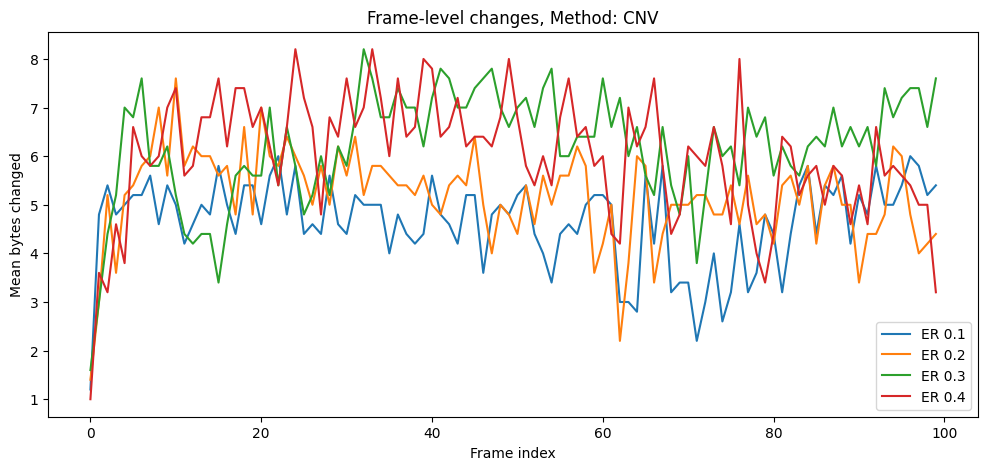

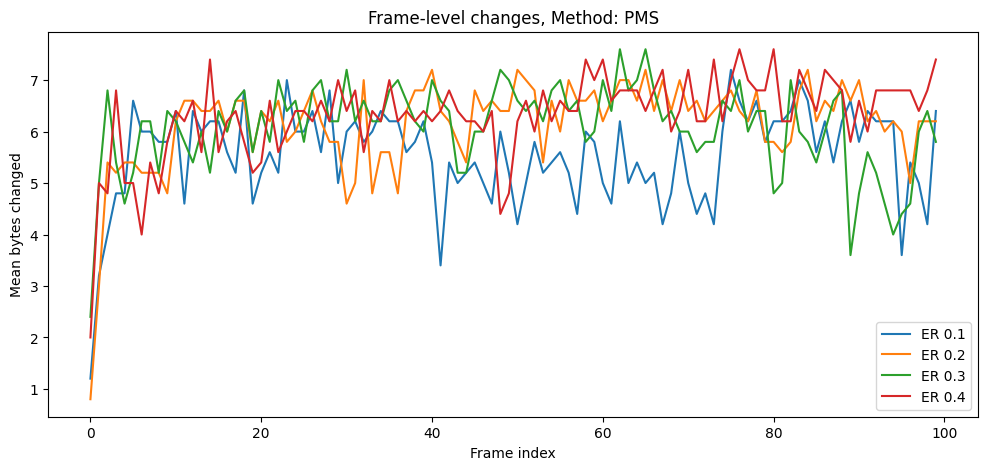

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

cover_path = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/cover"
stego_path = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/stego"
excel_path = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/train_lable.xlsx"

# Load metadata
xls = pd.ExcelFile(excel_path)
# example: load all four sheets
sheets = ["train_lable_chinese_CNV", "train_lable_chinese_PMS", "train_lable_english_CNV", "train_lable_english_PMS"]

df_meta_list = []
for sheet in sheets:
    df = pd.read_excel(xls, sheet_name=sheet)
    df["Filename"] = df["Filename"].astype(str) + ".g729a"
    df["Method"] = "CNV" if "CNV" in sheet else "PMS"
    df_meta_list.append(df)

df_meta = pd.concat(df_meta_list, ignore_index=True)

# List files
cover_files = sorted(os.listdir(cover_path))
stego_files = sorted(os.listdir(stego_path))

# Frame-level analysis function
def frame_level_analysis(file_name, frame_size=10):
    cover_file = os.path.join(cover_path, file_name)
    stego_file = os.path.join(stego_path, file_name)

    with open(cover_file, 'rb') as f:
        cover_bytes = np.frombuffer(f.read(), dtype=np.uint8)

    with open(stego_file, 'rb') as f:
        stego_bytes = np.frombuffer(f.read(), dtype=np.uint8)

    min_len = min(len(cover_bytes), len(stego_bytes))
    cover_bytes = cover_bytes[:min_len]
    stego_bytes = stego_bytes[:min_len]

    xor = cover_bytes ^ stego_bytes
    frame_changes = []

    for i in range(0, min_len, frame_size):
        frame = xor[i:i+frame_size]
        frame_changes.append(np.sum(frame != 0))

    return frame_changes

# Pick random subset
# ---- Uniform sampling per ER ----
random.seed(42)
n_max_per_ER = 5  # max files per ER
sample_files = []

cover_set = set(cover_files)
stego_set = set(stego_files)

for method in df_meta["Method"].unique():
    subset_method = df_meta[df_meta["Method"] == method]
    for ER in subset_method["Embedding rate"].unique():
        files_with_ER = subset_method[subset_method["Embedding rate"] == ER]["Filename"].tolist()

        # Keep only files that exist in your subset
        files_with_ER = [f for f in files_with_ER if f in cover_set and f in stego_set]
        if not files_with_ER:
            continue  # skip if none exist

        if len(files_with_ER) > n_max_per_ER:
            chosen = random.sample(files_with_ER, n_max_per_ER)
        else:
            chosen = files_with_ER

        sample_files.extend(chosen)

print(f"Total files after filtering missing ones: {len(sample_files)}")

results = []

for f in tqdm(sample_files):
    frame_changes = frame_level_analysis(f)

    # Print frame changes
    print(f"File: {f}, Frame changes: {frame_changes}")

    # Merge metadata if exists
    meta_row = df_meta[df_meta["Filename"] == f]
    if not meta_row.empty:
        ER = float(meta_row["Embedding rate"].values[0])
        method = meta_row["Method"].values[0]
    else:
        ER = None
        method = "Unknown"

    results.append({
        "filename": f,
        "frame_changes": frame_changes,
        "Embedding_rate": ER,
        "Method": method
    })

df_results = pd.DataFrame(results)

# ---- Plotting ----
frame_size = 10

for method in df_results["Method"].unique():
    plt.figure(figsize=(12,5))
    subset = df_results[df_results["Method"] == method]
    for ER in sorted(subset["Embedding_rate"].dropna().unique()):
        subset_er = subset[subset["Embedding_rate"] == ER]
        if subset_er.empty:
            continue
        # Compute mean per frame
        all_frame_changes = [fc for fc in subset_er["frame_changes"]]
        max_len = max(len(fc) for fc in all_frame_changes)
        padded_changes = [fc + [0]*(max_len - len(fc)) for fc in all_frame_changes]
        mean_per_frame = np.mean(padded_changes, axis=0)
        plt.plot(range(len(mean_per_frame)), mean_per_frame, label=f"ER {ER}")
    plt.title(f"Frame-level changes, Method: {method}")
    plt.xlabel("Frame index")
    plt.ylabel("Mean bytes changed")
    plt.legend()
    plt.show()

##**Silence check**

In [ ]:
import os
import subprocess
import numpy as np
from tqdm import tqdm

# Define paths
cover_path = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/cover"
stego_path = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/stego"

def get_audio_db(file_path):
    """
    Decodes a G.729A file in memory using FFmpeg and returns its RMS energy in dBFS.
    """
    cmd = [
        'ffmpeg', '-y',
        '-f', 'g729',
        '-i', file_path,
        '-f', 's16le', '-acodec', 'pcm_s16le', '-ar', '8000', '-ac', '1',
        '-loglevel', 'quiet', '-'
    ]
    try:
        # Pipe the raw decoded audio directly to Python
        raw_audio = subprocess.check_output(cmd)

        # Convert bytes to a numpy array of floats between -1.0 and 1.0
        audio_array = np.frombuffer(raw_audio, dtype=np.int16).astype(np.float32) / 32768.0

        if len(audio_array) == 0:
            return -float('inf')

        # Calculate RMS (Root Mean Square) energy
        rms = np.sqrt(np.mean(audio_array**2))

        # Convert to Decibels (dBFS)
        return 20 * np.log10(rms) if rms > 0 else -float('inf')

    except Exception as e:
        # If ffmpeg still fails for some reason,the file is broken/silent
        return -float('inf')

def find_silent_files(directory, silence_threshold=-45.0):
    """
    Scans a directory for .g729a files and flags those below the dB threshold.
    """
    silent_files = []
    files = [f for f in os.listdir(directory) if f.endswith('.g729a')]

    print(f"\nScanning {os.path.basename(directory).upper()} for silence (Threshold: {silence_threshold} dB)...")
    for f in tqdm(files):
        full_path = os.path.join(directory, f)
        db = get_audio_db(full_path)

        if db < silence_threshold:
            silent_files.append((f, db))

    return silent_files

# --- EXECUTION ---

# 1. Find Silent Files
COVER_SILENT = find_silent_files(cover_path, silence_threshold=-45.0)
print(f"-> Found {len(COVER_SILENT)} silent cover files.")

STEGO_SILENT = find_silent_files(stego_path, silence_threshold=-45.0)
print(f"-> Found {len(STEGO_SILENT)} silent stego files.")

Sampling 1000 files for dB distribution...


100%|██████████| 1000/1000 [12:34<00:00,  1.32it/s]



 NUMERICAL RESULTS:
Total valid files analyzed: 1000
Files strictly BELOW -45.0 dB (Silent): 0 (0.00%)
Minimum dB level: -44.82 dB
Maximum dB level: -7.84 dB
Average dB level: -27.87 dB



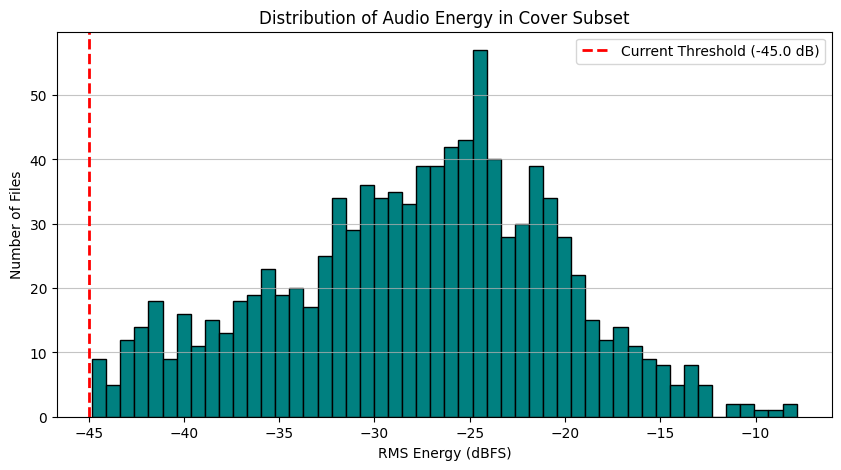

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Reuse the get_audio_db function already loaded in memory
sample_files = random.sample(os.listdir(cover_path), 1000)
db_levels = []
threshold = -45.0

print("Sampling 1000 files for dB distribution...")
for f in tqdm(sample_files):
    if f.endswith('.g729a'):
        full_path = os.path.join(cover_path, f)
        db = get_audio_db(full_path)
        if db != -float('inf'):
            db_levels.append(db)

# --- NEW: PRINT THE NUMERICAL RESULTS ---
below_threshold = [db for db in db_levels if db < threshold]
total_valid = len(db_levels)
num_below = len(below_threshold)

print("\n" + "="*40)
print(" NUMERICAL RESULTS:")
print("="*40)
print(f"Total valid files analyzed: {total_valid}")

if total_valid > 0:
    print(f"Files strictly BELOW {threshold} dB (Silent): {num_below} ({(num_below/total_valid)*100:.2f}%)")
    print(f"Minimum dB level: {min(db_levels):.2f} dB")
    print(f"Maximum dB level: {max(db_levels):.2f} dB")
    print(f"Average dB level: {np.mean(db_levels):.2f} dB")
print("="*40 + "\n")

# Plotting the histogram
plt.figure(figsize=(10, 5))
plt.hist(db_levels, bins=50, color='teal', edgecolor='black')
plt.axvline(x=threshold, color='red', linestyle='dashed', linewidth=2, label=f'Current Threshold ({threshold} dB)')
plt.title("Distribution of Audio Energy in Cover Subset")
plt.xlabel("RMS Energy (dBFS)")
plt.ylabel("Number of Files")
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

#**DATASET PREPROCESSING - (Creating usable data for the model)**

##**Binary Matrix Generation**

In [ ]:
import numpy as np
import os
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor

def g729_to_binary_matrix(file_path, target_bytes=1000):
    """
    Converts G.729a bitstream to (100, 80) matrix with explicit padding.
    """
    with open(file_path, 'rb') as f:
        data = f.read()

    original_len = len(data)

    if original_len < target_bytes:
        data = data + b"\x00" * (target_bytes - original_len)
        status = "Padded"
    elif original_len > target_bytes:
        data = data[:target_bytes]
        status = "Truncated"
    else:
        status = "Perfect"

    bits = np.unpackbits(np.frombuffer(data, dtype=np.uint8))
    matrix = bits.reshape(100, 80).astype(np.float32)

    return matrix, status, original_len

def process_single_file(args):
    """
    Worker function to process one file.
    Args: (in_file, out_file, fname, folder)
    """
    in_file, out_file, fname, folder = args
    try:
        matrix, status, raw_size = g729_to_binary_matrix(in_file)
        np.save(out_file, matrix)
        return {
            'filename': fname,
            'class': folder,
            'original_size': raw_size,
            'status': status,
            'error': 'None'
        }
    except Exception as e:
        return {
            'filename': fname,
            'class': folder,
            'original_size': 0,
            'status': 'Failed',
            'error': str(e)
        }

def run_batch_extraction(base_input_path, base_output_path, num_workers=14):
    subfolders = ['cover', 'stego']
    all_tasks = []

    # 1. Prepare Task List
    for folder in subfolders:
        src_dir = os.path.join(base_input_path, folder)
        dst_dir = os.path.join(base_output_path, folder)

        if not os.path.exists(src_dir):
            print(f"Directory not found: {src_dir}")
            continue

        os.makedirs(dst_dir, exist_ok=True)
        files = [f for f in os.listdir(src_dir) if f.endswith('.g729a')]

        for fname in files:
            in_file = os.path.join(src_dir, fname)
            out_file = os.path.join(dst_dir, fname.replace('.g729a', '.npy'))
            all_tasks.append((in_file, out_file, fname, folder))

    print(f"Total tasks identified: {len(all_tasks)}")
    print(f"Starting extraction with {num_workers} workers...")

    # 2. Execute Tasks in Parallel
    audit_log = []
    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        # Use tqdm to monitor progress across all workers
        results = list(tqdm(executor.map(process_single_file, all_tasks), total=len(all_tasks)))
        audit_log.extend(results)

    # 3. Save Audit Report
    df_audit = pd.DataFrame(audit_log)
    audit_csv = os.path.join(base_output_path, "extraction_audit_report.csv")
    df_audit.to_csv(audit_csv, index=False)

    # Summary Printout
    print("\n" + "="*40)
    print(" EXTRACTION SUMMARY")
    print("="*40)
    print(f"Total Files Processed: {len(df_audit)}")
    print(f"Success (Perfect):     {len(df_audit[df_audit['status']=='Perfect'])}")
    print(f"Success (Padded):      {len(df_audit[df_audit['status']=='Padded'])}")
    print(f"Failed:                {len(df_audit[df_audit['status']=='Failed'])}")
    print(f"Audit Log Saved to:    {audit_csv}")
    print("="*40)

if __name__ == "__main__":
    INPUT_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples"
    OUTPUT_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/Bitstream_Matrices_v1"

    run_batch_extraction(INPUT_BASE, OUTPUT_BASE, num_workers=14)

Total tasks identified: 99984
Starting extraction with 14 workers...


100%|██████████| 99984/99984 [45:51<00:00, 36.33it/s]



 EXTRACTION SUMMARY
Total Files Processed: 99984
Success (Perfect):     99984
Success (Padded):      0
Failed:                0
Audit Log Saved to:    /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/Bitstream_Matrices_v1/extraction_audit_report.csv


##**Forensic check**

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt

# Paths to created .npy folders
matrix_cover_dir = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/Bitstream_Matrices_v1/cover"
matrix_stego_dir = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/Bitstream_Matrices_v1/stego"

def verify_samples(num_to_check=3):
    cover_files = sorted([f for f in os.listdir(matrix_cover_dir) if f.endswith('.npy')])
    stego_files = sorted([f for f in os.listdir(matrix_stego_dir) if f.endswith('.npy')])

    # Find common files to compare pairs
    common_files = list(set(cover_files) & set(stego_files))

    print(f"Total pairs found: {len(common_files)}")

    for i in range(min(num_to_check, len(common_files))):
        fname = common_files[i]
        c_mat = np.load(os.path.join(matrix_cover_dir, fname))
        s_mat = np.load(os.path.join(matrix_stego_dir, fname))

        # 1. Check Shape
        print(f"\n--- Checking: {fname} ---")
        print(f"Shape: {c_mat.shape} | Dtype: {c_mat.dtype}")

        # 2. Check Values (Should be exactly 0.0 and 1.0)
        unique_vals = np.unique(c_mat)
        print(f"Unique values: {unique_vals}")

        # 3. Check for the Forensic Signal
        residual = np.abs(s_mat - c_mat)
        diff_bits = np.sum(residual)
        diff_percentage = (diff_bits / c_mat.size) * 100
        print(f"Bits changed in this pair: {int(diff_bits)} ({diff_percentage:.2f}%)")

        if diff_bits == 0:
            print("WARNING: No difference detected between cover and stego!")
        else:
            print("SUCCESS: Forensic signal preserved.")

# Run it
verify_samples()

Total pairs found: 49992

--- Checking: English106557.npy ---
Shape: (100, 80) | Dtype: float32
Unique values: [0. 1.]
Bits changed in this pair: 1649 (20.61%)
SUCCESS: Forensic signal preserved.

--- Checking: English102839.npy ---
Shape: (100, 80) | Dtype: float32
Unique values: [0. 1.]
Bits changed in this pair: 1783 (22.29%)
SUCCESS: Forensic signal preserved.

--- Checking: Chinese121481.npy ---
Shape: (100, 80) | Dtype: float32
Unique values: [0. 1.]
Bits changed in this pair: 1692 (21.15%)
SUCCESS: Forensic signal preserved.


##**Upgrade to 3-channel tensors**

In [ ]:
import numpy as np
import os
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor

# Paths
INPUT_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/Bitstream_Matrices_v1"
OUTPUT_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/MultiChannel_Matrices_v1"

def compute_temporal_diff(matrix):
    """Channel 2: Calculates the absolute difference between consecutive frames."""
    diff = np.zeros_like(matrix)
    diff[1:] = np.abs(matrix[1:] - matrix[:-1])
    return diff

def compute_bit_stability(matrix):
    """Channel 3: Calculates how much each bit deviates from its average state."""
    mean_bits = np.mean(matrix, axis=0, keepdims=True)
    stability = np.abs(matrix - mean_bits)
    return stability

def process_file_task(args):
    """
    Worker function to process a single file.
    Args: (in_file, out_file)
    """
    in_file, out_file = args
    try:
        # 1. Load the raw bits (Channel 1)
        raw_matrix = np.load(in_file).astype(np.float32)

        # 2. Compute the new channels (Channels 2 and 3)
        temp_diff = compute_temporal_diff(raw_matrix)
        stability = compute_bit_stability(raw_matrix)

        # 3. Stack into a (3, 100, 80) tensor (Channel-first)
        multi_channel = np.stack([raw_matrix, temp_diff, stability], axis=0)

        # 4. Save
        np.save(out_file, multi_channel)
        return True
    except Exception as e:
        return f"Error {in_file}: {e}"

def upgrade_to_3_channel_parallel(num_workers=20):
    subfolders = ['cover', 'stego']
    all_tasks = []

    # Prepare the task list first
    for folder in subfolders:
        src_dir = os.path.join(INPUT_BASE, folder)
        dst_dir = os.path.join(OUTPUT_BASE, folder)

        if not os.path.exists(src_dir):
            print(f"Directory not found: {src_dir}")
            continue

        os.makedirs(dst_dir, exist_ok=True)
        files = [f for f in os.listdir(src_dir) if f.endswith('.npy')]

        for fname in files:
            in_file = os.path.join(src_dir, fname)
            out_file = os.path.join(dst_dir, fname)

            # Skip if already exists
            if not os.path.exists(out_file):
                all_tasks.append((in_file, out_file))

    print(f"Total files to upgrade: {len(all_tasks)}")
    print(f"Using {num_workers} workers for parallel processing...")

    # Execute tasks in parallel
    results = []
    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        # Wrap executor.map with tqdm to show progress
        results = list(tqdm(executor.map(process_file_task, all_tasks), total=len(all_tasks)))

    # Error Reporting
    errors = [r for r in results if isinstance(r, str)]
    if errors:
        print(f"\nCompleted with {len(errors)} errors. Check the first few:")
        for err in errors[:5]:
            print(err)
    else:
        print("\nAll files upgraded successfully!")

if __name__ == "__main__":
    upgrade_to_3_channel_parallel(num_workers=20)

Total files to upgrade: 99984
Using 20 workers for parallel processing...


100%|██████████| 99984/99984 [36:20<00:00, 45.85it/s]



All files upgraded successfully!


##**Dataset shape check**

In [ ]:
import numpy as np
import os

# First file in the new cover directory
test_dir = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/MultiChannel_Matrices_v1/cover"
test_file = os.path.join(test_dir, os.listdir(test_dir)[0])

tensor = np.load(test_file)
print(f"Shape: {tensor.shape}")
print(f"Data Type: {tensor.dtype}")

Shape: (3, 100, 80)
Data Type: float32


# **MAIN MODEL PIPELINE**

##**Copy files from drive to colab**


In [ ]:
import os

# --- 1. Define the exact paths from Drive ---
drive_folder = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/MultiChannel_Matrices_v1"

cover_zip = f"{drive_folder}/cover-20260314T232838Z-3-001.zip"
stego_zip = f"{drive_folder}/stego-20260314T224850Z-3-001.zip"

# --- 2. Define where they should go locally ---
local_base = "/content/dataset_local"
os.makedirs(f"{local_base}/cover", exist_ok=True)
os.makedirs(f"{local_base}/stego", exist_ok=True)

# --- 3. Execute Copy and Unzip ---
print(" Extracting Cover matrices...")
!unzip -q "{cover_zip}" -d "{local_base}/cover"

print(" Extracting Stego matrices...")
!unzip -q "{stego_zip}" -d "{local_base}/stego"

# --- 4. Verify the count ---
cover_count = len(os.listdir(f"{local_base}/cover"))
stego_count = len(os.listdir(f"{local_base}/stego"))

print(f"\n Success!")
print(f"Total Covers extracted: {cover_count}")
print(f"Total Stegos extracted: {stego_count}")

 Extracting Cover matrices...
 Extracting Stego matrices...

 Success!
Total Covers extracted: 1
Total Stegos extracted: 1


##**Flatten the directory**

In [ ]:
import shutil
import os

def flatten_directory(parent_path):
    # This looks for a folder named 'cover' inside 'cover' (or 'stego' inside 'stego')
    subfolders = [f for f in os.listdir(parent_path) if os.path.isdir(os.path.join(parent_path, f))]

    for sub in subfolders:
        nested_path = os.path.join(parent_path, sub)

        print(f"Moving files out of {nested_path}...")

        for file_name in os.listdir(nested_path):
            shutil.move(os.path.join(nested_path, file_name), os.path.join(parent_path, file_name))

        # Remove the now-empty nested folder
        os.rmdir(nested_path)
        print(f"{parent_path} flattened successfully.")

# Apply to both local directories
flatten_directory("/content/dataset_local/cover")
flatten_directory("/content/dataset_local/stego")

Moving files out of /content/dataset_local/cover/cover...
/content/dataset_local/cover flattened successfully.
Moving files out of /content/dataset_local/stego/stego...
/content/dataset_local/stego flattened successfully.


##**Install comet ml**

In [ ]:
!pip install comet_ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.2/786.2 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.8 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.4.1
    Uninstalling python-box-7.4.1:
      Successfully uninstalled python-box-7.4.1


##**Delete malformed file**

In [ ]:
import os

broken_file = "/content/dataset_local/stego/English10588.npy"

if os.path.exists(broken_file):
    os.remove(broken_file)
    print(f" Successfully deleted: {broken_file}")
else:
    print(" File not found. It may have already been removed.")

 Successfully deleted: /content/dataset_local/stego/English10588.npy


##**Find number of files**

In [ ]:
!find '/content/dataset_local/cover' -type f | wc -l


49991


##**Dataset splitting**

In [ ]:
import os
import json
import random
import numpy as np
import torch
from datetime import datetime
from torch.utils.data import Dataset, ConcatDataset, Subset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
import shutil
from tqdm import tqdm

# ============================================================================
# CONFIGURATION
# ============================================================================
BASE_DIR = "/content/dataset_local"

# ----------------------------------------------------------------------------
# Route the saved split indices directly to Google Drive
# ----------------------------------------------------------------------------
SOURCE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples"
os.makedirs(SOURCE_DIR, exist_ok=True)

# Directing the script to exact local folders
COVER_DIR = os.path.join(BASE_DIR, "cover")
STEGO_DIR = os.path.join(BASE_DIR, "stego")

# ----------------------------------------------------------------------------
# UPDATED: Direct path to the Excel file in Google Drive
# ----------------------------------------------------------------------------
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/train_lable.xlsx"

SEED = 42
VAL_RATIO = 0.15
TEST_RATIO = 0.0
BATCH_SIZE = 128

# ============================================================================
# 1. DATASET CLASS
# ============================================================================
def load_excel_metadata(excel_path):
    print("Loading Excel metadata...")
    meta_map = {}
    if not os.path.exists(excel_path):
        print(f" [!] Excel file not found at {excel_path}. Metadata will be empty.")
        return meta_map

    xls = pd.ExcelFile(excel_path)
    tabs = ["train_lable_english_CNV", "train_lable_english_PMS",
            "train_lable_chinese_CNV", "train_lable_chinese_PMS"]

    for tab in tabs:
        if tab not in xls.sheet_names: continue
        current_algo = "CNV" if "CNV" in tab else "PMS"
        df = pd.read_excel(xls, sheet_name=tab)

        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0
                meta_map[fname] = {'algo': current_algo, 'rate': rate}

    print(f" -> Loaded Excel metadata for {len(meta_map)} samples.")
    return meta_map

class MatrixDataset(Dataset):
    def __init__(self, data_folder, label, meta_map=None):
        self.data_folder = data_folder
        self.label = label

        # Grab all .npy files
        self.files = [f for f in os.listdir(data_folder) if f.endswith(".npy")]
        self.files = sorted(self.files)

        # Base names (e.g., 'Chinese112894.npy' -> 'Chinese112894')
        self.base_names = [f.replace(".npy", "") for f in self.files]

        # ---> METADATA TRACKING <---
        self.meta_map = meta_map or {}
        self.metadata = []
        for b in self.base_names:
            if b in self.meta_map:
                self.metadata.append(self.meta_map[b])
            else:
                self.metadata.append({'algo': 'Cover' if label == 0 else 'Unknown', 'rate': 0.0})

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_folder, self.files[idx])
        # Load the (3, 100, 80) float32 tensor
        matrix = np.load(file_path)
        tensor = torch.from_numpy(matrix)

        return tensor, torch.tensor(self.label, dtype=torch.long)

    def get_metadata(self, idx):
        return {
            'base_name': self.base_names[idx],
            'algo': self.metadata[idx]['algo'],
            'rate': self.metadata[idx]['rate'],
            'is_stego': self.label == 1
        }

def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f" -> Global Seed locked to: {seed}")

# ============================================================================
# 2. GROUP-AWARE SPLIT FUNCTION (REMOVING TEST SPLIT)
# ============================================================================
def create_group_aware_splits(cover_dataset, stego_dataset,
                              val_ratio=0.15, test_ratio=0.0, seed=42,
                              save_indices=True, experiment_name="group_aware_matrices"):
    print("\nGenerating Forensic Group-Aware Splits (Train/Val only)...")

    # 1. Extract base names to form groups
    all_groups = np.array(cover_dataset.base_names + stego_dataset.base_names)
    all_indices = np.arange(len(all_groups))

    print(f"  Total Samples: {len(all_groups)}")
    print(f"  Unique Sources: {len(set(all_groups))}")

    # 2. Split Train vs Val (Now test_ratio is 0.0)
    gss = GroupShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
    train_idx, val_idx = next(gss.split(all_indices, groups=all_groups))

    # 3. Test index is empty (VStego800k Test Set used later)
    test_idx = np.array([])

    # 4. Shuffle Indices
    np.random.shuffle(train_idx)
    np.random.shuffle(val_idx)

    # 5. Leakage Verification
    train_groups_set = set(all_groups[train_idx])
    val_groups_set = set(all_groups[val_idx])

    leakage_tv = train_groups_set.intersection(val_groups_set)

    if len(leakage_tv) > 0:
        raise ValueError(f"CRITICAL LEAKAGE DETECTED! Overlap: {len(leakage_tv)}")
    else:
        print("  LEAKAGE CHECK PASSED: 0 overlapping audio sources.")

    # 6. Create Datasets
    full_dataset = ConcatDataset([cover_dataset, stego_dataset])
    train_ds = Subset(full_dataset, train_idx)
    val_ds   = Subset(full_dataset, val_idx)
    test_ds  = Subset(full_dataset, test_idx)

    print(f"  Train: {len(train_ds)} | Val: {len(val_ds)} | Test (Local): {len(test_ds)}")

    # 7. Save Indices
    if save_indices:
        split_info = {
            "experiment_name": experiment_name,
            "timestamp": datetime.now().isoformat(),
            "random_seed": seed,
            "indices": {
                "train": train_idx.tolist(),
                "val": val_idx.tolist(),
                "test": test_idx.tolist()
            }
        }
        save_path = os.path.join(SOURCE_DIR, f"split_indices_{experiment_name}_seed{seed}.json")
        with open(save_path, 'w') as f:
            json.dump(split_info, f)
        print(f"  Split indices saved to: {save_path}")

    return train_ds, val_ds, test_ds

def load_split_indices(filepath, full_dataset):
    """
    Loads previously saved training/validation indices from a JSON file
    to ensure consistency across different sessions.
    """
    print(f"Loading split from: {filepath}")
    with open(filepath, 'r') as f:
        data = json.load(f)

    train_ds = Subset(full_dataset, data["indices"]["train"])
    val_ds   = Subset(full_dataset, data["indices"]["val"])
    test_ds  = Subset(full_dataset, data["indices"]["test"])

    return train_ds, val_ds, test_ds

# ============================================================================
# 3. MAIN EXECUTION (Updated for Optuna/Training workflow)
# ============================================================================
if __name__ == "__main__":
    print(f"{'='*50}\nDataset Preparation Pipeline (85/15 Split)\n{'='*50}")
    set_global_seed(SEED)

    global_meta_map = load_excel_metadata(EXCEL_PATH)

    print("\nLoading datasets...")
    cover_dataset = MatrixDataset(data_folder=COVER_DIR, label=0)
    stego_dataset = MatrixDataset(data_folder=STEGO_DIR, label=1, meta_map=global_meta_map)

    full_dataset = ConcatDataset([cover_dataset, stego_dataset])

    # Important: Rename experiment if want to keep old splits separate
    EXPERIMENT_NAME = "stego-detection-3channel"
    SPLIT_FILE = os.path.join(SOURCE_DIR, f"split_indices_{EXPERIMENT_NAME}_seed{SEED}.json")

    if os.path.exists(SPLIT_FILE):
        print("\nFound existing split file. Loading...")
        train_dataset, val_dataset, test_dataset = load_split_indices(SPLIT_FILE, full_dataset)
    else:
        print("\nCreating NEW group-aware split (No local test set)...")
        train_dataset, val_dataset, test_dataset = create_group_aware_splits(
            cover_dataset, stego_dataset,
            val_ratio=VAL_RATIO, test_ratio=0.0, seed=SEED,
            save_indices=True, experiment_name=EXPERIMENT_NAME
        )

    # Note: test_loader is still created but will be empty/unused locally.
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    print(f"\n Pipeline Ready. Using {len(train_dataset)} for training and {len(val_dataset)} for validation.")

    # Verification Print
    x, y = next(iter(train_loader))
    print(f"Batch Shape: {x.shape} -> [Batch, Channels, Frames, Bits]")
    print(f"Labels Shape: {y.shape}")

Dataset Preparation Pipeline (85/15 Split)
 -> Global Seed locked to: 42
Loading Excel metadata...
 -> Loaded Excel metadata for 382296 samples.

Loading datasets...

Found existing split file. Loading...
Loading split from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples/split_indices_stego-detection-3channel_seed42.json

 Pipeline Ready. Using 84984 for training and 14998 for validation.
Batch Shape: torch.Size([128, 3, 100, 80]) -> [Batch, Channels, Frames, Bits]
Labels Shape: torch.Size([128])


###**Channel check (after dataset splitting)**

In [ ]:
# ============================================================================
# INPUT AUDIT (CHANNEL CORRELATION CHECK)
# ============================================================================
import numpy as np

print(f"{'='*50}\nAuditing Input Channels for Redundancy\n{'='*50}")

# Parameters for the audit
NUM_BATCHES_TO_AUDIT = 5
THRESHOLD = 0.90

ch1_all, ch2_all, ch3_all = [], [], []

print(f"Extracting {NUM_BATCHES_TO_AUDIT} batches for statistical audit...")

# 1. Accumulate data across a few batches to ensure stable correlation
for i, (x, y) in enumerate(train_loader):
    if i >= NUM_BATCHES_TO_AUDIT:
        break

    # x shape is expected to be [Batch, 3, 100, 80]
    ch1_all.append(x[:, 0, :, :].numpy().flatten())
    ch2_all.append(x[:, 1, :, :].numpy().flatten())
    ch3_all.append(x[:, 2, :, :].numpy().flatten())

# Concatenate all collected batches into single 1D arrays
ch1_flat = np.concatenate(ch1_all)
ch2_flat = np.concatenate(ch2_all)
ch3_flat = np.concatenate(ch3_all)

print(f"Total data points analyzed per channel: {len(ch1_flat):,}\n")

# 2. Compute Pearson Correlation Coefficients
corr_1_2 = np.corrcoef(ch1_flat, ch2_flat)[0, 1]
corr_1_3 = np.corrcoef(ch1_flat, ch3_flat)[0, 1]
corr_2_3 = np.corrcoef(ch2_flat, ch3_flat)[0, 1]

print("--- Correlation Results ---")
print(f"Ch1 vs Ch2 Correlation: {corr_1_2:.4f}")
print(f"Ch1 vs Ch3 Correlation: {corr_1_3:.4f}")
print(f"Ch2 vs Ch3 Correlation: {corr_2_3:.4f}\n")

# 3. Decision Logic & Recommendations
print("--- Audit Verdict ---")
redundancy_found = False

if abs(corr_1_2) > THRESHOLD:
    print(" [WARNING] Channel 1 and Channel 2 are highly correlated!")
    redundancy_found = True
if abs(corr_1_3) > THRESHOLD:
    print(" [WARNING] Channel 1 and Channel 3 are highly correlated!")
    redundancy_found = True
if abs(corr_2_3) > THRESHOLD:
    print(" [WARNING] Channel 2 and Channel 3 are highly correlated!")
    redundancy_found = True

if redundancy_found:
    print("\nACTION REQUIRED: Drop the redundant channel(s) to reduce model parameters, ")
    print("OR replace the redundant channel with a new feature mapping (e.g., bit-position entropy).")
else:
    print(" PASS: Channels are mathematically distinct. Model representation power is not being wasted.")

Auditing Input Channels for Redundancy
Extracting 5 batches for statistical audit...
Total data points analyzed per channel: 1,280,000

--- Correlation Results ---
Ch1 vs Ch2 Correlation: 0.0184
Ch1 vs Ch3 Correlation: 0.0834
Ch2 vs Ch3 Correlation: 0.2058

--- Audit Verdict ---
 PASS: Channels are mathematically distinct. Model representation power is not being wasted.


###**Verify if stego methods are equally distributed across splits**

In [ ]:
import pandas as pd
import json
import os
import numpy as np

# --- CONFIGURATION ---
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/train_lable.xlsx"
SPLIT_JSON_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples/split_indices_group_aware_matrices_v1_seed42.json"
COVER_FOLDER = "/content/dataset_local/cover"

def verify_full_distribution():
    print(" FULL DISTRIBUTION CHECK (Algorithm + Payload)...")

    # 1. Load Excel Metadata
    print("   Loading Excel metadata...")
    meta_map = {}

    try:
        xls = pd.ExcelFile(EXCEL_PATH)
        tabs = ["train_lable_english_CNV", "train_lable_english_PMS",
                "train_lable_chinese_CNV", "train_lable_chinese_PMS"]

        for tab in tabs:
            if tab not in xls.sheet_names: continue

            if "CNV" in tab: current_algo = "CNV"
            elif "PMS" in tab: current_algo = "PMS"
            else: current_algo = "Unknown"

            df = pd.read_excel(xls, sheet_name=tab)

            for _, row in df.iterrows():
                if pd.notna(row.iloc[0]):
                    fname = str(row.iloc[0]).strip()
                    try:
                        rate = float(row.iloc[2])
                    except:
                        rate = 0.0
                    meta_map[fname] = {'rate': rate, 'algo': current_algo}

    except Exception as e:
        print(f" Error reading Excel: {e}")
        return

    print(f"    Loaded metadata for {len(meta_map)} files.")

    # 2. Load Split
    if not os.path.exists(SPLIT_JSON_PATH):
        print(" Split file not found.")
        return

    with open(SPLIT_JSON_PATH, 'r') as f:
        split_data = json.load(f)

    # 3. Get Files on Disk
    try:
        files_on_disk = sorted(os.listdir(COVER_FOLDER))
        # UPDATED: Look for standard .npy matrices
        files_on_disk = [f for f in files_on_disk if f.endswith(".npy")]
    except FileNotFoundError:
        print(" Data folder not found.")
        return

    n_covers = len(files_on_disk)

    # 4. Check Splits
    splits = ["train", "val", "test"]

    print(f"\n{'='*100}")
    print(f"{'SPLIT':<8} | {'CNV':<6} {'PMS':<6} | {'0.1':<6} {'0.2':<6} {'0.3':<6} {'0.4':<6} | {'Unknown':<8}")
    print(f"{'='*100}")

    for subset in splits:
        indices = split_data["indices"][subset]

        # Counters
        algos = {"CNV": 0, "PMS": 0, "Unknown": 0}
        rates = {0.1: 0, 0.2: 0, 0.3: 0, 0.4: 0, "Other": 0}
        unknown_file = 0

        for idx in indices:
            clean_idx = idx if idx < n_covers else idx - n_covers

            if clean_idx >= n_covers:
                unknown_file += 1
                continue

            full_name = files_on_disk[clean_idx]
            # UPDATED: Strip the correct extension to match Excel
            clean_name = full_name.replace(".npy", "")

            if clean_name in meta_map:
                a = meta_map[clean_name]['algo']
                algos[a] = algos.get(a, 0) + 1

                r = meta_map[clean_name]['rate']
                r = round(r, 1)

                if r in rates: rates[r] += 1
                else: rates["Other"] += 1
            else:
                unknown_file += 1

        print(f"{subset.upper():<8} | {algos['CNV']:<6} {algos['PMS']:<6} | "
              f"{rates[0.1]:<6} {rates[0.2]:<6} {rates[0.3]:<6} {rates[0.4]:<6} | {unknown_file:<8}")

        total_rates = sum(rates.values()) - rates["Other"]
        if total_rates > 0:
            low_pct = (rates[0.1] / total_rates) * 100
            high_pct = (rates[0.4] / total_rates) * 100
            print(f"          Low(0.1): {low_pct:.1f}% vs High(0.4): {high_pct:.1f}%")

    print(f"{'='*100}")

verify_full_distribution()

 FULL DISTRIBUTION CHECK (Algorithm + Payload)...
   Loading Excel metadata...
    Loaded metadata for 382296 files.

SPLIT    | CNV    PMS    | 0.1    0.2    0.3    0.4    | Unknown 
TRAIN    | 35026  34960  | 42156  9300   9244   9286   | 0       
          Low(0.1): 60.2% vs High(0.4): 13.3%
VAL      | 7496   7502   | 9000   1992   2004   2002   | 0       
          Low(0.1): 60.0% vs High(0.4): 13.3%
TEST     | 7470   7528   | 8844   2036   2078   2040   | 0       
          Low(0.1): 59.0% vs High(0.4): 13.6%


##**Proposed model**

###**Residual / High pass emphasis layer**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualPathwayForensicLayer(nn.Module):
    """
    Dual-Pathway Preprocessing Block:
    1. Fixed Pathway: Deterministic high-pass filters to prevent signal smoothing.
    2. Learnable Pathway: Dynamic filters to catch unforeseen stego traces.
    """
    def __init__(self):
        super().__init__()

        # 1st Order (Sudden flips)
        hp1 = torch.tensor([[[[-1., 1.]]]], dtype=torch.float32)
        # 2nd Order (Local curvature)
        hp2 = torch.tensor([[[[-1., 2., -1.]]]], dtype=torch.float32)
        # 3rd Order (Complex sequential flips)
        hp3 = torch.tensor([[[[-1., 3., -3., 1.]]]], dtype=torch.float32)
        # 3x3 Spatial Laplacian (Cross-dimensional anomalies)
        hp_spatial = torch.tensor([[[[-1., -1., -1.],
                                     [-1.,  8., -1.],
                                     [-1., -1., -1.]]]], dtype=torch.float32)

        self.register_buffer('kernel1', hp1)
        self.register_buffer('kernel2', hp2)
        self.register_buffer('kernel3', hp3)
        self.register_buffer('kernel_spatial', hp_spatial)

        # --- LEARNABLE PATHWAY (Dynamic Features) ---
        # Extracts 2 learnable channels from the raw bits
        self.learnable_filters = nn.Conv2d(1, 2, kernel_size=3, padding=1, bias=False)
        # Initialize with small random weights to encourage distinct feature learning
        nn.init.xavier_normal_(self.learnable_filters.weight)

    def forward(self, x):
        # Apply residuals to Channel 1 (Raw Bits)
        raw_bits = x[:, 0:1, :, :]

        # 1. Apply Fixed Kernels
        res1 = F.conv2d(raw_bits, self.kernel1, padding=(0, 0))
        res2 = F.conv2d(raw_bits, self.kernel2, padding=(0, 0))
        res3 = F.conv2d(raw_bits, self.kernel3, padding=(0, 0))
        res_sp = F.conv2d(raw_bits, self.kernel_spatial, padding=1) # 3x3 needs padding=1

        # Pad 1D residuals to match original (100, 80) dimensions
        res1 = F.pad(res1, (0, 1, 0, 0))
        res2 = F.pad(res2, (1, 1, 0, 0))
        res3 = F.pad(res3, (1, 2, 0, 0)) # Pad to offset kernel size 4

        # 2. Apply Learnable Kernels
        learned_res = self.learnable_filters(raw_bits)

        # Return all 6 generated channels (4 fixed + 2 learned)
        return torch.cat([res1, res2, res3, res_sp, learned_res], dim=1)

###**Depthwise convolution, Residual Blocks, SE Blocks, Spatial Attention, CNN**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================================
# 1. ARCHITECTURE COMPONENTS
# ============================================================================

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                   padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)

# --- Lightweight Channel Attention (SE Block) ---
class SEBlock(nn.Module):
    """Squeeze-and-Excitation block to recalibrate channel saliency."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SpatialAttention(nn.Module):
    """Generates the XAI Heatmap for forensic review."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        attn_weights = self.sigmoid(out)
        return x * attn_weights, attn_weights

# ============================================================================
# 2. MAIN STEGANALYSIS MODEL (Bit-Flip Removed)
# ============================================================================

class StegoCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Use the new Dual Pathway Layer
        self.hp_layer = DualPathwayForensicLayer()

        # (Original 3: Raw, Temp-Diff, Stability) + (Fixed 4) + (Learnable 2) = 9
        self.init_conv = nn.Sequential(
            nn.Conv2d(9, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.dw_conv = DepthwiseSeparableConv(32, 64, dropout=0.1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.attention = SpatialAttention()

        self.res_block1 = ResidualBlock(64, dropout=0.1)
        self.se1 = SEBlock(64, reduction=16)
        self.res_block2 = ResidualBlock(64, dropout=0.1)
        self.se2 = SEBlock(64, reduction=16)

        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # 1. Extract Dual-Pathway Residuals (Extracts 6 channels from raw bits)
        hp_features = self.hp_layer(x)

        # 2. Concatenate with original input
        x = torch.cat([x, hp_features], dim=1)

        # 3. Pass the 9-channel tensor into the pipeline
        x = self.init_conv(x)
        x = self.pool2(self.dw_conv(x))
        x, attn_weights = self.attention(x)

        x = self.res_block1(x)
        x = self.se1(x)
        x = self.res_block2(x)
        x = self.se2(x)

        mean_x = torch.mean(x, dim=[2, 3])
        std_x = torch.std(x, dim=[2, 3])
        x = torch.cat([mean_x, std_x], dim=1)

        out = self.fc(x)
        return out, attn_weights

# --- QUICK SANITY CHECK ---
if __name__ == "__main__":
    model = StegoCNN()
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Trainable Parameters: {total_params:,}")

    dummy_input = torch.randn(32, 3, 100, 80)
    output, attention_map = model(dummy_input)

    print(f"Model Output Shape: {output.shape} -> Expected: [32, 1]")
    print(f"Attention Map Shape: {attention_map.shape} -> Expected: [32, 1, 25, 20]")

Total Trainable Parameters: 170,965
Model Output Shape: torch.Size([32, 1]) -> Expected: [32, 1]
Attention Map Shape: torch.Size([32, 1, 25, 20]) -> Expected: [32, 1, 25, 20]


##**Training per epoch**

In [ ]:
from google.colab import userdata

comet_api_key = userdata.get('comet_api_key')

In [ ]:
import comet_ml
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import os
import glob
import pandas as pd
import time
import shutil
from tqdm import tqdm
from collections import defaultdict
from sklearn.metrics import roc_curve
import random
import json

# =====================================================
# 1. CONFIGURATION
# =====================================================
COMET_API_KEY = comet_api_key
CHECKPOINT_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Original_3SeedRun"
PER_SEED_HISTORY_DIR = "/content/temp_seed_histories"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PER_SEED_HISTORY_DIR, exist_ok=True)
SEED_STATUS_PATH = os.path.join(CHECKPOINT_DIR, "seed_status.json")

NUM_EPOCHS = 120
LR = 1.0e-04
GRADIENT_CLIP = 1.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weight = torch.tensor([1.05]).to(device)
smoothing = 0.1


# =====================================================
# 2. UTILITIES
# =====================================================

def load_seed_status():
    if os.path.exists(SEED_STATUS_PATH):
        with open(SEED_STATUS_PATH, "r") as f:
            return json.load(f)
    return {}

def save_seed_status(status_dict):
    with open(SEED_STATUS_PATH, "w") as f:
        json.dump(status_dict, f, indent=4)

def mark_seed_status(seed, status):
    status_dict = load_seed_status()
    status_dict[str(seed)] = status
    save_seed_status(status_dict)

def is_seed_completed(seed):
    status_dict = load_seed_status()
    return status_dict.get(str(seed)) == "completed"

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

def find_best_threshold(labels, probs):
    fpr, tpr, thresholds = roc_curve(labels, probs)
    optimal_idx = np.argmax(tpr - fpr)
    return thresholds[optimal_idx]

def collect_probs_labels(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for matrices, labels in loader:
            matrices = matrices.to(device)
            logits, _ = model(matrices)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels).flatten(), np.array(all_probs).flatten()

def finalize_forensic_threshold(model, val_loader):
    labels, probs = collect_probs_labels(model, val_loader)
    final_thr = find_best_threshold(labels, probs)
    return final_thr

def save_artifacts_to_drive():
    """Safety: Syncs local progress to Google Drive."""
    print(" Syncing logs to Drive...")
    drive_hist = os.path.join(CHECKPOINT_DIR, "per_seed_histories")
    os.makedirs(drive_hist, exist_ok=True)
    if os.path.exists(PER_SEED_HISTORY_DIR):
        for csv_file in glob.glob(os.path.join(PER_SEED_HISTORY_DIR, "*.csv")):
            shutil.copy(csv_file, drive_hist)

def get_latest_checkpoint(seed, variant_name):
    pattern = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_epoch*.pt")
    files = glob.glob(pattern)
    return max(files, key=os.path.getmtime) if files else None

# =====================================================
# 3. CORE TRAINING FUNCTION
# =====================================================

def train_and_evaluate(seed, variant_name, model_constructor, train_loader, val_loader, full_dataset):
    latest_ckpt = get_latest_checkpoint(seed, variant_name)

    if latest_ckpt:
        ckpt = torch.load(latest_ckpt, map_location=device, weights_only=False)
        if ckpt['epoch'] >= NUM_EPOCHS:
            print(f" Seed {seed} already reached NUM_EPOCHS ({NUM_EPOCHS}).")
            return
    mark_seed_status(seed, "in_progress")
    experiment = comet_ml.Experiment(api_key=COMET_API_KEY, project_name="stego-detection-3channel")
    experiment.set_name(f"{variant_name}_seed{seed}")
    EARLY_STOP_PATIENCE = 30


    hyper_params = {
        "learning_rate": LR,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "seed": seed,
        "gradient_clip": GRADIENT_CLIP,
        "optimizer": "AdamW",
        "scheduler": "CosineAnnealingLR",
        "weight_decay": 0.00019,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "pos_weight": pos_weight.item(),
        "label_smoothing": smoothing,
    }
    experiment.log_parameters(hyper_params)

    set_all_seeds(seed)
    model = model_constructor().to(device)

    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1.01e-03)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='mean')

    best_val_auc = -1.0
    patience_counter = 0
    best_epoch = -1

    history = defaultdict(list)
    start_epoch = 0

    latest_ckpt = get_latest_checkpoint(seed, variant_name)
    if latest_ckpt:
        print(f" Resuming from: {latest_ckpt}")
        ckpt = torch.load(latest_ckpt, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_epoch = ckpt['epoch']
        best_val_auc = ckpt.get('best_val_auc', -1.0)
        patience_counter = ckpt.get('patience_counter', 0)
        best_epoch = ckpt.get('best_epoch', -1)

        if seed == 21 and 'patience_counter' not in ckpt:
            patience_counter = 5
            print(" Restored manual patience_counter=5 for seed 21 (legacy checkpoint recovery).")


        if 'history' in ckpt:
            loaded_history = ckpt['history']
            history = defaultdict(list, loaded_history)

    for epoch in range(start_epoch, NUM_EPOCHS):
        # --- TRAIN PHASE ---
        model.train()
        t_probs, t_labels, t_loss_run = [], [], 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN][Seed {seed}]")
        for matrices, labels in pbar:
            matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
            # label smoothing
            smoothed_labels = labels * (1 - smoothing) + 0.5 * smoothing
            optimizer.zero_grad()
            logits, _ = model(matrices)
            loss = criterion(logits, smoothed_labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            optimizer.step()

            t_loss_run += loss.item() * matrices.size(0)
            t_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            t_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # --- VALIDATION PHASE ---
        model.eval()
        v_probs, v_labels, v_loss_run = [], [], 0.0
        with torch.no_grad():
            for matrices, labels in val_loader:
                matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
                logits, _ = model(matrices)
                v_loss_run += criterion(logits, labels).item() * matrices.size(0)
                v_probs.extend(torch.sigmoid(logits).cpu().numpy())
                v_labels.extend(labels.cpu().numpy())

        scheduler.step()

        # Metric Calculations
        def get_metrics(l, p):
            l, p = np.array(l).flatten(), np.array(p).flatten()
            fixed_thr = 0.5
            preds = (p >= fixed_thr).astype(int)

            return {
                "acc": accuracy_score(l, preds) * 100,
                "f1": f1_score(l, preds, zero_division=0),
                "pre": precision_score(l, preds, zero_division=0),
                "rec": recall_score(l, preds, zero_division=0),
                "auc": roc_auc_score(l, p) if len(np.unique(l)) > 1 else 0.0
            }

        tm = get_metrics(t_labels, t_probs)
        vm = get_metrics(v_labels, v_probs)

        # --- THE PRINT STATEMENT ---
        print(f"\n" + "="*60)
        print(f" SEED {seed} | EPOCH {epoch+1} REPORT")
        print(f"="*60)
        print(f"METRIC    | TRAIN      | VALIDATION")
        print(f"----------|------------|-----------")
        print(f"LOSS      | {t_loss_run/len(t_labels):.4f}     | {v_loss_run/len(v_labels):.4f}")
        print(f"ACCURACY  | {tm['acc']:.2f}%     | {vm['acc']:.2f}%")
        print(f"F1-SCORE  | {tm['f1']:.4f}     | {vm['f1']:.4f}")
        print(f"PRECISION | {tm['pre']:.4f}     | {vm['pre']:.4f}")
        print(f"RECALL    | {tm['rec']:.4f}     | {vm['rec']:.4f}")
        print(f"AUC       | {tm['auc']:.4f}     | {vm['auc']:.4f}")
        print(f"="*60 + "\n")

        # LOG EVERYTHING
        epoch_stats = {f"t_{k}": v for k, v in tm.items()}
        epoch_stats.update({f"v_{k}": v for k, v in vm.items()})
        epoch_stats.update({"t_loss": t_loss_run/len(t_labels), "v_loss": v_loss_run/len(v_labels)})

        for k, v in epoch_stats.items(): history[k].append(v)
        experiment.log_metrics(epoch_stats, step=epoch)

        # --- SAVE EVERY EPOCH ---
        ckpt_data = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': dict(history),
            'best_val_auc': best_val_auc,
            'patience_counter': patience_counter,
            'best_epoch': best_epoch
        }

        # Save epoch checkpoint
        epoch_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_epoch{epoch+1:03d}.pt")
        torch.save(ckpt_data, epoch_ckpt_path)

        # --- EARLY STOPPING LOGIC ---
        if vm['auc'] > best_val_auc:
            best_val_auc = vm['auc']
            patience_counter = 0
            best_epoch = epoch + 1

            ckpt_data['best_val_auc'] = best_val_auc
            ckpt_data['patience_counter'] = patience_counter
            ckpt_data['best_epoch'] = best_epoch

            best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_best.pt")
            torch.save(ckpt_data, best_ckpt_path)
            print(f"  New Best Validation AUC for Seed {seed}: {best_val_auc:.4f} (Model Saved!)")
        else:
            patience_counter += 1
            ckpt_data['patience_counter'] = patience_counter
            ckpt_data['best_epoch'] = best_epoch
            print(f"  Early Stopping Counter: {patience_counter}/{EARLY_STOP_PATIENCE}")
        pd.DataFrame(history).to_csv(
            os.path.join(PER_SEED_HISTORY_DIR, f"{variant_name}_seed{seed}_history.csv"),
            index=False
        )
        save_artifacts_to_drive()

        # Trigger Early Stop
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\n EARLY STOPPING TRIGGERED for Seed {seed}! No improvement in Validation AUC for {EARLY_STOP_PATIENCE} epochs.")
            print("Restoring weights from the best epoch...")
            break
    experiment.end()


if __name__ == "__main__":
    variant = "Auspex_Forensic_Final_Original_3SeedRun"
    SEEDS = [7, 21, 42]

    def my_model_builder():
        return StegoCNN()

    all_seed_thresholds = []

    for seed in SEEDS:
        if is_seed_completed(seed):
            print("\n" + "#"*80)
            print(f" SEED {seed} ALREADY COMPLETED. SKIPPING.")
            print("#"*80)

            threshold_txt_path = os.path.join(CHECKPOINT_DIR, f"forensic_threshold_seed{seed}.txt")
            best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant}_seed{seed}_best.pt")

            if os.path.exists(threshold_txt_path) and os.path.exists(best_ckpt_path):
                with open(threshold_txt_path, "r") as f:
                    final_thr = float(f.read().strip())

                all_seed_thresholds.append({
                    "seed": seed,
                    "threshold": final_thr,
                    "best_checkpoint_path": best_ckpt_path
                })
            continue

        print("\n" + "#"*80)
        print(f" STARTING / RESUMING TRAINING FOR SEED {seed}")
        print("#"*80)

        train_and_evaluate(seed, variant, my_model_builder, train_loader, val_loader, full_dataset)

        print("\n" + "="*60)
        print(f" TRAINING COMPLETE FOR SEED {seed}. FINALIZING FORENSIC THRESHOLD...")
        print("="*60)

        best_model = my_model_builder().to(device)
        best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant}_seed{seed}_best.pt")

        if os.path.exists(best_ckpt_path):
            checkpoint = torch.load(best_ckpt_path, map_location=device, weights_only=False)
            best_model.load_state_dict(checkpoint['model_state_dict'])

            final_thr = finalize_forensic_threshold(best_model, val_loader)

            print(f"\n[ANALYSIS COMPLETE FOR SEED {seed}]")
            print(f"Optimal Threshold (Youden's J): {final_thr:.4f}")
            print(f"Any probability >= {final_thr:.4f} is classified as STEGO.")
            print("="*60)

            threshold_txt_path = os.path.join(CHECKPOINT_DIR, f"forensic_threshold_seed{seed}.txt")
            with open(threshold_txt_path, "w") as f:
                f.write(str(final_thr))

            all_seed_thresholds.append({
                "seed": seed,
                "threshold": final_thr,
                "best_checkpoint_path": best_ckpt_path
            })

            mark_seed_status(seed, "completed")

        else:
            print(f"Error: Could not find best checkpoint at {best_ckpt_path}")
            mark_seed_status(seed, "in_progress")

    if len(all_seed_thresholds) > 0:
        threshold_df = pd.DataFrame(all_seed_thresholds)
        threshold_df.to_csv(os.path.join(CHECKPOINT_DIR, "all_seed_thresholds.csv"), index=False)

        print("\n" + "#"*80)
        print(" ALL AVAILABLE SEEDS FINISHED / RECOVERED")
        print("#"*80)
        print(threshold_df)
    else:
        print("\nNo thresholds were saved because no best checkpoints were found.")


################################################################################
 SEED 7 ALREADY COMPLETED. SKIPPING.
################################################################################

################################################################################
 STARTING / RESUMING TRAINING FOR SEED 21
################################################################################


COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch, sklearn.
COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Auspex_Forensic_Final_Original_3SeedRun_seed7
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/stego-detection-3channel/2dcd6e48997b469a9a86b4129d0a0c1d
COMET INFO:   Others:
COMET INFO:     Name         : Auspex_Forensic_Final_Original_3SeedRun_seed7
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#fileId=1xlPeDyPKMH_WGDELUGuCVHIKIi57NqPz
COMET INFO:   Parameters:
COMET

 Resuming from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Original_3SeedRun/Auspex_Forensic_Final_Original_3SeedRun_seed21_epoch068.pt
 Restored manual patience_counter=5 for seed 21 (legacy checkpoint recovery).


Epoch 69/120 [TRAIN][Seed 21]: 100%|██████████| 664/664 [02:34<00:00,  4.30it/s, loss=0.7233]



 SEED 21 | EPOCH 69 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6552     | 0.6588
ACCURACY  | 63.91%     | 60.75%
F1-SCORE  | 0.6260     | 0.5757
PRECISION | 0.6495     | 0.6265
RECALL    | 0.6041     | 0.5325
AUC       | 0.6931     | 0.6563

  Early Stopping Counter: 6/30
 Syncing logs to Drive...


...


 SEED 42 | EPOCH 86 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6416     | 0.6608
ACCURACY  | 65.85%     | 61.92%
F1-SCORE  | 0.6407     | 0.5607
PRECISION | 0.6759     | 0.6625
RECALL    | 0.6090     | 0.4859
AUC       | 0.7178     | 0.6613

  Early Stopping Counter: 29/30
 Syncing logs to Drive...


Epoch 87/120 [TRAIN][Seed 42]: 100%|██████████| 664/664 [01:44<00:00,  6.32it/s, loss=0.6420]



 SEED 42 | EPOCH 87 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6418     | 0.6618
ACCURACY  | 65.68%     | 61.51%
F1-SCORE  | 0.6369     | 0.5613
PRECISION | 0.6762     | 0.6525
RECALL    | 0.6019     | 0.4925
AUC       | 0.7161     | 0.6584

  Early Stopping Counter: 30/30
 Syncing logs to Drive...

 EARLY STOPPING TRIGGERED for Seed 42! No improvement in Validation AUC for 30 epochs.
Restoring weights from the best epoch...


COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Auspex_Forensic_Final_Original_3SeedRun_seed42
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/stego-detection-3channel/75c85b646cb541e6b196cf9b59d1a37c
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     t_acc [87]  : (50.081191753741884, 65.84651228466535)
COMET INFO:     t_auc [87]  : (0.5007007025233887, 0.7177513627629573)
COMET INFO:     t_f1 [87]   : (0.5551398995592908, 0.640695212983251)
COMET INFO:     t_loss [87] : (0.6415707770628769, 0.7120026933555492)
COMET INFO:     t_pre [87]  : (0.50


 TRAINING COMPLETE FOR SEED 42. FINALIZING FORENSIC THRESHOLD...

[ANALYSIS COMPLETE FOR SEED 42]
Optimal Threshold (Youden's J): 0.5249
Any probability >= 0.5249 is classified as STEGO.

################################################################################
 ALL AVAILABLE SEEDS FINISHED / RECOVERED
################################################################################
   seed  threshold                               best_checkpoint_path
0     7   0.489593  /content/drive/MyDrive/IIT - University of Wes...
1    21   0.541891  /content/drive/MyDrive/IIT - University of Wes...
2    42   0.524863  /content/drive/MyDrive/IIT - University of Wes...


##**Testing**

###**Extract test files from zip**

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# --- 1. CONFIGURATION ---
TEST_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test"
LOCAL_TEMP = "/content/test_processing"
RAW_EXTRACT = os.path.join(LOCAL_TEMP, "raw_audios")
TENSOR_DIR = os.path.join(LOCAL_TEMP, "3channel_tensors")

os.makedirs(RAW_EXTRACT, exist_ok=True)
os.makedirs(os.path.join(TENSOR_DIR, "cover"), exist_ok=True)
os.makedirs(os.path.join(TENSOR_DIR, "stego"), exist_ok=True)

# --- 2. EXTRACT RAR FILES (Fixed Flags) ---
print(" Extracting Test RARs to local disk...")
# Removed -q. Using -o+ to overwrite if necessary.
!unrar x -o+ "{TEST_BASE}/g729a_0.rar" "{RAW_EXTRACT}/cover/"
!unrar x -o+ "{TEST_BASE}/g729a_Steg.rar" "{RAW_EXTRACT}/stego/"

# --- 3. CONVERSION FUNCTIONS ---
def process_to_3channel(src_path, dst_path):
    try:
        with open(src_path, 'rb') as f:
            data = f.read(1000)
        bits = np.unpackbits(np.frombuffer(data, dtype=np.uint8)).reshape(100, 80).astype(np.float32)

        # Channel 2: Temporal Diff
        diff = np.zeros_like(bits)
        diff[1:] = np.abs(bits[1:] - bits[:-1])

        # Channel 3: Stability
        mean_bits = np.mean(bits, axis=0, keepdims=True)
        stability = np.abs(bits - mean_bits)

        # Stack and Save
        multi_channel = np.stack([bits, diff, stability], axis=0)
        np.save(dst_path, multi_channel)
        return True
    except Exception as e:
        return False

print("\n Converting Test Audios to 3-Channel Tensors...")
for sub in ['cover', 'stego']:
    src_dir = os.path.join(RAW_EXTRACT, sub)

    # Robust Path Check: handles nested folders created by unrar
    if not os.path.exists(src_dir):
        print(f" Warning: {src_dir} not found. Skipping.")
        continue

    # Check if files are hidden in a nested subfolder (e.g., cover/cover/)
    sub_content = os.listdir(src_dir)
    if len(sub_content) == 1 and os.path.isdir(os.path.join(src_dir, sub_content[0])):
        actual_src = os.path.join(src_dir, sub_content[0])
    else:
        actual_src = src_dir

    dst_dir = os.path.join(TENSOR_DIR, sub)
    files = [f for f in os.listdir(actual_src) if f.endswith('.g729a')]

    if not files:
        print(f" No .g729a files found in {actual_src}")
        continue

    for fname in tqdm(files, desc=f"Processing {sub}"):
        process_to_3channel(os.path.join(actual_src, fname),
                            os.path.join(dst_dir, fname.replace('.g729a', '.npy')))

print("\n Test data ready in:", TENSOR_DIR)

Streaming output truncated to the last 5000 lines.
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267063.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267065.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267068.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267070.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267071.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267072.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267073.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267074.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267075.g729a 

Processing stego: 100%|██████████| 25000/25000 [00:21<00:00, 1166.82it/s]


 Test data ready in: /content/test_processing/3channel_tensors


###**Stratified evaluation**

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, accuracy_score

TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"

def load_test_metadata_map(excel_path):
    print("\n Loading Test Set Metadata (6 Tabs)...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)

    stego_tabs = [
        "test_lable_english_CNV", "test_lable_english_PMS",
        "test_lable_chinese_CNV", "test_lable_chinese_PMS"
    ]

    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue

        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                # The table content says "QIM" for CNV tabs; we normalize to "CNV"
                raw_algo = str(row.iloc[1]).strip()
                algo = "CNV" if raw_algo == "QIM" else raw_algo

                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0

                meta_map[fname] = {'algo': algo, 'rate': rate}

    print(f"  Loaded metadata for {len(meta_map)} stego files.")
    return meta_map

# Load it
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

def extract_metadata_for_indices(full_dataset, indices, meta_map):
    """
    Extract metadata for dataset indices.
    Works with ConcatDataset([cover_dataset, stego_dataset])
    """
    metadata_list = []

    # Access underlying datasets
    cover_ds = full_dataset.datasets[0]
    stego_ds = full_dataset.datasets[1]
    n_covers = len(cover_ds)

    for idx in indices:
        if idx < n_covers:
            # Cover sample
            path = cover_ds.files[idx]
            is_stego = False
        else:
            # Stego sample
            local_idx = idx - n_covers
            path = stego_ds.files[local_idx]
            is_stego = True

        base_name = os.path.basename(path).replace(".npy", "")

        if is_stego and base_name in meta_map:
            info = meta_map[base_name]
        else:
            info = {'algo': 'Cover', 'rate': 0.0}

        metadata_list.append({
            'base_name': base_name,
            'is_stego': is_stego,
            'algo': info['algo'],
            'rate': info['rate']
        })

    return metadata_list


def evaluate_stratified(model, loader, metadata_list, device='cuda', threshold=0.489593):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    # Collect predictions
    with torch.no_grad():
        for matrix, label in loader:
            matrix, label = matrix.to(device), label.to(device)
            logits, _ = model(matrix)
            probs = torch.sigmoid(logits).squeeze()
            preds = (probs >= threshold).float()

            # Handle single-item batches to avoid dimension errors
            if probs.dim() == 0:
                all_probs.append(probs.item())
                all_preds.append(preds.item())
            else:
                all_probs.extend(probs.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

            all_labels.extend(label.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    metadata_df = pd.DataFrame(metadata_list)

    # ===== OVERALL METRICS =====
    results = {
        'overall': {
            'accuracy': accuracy_score(all_labels, all_preds),
            'precision': precision_score(all_labels, all_preds, zero_division=0),
            'recall': recall_score(all_labels, all_preds, zero_division=0),
            'f1': f1_score(all_labels, all_preds, zero_division=0),
            'auc': roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.0,
            'confusion_matrix': confusion_matrix(all_labels, all_preds).tolist()
        }
    }

    # ===== PER-ALGORITHM METRICS =====
    results['per_algorithm'] = {}
    for algo in ['CNV', 'PMS']:
        mask = ((metadata_df['algo'] == algo) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            a_preds, a_labels, a_probs = all_preds[mask], all_labels[mask], all_probs[mask]
            results['per_algorithm'][algo] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(a_labels, a_preds), # ADDED
                'precision': precision_score(a_labels, a_preds, zero_division=0),
                'recall': recall_score(a_labels, a_preds, zero_division=0),
                'f1': f1_score(a_labels, a_preds, zero_division=0),
                'auc': roc_auc_score(a_labels, a_probs) if len(np.unique(a_labels)) > 1 else 0.0
            }

    # ===== PER-PAYLOAD METRICS =====
    results['per_payload'] = {}
    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((metadata_df['rate'] == rate) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            r_preds, r_labels, r_probs = all_preds[mask], all_labels[mask], all_probs[mask]
            results['per_payload'][f'{rate:.1f}'] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(r_labels, r_preds), # ADDED
                'precision': precision_score(r_labels, r_preds, zero_division=0),
                'recall': recall_score(r_labels, r_preds, zero_division=0),
                'f1': f1_score(r_labels, r_preds, zero_division=0),
                'auc': roc_auc_score(r_labels, r_probs) if len(np.unique(r_labels)) > 1 else 0.0
            }

    # ===== PER-ALGORITHM-PAYLOAD COMBINATION =====
    results['per_algo_payload'] = {}
    for algo in ['CNV', 'PMS']:
        for rate in [0.1, 0.2, 0.3, 0.4]:
            mask = (((metadata_df['algo'] == algo) & (metadata_df['rate'] == rate)) | (~metadata_df['is_stego'])).values
            if mask.sum() > 10:
                c_preds, c_labels, c_probs = all_preds[mask], all_labels[mask], all_probs[mask]
                key = f'{algo}_{rate:.1f}'
                results['per_algo_payload'][key] = {
                    'n_samples': int(mask.sum()),
                    'acc': accuracy_score(c_labels, c_preds), # ADDED
                    'precision': precision_score(c_labels, c_preds, zero_division=0),
                    'recall': recall_score(c_labels, c_preds, zero_division=0),
                    'f1': f1_score(c_labels, c_preds, zero_division=0),
                    'auc': roc_auc_score(c_labels, c_probs) if len(np.unique(c_labels)) > 1 else 0.0
                }

    return results


def print_stratified_results(results):
    """Pretty-print stratified evaluation results."""

    print("\n" + "="*110)
    print("STRATIFIED EVALUATION RESULTS")
    print("="*110)

    # Overall
    print("\n OVERALL PERFORMANCE")
    print("-" * 110)
    o = results['overall']
    print(f"Accuracy:  {o['accuracy']:.4f} | Precision: {o['precision']:.4f} | Recall: {o['recall']:.4f} | F1: {o['f1']:.4f} | AUC: {o['auc']:.4f}")
    print(f"Confusion Matrix:\n{np.array(o['confusion_matrix'])}")

    # Per Algorithm
    print("\n PER-ALGORITHM PERFORMANCE")
    print("-" * 110)
    print(f"{'Algorithm':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for algo, m in results['per_algorithm'].items():
        print(f"{algo:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    # Per Payload
    print("\n PER-PAYLOAD PERFORMANCE")
    print("-" * 110)
    print(f"{'Payload':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for rate, m in sorted(results['per_payload'].items()):
        print(f"{rate:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    # Per Algorithm-Payload Combination
    print("\n PER-ALGORITHM-PAYLOAD COMBINATION")
    print("-" * 110)
    print(f"{'Algo_Rate':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for key, m in sorted(results['per_algo_payload'].items()):
        print(f"{key:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    print("=" * 110 + "\n")


 Loading Test Set Metadata (6 Tabs)...
  Loaded metadata for 25000 stego files.


###**Seed 7**

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# --- 1. CONFIGURATION ---
TEST_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test"
LOCAL_TEMP = "/content/test_processing"
RAW_EXTRACT = os.path.join(LOCAL_TEMP, "raw_audios")
TENSOR_DIR = os.path.join(LOCAL_TEMP, "3channel_tensors")


# --- 1. DATASET DEFINITION ---
class FinalBenchmarkDataset(Dataset):
    def __init__(self, root_dir, meta_map):
        self.samples = []
        self.metadata = []

        for label, sub in enumerate(['cover', 'stego']):
            sub_dir = os.path.join(root_dir, sub)
            for f in sorted(os.listdir(sub_dir)):
                if f.endswith('.npy'):
                    base_name = f.replace('.npy', '')
                    self.samples.append((os.path.join(sub_dir, f), label))

                    if label == 1 and base_name in meta_map:
                        info = meta_map[base_name]
                        self.metadata.append({'base_name': base_name, 'algo': info['algo'], 'rate': info['rate'], 'is_stego': True})
                    else:
                        self.metadata.append({'base_name': base_name, 'algo': 'Cover', 'rate': 0.0, 'is_stego': False})

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return torch.from_numpy(np.load(path)), torch.tensor(label, dtype=torch.long)

# --- 1. SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# A. Instantiate the Dataset
test_ds = FinalBenchmarkDataset(TENSOR_DIR, global_test_meta)

# B. Instantiate the DataLoader
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f" Dataset initialized with {len(test_ds)} samples.")

# C. Load the Model
model = StegoCNN().to(device)
STANDARD_BEST_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Original_3SeedRun/Auspex_Forensic_Final_Original_3SeedRun_seed7_best.pt"

print(f" Loading Standard Best Model: {STANDARD_BEST_PATH}")
checkpoint = torch.load(STANDARD_BEST_PATH, map_location=device, weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(" Standard weights loaded. Checking for signs of life...")

# --- 2. QUICK SANITY CHECK ---
with torch.no_grad():
    for i in range(5):
        tensor, label = test_ds[i]
        logits, _ = model(tensor.unsqueeze(0).to(device))
        prob = torch.sigmoid(logits).item()
        print(f"Sample {i} | Label: {label} | Prediction Prob: {prob:.4f}")

# --- 3. EVALUATE ---
results = evaluate_stratified(model, test_loader, test_ds.metadata, device=device, threshold=0.489593)
print_stratified_results(results)

 Dataset initialized with 50000 samples.
 Loading Standard Best Model: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Original_3SeedRun/Auspex_Forensic_Final_Original_3SeedRun_seed7_best.pt
 Standard weights loaded. Checking for signs of life...
Sample 0 | Label: 0 | Prediction Prob: 0.4278
Sample 1 | Label: 0 | Prediction Prob: 0.4753
Sample 2 | Label: 0 | Prediction Prob: 0.4113
Sample 3 | Label: 0 | Prediction Prob: 0.6617
Sample 4 | Label: 0 | Prediction Prob: 0.3792

STRATIFIED EVALUATION RESULTS

 OVERALL PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Accuracy:  0.6649 | Precision: 0.7154 | Recall: 0.5477 | F1: 0.6204 | AUC: 0.7232
Confusion Matrix:
[[19554  5446]
 [11308 13692]]

 PER-ALGORITHM PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Algorithm       N        

###**Seed 21**

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# --- 1. CONFIGURATION ---
TEST_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test"
LOCAL_TEMP = "/content/test_processing"
RAW_EXTRACT = os.path.join(LOCAL_TEMP, "raw_audios")
TENSOR_DIR = os.path.join(LOCAL_TEMP, "3channel_tensors")


# --- 1. DATASET DEFINITION ---
class FinalBenchmarkDataset(Dataset):
    def __init__(self, root_dir, meta_map):
        self.samples = []
        self.metadata = []

        for label, sub in enumerate(['cover', 'stego']):
            sub_dir = os.path.join(root_dir, sub)
            for f in sorted(os.listdir(sub_dir)):
                if f.endswith('.npy'):
                    base_name = f.replace('.npy', '')
                    self.samples.append((os.path.join(sub_dir, f), label))

                    if label == 1 and base_name in meta_map:
                        info = meta_map[base_name]
                        self.metadata.append({'base_name': base_name, 'algo': info['algo'], 'rate': info['rate'], 'is_stego': True})
                    else:
                        self.metadata.append({'base_name': base_name, 'algo': 'Cover', 'rate': 0.0, 'is_stego': False})

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return torch.from_numpy(np.load(path)), torch.tensor(label, dtype=torch.long)

# --- 1. SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# A. Instantiate the Dataset
test_ds = FinalBenchmarkDataset(TENSOR_DIR, global_test_meta)

# B. Instantiate the DataLoader
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f" Dataset initialized with {len(test_ds)} samples.")

# C. Load the Model
model = StegoCNN().to(device)
STANDARD_BEST_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Original_3SeedRun/Auspex_Forensic_Final_Original_3SeedRun_seed21_best.pt"

print(f" Loading Standard Best Model: {STANDARD_BEST_PATH}")
checkpoint = torch.load(STANDARD_BEST_PATH, map_location=device, weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(" Standard weights loaded. Checking for signs of life...")

# --- 2. QUICK SANITY CHECK ---
with torch.no_grad():
    for i in range(5):
        tensor, label = test_ds[i]
        logits, _ = model(tensor.unsqueeze(0).to(device))
        prob = torch.sigmoid(logits).item()
        print(f"Sample {i} | Label: {label} | Prediction Prob: {prob:.4f}")

# --- 3. EVALUATE ---
results = evaluate_stratified(model, test_loader, test_ds.metadata, device=device, threshold=0.541891)
print_stratified_results(results)

 Dataset initialized with 50000 samples.
 Loading Standard Best Model: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Original_3SeedRun/Auspex_Forensic_Final_Original_3SeedRun_seed21_best.pt
 Standard weights loaded. Checking for signs of life...
Sample 0 | Label: 0 | Prediction Prob: 0.5251
Sample 1 | Label: 0 | Prediction Prob: 0.5053
Sample 2 | Label: 0 | Prediction Prob: 0.3521
Sample 3 | Label: 0 | Prediction Prob: 0.7052
Sample 4 | Label: 0 | Prediction Prob: 0.5063

STRATIFIED EVALUATION RESULTS

 OVERALL PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Accuracy:  0.6670 | Precision: 0.7055 | Recall: 0.5735 | F1: 0.6327 | AUC: 0.7338
Confusion Matrix:
[[19014  5986]
 [10663 14337]]

 PER-ALGORITHM PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Algorithm       N       

###**Seed 42**

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# --- 1. CONFIGURATION ---
TEST_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test"
LOCAL_TEMP = "/content/test_processing"
RAW_EXTRACT = os.path.join(LOCAL_TEMP, "raw_audios")
TENSOR_DIR = os.path.join(LOCAL_TEMP, "3channel_tensors")


# --- 1. DATASET DEFINITION ---
class FinalBenchmarkDataset(Dataset):
    def __init__(self, root_dir, meta_map):
        self.samples = []
        self.metadata = []

        for label, sub in enumerate(['cover', 'stego']):
            sub_dir = os.path.join(root_dir, sub)
            for f in sorted(os.listdir(sub_dir)):
                if f.endswith('.npy'):
                    base_name = f.replace('.npy', '')
                    self.samples.append((os.path.join(sub_dir, f), label))

                    if label == 1 and base_name in meta_map:
                        info = meta_map[base_name]
                        self.metadata.append({'base_name': base_name, 'algo': info['algo'], 'rate': info['rate'], 'is_stego': True})
                    else:
                        self.metadata.append({'base_name': base_name, 'algo': 'Cover', 'rate': 0.0, 'is_stego': False})

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return torch.from_numpy(np.load(path)), torch.tensor(label, dtype=torch.long)

# --- 1. SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# A. Instantiate the Dataset (THIS WAS MISSING)
test_ds = FinalBenchmarkDataset(TENSOR_DIR, global_test_meta)

# B. Instantiate the DataLoader (THIS WAS MISSING)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f" Dataset initialized with {len(test_ds)} samples.")

# C. Load the Model
model = StegoCNN().to(device)
STANDARD_BEST_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Original_3SeedRun/Auspex_Forensic_Final_Original_3SeedRun_seed42_best.pt"

print(f" Loading Standard Best Model: {STANDARD_BEST_PATH}")
checkpoint = torch.load(STANDARD_BEST_PATH, map_location=device, weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(" Standard weights loaded. Checking for signs of life...")

# --- 2. QUICK SANITY CHECK ---
with torch.no_grad():
    for i in range(5):
        tensor, label = test_ds[i]
        logits, _ = model(tensor.unsqueeze(0).to(device))
        prob = torch.sigmoid(logits).item()
        print(f"Sample {i} | Label: {label} | Prediction Prob: {prob:.4f}")

# --- 3. EVALUATE ---
results = evaluate_stratified(model, test_loader, test_ds.metadata, device=device, threshold=0.524862)
print_stratified_results(results)

 Dataset initialized with 50000 samples.
 Loading Standard Best Model: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Original_3SeedRun/Auspex_Forensic_Final_Original_3SeedRun_seed42_best.pt
 Standard weights loaded. Checking for signs of life...
Sample 0 | Label: 0 | Prediction Prob: 0.4851
Sample 1 | Label: 0 | Prediction Prob: 0.5007
Sample 2 | Label: 0 | Prediction Prob: 0.3517
Sample 3 | Label: 0 | Prediction Prob: 0.3715
Sample 4 | Label: 0 | Prediction Prob: 0.3844

STRATIFIED EVALUATION RESULTS

 OVERALL PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Accuracy:  0.6704 | Precision: 0.7348 | Recall: 0.5333 | F1: 0.6180 | AUC: 0.7317
Confusion Matrix:
[[20188  4812]
 [11668 13332]]

 PER-ALGORITHM PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Algorithm       N       

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

# =========================================================
# 1. ENTER 3-SEED RESULTS
# =========================================================

seed_results = {
    7: {
        "overall": {
            "Accuracy": 0.6649,
            "Precision": 0.7154,
            "Recall": 0.5477,
            "F1": 0.6204,
            "AUC": 0.7232,
        },
        "algorithm": {
            "CNV": {"ACC": 0.7935, "Precision": 0.6519, "Recall": 0.8161, "F1": 0.7248, "AUC": 0.8878},
            "PMS": {"ACC": 0.6145, "Precision": 0.3906, "Recall": 0.2793, "F1": 0.3257, "AUC": 0.5587},
        },
        "payload": {
            "0.1": {"ACC": 0.7118, "Precision": 0.3156, "Recall": 0.4185, "F1": 0.3598, "AUC": 0.6387},
            "0.2": {"ACC": 0.7300, "Precision": 0.3873, "Recall": 0.5295, "F1": 0.4474, "AUC": 0.7147},
            "0.3": {"ACC": 0.7467, "Precision": 0.3975, "Recall": 0.5988, "F1": 0.4778, "AUC": 0.7555},
            "0.4": {"ACC": 0.7524, "Precision": 0.4322, "Recall": 0.6378, "F1": 0.5153, "AUC": 0.7800},
        },
        "algo_payload": {
            "CNV_0.1": {"ACC": 0.7623, "Precision": 0.2474, "Recall": 0.5967, "F1": 0.3497, "AUC": 0.7587},
            "CNV_0.2": {"ACC": 0.7838, "Precision": 0.3222, "Recall": 0.7966, "F1": 0.4588, "AUC": 0.8805},
            "CNV_0.3": {"ACC": 0.7956, "Precision": 0.3333, "Recall": 0.9073, "F1": 0.4875, "AUC": 0.9384},
            "CNV_0.4": {"ACC": 0.8019, "Precision": 0.3627, "Recall": 0.9538, "F1": 0.5256, "AUC": 0.9676},
            "PMS_0.1": {"ACC": 0.7241, "Precision": 0.1169, "Recall": 0.2403, "F1": 0.1573, "AUC": 0.5188},
            "PMS_0.2": {"ACC": 0.7224, "Precision": 0.1354, "Recall": 0.2625, "F1": 0.1787, "AUC": 0.5489},
            "PMS_0.3": {"ACC": 0.7295, "Precision": 0.1379, "Recall": 0.2903, "F1": 0.1870, "AUC": 0.5727},
            "PMS_0.4": {"ACC": 0.7292, "Precision": 0.1611, "Recall": 0.3218, "F1": 0.2147, "AUC": 0.5923},
        }
    },

    21: {
        "overall": {
            "Accuracy": 0.6670,
            "Precision": 0.7055,
            "Recall": 0.5735,
            "F1": 0.6327,
            "AUC": 0.7338,
        },
        "algorithm": {
            "CNV": {"ACC": 0.7777, "Precision": 0.6290, "Recall": 0.8118, "F1": 0.7088, "AUC": 0.8774},
            "PMS": {"ACC": 0.6187, "Precision": 0.4117, "Recall": 0.3351, "F1": 0.3695, "AUC": 0.5901},
        },
        "payload": {
            "0.1": {"ACC": 0.6975, "Precision": 0.3035, "Recall": 0.4347, "F1": 0.3574, "AUC": 0.6431},
            "0.2": {"ACC": 0.7181, "Precision": 0.3759, "Recall": 0.5548, "F1": 0.4482, "AUC": 0.7217},
            "0.3": {"ACC": 0.7338, "Precision": 0.3842, "Recall": 0.6223, "F1": 0.4751, "AUC": 0.7671},
            "0.4": {"ACC": 0.7430, "Precision": 0.4230, "Recall": 0.6752, "F1": 0.5202, "AUC": 0.7989},
        },
        "algo_payload": {
            "CNV_0.1": {"ACC": 0.7440, "Precision": 0.2329, "Recall": 0.6057, "F1": 0.3364, "AUC": 0.7544},
            "CNV_0.2": {"ACC": 0.7641, "Precision": 0.3005, "Recall": 0.7911, "F1": 0.4355, "AUC": 0.8649},
            "CNV_0.3": {"ACC": 0.7745, "Precision": 0.3085, "Recall": 0.8903, "F1": 0.4583, "AUC": 0.9255},
            "CNV_0.4": {"ACC": 0.7824, "Precision": 0.3404, "Recall": 0.9505, "F1": 0.5013, "AUC": 0.9592},
            "PMS_0.1": {"ACC": 0.7073, "Precision": 0.1167, "Recall": 0.2637, "F1": 0.1618, "AUC": 0.5318},
            "PMS_0.2": {"ACC": 0.7097, "Precision": 0.1474, "Recall": 0.3185, "F1": 0.2015, "AUC": 0.5784},
            "PMS_0.3": {"ACC": 0.7170, "Precision": 0.1508, "Recall": 0.3543, "F1": 0.2116, "AUC": 0.6087},
            "PMS_0.4": {"ACC": 0.7191, "Precision": 0.1784, "Recall": 0.4000, "F1": 0.2468, "AUC": 0.6386},
        }
    },

    42: {
        "overall": {
            "Accuracy": 0.6704,
            "Precision": 0.7348,
            "Recall": 0.5333,
            "F1": 0.6180,
            "AUC": 0.7317,
        },
        "algorithm": {
            "CNV": {"ACC": 0.8033, "Precision": 0.6737, "Recall": 0.7947, "F1": 0.7292, "AUC": 0.8834},
            "PMS": {"ACC": 0.6290, "Precision": 0.4139, "Recall": 0.2718, "F1": 0.3282, "AUC": 0.5800},
        },
        "payload": {
            "0.1": {"ACC": 0.7277, "Precision": 0.3301, "Recall": 0.3952, "F1": 0.3597, "AUC": 0.6438},
            "0.2": {"ACC": 0.7469, "Precision": 0.4096, "Recall": 0.5135, "F1": 0.4557, "AUC": 0.7214},
            "0.3": {"ACC": 0.7645, "Precision": 0.4220, "Recall": 0.5855, "F1": 0.4905, "AUC": 0.7659},
            "0.4": {"ACC": 0.7714, "Precision": 0.4607, "Recall": 0.6323, "F1": 0.5330, "AUC": 0.7915},
        },
        "algo_payload": {
            "CNV_0.1": {"ACC": 0.7817, "Precision": 0.2609, "Recall": 0.5663, "F1": 0.3573, "AUC": 0.7556},
            "CNV_0.2": {"ACC": 0.8039, "Precision": 0.3440, "Recall": 0.7763, "F1": 0.4767, "AUC": 0.8770},
            "CNV_0.3": {"ACC": 0.8155, "Precision": 0.3547, "Recall": 0.8817, "F1": 0.5059, "AUC": 0.9320},
            "CNV_0.4": {"ACC": 0.8232, "Precision": 0.3893, "Recall": 0.9437, "F1": 0.5512, "AUC": 0.9628},
            "PMS_0.1": {"ACC": 0.7450, "Precision": 0.1225, "Recall": 0.2240, "F1": 0.1584, "AUC": 0.5321},
            "PMS_0.2": {"ACC": 0.7435, "Precision": 0.1448, "Recall": 0.2508, "F1": 0.1836, "AUC": 0.5658},
            "PMS_0.3": {"ACC": 0.7520, "Precision": 0.1528, "Recall": 0.2893, "F1": 0.2000, "AUC": 0.5997},
            "PMS_0.4": {"ACC": 0.7515, "Precision": 0.1781, "Recall": 0.3209, "F1": 0.2291, "AUC": 0.6202},
        }
    }
}

# =========================================================
# 2. SUMMARY HELPERS
# =========================================================

def build_overall_summary(seed_results):
    first_seed = next(iter(seed_results))
    metrics = list(seed_results[first_seed]["overall"].keys())

    rows = []
    for metric in metrics:
        values = [seed_results[s]["overall"][metric] for s in seed_results]
        mean_val = np.mean(values)
        std_val = np.std(values, ddof=1)
        rows.append({
            "Metric": metric,
            "Mean": mean_val,
            "Std": std_val,
            "Mean ± Std": f"{mean_val:.4f} ± {std_val:.4f}"
        })

    df = pd.DataFrame(rows)
    return df[["Metric", "Mean ± Std", "Mean", "Std"]]


def build_nested_summary(seed_results, section_name):
    first_seed = next(iter(seed_results))
    groups = list(seed_results[first_seed][section_name].keys())
    metrics = list(seed_results[first_seed][section_name][groups[0]].keys())

    rows = []
    for group in groups:
        row = {"Group": group}
        for metric in metrics:
            values = [seed_results[s][section_name][group][metric] for s in seed_results]
            mean_val = np.mean(values)
            std_val = np.std(values, ddof=1)
            row[f"{metric}"] = f"{mean_val:.4f} ± {std_val:.4f}"
            row[f"{metric}_mean"] = mean_val
            row[f"{metric}_std"] = std_val
        rows.append(row)

    display_cols = ["Group"] + metrics
    df = pd.DataFrame(rows)
    return df, df[display_cols]


def style_df(df, caption=None):
    styler = (
        df.style
        .hide(axis="index")
        .set_caption(caption if caption else "")
        .set_properties(**{
            "text-align": "center",
            "font-size": "12px",
            "border": "1px solid #ccc",
            "padding": "6px"
        })
        .set_table_styles([
            {"selector": "th", "props": [
                ("background-color", "#1f4e79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("padding", "8px")
            ]},
            {"selector": "caption", "props": [
                ("caption-side", "top"),
                ("font-size", "14px"),
                ("font-weight", "bold"),
                ("color", "#1f1f1f"),
                ("padding", "6px")
            ]},
            {"selector": "td", "props": [
                ("border", "1px solid #d9d9d9")
            ]},
            {"selector": "table", "props": [
                ("border-collapse", "collapse"),
                ("margin", "10px 0"),
                ("width", "100%")
            ]}
        ])
    )
    return styler


# =========================================================
# 3. BUILD TABLES
# =========================================================

overall_df = build_overall_summary(seed_results)

algorithm_full_df, algorithm_display_df = build_nested_summary(seed_results, "algorithm")
payload_full_df, payload_display_df = build_nested_summary(seed_results, "payload")
algo_payload_full_df, algo_payload_display_df = build_nested_summary(seed_results, "algo_payload")

# =========================================================
# 4. DISPLAY PRETTY TABLES
# =========================================================

display(style_df(overall_df, "Overall Performance Across 3 Seeds"))
display(style_df(algorithm_display_df, "Per-Algorithm Performance Across 3 Seeds"))
display(style_df(payload_display_df, "Per-Payload Performance Across 3 Seeds"))
display(style_df(algo_payload_display_df, "Per Algorithm-Payload Performance Across 3 Seeds"))

# =========================================================
# 5. SAVE CLEAN CSV FILES
# =========================================================

overall_df.to_csv("overall_3seed_mean_std.csv", index=False)
algorithm_display_df.to_csv("algorithm_3seed_mean_std.csv", index=False)
payload_display_df.to_csv("payload_3seed_mean_std.csv", index=False)
algo_payload_display_df.to_csv("algo_payload_3seed_mean_std.csv", index=False)

print("Saved:")
print(" - overall_3seed_mean_std.csv")
print(" - algorithm_3seed_mean_std.csv")
print(" - payload_3seed_mean_std.csv")
print(" - algo_payload_3seed_mean_std.csv")

Metric,Mean ± Std,Mean,Std
Accuracy,0.6674 ± 0.0028,0.667433,0.002775
Precision,0.7186 ± 0.0149,0.718567,0.014904
Recall,0.5515 ± 0.0204,0.551500,0.020368
F1,0.6237 ± 0.0079,0.623700,0.007886
AUC,0.7296 ± 0.0056,0.729567,0.005613


Group,ACC,Precision,Recall,F1,AUC
CNV,0.7915 ± 0.0129,0.6515 ± 0.0224,0.8075 ± 0.0113,0.7209 ± 0.0107,0.8829 ± 0.0052
PMS,0.6207 ± 0.0075,0.4054 ± 0.0129,0.2954 ± 0.0346,0.3411 ± 0.0246,0.5763 ± 0.0160


Group,ACC,Precision,Recall,F1,AUC
0.1,0.7123 ± 0.0151,0.3164 ± 0.0133,0.4161 ± 0.0199,0.3590 ± 0.0014,0.6419 ± 0.0028
0.2,0.7317 ± 0.0145,0.3909 ± 0.0171,0.5326 ± 0.0208,0.4504 ± 0.0046,0.7193 ± 0.0040
0.3,0.7483 ± 0.0154,0.4012 ± 0.0192,0.6022 ± 0.0186,0.4811 ± 0.0082,0.7628 ± 0.0064
0.4,0.7556 ± 0.0145,0.4386 ± 0.0197,0.6484 ± 0.0233,0.5228 ± 0.0091,0.7901 ± 0.0095


Group,ACC,Precision,Recall,F1,AUC
CNV_0.1,0.7627 ± 0.0189,0.2471 ± 0.0140,0.5896 ± 0.0206,0.3478 ± 0.0106,0.7562 ± 0.0022
CNV_0.2,0.7839 ± 0.0199,0.3222 ± 0.0218,0.7880 ± 0.0105,0.4570 ± 0.0207,0.8741 ± 0.0082
CNV_0.3,0.7952 ± 0.0205,0.3322 ± 0.0231,0.8931 ± 0.0130,0.4839 ± 0.0240,0.9320 ± 0.0065
CNV_0.4,0.8025 ± 0.0204,0.3641 ± 0.0245,0.9493 ± 0.0052,0.5260 ± 0.0250,0.9632 ± 0.0042
PMS_0.1,0.7255 ± 0.0189,0.1187 ± 0.0033,0.2427 ± 0.0200,0.1592 ± 0.0023,0.5276 ± 0.0076
PMS_0.2,0.7252 ± 0.0171,0.1425 ± 0.0063,0.2773 ± 0.0362,0.1879 ± 0.0120,0.5644 ± 0.0148
PMS_0.3,0.7328 ± 0.0177,0.1472 ± 0.0081,0.3113 ± 0.0372,0.1995 ± 0.0123,0.5937 ± 0.0187
PMS_0.4,0.7333 ± 0.0166,0.1725 ± 0.0099,0.3476 ± 0.0454,0.2302 ± 0.0161,0.6170 ± 0.0233


Saved:
 - overall_3seed_mean_std.csv
 - algorithm_3seed_mean_std.csv
 - payload_3seed_mean_std.csv
 - algo_payload_3seed_mean_std.csv


##**Lightweight check**

In [ ]:
import torch
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
model.eval()

# ========================================================
# LIGHTWEIGHT EVIDENCE
# ========================================================
print(f"\n" + "="*30)
print("       LIGHTWEIGHT AUDIT")
print("="*30)

# Total Parameter Count
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters:      {total_params:,}")
print(f"Trainable Parameters:  {trainable_params:,}")

# Measure Inference Latency
dummy_input = torch.randn(1, 3, 100, 80).to(device)

with torch.no_grad():
    for _ in range(10):
        _ = model(dummy_input)

# Timing Loop
start = time.time()
iterations = 100 # Increased to 100 for better statistical average
with torch.no_grad():
    for _ in range(iterations):
        _ = model(dummy_input)
end = time.time()

avg_latency = ((end - start) / iterations) * 1000 # Convert to milliseconds

print(f"Inference Latency:     {avg_latency:.2f} ms per file")
print(f"Device Used:           {device.type.upper()}")
print("="*30 + "\n")


       LIGHTWEIGHT AUDIT
Total Parameters:      170,965
Trainable Parameters:  170,965
Inference Latency:     3.69 ms per file
Device Used:           CUDA



In [ ]:
# Calculate model size in Megabytes
param_size = 0
for param in model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print(f"Model Memory Size:     {size_all_mb:.2f} MB")

Model Memory Size:     0.66 MB


#**XAI SECTION**

##**Faithfulness Testing, and IG visualizations**

In [ ]:
# 1. Force uninstall and clean reinstall of the stable stack
!pip uninstall -y numpy scipy captum
!pip install "numpy<2.0" "scipy<1.13" captum fpdf tqdm pandas matplotlib openpyxl

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 76.0 MB/s eta 0:00:00
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=09bfa691af3bdbcfc4345da9f1becaf02b13344091b330420b436ed8c29e65df
  Stored in directory: /root/.cache/pip/wheels/6e/62/11/dc73d78e40a218ad52e7451f30166e94491be013a7850b5d75
Successfully built fpdf
ERROR: pip's dependency resolver does not currently take into accoun

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib
import time
from datetime import datetime
from scipy.stats import spearmanr, ttest_rel
from captum.attr import IntegratedGradients, Occlusion
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from fpdf import FPDF

# ============================================================================
# 1. CONFIGURATION
# ============================================================================
EXAMINER_NAME = "Sarah Rahim"
CASE_ID = "AUSPEX-2026-0042-SR"
ACQUISITION_METHOD = "Bit-Stream Image Capture (Direct Tensor Mapping)"
SOURCE_SYSTEM = "VStego800K Dataset Repository"

# Mapping the 80 bits of a G.729a frame to human-interpretable parameters
G729A_BIT_MAP = {
    "LSP_Coefficients": list(range(0, 18)),        # Spectral envelope
    "Pitch_Delay_P1": list(range(18, 26)),         # Subframe 1 Pitch
    "Fixed_Codebook_C1": list(range(27, 40)),      # Subframe 1 Pulse indices
    "Gain_Codebook_G1": list(range(40, 47)),       # Subframe 1 Energy/Gain
    "Pitch_Delay_P2": list(range(47, 52)),         # Subframe 2 Pitch
    "Fixed_Codebook_C2": list(range(52, 65)),      # Subframe 2 Pulse indices
    "Gain_Codebook_G2": list(range(65, 72)),       # Subframe 2 Energy/Gain
    "Reserved_Signaling": list(range(72, 80))      # Framing/Parity
}

# Existing Paths
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Original_3SeedRun/Auspex_Forensic_Final_Original_3SeedRun_seed42_best.pt"
TENSOR_DIR = "/content/test_processing/3channel_tensors"
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"
NUM_AUDIT_SAMPLES = 100
MAX_WORKERS = 20

###**Architecture**

In [ ]:
class DualPathwayForensicLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.register_buffer('kernel1', torch.tensor([[[[-1., 1.]]]], dtype=torch.float32))
        self.register_buffer('kernel2', torch.tensor([[[[-1., 2., -1.]]]], dtype=torch.float32))
        self.register_buffer('kernel3', torch.tensor([[[[-1., 3., -3., 1.]]]], dtype=torch.float32))
        self.register_buffer('kernel_spatial', torch.tensor([[[[-1., -1., -1.], [-1., 8., -1.], [-1., -1., -1.]]]], dtype=torch.float32))
        self.learnable_filters = nn.Conv2d(1, 2, kernel_size=3, padding=1, bias=False)
        nn.init.xavier_normal_(self.learnable_filters.weight)

    def forward(self, x):
        raw_bits = x[:, 0:1, :, :]
        res1 = F.pad(F.conv2d(raw_bits, self.kernel1, padding=(0, 0)), (0, 1, 0, 0))
        res2 = F.pad(F.conv2d(raw_bits, self.kernel2, padding=(0, 0)), (1, 1, 0, 0))
        res3 = F.pad(F.conv2d(raw_bits, self.kernel3, padding=(0, 0)), (1, 2, 0, 0))
        res_sp = F.conv2d(raw_bits, self.kernel_spatial, padding=1)
        learned_res = self.learnable_filters(raw_bits)
        return torch.cat([res1, res2, res3, res_sp, learned_res], dim=1)

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)
    def forward(self, x):
        return F.relu(self.bn2(self.pointwise(self.dropout(F.relu(self.bn1(self.depthwise(x)))))))

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout2d(dropout)
    def forward(self, x):
        res = x
        out = self.bn2(self.conv2(self.dropout(F.relu(self.bn1(self.conv1(x))))))
        return F.relu(out + res)

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(nn.Linear(channels, channels // reduction, bias=False), nn.ReLU(inplace=True),
                                nn.Linear(channels // reduction, channels, bias=False), nn.Sigmoid())
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.fc(self.avg_pool(x).view(b, c)).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        attn = self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))
        return x * attn, attn

class StegoCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.hp_layer = DualPathwayForensicLayer()
        self.init_conv = nn.Sequential(nn.Conv2d(9, 64, kernel_size=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(),
                                       nn.Conv2d(64, 32, kernel_size=3, padding=1, bias=False), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2))
        self.dw_conv = DepthwiseSeparableConv(32, 64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.attention = SpatialAttention()
        self.res_block1 = ResidualBlock(64, dropout=0.1)
        self.se1 = SEBlock(64, reduction=16)
        self.res_block2 = ResidualBlock(64, dropout=0.1)
        self.se2 = SEBlock(64, reduction=16)
        self.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(128, 1))

    def forward(self, x):
        hp = self.hp_layer(x)
        x = torch.cat([x, hp], dim=1)
        x = self.init_conv(x)
        x = self.pool2(self.dw_conv(x))
        x, attn = self.attention(x)
        x = self.se1(self.res_block1(x))
        x = self.se2(self.res_block2(x))
        x = torch.cat([torch.mean(x, dim=[2,3]), torch.std(x, dim=[2,3])], dim=1)
        return self.fc(x), attn

###**Loading metadata map**

In [ ]:
def load_test_metadata_map(excel_path):
    print("\n Loading Test Set Metadata (6 Tabs)...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)

    stego_tabs = [
        "test_lable_english_CNV", "test_lable_english_PMS",
        "test_lable_chinese_CNV", "test_lable_chinese_PMS"
    ]

    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue

        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                raw_algo = str(row.iloc[1]).strip()
                algo = "CNV" if raw_algo == "QIM" else raw_algo

                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0

                meta_map[fname] = {'algo': algo, 'rate': rate}

    print(f"  Loaded metadata for {len(meta_map)} stego files.")
    return meta_map

# Load it
global_test_meta = load_test_metadata_map(EXCEL_PATH)


 Loading Test Set Metadata (6 Tabs)...
  Loaded metadata for 25000 stego files.


###**Forensic Auditor**

In [ ]:
import os
import time
import hashlib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from datetime import datetime
from tqdm import tqdm
from scipy.stats import spearmanr, ttest_rel
from captum.attr import IntegratedGradients, Occlusion
from concurrent.futures import ThreadPoolExecutor, as_completed

# --- 1. VISUALIZATION HELPERS ---

def plot_image_full(image_path, title="IMAGE"):
    """Displays a saved PNG image file directly in the notebook."""
    if not os.path.exists(image_path):
        print(f"[MISSING IMAGE] {image_path}")
        return

    plt.figure(figsize=(12, 8))
    img = mpimg.imread(image_path)
    plt.imshow(img)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def plot_curve_full(values, title):
    """Plots a list of values (like faithfulness curves) with markers and stats."""
    values = np.array(values)
    plt.figure(figsize=(10, 5))
    plt.plot(values, marker='o', markersize=4, linestyle='-', linewidth=2, color='#2c3e50')
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel("Steps / Percentage", fontsize=10)
    plt.ylabel("Model Confidence (Prob)", fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.6)

    stats_text = (f"Min: {values.min():.4f} | Max: {values.max():.4f}\n"
                  f"Mean: {values.mean():.4f} | Std: {values.std():.4f}")
    plt.annotate(stats_text, xy=(0.02, 0.95), xycoords='axes fraction',
                  verticalalignment='top', fontsize=9,
                  bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.tight_layout()
    plt.show()

def plot_heatmap_full(mat, title="MATRIX"):
    """Displays a matrix as a high-resolution heatmap with a colorbar."""
    plt.figure(figsize=(12, 4))
    im = plt.imshow(mat, cmap='hot', aspect='auto', interpolation='nearest')
    plt.colorbar(im, label='Importance / Impact Magnitude')
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xlabel("Bitstream Offset", fontsize=10)
    plt.ylabel("Channel", fontsize=10)
    plt.tight_layout()
    plt.show()

def render_full_visual_report(summary_text, audit_df, case_study_path, curve_path, CASE_ID):
    """The primary reporting logic for AUSPEX."""
    print("\n" + "="*100)
    print(f"AUSPEX FORENSIC AUDIT RECORD: CASE {CASE_ID}")
    print("="*100)

    print("\n[ 1. EXECUTIVE SUMMARY ]")
    print(summary_text)

    if case_study_path and os.path.exists(case_study_path):
        print("\n[ 2. CASE STUDY: ATTRIBUTION HEATMAP ]")
        plot_image_full(case_study_path, title=f"Integrated Gradients (Case: {CASE_ID})")

    if curve_path and os.path.exists(curve_path):
        print("\n[ 3. FAITHFULNESS VALIDATION CURVE ]")
        plot_image_full(curve_path, title="Dual-Curve Deletion/Insertion Analysis")

    print("\n[ 4. AUDIT LOG (DATA PREVIEW) ]")
    print("-" * 100)
    print(audit_df[['file', 'category', 'prob', 'primary_anomaly', 'proc_duration_sec']].head(10).to_string(index=False))

    print("\n" + "="*100)
    print("END OF FORENSIC RECORD")
    print("="*100 + "\n")

# --- 2. FORENSIC AUDITOR CLASS ---

class RigorousForensicAuditor:
    def __init__(self, model, device, threshold=0.5229):
        self.model = model.to(device).eval()
        self.device = device
        self.threshold = threshold

    def _forward_wrapper(self, x):
        logits, _ = self.model(x)
        return logits

    def get_attribution(self, tensor, method="ig"):
        input_tensor = tensor.to(self.device).unsqueeze(0).contiguous().requires_grad_()
        if method == "ig":
            ig = IntegratedGradients(self._forward_wrapper)
            attr = ig.attribute(input_tensor, target=0, n_steps=50, internal_batch_size=10)
        elif method == "occlusion":
            occ = Occlusion(self._forward_wrapper)
            attr = occ.attribute(input_tensor, strides=(1, 4, 4), sliding_window_shapes=(1, 8, 8), target=0)
        elif method == "random":
            return np.random.randn(*tensor.shape)
        return attr.squeeze().cpu().detach().numpy()

    def compute_bit_flip_impact(self, tensor, batch_size=512):
        self.model.eval()
        x = tensor.clone().to(self.device).unsqueeze(0).contiguous()
        with torch.no_grad():
            base_prob = torch.sigmoid(self._forward_wrapper(x)).item()

        flat_x = tensor.clone().view(-1)
        num_bits = len(flat_x)
        impacts = []
        for i in range(0, num_bits, batch_size):
            end = min(i + batch_size, num_bits)
            x_batch = tensor.unsqueeze(0).repeat(end - i, 1, 1, 1).to(self.device).contiguous()
            for local_idx, global_idx in enumerate(range(i, end)):
                x_batch[local_idx].view(-1)[global_idx] = 1 - x_batch[local_idx].view(-1)[global_idx]
            with torch.no_grad():
                probs = torch.sigmoid(self._forward_wrapper(x_batch)).cpu().numpy()
                impacts.extend(np.abs(probs - base_prob))
        return np.array(impacts).reshape(tensor.shape)

    def get_file_hash(self, file_path):
        hasher = hashlib.md5()
        try:
            with open(file_path, 'rb') as f:
                for chunk in iter(lambda: f.read(4096), b""): hasher.update(chunk)
            return hasher.hexdigest()
        except: return "HASH_ERROR"

    def get_forensic_interpretation(self, attr):
        bit_importance = np.abs(attr).mean(axis=0)
        forensic_summary = {p: float(bit_importance[idx].mean()) for p, idx in G729A_BIT_MAP.items()}
        return sorted(forensic_summary.items(), key=lambda x: x[1], reverse=True)

    def evaluate_deletion(self, tensor, attr, steps=25):
        idx = np.argsort(-np.abs(attr).flatten())
        step_sz = len(idx) // steps
        x_orig = tensor.clone().to(self.device).unsqueeze(0).contiguous()
        scores = []
        for i in range(steps + 1):
            x_del = x_orig.clone()
            x_del.view(-1)[idx[:i*step_sz]] = x_orig.mean()
            with torch.no_grad():
                scores.append(torch.sigmoid(self._forward_wrapper(x_del)).item())
        return scores

    def evaluate_insertion(self, tensor, attr, steps=25):
        idx = np.argsort(-np.abs(attr).flatten())
        step_sz = len(idx) // steps
        x_orig = tensor.clone().to(self.device).unsqueeze(0).contiguous()
        x_base = torch.full_like(x_orig, x_orig.mean())
        scores = []
        for i in range(steps + 1):
            x_ins = x_base.clone()
            x_ins.view(-1)[idx[:i*step_sz]] = x_orig.view(-1)[idx[:i*step_sz]]
            with torch.no_grad():
                scores.append(torch.sigmoid(self._forward_wrapper(x_ins)).item())
        return scores

    def confidence_interval(self, data):
        if len(data) == 0: return 0, 0
        mean, std = np.mean(data), np.std(data)
        return mean, (1.96 * std / np.sqrt(len(data)))

    def bootstrap_metric(self, data, n=100):
        if len(data) == 0: return 0
        return np.std([np.mean(np.random.choice(data, len(data), replace=True)) for _ in range(n)])

    def evaluate_cross_method(self, audit_df):
        cnv = audit_df[audit_df['algo'] == 'CNV']
        pms = audit_df[audit_df['algo'] == 'PMS']
        return {
            "cnv_acc": (cnv['category'].isin(['TP','TN'])).mean() if not cnv.empty else 0,
            "pms_acc": (pms['category'].isin(['TP','TN'])).mean() if not pms.empty else 0
        }

    def attribution_vs_bitflip_correlation(self, attr, bitflip_map):
        return spearmanr(attr.flatten(), bitflip_map.flatten())[0]

    def attribution_agreement(self, attr1, attr2):
        return spearmanr(attr1.flatten(), attr2.flatten())[0]

    def bit_flip_noise(self, tensor, flip_prob=0.01):
        mask = torch.rand_like(tensor) < flip_prob
        flipped = tensor.clone()
        flipped[mask] = 1 - flipped[mask]
        return flipped

    def topk_test(self, x, attr, k=0.1):
        flat = attr.flatten()
        idx = np.argsort(-np.abs(flat))[:int(len(flat)*k)]
        x_top = torch.zeros_like(x).to(self.device)
        x_top.view(-1)[idx] = x.to(self.device).view(-1)[idx]
        with torch.no_grad():
            return torch.sigmoid(self._forward_wrapper(x_top.unsqueeze(0))).item()

    def bottomk_test(self, x, attr, k=0.1):
        flat = attr.flatten()
        idx = np.argsort(np.abs(flat))[:int(len(flat)*k)]
        x_orig = x.clone().to(self.device)
        x_orig.view(-1)[idx] = x_orig.mean()
        with torch.no_grad(): return torch.sigmoid(self._forward_wrapper(x_orig.unsqueeze(0))).item()

    def test_robustness(self, tensor):
        a_orig = self.get_attribution(tensor, "ig").flatten()
        return {f"stab_{p}": spearmanr(a_orig, self.get_attribution(self.bit_flip_noise(tensor, p), "ig").flatten())[0] for p in [0.01, 0.05, 0.1]}

    def visualize_attribution(self, tensor, attr, bitflip_map, fname, save_path):
        """
        Modified to show IG side-by-side with Bit-Flip Impact.
        This provides the 'Rigorous' causal validation requested.
        """
        heatmap_ig = np.abs(attr).sum(axis=0)
        heatmap_ig = (heatmap_ig - heatmap_ig.min()) / (heatmap_ig.max() - heatmap_ig.min() + 1e-8)

        heatmap_bf = np.abs(bitflip_map).sum(axis=0)
        heatmap_bf = (heatmap_bf - heatmap_bf.min()) / (heatmap_bf.max() - heatmap_bf.min() + 1e-8)

        fig, axes = plt.subplots(1, 3, figsize=(24, 6))

        # 1. Integrated Gradients Heatmap
        im1 = axes[0].imshow(heatmap_ig, cmap='hot', aspect='auto')
        axes[0].set_title("Neural Attribution (IG)", fontweight='bold')
        plt.colorbar(im1, ax=axes[0])

        # 2. Bit-Flip Impact (Ground Truth)
        im2 = axes[1].imshow(heatmap_bf, cmap='viridis', aspect='auto')
        axes[1].set_title("Causal Bit-Flip Impact (Ground Truth)", fontweight='bold')
        plt.colorbar(im2, ax=axes[1])

        # 3. Overlay / Comparison
        axes[2].imshow(heatmap_ig, cmap='hot', alpha=0.7, aspect='auto')
        axes[2].imshow(heatmap_bf, cmap='viridis', alpha=0.3, aspect='auto')
        axes[2].set_title("Alignment Overlay", fontweight='bold')

        for ax in axes:
            for param, indices in G729A_BIT_MAP.items():
                ax.axvline(x=indices[0], color='cyan', linestyle='--', alpha=0.2)

        plt.suptitle(f"Forensic Rigor Analysis: {fname}", fontsize=16)
        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
        plt.close()

###**Parallel Worker Logic**

In [ ]:
def safe_tensor_load(path):
    try:
        arr = np.load(path)
        arr = np.array(arr, dtype=np.float32, copy=True)
        arr = np.ascontiguousarray(arr)
        return torch.tensor(arr, dtype=torch.float32)
    except Exception as e:
        print(f"[LOAD FAILURE] {path}: {e}")
        return None

In [ ]:
def audit_single_sample(item, data_dir, auditor):
    fname, true_label, algo, rate = item
    try:
        subfolder = "stego" if true_label == 1 else "cover"
        path = os.path.join(data_dir, subfolder, fname)
        md5_hash = auditor.get_file_hash(path)
        start_time = time.time()

        tensor = safe_tensor_load(path)
        if tensor is None: return None

        with torch.no_grad():
            logits, _ = auditor.model(tensor.to(auditor.device).unsqueeze(0))
            prob = torch.sigmoid(logits).item()

        pred_label = 1 if prob >= auditor.threshold else 0
        category = ("TP" if pred_label == 1 else "FN") if true_label == 1 else ("TN" if pred_label == 0 else "FP")

        attr_ig = auditor.get_attribution(tensor, "ig")
        attr_occ = auditor.get_attribution(tensor, "occlusion")
        attr_rand = auditor.get_attribution(tensor, "random")
        bitflip_map = auditor.compute_bit_flip_impact(tensor)

        bitflip_logic = auditor.get_forensic_interpretation(bitflip_map)
        primary_true_impact = bitflip_logic[0][0] if bitflip_logic else "UNKNOWN"
        attr_vs_real_corr = auditor.attribution_vs_bitflip_correlation(attr_ig, bitflip_map)

        codec_logic = auditor.get_forensic_interpretation(attr_ig)
        primary_anomaly = codec_logic[0][0]

        agreement = auditor.attribution_agreement(attr_ig, attr_occ)
        topk_conf = auditor.topk_test(tensor, attr_ig, k=0.1)
        bottomk_conf = auditor.bottomk_test(tensor, attr_ig, k=0.1)

        del_ig = auditor.evaluate_deletion(tensor, attr_ig, steps=25)
        ins_ig = auditor.evaluate_insertion(tensor, attr_ig, steps=25)
        del_rand = auditor.evaluate_deletion(tensor, attr_rand, steps=25)

        stability = auditor.test_robustness(tensor)
        execution_duration = time.time() - start_time

        return {
            "file": fname, "md5": md5_hash, "category": category, "prob": prob,
            "algo": algo, "rate": rate,
            "primary_anomaly": primary_anomaly, "proc_duration_sec": round(execution_duration, 4),
            "auc_del_ig": np.trapz(del_ig, dx=1.0/25.0), "auc_ins_ig": np.trapz(ins_ig, dx=1.0/25.0),
            "auc_del_rand": np.trapz(del_rand, dx=1.0/25.0), "topk_sanity": topk_conf,
            "bottomk_sanity": bottomk_conf, "agreement_ig_occ": agreement,
            "ig_del_curve": del_ig, "ig_ins_curve": ins_ig,
            "primary_true_impact": primary_true_impact, "attr_vs_real_corr": attr_vs_real_corr,
            **stability
        }
    except Exception as e:
        print(f"Forensic Audit Failed for {fname}: {e}")
        return None

###**Execution**

--- Auspex Forensic Consensus & Faithfulness Audit (Case ID: AUSPEX-2026-0042-SR) ---


AUSPEX Audit: 100%|██████████| 100/100 [24:08<00:00, 14.49s/it]



=== FORENSIC BEHAVIOR DIFFERENCE ===
CNV dominant regions:
 primary_true_impact
Gain_Codebook_G2      0.20
Reserved_Signaling    0.20
LSP_Coefficients      0.15
Gain_Codebook_G1      0.15
Fixed_Codebook_C1     0.10
Name: proportion, dtype: float64
PMS dominant regions:
 primary_true_impact
Pitch_Delay_P1       0.200000
LSP_Coefficients     0.200000
Gain_Codebook_G2     0.166667
Pitch_Delay_P2       0.133333
Fixed_Codebook_C2    0.100000
Name: proportion, dtype: float64

=== CROSS-METHOD GENERALIZATION ===
{'cnv_acc': 0.85, 'pms_acc': 0.23333333333333334}

Deletion AUC: 0.3371 ± 0.0055 (95% CI)
Bootstrap Stability (std): 0.0027

AUSPEX RESEARCH-GRADE FORENSIC CONSENSUS & UTILITY REPORT
CASE INFORMATION
----------------------------------------------------------------------
Case ID: AUSPEX-2026-0042-SR | Examiner: Sarah Rahim
Examination Date: 2026-04-01 07:18:53

1. EVIDENCE INTEGRITY & CONSENSUS
----------------------------------------------------------------------
Total Samples Examin

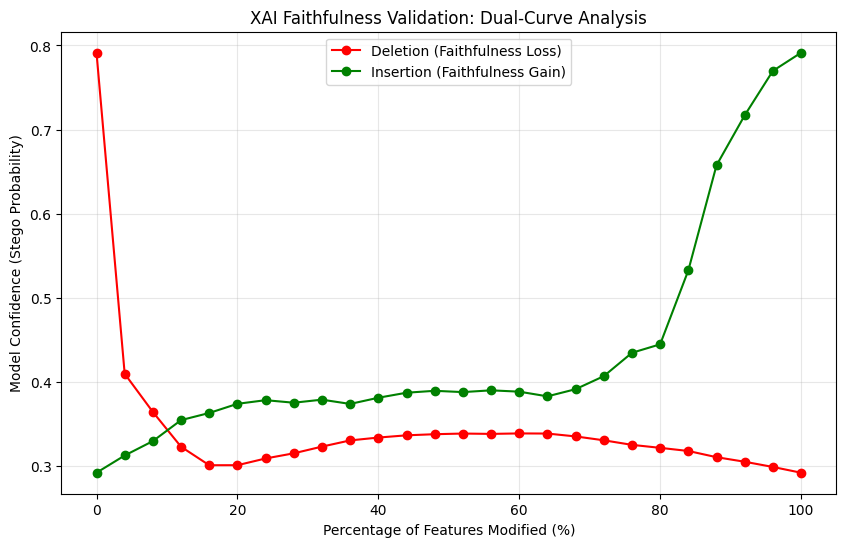

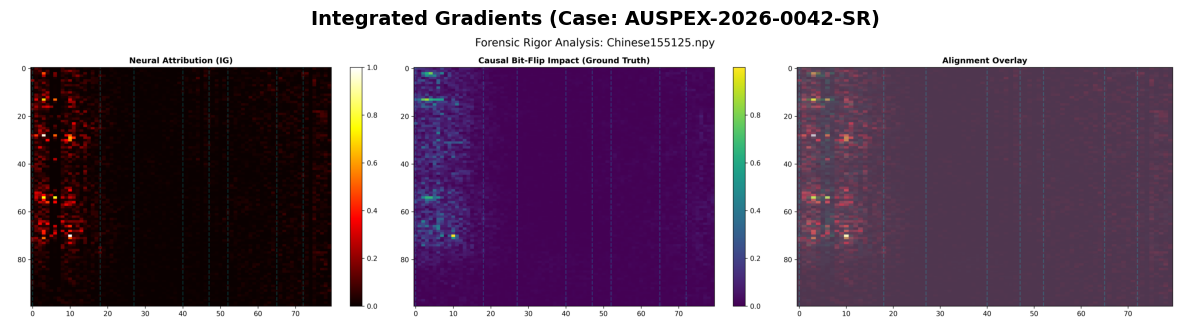


[ 3. FAITHFULNESS VALIDATION CURVE ]


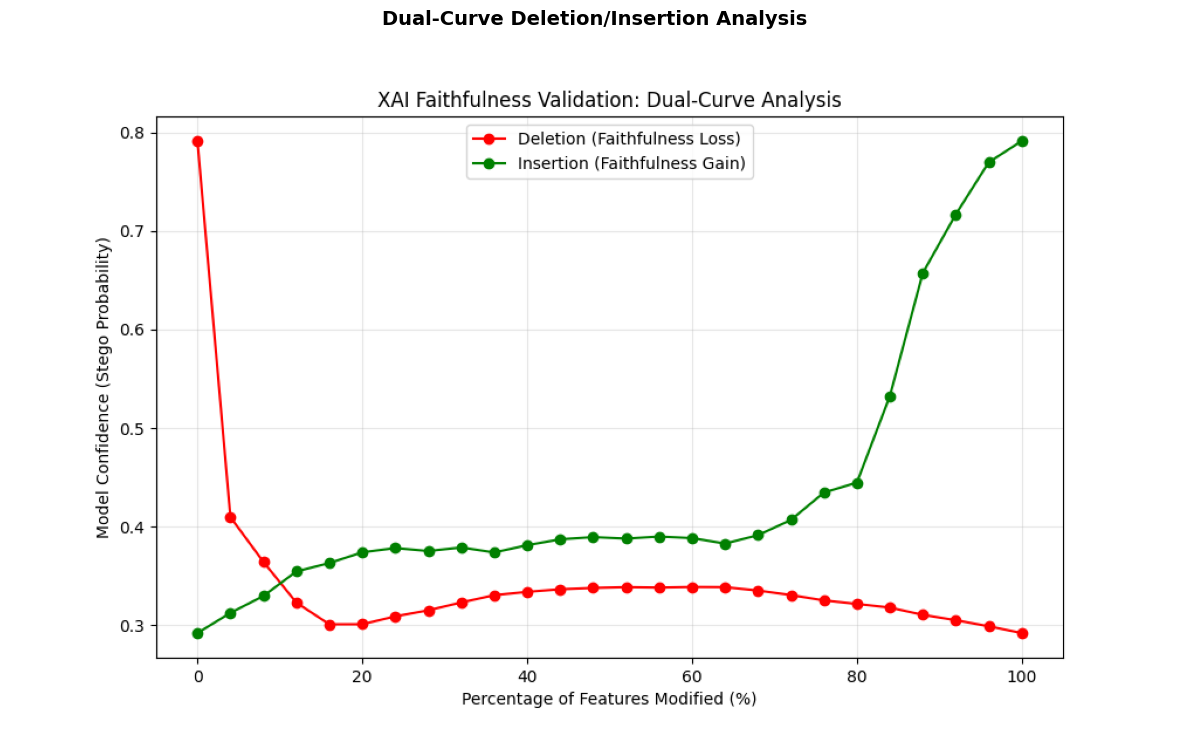


[ 4. AUDIT LOG (DATA PREVIEW) ]
----------------------------------------------------------------------------------------------------
             file category     prob    primary_anomaly  proc_duration_sec
English264042.npy       TP 0.531916   Gain_Codebook_G2           286.5339
Chinese154569.npy       TP 0.821471   Gain_Codebook_G2           288.7380
English257224.npy       FN 0.403507 Reserved_Signaling           288.6602
English261272.npy       FN 0.427078     Pitch_Delay_P2           290.4133
English261062.npy       TP 0.935132  Fixed_Codebook_C2           294.1948
English254074.npy       FN 0.465008   Gain_Codebook_G2           297.1735
Chinese146277.npy       FN 0.411670   LSP_Coefficients           298.7929
Chinese155110.npy       FN 0.512235     Pitch_Delay_P2           300.4353
English262588.npy       FN 0.298811 Reserved_Signaling           302.2918
English256358.npy       FN 0.519366     Pitch_Delay_P1           302.7047

END OF FORENSIC RECORD


[SUCCESS] FULL CONSOLE AUD

In [ ]:
if __name__ == "__main__":
    print(f"--- Auspex Forensic Consensus & Faithfulness Audit (Case ID: {CASE_ID}) ---")

    # Initialize model and auditor ONCE
    model = StegoCNN().to(DEVICE).eval()
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)['model_state_dict'])
    auditor = RigorousForensicAuditor(model, DEVICE, threshold=0.5229)

    # 1. PRE-ENRICH THE QUEUE WITH METADATA
    audit_queue = []

    # Process Stego Files
    stego_list = [f for f in os.listdir(os.path.join(TENSOR_DIR, "stego")) if f.endswith('.npy')][:NUM_AUDIT_SAMPLES//2]
    for f in stego_list:
        base_name = f.replace(".npy", "")
        info = global_test_meta.get(base_name, {'algo': 'UNKNOWN', 'rate': 0.0})
        audit_queue.append((f, 1, info['algo'], info['rate']))

    # Process Cover Files
    cover_list = [f for f in os.listdir(os.path.join(TENSOR_DIR, "cover")) if f.endswith('.npy')][:NUM_AUDIT_SAMPLES//2]
    for f in cover_list:
        audit_queue.append((f, 0, 'Cover', 0.0))

    results = []
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = {executor.submit(audit_single_sample, item, TENSOR_DIR, auditor): item for item in audit_queue}

        for future in tqdm(as_completed(futures), total=len(audit_queue), desc="AUSPEX Audit"):
            res = future.result()
            if res: results.append(res)

    # 2. REMOVE THE PD.CONCAT LOGIC
    if not results:
        print("CRITICAL: No results generated.")
    else:
        audit_df = pd.DataFrame(results) # No concatenation needed!


    # Compare CNV vs PMS
    cnv = audit_df[audit_df['algo'] == 'CNV']
    pms = audit_df[audit_df['algo'] == 'PMS']

    cnv_dist = cnv['primary_true_impact'].value_counts(normalize=True)
    pms_dist = pms['primary_true_impact'].value_counts(normalize=True)

    print("\n=== FORENSIC BEHAVIOR DIFFERENCE ===")
    print("CNV dominant regions:\n", cnv_dist.head())
    print("PMS dominant regions:\n", pms_dist.head())

    # Check for duplicate hashes (indicates evidence tampering or file duplication)
    duplicate_hashes = audit_df['md5'].duplicated().sum()
    integrity_status = "VERIFIED" if duplicate_hashes == 0 else "WARNING: COLLISIONS DETECTED"
    unique_fingerprints = audit_df['md5'].nunique()

    tp_data = audit_df[audit_df['category']=='TP']

    cross_stats = auditor.evaluate_cross_method(audit_df)
    print("\n=== CROSS-METHOD GENERALIZATION ===")
    print(cross_stats)

    if not tp_data.empty:
        auc_values = tp_data['auc_del_ig'].values

        mean_auc, ci_auc = auditor.confidence_interval(auc_values)
        bootstrap_std = auditor.bootstrap_metric(auc_values)

        print(f"\nDeletion AUC: {mean_auc:.4f} ± {ci_auc:.4f} (95% CI)")
        print(f"Bootstrap Stability (std): {bootstrap_std:.4f}")
        t_stat, p_val = ttest_rel(tp_data['auc_del_ig'], tp_data['auc_del_rand'])
        stego_consist = tp_data['primary_anomaly'].value_counts(normalize=True) * 100
        top_lead_param = stego_consist.idxmax()
        consistency_val = stego_consist.max()
    else:
        p_val, top_lead_param, consistency_val = 1.0, "N/A", 0.0

    failure_stats = audit_df.groupby('category').agg({
        'auc_del_ig': 'mean',
        'agreement_ig_occ': 'mean',
        'stab_0.01': 'mean',
        'stab_0.05': 'mean', # Added
        'stab_0.1': 'mean'   # Added
    }).to_string()

    os.makedirs("/content/case_studies", exist_ok=True)
    if not tp_data.empty:
        tp_top = tp_data.sort_values(by='prob', ascending=False).iloc[0]
        case_tensor = safe_tensor_load(
            os.path.join(TENSOR_DIR, "stego", tp_top['file'])
        )

        case_attr = auditor.get_attribution(case_tensor, "ig")
        case_bitflip = auditor.compute_bit_flip_impact(case_tensor) # Added causal step

        case_study_path = f"/content/case_studies/Case_{CASE_ID}_Visual.png"

        auditor.visualize_attribution(case_tensor, case_attr, case_bitflip, tp_top['file'], case_study_path)

    summary_text = f"""
======================================================================
AUSPEX RESEARCH-GRADE FORENSIC CONSENSUS & UTILITY REPORT
======================================================================
CASE INFORMATION
----------------------------------------------------------------------
Case ID: {CASE_ID} | Examiner: {EXAMINER_NAME}
Examination Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

1. EVIDENCE INTEGRITY & CONSENSUS
----------------------------------------------------------------------
Total Samples Examined: {len(audit_df)}
Verification Standard:  MD5 Hashing (Chain of Custody)
Chain of Custody:       {integrity_status} ({unique_fingerprints} Unique Hashes)
Inter-Method Agreement: {audit_df['agreement_ig_occ'].mean():.4f} (IG vs Occlusion)
Mean Processing Time:   {audit_df['proc_duration_sec'].mean():.4f}s / sample

2. FORENSIC CONSISTENCY & INVESTIGATIVE GUIDANCE
----------------------------------------------------------------------
Primary Anomaly:    {top_lead_param}
Global Consistency: {consistency_val:.2f}% (Concentration)
Insight: Mapping importance to G.729a codec parameters provides semantic
interpretability without requiring paired cover files.

3. ATTRIBUTION FAITHFULNESS VALIDATION (Dual-Curve Analysis)
----------------------------------------------------------------------
Mean Deletion AUC (TP): {tp_data['auc_del_ig'].mean() if not tp_data.empty else 0:.4f}
Mean Insertion AUC (TP): {tp_data['auc_ins_ig'].mean() if not tp_data.empty else 0:.4f}
Statistical Significance: p = {p_val:.4e}

4. SUFFICIENCY & IRRELEVANCE (Sanity Checks)
----------------------------------------------------------------------
Top-10% Sufficiency (Signal):    {audit_df['topk_sanity'].mean():.4f}
Bottom-10% Irrelevance (Noise):  {audit_df['bottomk_sanity'].mean():.4f}

5. FAILURE-CASE PERFORMANCE ANALYSIS
----------------------------------------------------------------------
{failure_stats}

6. EVIDENCE HASH LOG (First 5 Samples)
----------------------------------------------------------------------
{audit_df[['file', 'md5']].head().to_string(index=False)}


7. STATISTICAL CONFIDENCE & STABILITY
----------------------------------------------------------------------
Deletion AUC (Mean ± 95% CI): {mean_auc:.4f} ± {ci_auc:.4f}
Bootstrap Stability (Std):    {bootstrap_std:.4f}

8. CROSS-METHOD PERFORMANCE (CNV vs PMS)
----------------------------------------------------------------------
CNV Accuracy: {cross_stats['cnv_acc']:.4f}
PMS Accuracy: {cross_stats['pms_acc']:.4f}

9. CAUSAL VALIDATION (Neural vs. Bit-Flip)
----------------------------------------------------------------------
XAI/Causal Correlation: {audit_df['attr_vs_real_corr'].mean():.4f} (Spearman)
Ground Truth Anomaly:   {audit_df['primary_true_impact'].mode()[0]}

10. CONCLUSION
----------------------------------------------------------------------
This audit provides behavioral validation of the forensic framework.
Identified bitstream regions are mathematically necessary and
sufficient for model classifications, with high semantic consistency
found in the {top_lead_param} field.
======================================================================
"""

    print(summary_text)

    if not tp_data.empty:
        plt.figure(figsize=(10, 6))
        mean_del = np.mean(np.array(tp_data['ig_del_curve'].tolist()), axis=0)
        mean_ins = np.mean(np.array(tp_data['ig_ins_curve'].tolist()), axis=0)
        plt.plot(np.linspace(0, 100, 26), mean_del, 'r-o', label='Deletion (Faithfulness Loss)')
        plt.plot(np.linspace(0, 100, 26), mean_ins, 'g-o', label='Insertion (Faithfulness Gain)')
        plt.title("XAI Faithfulness Validation: Dual-Curve Analysis")
        plt.xlabel("Percentage of Features Modified (%)")
        plt.ylabel("Model Confidence (Stego Probability)")
        plt.legend(); plt.grid(True, alpha=0.3)
        plt.savefig(f"Forensic_Faithfulness_{CASE_ID}.png")
        curve_path = f"Forensic_Faithfulness_{CASE_ID}.png"

        render_full_visual_report(
            summary_text=summary_text,
            audit_df=audit_df,
            case_study_path=case_study_path if 'case_study_path' in locals() else None,
            curve_path=curve_path,
            CASE_ID=CASE_ID
        )
        audit_df.to_csv(f"Forensic_Evidence_Metadata_{CASE_ID}.csv", index=False)

        print("\n[SUCCESS] FULL CONSOLE AUDIT COMPLETE")

###**Verifying test data**

In [ ]:
import numpy as np
import pandas as pd
from collections import Counter

def run_forensic_sanity_check(dataset, meta_map):
    print("="*60)
    print("  AUSPEX DATA INTEGRITY AUDIT")
    print("="*60)

    # 1. Verify Sample Counts
    total_samples = len(dataset)
    labels = [s[1] for s in dataset.samples]
    label_counts = Counter(labels)

    print(f" Total Samples: {total_samples}")
    print(f"   -> Cover Files (Label 0): {label_counts[0]}")
    print(f"   -> Stego Files (Label 1): {label_counts[1]}")

    # 2. Verify Metadata Mapping (The QIM/CNV Check)
    stego_metadata = [m for m in dataset.metadata if m['is_stego']]
    algos = Counter([m['algo'] for m in stego_metadata])
    rates = Counter([m['rate'] for m in stego_metadata])

    print(f"\n Algorithm Distribution (Stego Only):")
    for algo, count in algos.items():
        print(f"   -> {algo}: {count} samples")

    print(f"\n Payload Distribution (Stego Only):")
    for rate, count in sorted(rates.items()):
        print(f"   -> {rate} bpc: {count} samples")

    # 3. Tensor Geometry Check
    idx = np.random.randint(0, total_samples)
    tensor, label = dataset[idx]

    print(f"\n Tensor Geometry Check:")
    print(f"   -> Shape: {tensor.shape} (Expected: [3, 100, 80])")
    print(f"   -> Data Type: {tensor.dtype}")
    print(f"   -> Value Range: Min={tensor.min():.2f}, Max={tensor.max():.2f}")

    # 4. Critical Logic Tests
    print(f"\n Logic Verification:")

    missing_meta = total_samples // 2 - len(stego_metadata)
    if missing_meta == 0:
        print("    PASS: Every stego file successfully matched a metadata row.")
    else:
        print(f"    FAIL: {missing_meta} stego files are missing metadata labels!")

    # Test for empty tensors
    if tensor.sum() == 0:
        print("    FAIL: Loaded tensor is empty (all zeros)!")
    else:
        print("    PASS: Tensor contains non-zero bitstream data.")

    print("="*60)

# Execute the audit
run_forensic_sanity_check(test_ds, global_test_meta)

  AUSPEX DATA INTEGRITY AUDIT
 Total Samples: 50000
   -> Cover Files (Label 0): 25000
   -> Stego Files (Label 1): 25000

 Algorithm Distribution (Stego Only):
   -> PMS: 12500 samples
   -> CNV: 12500 samples

 Payload Distribution (Stego Only):
   -> 0.1 bpc: 6000 samples
   -> 0.2 bpc: 6500 samples
   -> 0.3 bpc: 6000 samples
   -> 0.4 bpc: 6500 samples

 Tensor Geometry Check:
   -> Shape: torch.Size([3, 100, 80]) (Expected: [3, 100, 80])
   -> Data Type: torch.float32
   -> Value Range: Min=0.00, Max=1.00

 Logic Verification:
    PASS: Every stego file successfully matched a metadata row.
    PASS: Tensor contains non-zero bitstream data.


#**ALTERNATE BASELINES**

##**Model with psychoacoustic attention**

###**Residual / High pass emphasis layer**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualPathwayForensicLayer(nn.Module):
    def __init__(self):
        super().__init__()

        # Fixed kernels (1st, 2nd, 3rd order and spatial)
        self.register_buffer('kernel1', torch.tensor([[[[-1., 1.]]]], dtype=torch.float32))
        self.register_buffer('kernel2', torch.tensor([[[[-1., 2., -1.]]]], dtype=torch.float32))
        self.register_buffer('kernel3', torch.tensor([[[[-1., 3., -3., 1.]]]], dtype=torch.float32))
        self.register_buffer('kernel_spatial', torch.tensor([[[[-1., -1., -1.], [-1., 8., -1.], [-1., -1., -1.]]]], dtype=torch.float32))

        self.local_avg = nn.AvgPool2d(kernel_size=3, stride=1, padding=1)

        # Learnable Pathway
        self.learnable_filters = nn.Conv2d(1, 2, kernel_size=3, padding=1, bias=False)

        self.stability_filter = nn.Conv2d(1, 1, kernel_size=5, padding=2, bias=False)
        with torch.no_grad():
            # Initializing as a high-pass laplacian to act as a noise floor detector
            self.stability_filter.weight.fill_(-1.0)
            self.stability_filter.weight[:, :, 2, 2] = 24.0

    def forward(self, x):
        raw_bits = x[:, 0:1, :, :]

        # 1. Fixed Residuals
        res1 = F.pad(F.conv2d(raw_bits, self.kernel1, padding=0), (0, 1, 0, 0))
        res2 = F.pad(F.conv2d(raw_bits, self.kernel2, padding=0), (1, 1, 0, 0))
        res3 = F.pad(F.conv2d(raw_bits, self.kernel3, padding=0), (1, 2, 0, 0))
        res_sp = F.conv2d(raw_bits, self.kernel_spatial, padding=1)

        # 2. SSAB (Second-Order)
        l_var1 = self.local_avg(res1**2)
        l_var2 = self.local_avg(res2**2)
        cross_corr = self.local_avg(res1 * res2)

        # 3. Stability Channel (Noise Floor)
        stability_map = torch.abs(self.stability_filter(raw_bits))

        # 4. Learnable Pathway
        learned_res = self.learnable_filters(raw_bits)

        # Total Channels: 4(res) + 2(var) + 1(corr) + 1(stability) + 2(learned) = 10
        features = torch.cat([res1, res2, res3, res_sp, l_var1, l_var2, cross_corr, stability_map, learned_res], dim=1)
        return features, stability_map

###**Psychoacoustic attention layer**

In [ ]:
class PsychoacousticAttention(nn.Module):
    def __init__(self, channels, freq_bins, kernel_size=7):
        super().__init__()
        # Note: 'channels' is included for future scaling, though currently use 3 stats
        self.conv = nn.Conv2d(3, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.freq_weight = nn.Parameter(torch.ones(1, 1, freq_bins, 1))
        nn.init.trunc_normal_(self.freq_weight, mean=1.0, std=0.1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        std_out = torch.std(x, dim=1, keepdim=True)

        combined = torch.cat([avg_out, max_out, std_out], dim=1)
        spatial_attn = self.conv(combined)

        weighted_attn = spatial_attn * self.freq_weight
        attn_weights = self.sigmoid(weighted_attn)

        return x * attn_weights, attn_weights

###**Depthwise convolution, Residual Blocks, SE Blocks, CNN**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================================
# 1. ARCHITECTURE COMPONENTS
# ============================================================================

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class GlobalSoftPooling(nn.Module):
    def forward(self, x):
        b, c, h, w = x.size()
        softmax_weights = F.softmax(x.view(b, c, -1), dim=-1).view(b, c, h, w)
        return torch.sum(x * softmax_weights, dim=(2, 3))

# ============================================================================
# 2. MAIN MODEL
# ============================================================================

class StegoCNN(nn.Module):
    def __init__(self, input_height=100):
        super().__init__()
        self.hp_layer = DualPathwayForensicLayer()
        self.init_conv = nn.Sequential(
            nn.Conv2d(13, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU()
        )
        self.pool1 = nn.MaxPool2d(2, 2)
        self.dw_conv = DepthwiseSeparableConv(32, 64)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.attention = PsychoacousticAttention(channels=64, freq_bins=input_height // 4)

        self.res_block1 = ResidualBlock(64)
        self.se1 = SEBlock(64)
        self.res_block2 = ResidualBlock(64)
        self.se2 = SEBlock(64)
        self.soft_pool = GlobalSoftPooling()
        self.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(64, 1))

    def forward(self, x):
        hp_features, stability_map = self.hp_layer(x)
        x_combined = torch.cat([x, hp_features], dim=1)
        x_feat = self.pool2(self.dw_conv(self.pool1(self.init_conv(x_combined))))

        x_feat, attn_weights = self.attention(x_feat)

        # Reliability Index Logic
        stab_resized = F.interpolate(stability_map, size=attn_weights.shape[2:], mode='bilinear', align_corners=False)
        reliability_index = torch.mean(attn_weights, dim=(1,2,3)) / (torch.mean(stab_resized, dim=(1,2,3)) + 1e-6)

        x_feat = self.se2(self.res_block2(self.se1(self.res_block1(x_feat))))
        logits = self.fc(self.soft_pool(x_feat))
        return logits, attn_weights, reliability_index

if __name__ == "__main__":
    model = StegoCNN(input_height=100)
    dummy_input = torch.randn(32, 3, 100, 80)
    output, attention, ri = model(dummy_input)
    print(f"Output Logits Shape: {output.shape}")
    print(f"Reliability Index (First 5): {ri[:5].tolist()}")

Output Logits Shape: torch.Size([32, 1])
Reliability Index (First 5): [0.02659195102751255, 0.026092231273651123, 0.027251524850726128, 0.026347339153289795, 0.026448586955666542]


###**Parameter count**

In [ ]:
# ========================================================
# LIGHTWEIGHT AUDIT FOR StegoCNN
# ========================================================
def audit_stegocnn(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Calculate Memory Size
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
    size_all_mb = (param_size + buffer_size) / 1024**2

    print(f"--- StegoCNN Audit Results ---")
    print(f"Total Parameters:      {total_params:,}")
    print(f"Trainable Parameters:  {trainable_params:,}")
    print(f"Model Size (RAM/Disk): {size_all_mb:.4f} MB")
    print("-" * 30)

# Initialize and run
model = StegoCNN(input_height=100)
audit_stegocnn(model)

--- StegoCNN Audit Results ---
Total Parameters:      171,256
Trainable Parameters:  171,256
Model Size (RAM/Disk): 0.6568 MB
------------------------------


###**Training per epoch**

In [ ]:
from google.colab import userdata

comet_api_key = userdata.get('comet_api_key')

In [ ]:
import comet_ml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import os
import glob
import pandas as pd
import time
import shutil
from tqdm import tqdm
from collections import defaultdict
from sklearn.metrics import roc_curve

# =====================================================
# 1. CONFIGURATION
# =====================================================
COMET_API_KEY = comet_api_key
CHECKPOINT_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Refined_1"
PER_SEED_HISTORY_DIR = "/content/temp_seed_histories"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PER_SEED_HISTORY_DIR, exist_ok=True)

NUM_EPOCHS = 72
LR = 1.0e-04
GRADIENT_CLIP = 1.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weight = torch.tensor([1.05]).to(device)
smoothing = 0.1


# =====================================================
# 2. UTILITIES
# =====================================================

def find_best_threshold(labels, probs):
    fpr, tpr, thresholds = roc_curve(labels, probs)
    # Youden's J statistic: sensitivity + specificity - 1
    optimal_idx = np.argmax(tpr - fpr)
    return thresholds[optimal_idx]

def collect_probs_labels(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for matrices, labels in loader:
            matrices = matrices.to(device)
            logits, attn, ri = model(matrices)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels).flatten(), np.array(all_probs).flatten()

def finalize_forensic_threshold(model, val_loader):
    labels, probs = collect_probs_labels(model, val_loader)
    final_thr = find_best_threshold(labels, probs)
    return final_thr

def save_artifacts_to_drive():
    """Safety: Syncs local progress to Google Drive."""
    print(" Syncing logs to Drive...")
    drive_hist = os.path.join(CHECKPOINT_DIR, "per_seed_histories")
    os.makedirs(drive_hist, exist_ok=True)
    if os.path.exists(PER_SEED_HISTORY_DIR):
        for csv_file in glob.glob(os.path.join(PER_SEED_HISTORY_DIR, "*.csv")):
            shutil.copy(csv_file, drive_hist)

def get_latest_checkpoint(seed, variant_name):
    pattern = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_epoch*.pt")
    files = glob.glob(pattern)
    return max(files, key=os.path.getmtime) if files else None

# =====================================================
# 3. CORE TRAINING FUNCTION
# =====================================================

def train_and_evaluate(seed, variant_name, model_constructor, train_loader, val_loader, full_dataset):
    experiment = comet_ml.Experiment(api_key=COMET_API_KEY, project_name="stego-detection-3channel")
    experiment.set_name(f"{variant_name}_seed{seed}")
    EARLY_STOP_PATIENCE = 100


    hyper_params = {
        "learning_rate": LR,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "seed": seed,
        "gradient_clip": GRADIENT_CLIP,
        "optimizer": "AdamW",
        "scheduler": "CosineAnnealingLR",
        "weight_decay": 0.00019,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "pos_weight": pos_weight.item(),
        "label_smoothing": smoothing,
    }
    experiment.log_parameters(hyper_params)

    torch.manual_seed(seed)
    model = model_constructor().to(device)

    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1.01e-03)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='mean')

    best_val_auc = -1.0
    patience_counter = 0

    history = defaultdict(list)
    start_epoch = 0

    latest_ckpt = get_latest_checkpoint(seed, variant_name)
    if latest_ckpt:
        print(f" Resuming from: {latest_ckpt}")
        ckpt = torch.load(latest_ckpt, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict']) # Added this
        start_epoch = ckpt['epoch']
        best_val_auc = ckpt.get('best_val_auc', -1.0)

    for epoch in range(start_epoch, NUM_EPOCHS):
        # --- TRAIN PHASE ---
        model.train()
        t_probs, t_labels, t_loss_run = [], [], 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN]")
        for matrices, labels in pbar:
            matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
            # label smoothing
            smoothed_labels = labels * (1 - smoothing) + 0.5 * smoothing
            optimizer.zero_grad()
            logits, attn, ri = model(matrices)
            loss = criterion(logits, smoothed_labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            optimizer.step()

            t_loss_run += loss.item() * matrices.size(0)
            t_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            t_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # --- VALIDATION PHASE ---
        model.eval()
        v_probs, v_labels, v_loss_run = [], [], 0.0
        v_ri_acc=0.0
        with torch.no_grad():
            for matrices, labels in val_loader:
                matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
                logits, attn, ri = model(matrices)
                v_loss_run += criterion(logits, labels).item() * matrices.size(0)
                v_probs.extend(torch.sigmoid(logits).cpu().numpy())
                v_labels.extend(labels.cpu().numpy())
                v_ri_acc += ri.mean().item()

        current_ri = v_ri_acc / len(val_loader) # <--- FIX 3: Define average RI
        experiment.log_metric("avg_reliability_index", current_ri, step=epoch)

        scheduler.step()

        # Metric Calculations
        def get_metrics(l, p):
            l, p = np.array(l).flatten(), np.array(p).flatten()
            fixed_thr = 0.5
            preds = (p >= fixed_thr).astype(int)

            return {
                "acc": accuracy_score(l, preds) * 100,
                "f1": f1_score(l, preds, zero_division=0),
                "pre": precision_score(l, preds, zero_division=0),
                "rec": recall_score(l, preds, zero_division=0),
                "auc": roc_auc_score(l, p) if len(np.unique(l)) > 1 else 0.0
            }

        tm = get_metrics(t_labels, t_probs)
        vm = get_metrics(v_labels, v_probs)

        # --- THE PRINT STATEMENT ---
        print(f"\n" + "="*50)
        print(f" EPOCH {epoch+1} REPORT")
        print(f"="*50)
        print(f"METRIC    | TRAIN      | VALIDATION")
        print(f"----------|------------|-----------")
        print(f"LOSS      | {t_loss_run/len(t_labels):.4f}     | {v_loss_run/len(v_labels):.4f}")
        print(f"ACCURACY  | {tm['acc']:.2f}%     | {vm['acc']:.2f}%")
        print(f"F1-SCORE  | {tm['f1']:.4f}     | {vm['f1']:.4f}")
        print(f"PRECISION | {tm['pre']:.4f}     | {vm['pre']:.4f}")
        print(f"RECALL    | {tm['rec']:.4f}     | {vm['rec']:.4f}")
        print(f"AUC       | {tm['auc']:.4f}     | {vm['auc']:.4f}")
        print(f"RELIABILITY| --------   | {current_ri:.4f}") # Add this line
        print(f"="*50 + "\n")

        epoch_stats = {f"t_{k}": v for k, v in tm.items()}
        epoch_stats.update({f"v_{k}": v for k, v in vm.items()})
        epoch_stats.update({"t_loss": t_loss_run/len(t_labels), "v_loss": v_loss_run/len(v_labels)})

        for k, v in epoch_stats.items(): history[k].append(v)
        experiment.log_metrics(epoch_stats, step=epoch)

        # --- SAVE EVERY EPOCH ---
        ckpt_data = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(), # Added for reproducibility
            'history': dict(history),
            'best_val_auc': best_val_auc
        }

        # Save epoch checkpoint
        epoch_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_epoch{epoch+1:03d}.pt")
        torch.save(ckpt_data, epoch_ckpt_path)

        # --- NEW: EARLY STOPPING LOGIC ---
        if vm['auc'] > best_val_auc:
            best_val_auc = vm['auc']
            patience_counter = 0

            best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_best.pt")
            torch.save(ckpt_data, best_ckpt_path)
            print(f"  New Best Validation AUC: {best_val_auc:.4f} (Model Saved!)")
        else:
            patience_counter += 1
            print(f"  Early Stopping Counter: {patience_counter}/{EARLY_STOP_PATIENCE}")

        pd.DataFrame(history).to_csv(os.path.join(PER_SEED_HISTORY_DIR, f"{variant_name}_seed{seed}_history.csv"), index=False)
        save_artifacts_to_drive()

        # Trigger Early Stop
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\n EARLY STOPPING TRIGGERED! No improvement in Validation AUC for {EARLY_STOP_PATIENCE} epochs.")
            print(f"Restoring weights from the best epoch...")
            break
    experiment.end()


if __name__ == "__main__":
    variant = "Auspex_Forensic_Final_Refined_1"
    seed = 42

    def my_model_builder():
        return StegoCNN()

    train_and_evaluate(seed, variant, my_model_builder,
                       train_loader, val_loader, full_dataset)

    print("\n" + "="*50)
    print(" TRAINING COMPLETE. FINALIZING FORENSIC THRESHOLD...")
    print("="*50)

    best_model = my_model_builder().to(device)
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant}_seed{seed}_best.pt")

    if os.path.exists(best_ckpt_path):
        checkpoint = torch.load(best_ckpt_path, map_location=device, weights_only=False)
        best_model.load_state_dict(checkpoint['model_state_dict'])

        final_thr = finalize_forensic_threshold(best_model, val_loader)

        print(f"\n[FORENSIC ANALYSIS COMPLETE]")
        print(f"Optimal Forensic Threshold (Youden's J): {final_thr:.4f}")
        print(f"Any probability >= {final_thr:.4f} is classified as STEGO.")
        print("="*50)

        with open(os.path.join(CHECKPOINT_DIR, "forensic_threshold.txt"), "w") as f:
            f.write(str(final_thr))
    else:
        print(f"Error: Could not find best checkpoint at {best_ckpt_path}")

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: Experiment is live on comet.com https://www.comet.com/maryam-sarah/stego-detection-3channel/79b3718242214b889c6d2cc0b3f34bbb



 Resuming from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Refined_1/Auspex_Forensic_Final_Refined_1_seed42_epoch072.pt


COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Auspex_Forensic_Final_Refined_1_seed42
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/stego-detection-3channel/79b3718242214b889c6d2cc0b3f34bbb
COMET INFO:   Others:
COMET INFO:     Name         : Auspex_Forensic_Final_Refined_1_seed42
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#fileId=1VflRXk4GiCXWrxJ2XpWAWJbsvqBCyT2a
COMET INFO:   Parameters:
COMET INFO:     batch_size          : 128
COMET INFO:     early_stop_patience : 100
COMET INFO:     epochs              : 72
COMET INF


 TRAINING COMPLETE. FINALIZING FORENSIC THRESHOLD...

[FORENSIC ANALYSIS COMPLETE]
Optimal Forensic Threshold (Youden's J): 0.5401
Any probability >= 0.5401 is classified as STEGO.


###**Testing**

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# --- 1. CONFIGURATION ---
TEST_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test"
LOCAL_TEMP = "/content/test_processing"
RAW_EXTRACT = os.path.join(LOCAL_TEMP, "raw_audios")
TENSOR_DIR = os.path.join(LOCAL_TEMP, "3channel_tensors")

os.makedirs(RAW_EXTRACT, exist_ok=True)
os.makedirs(os.path.join(TENSOR_DIR, "cover"), exist_ok=True)
os.makedirs(os.path.join(TENSOR_DIR, "stego"), exist_ok=True)

# --- 2. EXTRACT RAR FILES  ---
print(" Extracting Test RARs to local disk...")
!unrar x -o+ "{TEST_BASE}/g729a_0.rar" "{RAW_EXTRACT}/cover/"
!unrar x -o+ "{TEST_BASE}/g729a_Steg.rar" "{RAW_EXTRACT}/stego/"

# --- 3. CONVERSION FUNCTIONS ---
def process_to_3channel(src_path, dst_path):
    try:
        with open(src_path, 'rb') as f:
            data = f.read(1000)
        bits = np.unpackbits(np.frombuffer(data, dtype=np.uint8)).reshape(100, 80).astype(np.float32)

        # Channel 2: Temporal Diff
        diff = np.zeros_like(bits)
        diff[1:] = np.abs(bits[1:] - bits[:-1])

        # Channel 3: Stability
        mean_bits = np.mean(bits, axis=0, keepdims=True)
        stability = np.abs(bits - mean_bits)

        # Stack and Save
        multi_channel = np.stack([bits, diff, stability], axis=0)
        np.save(dst_path, multi_channel)
        return True
    except Exception as e:
        return False

print("\n Converting Test Audios to 3-Channel Tensors...")
for sub in ['cover', 'stego']:
    src_dir = os.path.join(RAW_EXTRACT, sub)

    # Robust Path Check: handles nested folders created by unrar
    if not os.path.exists(src_dir):
        print(f" Warning: {src_dir} not found. Skipping.")
        continue

    # Check if files are hidden in a nested subfolder (e.g., cover/cover/)
    sub_content = os.listdir(src_dir)
    if len(sub_content) == 1 and os.path.isdir(os.path.join(src_dir, sub_content[0])):
        actual_src = os.path.join(src_dir, sub_content[0])
    else:
        actual_src = src_dir

    dst_dir = os.path.join(TENSOR_DIR, sub)
    files = [f for f in os.listdir(actual_src) if f.endswith('.g729a')]

    if not files:
        print(f" No .g729a files found in {actual_src}")
        continue

    for fname in tqdm(files, desc=f"Processing {sub}"):
        process_to_3channel(os.path.join(actual_src, fname),
                            os.path.join(dst_dir, fname.replace('.g729a', '.npy')))

print("\n Test data ready in:", TENSOR_DIR)

Streaming output truncated to the last 5000 lines.
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267063.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267065.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267068.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267070.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267071.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267072.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267073.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267074.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267075.g729a 

Processing stego: 100%|██████████| 25000/25000 [00:32<00:00, 776.26it/s] 


 Test data ready in: /content/test_processing/3channel_tensors


###**Stratified evaluation**

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, accuracy_score

TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"

def load_test_metadata_map(excel_path):
    print("\n Loading Test Set Metadata (6 Tabs)...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)

    stego_tabs = [
        "test_lable_english_CNV", "test_lable_english_PMS",
        "test_lable_chinese_CNV", "test_lable_chinese_PMS"
    ]

    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue

        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                raw_algo = str(row.iloc[1]).strip()
                algo = "CNV" if raw_algo == "QIM" else raw_algo

                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0

                meta_map[fname] = {'algo': algo, 'rate': rate}

    print(f"  Loaded metadata for {len(meta_map)} stego files.")
    return meta_map

# Load it
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

def extract_metadata_for_indices(full_dataset, indices, meta_map):
    """
    Extract metadata for dataset indices.
    Works with ConcatDataset([cover_dataset, stego_dataset])
    """
    metadata_list = []

    # Access underlying datasets
    cover_ds = full_dataset.datasets[0]
    stego_ds = full_dataset.datasets[1]
    n_covers = len(cover_ds)

    for idx in indices:
        if idx < n_covers:
            # Cover sample
            path = cover_ds.files[idx]
            is_stego = False
        else:
            # Stego sample
            local_idx = idx - n_covers
            path = stego_ds.files[local_idx]
            is_stego = True

        base_name = os.path.basename(path).replace(".npy", "")

        if is_stego and base_name in meta_map:
            info = meta_map[base_name]
        else:
            info = {'algo': 'Cover', 'rate': 0.0}

        metadata_list.append({
            'base_name': base_name,
            'is_stego': is_stego,
            'algo': info['algo'],
            'rate': info['rate']
        })

    return metadata_list


def evaluate_stratified(model, loader, metadata_list, device='cuda', threshold=0.5401):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    # Collect predictions
    with torch.no_grad():
        for matrix, label in loader:
            matrices = matrix.to(device)
            label = label.to(device)

            # Unpack the 3 forensic returns
            logits, attn, ri = model(matrices)

            probs = torch.sigmoid(logits).view(-1)
            preds = (probs >= threshold).float()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(label.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    metadata_df = pd.DataFrame(metadata_list)

    # ===== OVERALL METRICS =====
    results = {
        'overall': {
            'accuracy': accuracy_score(all_labels, all_preds),
            'precision': precision_score(all_labels, all_preds, zero_division=0),
            'recall': recall_score(all_labels, all_preds, zero_division=0),
            'f1': f1_score(all_labels, all_preds, zero_division=0),
            'auc': roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.0,
            'confusion_matrix': confusion_matrix(all_labels, all_preds).tolist()
        }
    }

    # ===== PER-ALGORITHM METRICS =====
    results['per_algorithm'] = {}
    for algo in ['CNV', 'PMS']:
        mask = ((metadata_df['algo'] == algo) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            a_preds, a_labels, a_probs = all_preds[mask], all_labels[mask], all_probs[mask]
            results['per_algorithm'][algo] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(a_labels, a_preds), # ADDED
                'precision': precision_score(a_labels, a_preds, zero_division=0),
                'recall': recall_score(a_labels, a_preds, zero_division=0),
                'f1': f1_score(a_labels, a_preds, zero_division=0),
                'auc': roc_auc_score(a_labels, a_probs) if len(np.unique(a_labels)) > 1 else 0.0
            }

    # ===== PER-PAYLOAD METRICS =====
    results['per_payload'] = {}
    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((metadata_df['rate'] == rate) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            r_preds, r_labels, r_probs = all_preds[mask], all_labels[mask], all_probs[mask]
            results['per_payload'][f'{rate:.1f}'] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(r_labels, r_preds), # ADDED
                'precision': precision_score(r_labels, r_preds, zero_division=0),
                'recall': recall_score(r_labels, r_preds, zero_division=0),
                'f1': f1_score(r_labels, r_preds, zero_division=0),
                'auc': roc_auc_score(r_labels, r_probs) if len(np.unique(r_labels)) > 1 else 0.0
            }

    # ===== PER-ALGORITHM-PAYLOAD COMBINATION =====
    results['per_algo_payload'] = {}
    for algo in ['CNV', 'PMS']:
        for rate in [0.1, 0.2, 0.3, 0.4]:
            mask = (((metadata_df['algo'] == algo) & (metadata_df['rate'] == rate)) | (~metadata_df['is_stego'])).values
            if mask.sum() > 10:
                c_preds, c_labels, c_probs = all_preds[mask], all_labels[mask], all_probs[mask]
                key = f'{algo}_{rate:.1f}'
                results['per_algo_payload'][key] = {
                    'n_samples': int(mask.sum()),
                    'acc': accuracy_score(c_labels, c_preds), # ADDED
                    'precision': precision_score(c_labels, c_preds, zero_division=0),
                    'recall': recall_score(c_labels, c_preds, zero_division=0),
                    'f1': f1_score(c_labels, c_preds, zero_division=0),
                    'auc': roc_auc_score(c_labels, c_probs) if len(np.unique(c_labels)) > 1 else 0.0
                }

    return results


def print_stratified_results(results):
    """Pretty-print stratified evaluation results."""

    print("\n" + "="*110)
    print("STRATIFIED EVALUATION RESULTS")
    print("="*110)

    # Overall
    print("\n OVERALL PERFORMANCE")
    print("-" * 110)
    o = results['overall']
    print(f"Accuracy:  {o['accuracy']:.4f} | Precision: {o['precision']:.4f} | Recall: {o['recall']:.4f} | F1: {o['f1']:.4f} | AUC: {o['auc']:.4f}")
    print(f"Confusion Matrix:\n{np.array(o['confusion_matrix'])}")

    # Per Algorithm
    print("\n PER-ALGORITHM PERFORMANCE")
    print("-" * 110)
    print(f"{'Algorithm':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for algo, m in results['per_algorithm'].items():
        print(f"{algo:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    # Per Payload
    print("\n PER-PAYLOAD PERFORMANCE")
    print("-" * 110)
    print(f"{'Payload':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for rate, m in sorted(results['per_payload'].items()):
        print(f"{rate:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    # Per Algorithm-Payload Combination
    print("\n PER-ALGORITHM-PAYLOAD COMBINATION")
    print("-" * 110)
    print(f"{'Algo_Rate':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for key, m in sorted(results['per_algo_payload'].items()):
        print(f"{key:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    print("=" * 110 + "\n")


 Loading Test Set Metadata (6 Tabs)...
  Loaded metadata for 25000 stego files.


In [ ]:
# --- 1. DATASET DEFINITION ---
class FinalBenchmarkDataset(Dataset):
    def __init__(self, root_dir, meta_map):
        self.samples = []
        self.metadata = []

        for label, sub in enumerate(['cover', 'stego']):
            sub_dir = os.path.join(root_dir, sub)
            for f in sorted(os.listdir(sub_dir)):
                if f.endswith('.npy'):
                    base_name = f.replace('.npy', '')
                    self.samples.append((os.path.join(sub_dir, f), label))

                    if label == 1 and base_name in meta_map:
                        info = meta_map[base_name]
                        self.metadata.append({'base_name': base_name, 'algo': info['algo'], 'rate': info['rate'], 'is_stego': True})
                    else:
                        self.metadata.append({'base_name': base_name, 'algo': 'Cover', 'rate': 0.0, 'is_stego': False})

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return torch.from_numpy(np.load(path)), torch.tensor(label, dtype=torch.long)

# --- 1. SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# A. Instantiate the Dataset
test_ds = FinalBenchmarkDataset(TENSOR_DIR, global_test_meta)

# B. Instantiate the DataLoader
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f" Dataset initialized with {len(test_ds)} samples.")

# C. Load the Model
model = StegoCNN().to(device)
STANDARD_BEST_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Refined_1/Auspex_Forensic_Final_Refined_1_seed42_best.pt"

print(f" Loading Standard Best Model: {STANDARD_BEST_PATH}")
checkpoint = torch.load(STANDARD_BEST_PATH, map_location=device, weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(" Standard weights loaded. Checking for signs of life...")

# --- 2. QUICK SANITY CHECK ---
with torch.no_grad():
    for i in range(5):
        tensor, label = test_ds[i]
        # LOGITS, ATTENTION, and RELIABILITY
        logits, attn, ri = model(tensor.unsqueeze(0).to(device))
        prob = torch.sigmoid(logits).item()
        print(f"Sample {i} | Label: {label} | Pred Prob: {prob:.4f} | Reliability: {ri.item():.4f}")

# --- 3. EVALUATE ---
current_threshold = final_thr if 'final_thr' in locals() else 0.5401
print(f"\n Performing Stratified Evaluation (Threshold: {current_threshold:.4f})...")

# CRITICAL: Ensure evaluate_stratified is also updated to unpack 3 values inside!
results = evaluate_stratified(model, test_loader, test_ds.metadata, device=device, threshold=current_threshold)
print_stratified_results(results)

 Dataset initialized with 50000 samples.
 Loading Standard Best Model: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Refined_1/Auspex_Forensic_Final_Refined_1_seed42_best.pt
 Standard weights loaded. Checking for signs of life...
Sample 0 | Label: 0 | Pred Prob: 0.5104 | Reliability: 0.0142
Sample 1 | Label: 0 | Pred Prob: 0.4696 | Reliability: 0.0137
Sample 2 | Label: 0 | Pred Prob: 0.4364 | Reliability: 0.0131
Sample 3 | Label: 0 | Pred Prob: 0.6077 | Reliability: 0.0136
Sample 4 | Label: 0 | Pred Prob: 0.4711 | Reliability: 0.0134

 Performing Stratified Evaluation (Threshold: 0.5401)...

STRATIFIED EVALUATION RESULTS

 OVERALL PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Accuracy:  0.6658 | Precision: 0.7258 | Recall: 0.5330 | F1: 0.6147 | AUC: 0.7275
Confusion Matrix:
[[19965  5035]
 [11674 13326]]

 PER-ALGORITHM PERFORMANCE
-------------

##**9978 samples - model with no high-pass layer**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================================
# 1. ARCHITECTURE COMPONENTS
# ============================================================================

class DepthwiseSeparableConv(nn.Module):
    """Slashes parameter count for real-time inference."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                   padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)

        # Pointwise: 1x1 convolution to mix the channels
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class ResidualBlock(nn.Module):
    """Deepens the network without vanishing gradients."""
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual  # Skip connection
        return F.relu(out)

class SpatialAttention(nn.Module):
    """Generates the XAI Heatmap for forensic review."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Compress channels down to Average and Max pooling maps
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)

        # Generate a 1-channel attention mask
        out = self.conv(out)
        attn_weights = self.sigmoid(out)

        # Apply mask to the features
        return x * attn_weights, attn_weights

# ============================================================================
# 2. MAIN UNIVERSAL STEGANALYSIS MODEL
# ============================================================================

class UniversalStegoCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # --- 1. Initial Processing (3 -> 16 channels) ---
        self.init_conv = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # Compresses 100x80 -> 50x40
        )

        # --- 2. Depthwise Separable (16 -> 32 channels) ---
        self.dw_conv = DepthwiseSeparableConv(16, 32)
        self.pool2 = nn.MaxPool2d(2, 2)  # Compresses 50x40 -> 25x20

        # --- 3. Residual Block ---
        self.res_block = ResidualBlock(32)

        # --- 4. Attention Layer ---
        self.attention = SpatialAttention()

        # --- 5. Global Average Pooling ---
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # --- 6. Classification Head ---
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.init_conv(x)
        x = self.pool2(self.dw_conv(x))
        x = self.res_block(x)

        # Pass through attention and save the weights
        x, attn_weights = self.attention(x)

        # Flatten and classify
        x = self.gap(x)
        x = torch.flatten(x, 1)
        out = self.fc(x)

        return out, attn_weights

# --- QUICK SANITY CHECK ---
if __name__ == "__main__":
    model = UniversalStegoCNN()

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Trainable Parameters: {total_params:,}")

    dummy_input = torch.randn(32, 3, 100, 80)
    output, attention_map = model(dummy_input)

    print(f"Model Output Shape: {output.shape} -> Expected: [32, 1]")
    print(f"Attention Map Shape: {attention_map.shape} -> Expected: [32, 1, 25, 20]")

Total Trainable Parameters: 19,907
Model Output Shape: torch.Size([32, 1]) -> Expected: [32, 1]
Attention Map Shape: torch.Size([32, 1, 25, 20]) -> Expected: [32, 1, 25, 20]


###**Training per epoch**

In [ ]:
from google.colab import userdata

comet_api_key = userdata.get('comet_api_key')

In [ ]:
import comet_ml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import os
import glob
import pandas as pd
import time
import shutil
from tqdm import tqdm
from collections import defaultdict

# =====================================================
# 1. CONFIGURATION
# =====================================================
COMET_API_KEY = comet_api_key
CHECKPOINT_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_v8_No_Initial_Drop"
PER_SEED_HISTORY_DIR = "/content/temp_seed_histories"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PER_SEED_HISTORY_DIR, exist_ok=True)

NUM_EPOCHS = 50
LR = 1e-3
GRADIENT_CLIP = 1.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# 2. UTILITIES
# =====================================================

def save_artifacts_to_drive():
    """Safety: Syncs local progress to Google Drive."""
    print(" Syncing logs to Drive...")
    drive_hist = os.path.join(CHECKPOINT_DIR, "per_seed_histories")
    os.makedirs(drive_hist, exist_ok=True)
    if os.path.exists(PER_SEED_HISTORY_DIR):
        for csv_file in glob.glob(os.path.join(PER_SEED_HISTORY_DIR, "*.csv")):
            shutil.copy(csv_file, drive_hist)

def find_best_threshold(labels, probs):
    """Forensic: Finds decision point that maximizes F1."""
    best_thr, best_f1 = 0.5, -1
    for thr in np.arange(0.1, 0.9, 0.05):
        preds = (probs >= thr).astype(int)
        f1 = f1_score(labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return best_thr

def get_latest_checkpoint(seed, variant_name):
    pattern = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_epoch*.pt")
    files = glob.glob(pattern)
    return max(files, key=os.path.getmtime) if files else None

# =====================================================
# 3. CORE TRAINING FUNCTION
# =====================================================

def train_and_evaluate(seed, variant_name, model_constructor, train_loader, val_loader, test_loader, full_dataset):
    experiment = comet_ml.Experiment(api_key=COMET_API_KEY, project_name="stego-detection-3channel")
    experiment.set_name(f"{variant_name}_seed{seed}")

    torch.manual_seed(seed)
    model = model_constructor().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.002)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
    criterion = nn.BCEWithLogitsLoss(pos_weight=None)

    best_val_f1 = -1
    start_epoch = 0
    history = defaultdict(list)

    latest_ckpt = get_latest_checkpoint(seed, variant_name)
    if latest_ckpt:
        print(f" Resuming from: {latest_ckpt}")
        ckpt = torch.load(latest_ckpt, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        start_epoch = ckpt['epoch']
        best_val_f1 = ckpt.get('best_val_f1', -1)
        history.update(ckpt.get('history', {}))

    for epoch in range(start_epoch, NUM_EPOCHS):
        # --- TRAIN PHASE ---
        model.train()
        t_probs, t_labels, t_loss_run = [], [], 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN]")
        for matrices, labels in pbar:
            matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
            optimizer.zero_grad()
            logits, _ = model(matrices)
            smoothed_labels = labels * (1 - 0.1) + 0.5 * 0.1  # Label Smoothing of 0.1
            loss = criterion(logits, smoothed_labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            optimizer.step()

            t_loss_run += loss.item() * matrices.size(0)
            t_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            t_labels.extend(labels.cpu().numpy())
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # --- VALIDATION PHASE ---
        model.eval()
        v_probs, v_labels, v_loss_run = [], [], 0.0
        with torch.no_grad():
            for matrices, labels in val_loader:
                matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
                logits, _ = model(matrices)
                v_loss_run += criterion(logits, labels).item() * matrices.size(0)
                v_probs.extend(torch.sigmoid(logits).cpu().numpy())
                v_labels.extend(labels.cpu().numpy())

        # Metric Calculations
        def get_metrics(l, p):
            l, p = np.array(l).flatten(), np.array(p).flatten()
            thr = find_best_threshold(l, p)
            preds = (p >= thr).astype(int)
            return {
                "acc": accuracy_score(l, preds) * 100,
                "f1": f1_score(l, preds, zero_division=0),
                "pre": precision_score(l, preds, zero_division=0),
                "rec": recall_score(l, preds, zero_division=0),
                "auc": roc_auc_score(l, p) if len(np.unique(l)) > 1 else 0.0,
                "thr": thr
            }

        tm = get_metrics(t_labels, t_probs)
        vm = get_metrics(v_labels, v_probs)

        # --- THE PRINT STATEMENT ---
        print(f"\n" + "="*50)
        print(f" EPOCH {epoch+1} FORENSIC REPORT")
        print(f"="*50)
        print(f"METRIC    | TRAIN      | VALIDATION")
        print(f"----------|------------|-----------")
        print(f"LOSS      | {t_loss_run/len(t_labels):.4f}     | {v_loss_run/len(v_labels):.4f}")
        print(f"ACCURACY  | {tm['acc']:.2f}%     | {vm['acc']:.2f}%")
        print(f"F1-SCORE  | {tm['f1']:.4f}     | {vm['f1']:.4f}")
        print(f"PRECISION | {tm['pre']:.4f}     | {vm['pre']:.4f}")
        print(f"RECALL    | {tm['rec']:.4f}     | {vm['rec']:.4f}")
        print(f"AUC       | {tm['auc']:.4f}     | {vm['auc']:.4f}")
        print(f"BEST THR  | {tm['thr']:.2f}       | {vm['thr']:.2f}")
        print(f"="*50 + "\n")

        # LOG EVERYTHING
        epoch_stats = {f"t_{k}": v for k, v in tm.items()}
        epoch_stats.update({f"v_{k}": v for k, v in vm.items()})
        epoch_stats.update({"t_loss": t_loss_run/len(t_labels), "v_loss": v_loss_run/len(v_labels)})

        for k, v in epoch_stats.items(): history[k].append(v)
        experiment.log_metrics(epoch_stats, step=epoch)
        scheduler.step(vm['f1'])

        # --- SAVE EVERY EPOCH ---
        ckpt_data = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': dict(history),
            'best_val_f1': best_val_f1
        }

        # Save epoch checkpoint
        epoch_ckpt_path = os.path.join(
            CHECKPOINT_DIR,
            f"{variant_name}_seed{seed}_epoch{epoch+1:03d}.pt"
        )
        torch.save(ckpt_data, epoch_ckpt_path)

        # Save best model separately
        if vm['f1'] > best_val_f1:
            best_val_f1 = vm['f1']
            best_ckpt_path = os.path.join(
                CHECKPOINT_DIR,
                f"{variant_name}_seed{seed}_best.pt"
            )
            torch.save(ckpt_data, best_ckpt_path)
            print(" New Best Model Saved!")


        pd.DataFrame(history).to_csv(os.path.join(PER_SEED_HISTORY_DIR, f"{variant_name}_seed{seed}_history.csv"), index=False)
        save_artifacts_to_drive()

    experiment.end()

if __name__ == "__main__":
    def my_model_builder(): return UniversalStegoCNN()
    for s in [42]:
        train_and_evaluate(s, "Auspex_Forensic_Final_v8_No_Initial_Drop", my_model_builder,
                          train_loader, val_loader, test_loader, full_dataset)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch, sklearn.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: Experiment is live on comet.com https://www.comet.com/maryam-sarah/stego-detection-3channel/eea115a91f9740d2ac0168e9bce8b2fe

Epoch 1/50 [TRAIN]: 100%|██████████| 437/437 [00:07<00:00, 60.59it/s, loss=0.7021]



 EPOCH 1 FORENSIC REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6935     | 0.6933
ACCURACY  | 50.03%     | 50.00%
F1-SCORE  | 0.6668     | 0.6667
PRECISION | 0.5001     | 0.5000
RECALL    | 0.9999     | 1.0000
AUC       | 0.4972     | 0.5207
BEST THR  | 0.45       | 0.10

 New Best Model Saved!
 Syncing logs to Drive...


Epoch 2/50 [TRAIN]: 100%|██████████| 437/437 [00:07<00:00, 55.75it/s, loss=0.6954]



 EPOCH 2 FORENSIC REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6932     | 0.6931
ACCURACY  | 50.00%     | 50.00%
F1-SCORE  | 0.6667     | 0.6667
PRECISION | 0.5000     | 0.5000
RECALL    | 1.0000     | 1.0000
AUC       | 0.5004     | 0.5253
BEST THR  | 0.10       | 0.10

 Syncing logs to Drive...


Epoch 3/50 [TRAIN]: 100%|██████████| 437/437 [00:06<00:00, 68.01it/s, loss=0.6942]


...

Epoch 49/50 [TRAIN]: 100%|██████████| 437/437 [00:07<00:00, 55.57it/s, loss=0.6304]



 EPOCH 49 FORENSIC REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6357     | 0.6652
ACCURACY  | 50.04%     | 50.00%
F1-SCORE  | 0.6668     | 0.6667
PRECISION | 0.5002     | 0.5000
RECALL    | 0.9999     | 1.0000
AUC       | 0.6864     | 0.6209
BEST THR  | 0.25       | 0.10

 Syncing logs to Drive...


Epoch 50/50 [TRAIN]: 100%|██████████| 437/437 [00:08<00:00, 53.65it/s, loss=0.6063]



 EPOCH 50 FORENSIC REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6353     | 0.6654
ACCURACY  | 52.11%     | 50.00%
F1-SCORE  | 0.6680     | 0.6667
PRECISION | 0.5112     | 0.5000
RECALL    | 0.9636     | 1.0000
AUC       | 0.6869     | 0.6209
BEST THR  | 0.35       | 0.10

 Syncing logs to Drive...


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Auspex_Forensic_Final_v8_No_Initial_Drop_seed42
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/stego-detection-3channel/eea115a91f9740d2ac0168e9bce8b2fe
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     t_acc [50]  : (50.0, 52.226517754868276)
COMET INFO:     t_auc [50]  : (0.49717966258008817, 0.6902908046078813)
COMET INFO:     t_f1 [50]   : (0.6666666666666666, 0.668587037496896)
COMET INFO:     t_loss [50] : (0.6341755366953514, 0.693488578616139)
COMET INFO:     t_pre [50]  : (0.5, 0.5118241958786404)
COMET INFO:     t_rec [50]  : (0.961340206185567, 1.0)
COMET INFO:     t_thr [50]  : (0.1, 0.45000000000000007

##**9978 samples - model with increased LR (1e-3 to 2e-4)**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================================
# 1. ARCHITECTURE COMPONENTS
# ============================================================================

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                   padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)

class SpatialAttention(nn.Module):
    """Generates the XAI Heatmap for forensic review."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Compress channels down to Average and Max pooling maps
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)

        # Generate a 1-channel attention mask
        out = self.conv(out)
        attn_weights = self.sigmoid(out)

        # Apply mask to the features
        return x * attn_weights, attn_weights

# ============================================================================
# 2. MAIN UNIVERSAL STEGANALYSIS MODEL
# ============================================================================

class UniversalStegoCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # --- 1. Channel-Aware Init (3 -> 32) ---
        self.init_conv = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=1, bias=False), # Project channels
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False), # Spatial features
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 100x80 -> 50x40
        )

        # --- 2. High-Capacity Separable (32 -> 64) ---
        self.dw_conv = DepthwiseSeparableConv(32, 64, dropout=0.1)
        self.pool2 = nn.MaxPool2d(2, 2)  # 50x40 -> 25x20 (Concentrates signal)

        # --- 3. Robust Residual Block (64) ---
        self.res_block = ResidualBlock(64, dropout=0.1)

        # --- 4. Attention (Focuses on jittery frames) ---
        self.attention = SpatialAttention()

        # --- 5. Global Average Pooling ---
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # --- 6. Forensic Head ---
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.init_conv(x)
        x = self.pool2(self.dw_conv(x))
        x = self.res_block(x)
        x, attn_weights = self.attention(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        out = self.fc(x)
        return out, attn_weights

# --- QUICK SANITY CHECK ---
if __name__ == "__main__":
    model = UniversalStegoCNN()

    # Count the parameters to ensure it's truly lightweight
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Trainable Parameters: {total_params:,}")

    dummy_input = torch.randn(32, 3, 100, 80)
    output, attention_map = model(dummy_input)

    print(f"Model Output Shape: {output.shape} -> Expected: [32, 1]")
    print(f"Attention Map Shape: {attention_map.shape} -> Expected: [32, 1, 25, 20]")

Total Trainable Parameters: 81,427
Model Output Shape: torch.Size([32, 1]) -> Expected: [32, 1]
Attention Map Shape: torch.Size([32, 1, 25, 20]) -> Expected: [32, 1, 25, 20]


###**Training per epoch**

In [ ]:
from google.colab import userdata

comet_api_key = userdata.get('comet_api_key')

In [ ]:
import comet_ml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import os
import glob
import pandas as pd
import time
import shutil
from tqdm import tqdm
from collections import defaultdict

# =====================================================
# 1. CONFIGURATION
# =====================================================
COMET_API_KEY = comet_api_key
CHECKPOINT_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_v12_No_Initial_Drop"
PER_SEED_HISTORY_DIR = "/content/temp_seed_histories"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PER_SEED_HISTORY_DIR, exist_ok=True)

NUM_EPOCHS = 80
LR = 2e-4
GRADIENT_CLIP = 1.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================================================
# 2. UTILITIES
# =====================================================

def save_artifacts_to_drive():
    """Safety: Syncs local progress to Google Drive."""
    print(" Syncing logs to Drive...")
    drive_hist = os.path.join(CHECKPOINT_DIR, "per_seed_histories")
    os.makedirs(drive_hist, exist_ok=True)
    if os.path.exists(PER_SEED_HISTORY_DIR):
        for csv_file in glob.glob(os.path.join(PER_SEED_HISTORY_DIR, "*.csv")):
            shutil.copy(csv_file, drive_hist)

def find_best_threshold(labels, probs):
    """Forensic: Finds decision point that maximizes F1."""
    best_thr, best_f1 = 0.5, -1
    for thr in np.arange(0.1, 0.9, 0.05):
        preds = (probs >= thr).astype(int)
        f1 = f1_score(labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return best_thr

def get_latest_checkpoint(seed, variant_name):
    pattern = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_epoch*.pt")
    files = glob.glob(pattern)
    return max(files, key=os.path.getmtime) if files else None

# =====================================================
# 3. CORE TRAINING FUNCTION
# =====================================================

def train_and_evaluate(seed, variant_name, model_constructor, train_loader, val_loader, test_loader, full_dataset):
    experiment = comet_ml.Experiment(api_key=COMET_API_KEY, project_name="stego-detection-3channel")
    experiment.set_name(f"{variant_name}_seed{seed}")

    torch.manual_seed(seed)
    model = model_constructor().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.005)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)
    criterion = nn.BCEWithLogitsLoss(pos_weight=None)

    best_val_f1 = -1
    start_epoch = 0
    history = defaultdict(list)

    # RESUME LOGIC
    latest_ckpt = get_latest_checkpoint(seed, variant_name)
    if latest_ckpt:
        print(f" Resuming from: {latest_ckpt}")
        ckpt = torch.load(latest_ckpt, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        start_epoch = ckpt['epoch']
        best_val_f1 = ckpt.get('best_val_f1', -1)
        history.update(ckpt.get('history', {}))

    for epoch in range(start_epoch, NUM_EPOCHS):
        # --- TRAIN PHASE ---
        model.train()
        t_probs, t_labels, t_loss_run = [], [], 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN]")
        for matrices, labels in pbar:
            matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
            optimizer.zero_grad()
            logits, _ = model(matrices)
            smoothed_labels = labels * (1 - 0.1) + 0.5 * 0.1  # Label Smoothing of 0.1
            loss = criterion(logits, smoothed_labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            optimizer.step()

            t_loss_run += loss.item() * matrices.size(0)
            t_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            t_labels.extend(labels.cpu().numpy())
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # --- VALIDATION PHASE ---
        model.eval()
        v_probs, v_labels, v_loss_run = [], [], 0.0
        with torch.no_grad():
            for matrices, labels in val_loader:
                matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
                logits, _ = model(matrices)
                v_loss_run += criterion(logits, labels).item() * matrices.size(0)
                v_probs.extend(torch.sigmoid(logits).cpu().numpy())
                v_labels.extend(labels.cpu().numpy())

        # Metric Calculations
        def get_metrics(l, p):
            l, p = np.array(l).flatten(), np.array(p).flatten()
            thr = find_best_threshold(l, p)
            preds = (p >= thr).astype(int)
            return {
                "acc": accuracy_score(l, preds) * 100,
                "f1": f1_score(l, preds, zero_division=0),
                "pre": precision_score(l, preds, zero_division=0),
                "rec": recall_score(l, preds, zero_division=0),
                "auc": roc_auc_score(l, p) if len(np.unique(l)) > 1 else 0.0,
                "thr": thr
            }

        tm = get_metrics(t_labels, t_probs)
        vm = get_metrics(v_labels, v_probs)

        # --- THE PRINT STATEMENT ---
        print(f"\n" + "="*50)
        print(f" EPOCH {epoch+1} FORENSIC REPORT")
        print(f"="*50)
        print(f"METRIC    | TRAIN      | VALIDATION")
        print(f"----------|------------|-----------")
        print(f"LOSS      | {t_loss_run/len(t_labels):.4f}     | {v_loss_run/len(v_labels):.4f}")
        print(f"ACCURACY  | {tm['acc']:.2f}%     | {vm['acc']:.2f}%")
        print(f"F1-SCORE  | {tm['f1']:.4f}     | {vm['f1']:.4f}")
        print(f"PRECISION | {tm['pre']:.4f}     | {vm['pre']:.4f}")
        print(f"RECALL    | {tm['rec']:.4f}     | {vm['rec']:.4f}")
        print(f"AUC       | {tm['auc']:.4f}     | {vm['auc']:.4f}")
        print(f"BEST THR  | {tm['thr']:.2f}       | {vm['thr']:.2f}")
        print(f"="*50 + "\n")

        # LOG EVERYTHING
        epoch_stats = {f"t_{k}": v for k, v in tm.items()}
        epoch_stats.update({f"v_{k}": v for k, v in vm.items()})
        epoch_stats.update({"t_loss": t_loss_run/len(t_labels), "v_loss": v_loss_run/len(v_labels)})

        for k, v in epoch_stats.items(): history[k].append(v)
        experiment.log_metrics(epoch_stats, step=epoch)
        scheduler.step(vm['f1'])

        # --- SAVE EVERY EPOCH ---
        ckpt_data = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'history': dict(history),
            'best_val_f1': best_val_f1
        }

        # Save epoch checkpoint
        epoch_ckpt_path = os.path.join(
            CHECKPOINT_DIR,
            f"{variant_name}_seed{seed}_epoch{epoch+1:03d}.pt"
        )
        torch.save(ckpt_data, epoch_ckpt_path)

        # Save best model separately
        if vm['f1'] > best_val_f1:
            best_val_f1 = vm['f1']
            best_ckpt_path = os.path.join(
                CHECKPOINT_DIR,
                f"{variant_name}_seed{seed}_best.pt"
            )
            torch.save(ckpt_data, best_ckpt_path)
            print(" New Best Model Saved!")


        pd.DataFrame(history).to_csv(os.path.join(PER_SEED_HISTORY_DIR, f"{variant_name}_seed{seed}_history.csv"), index=False)
        save_artifacts_to_drive()

    experiment.end()

if __name__ == "__main__":
    def my_model_builder(): return UniversalStegoCNN()
    for s in [42]:
        train_and_evaluate(s, "Auspex_Forensic_Final_v12_No_Initial_Drop", my_model_builder,
                          train_loader, val_loader, test_loader, full_dataset)

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/maryam-sarah/stego-detection-3channel/71c60a013eae42d8bc928e902263b9a6

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


 Resuming from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_v12_No_Initial_Drop/Auspex_Forensic_Final_v12_No_Initial_Drop_seed42_epoch050.pt


Epoch 51/80 [TRAIN]: 100%|██████████| 437/437 [00:10<00:00, 41.57it/s, loss=0.6260]



 EPOCH 51 FORENSIC REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6221     | 0.6593
ACCURACY  | 62.70%     | 50.17%
F1-SCORE  | 0.6957     | 0.6670
PRECISION | 0.5875     | 0.5008
RECALL    | 0.8528     | 0.9980
AUC       | 0.7258     | 0.6415
BEST THR  | 0.40       | 0.15

 Syncing logs to Drive...


Epoch 52/80 [TRAIN]: 100%|██████████| 437/437 [00:11<00:00, 38.78it/s, loss=0.6359]


...

Epoch 79/80 [TRAIN]: 100%|██████████| 437/437 [00:10<00:00, 41.89it/s, loss=0.7561]



 EPOCH 79 FORENSIC REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6078     | 0.6668
ACCURACY  | 64.72%     | 50.13%
F1-SCORE  | 0.7060     | 0.6673
PRECISION | 0.6051     | 0.5007
RECALL    | 0.8472     | 1.0000
AUC       | 0.7482     | 0.6390
BEST THR  | 0.40       | 0.10

 Syncing logs to Drive...


Epoch 80/80 [TRAIN]: 100%|██████████| 437/437 [00:11<00:00, 39.59it/s, loss=0.5552]



 EPOCH 80 FORENSIC REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6063     | 0.6658
ACCURACY  | 64.96%     | 50.13%
F1-SCORE  | 0.7061     | 0.6673
PRECISION | 0.6080     | 0.5007
RECALL    | 0.8419     | 1.0000
AUC       | 0.7537     | 0.6391
BEST THR  | 0.40       | 0.10

 Syncing logs to Drive...


COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Auspex_Forensic_Final_v12_No_Initial_Drop_seed42
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/stego-detection-3channel/71c60a013eae42d8bc928e902263b9a6
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     t_acc [30]  : (59.47880870561283, 65.16323024054984)
COMET INFO:     t_auc [30]  : (0.7233465090063493, 0.7537053581972344)
COMET INFO:     t_f1 [30]   : (0.6916534694116957, 0.708622754491018)
COMET INFO:     t_loss [30] : (0.6062942352764659, 0.6221174853773871)
COMET INFO:     t_pre [30]  : (0.5572070515036295, 0.6089954713874022)
COMET INFO:     t_rec [30]  : (0.8404925544100802, 0.9271191294387171)
COMET INFO:

#**BASELINE COMPARISONS**

##**DVSF - trained on txt files**

In [ ]:
import os, math
import numpy as np
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor

FRAMESIZE_729A = 10
pitch_min, pitch_max, indexthre = 20, 143, 197

def extract_features_from_file(file_path):
    """Logic to extract 7-dim features and check for bitstream integrity"""
    def extract_frame(content_t):
        x1 = content_t[0] & 0x7f
        x2 = (content_t[1] >> 3) & 0x1f
        x3 = ((content_t[1] << 2) & 0x1c) | ((content_t[2] >> 6) & 0x03)
        a = ((content_t[2] << 2) & 0xfc) | ((content_t[3] >> 6) & 0x03)
        b = content_t[6] & 0x1f

        if a < indexthre:
            t0 = math.floor((a + 2) / 3) + 19
            t0_frac = a - t0 * 3 + 58
        else:
            t0 = a - 112
            t0_frac = 0

        t0_min = max(t0 - 5, pitch_min)
        t0_max = min(t0_min + 9, pitch_max)
        if t0_max == pitch_max: t0_min = t0_max - 9

        temp = math.floor((b + 2) / 3) - 1
        t1 = temp + t0_min
        t1_frac = b - 2 - temp * 3
        return [x1, x2, x3, t0, t1, t0_frac, t1_frac]

    try:
        with open(file_path, "rb") as f:
            content = f.read()

        # Check if file is empty or shorter than 1 frame
        if len(content) < FRAMESIZE_729A:
            return None

        feat = []
        num_frames = len(content) // FRAMESIZE_729A
        for i in range(num_frames):
            frame_data = content[i * 10 : i * 10 + 7]
            feat.append(extract_frame(frame_data))

        return np.array(feat, dtype=int)
    except Exception:
        return None

def task_wrapper(args):
    """Unpacks arguments and handles the logic for skipping/processing"""
    file_path, save_path = args

    if os.path.exists(save_path):
        try:
            existing_data = np.loadtxt(save_path, dtype=int)
            if existing_data.ndim == 2 and existing_data.shape[1] == 7:
                return "skipped" # File is healthy, skip it
            elif existing_data.ndim == 1 and len(existing_data) == 7:
                return "skipped" # Single frame file, still valid
        except Exception:
            pass # File exists but is unreadable/corrupt, proceed to re-process

    # --- PROCESSING ---
    features = extract_features_from_file(file_path)
    if features is not None:
        np.savetxt(save_path, features, fmt='%d')
        return "processed"
    return "failed"

def process_dataset_parallel(input_dir, output_dir, workers=12):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    all_files = [f for f in os.listdir(input_dir) if f.endswith('.g729a')]

    tasks = []
    for f_name in all_files:
        input_path = os.path.join(input_dir, f_name)
        save_path = os.path.join(output_dir, f_name.replace('.g729a', '_7_feat.txt'))
        tasks.append((input_path, save_path))

    processed, skipped, failed = 0, 0, 0

    print(f"Analyzing {len(tasks)} files from {os.path.basename(input_dir)}...")

    with ProcessPoolExecutor(max_workers=workers) as executor:
        results = list(tqdm(executor.map(task_wrapper, tasks), total=len(tasks),
                           desc=f"Parallel Extraction", unit="file"))

        # Calculate stats
        processed = results.count("processed")
        skipped = results.count("skipped")
        failed = results.count("failed")

    print(f"Summary for {os.path.basename(input_dir)}:")
    print(f" - Successfully Processed: {processed}")
    print(f" - Resumed (Skipped): {skipped}")
    print(f" - Failed/Malformed: {failed}\n")

# --- EXECUTION ---
if __name__ == "__main__":
    base_out = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/dvfs"

    # 1. Cover processing
    process_dataset_parallel(
        input_dir="/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/cover",
        output_dir=os.path.join(base_out, "cover"),
        workers=14
    )

    # 2. Stego processing
    process_dataset_parallel(
        input_dir="/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/stego",
        output_dir=os.path.join(base_out, "stego"),
        workers=14
    )

Analyzing 49992 files from cover...


Parallel Extraction: 100%|██████████| 49992/49992 [34:07<00:00, 24.42file/s]


Summary for cover:
 - Successfully Processed: 0
 - Resumed (Skipped): 49992
 - Failed/Malformed: 0

Analyzing 49992 files from stego...


Parallel Extraction: 100%|██████████| 49992/49992 [30:27<00:00, 27.35file/s]

Summary for stego:
 - Successfully Processed: 3936
 - Resumed (Skipped): 46056
 - Failed/Malformed: 0



In [ ]:
import os

# --- 1. Define the exact paths from Drive ---
drive_folder = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/dvfs"

cover_zip = f"{drive_folder}/cover-20260323T002428Z-3-001.zip"
stego_zip = f"{drive_folder}/stego-20260323T000305Z-3-001.zip"

# --- 2. Define where they should go locally ---
local_base = "/content/dataset_local_dvfs"
os.makedirs(f"{local_base}/cover", exist_ok=True)
os.makedirs(f"{local_base}/stego", exist_ok=True)

# --- 3. Execute Copy and Unzip ---
print(" Extracting Cover files...")
!unzip -q "{cover_zip}" -d "{local_base}/cover"

print(" Extracting Stego files...")
!unzip -q "{stego_zip}" -d "{local_base}/stego"

# --- 4. Verify the count ---
cover_count = len(os.listdir(f"{local_base}/cover"))
stego_count = len(os.listdir(f"{local_base}/stego"))

print(f"\n Success!")
print(f"Total Covers extracted: {cover_count}")
print(f"Total Stegos extracted: {stego_count}")

 Extracting Cover files...
 Extracting Stego files...

 Success!
Total Covers extracted: 1
Total Stegos extracted: 1


In [ ]:
import shutil
import os

def flatten_directory(parent_path):
    subfolders = [f for f in os.listdir(parent_path) if os.path.isdir(os.path.join(parent_path, f))]

    for sub in subfolders:
        nested_path = os.path.join(parent_path, sub)

        print(f"Moving files out of {nested_path}...")

        for file_name in os.listdir(nested_path):
            shutil.move(os.path.join(nested_path, file_name), os.path.join(parent_path, file_name))

        # Remove the now-empty nested folder
        os.rmdir(nested_path)
        print(f"{parent_path} flattened successfully.")

# Apply to both local directories
flatten_directory("/content/dataset_local_dvfs/cover")
flatten_directory("/content/dataset_local_dvfs/stego")

Moving files out of /content/dataset_local_dvfs/cover/cover...
/content/dataset_local_dvfs/cover flattened successfully.
Moving files out of /content/dataset_local_dvfs/stego/stego...
/content/dataset_local_dvfs/stego flattened successfully.


In [ ]:
!pip install comet_ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.2/786.2 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.9 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.4.1
    Uninstalling python-box-7.4.1:
      Successfully uninstalled python-box-7.4.1


In [ ]:
import os

broken_file = "/content/dataset_local_dvfs/stego/English10588_7_feat.txt"

if os.path.exists(broken_file):
    os.remove(broken_file)
    print(f" Successfully deleted: {broken_file}")
else:
    print(" File not found. It may have already been removed.")

 Successfully deleted: /content/dataset_local_dvfs/stego/English10588_7_feat.txt


In [ ]:
!find '/content/dataset_local_dvfs/stego' -type f | wc -l

49991


###**Dataset loading**

In [ ]:
import os
import json
import random
import numpy as np
import torch
from datetime import datetime
from torch.utils.data import Dataset, ConcatDataset, Subset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
import shutil
from tqdm import tqdm

# ============================================================================
# CONFIGURATION
# ============================================================================
BASE_DIR = "/content/dataset_local_dvfs"
SOURCE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/dvfs_split_indices_100k_samples"
os.makedirs(SOURCE_DIR, exist_ok=True)

COVER_DIR_TXT = os.path.join(BASE_DIR, "cover")
STEGO_DIR_TXT = os.path.join(BASE_DIR, "stego")
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/train_lable.xlsx"

SEED = 42
VAL_RATIO = 0.15
TEST_RATIO = 0.0
BATCH_SIZE = 128
MAX_SEQ_LEN = 100

# ============================================================================
# 1. DATASET CLASS
# ============================================================================
def load_excel_metadata(excel_path):
    print("Loading Excel metadata...")
    meta_map = {}
    if not os.path.exists(excel_path):
        print(f" [!] Excel file not found at {excel_path}. Metadata will be empty.")
        return meta_map
    xls = pd.ExcelFile(excel_path)
    tabs = ["train_lable_english_CNV", "train_lable_english_PMS",
            "train_lable_chinese_CNV", "train_lable_chinese_PMS"]
    for tab in tabs:
        if tab not in xls.sheet_names: continue
        current_algo = "CNV" if "CNV" in tab else "PMS"
        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                try: rate = round(float(row.iloc[2]), 1)
                except: rate = 0.0
                meta_map[fname] = {'algo': current_algo, 'rate': rate}
    print(f" -> Loaded Excel metadata for {len(meta_map)} samples.")
    return meta_map

class DVSFDataset(Dataset):
    def __init__(self, data_folder, label, meta_map=None, max_len=100):
        self.data_folder = data_folder
        self.label = label
        self.max_len = max_len
        self.files = sorted([f for f in os.listdir(data_folder) if f.endswith("_7_feat.txt")])
        self.base_names = [f.replace("_7_feat.txt", "") for f in self.files]
        self.meta_map = meta_map or {}
        self.metadata = []
        for b in self.base_names:
            if b in self.meta_map:
                self.metadata.append(self.meta_map[b])
            else:
                self.metadata.append({'algo': 'Cover' if label == 0 else 'Unknown', 'rate': 0.0})

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_folder, self.files[idx])
        features = np.loadtxt(file_path, dtype=np.int64)

        features = np.clip(features, 0, 255)

        if len(features) > self.max_len:
            features = features[:self.max_len]
        elif len(features) < self.max_len:
            pad_width = ((0, self.max_len - len(features)), (0, 0))
            features = np.pad(features, pad_width, mode='constant', constant_values=0)

        return torch.from_numpy(features), torch.tensor(self.label, dtype=torch.long)

def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f" -> Global Seed locked to: {seed}")

# ============================================================================
# 2. GROUP-AWARE SPLIT FUNCTION (REMOVING TEST SPLIT)
# ============================================================================
def create_group_aware_splits(cover_dataset, stego_dataset,
                              val_ratio=0.15, test_ratio=0.0, seed=42,
                              save_indices=True, experiment_name="group_aware_files_2"):
    print("\nGenerating Forensic Group-Aware Splits (Train/Val only)...")

    # 1. Extract base names to form groups
    all_groups = np.array(cover_dataset.base_names + stego_dataset.base_names)
    all_indices = np.arange(len(all_groups))

    print(f"  Total Samples: {len(all_groups)}")
    print(f"  Unique Sources: {len(set(all_groups))}")

    # 2. Split Train vs Val (Now test_ratio is 0.0)
    gss = GroupShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
    train_idx, val_idx = next(gss.split(all_indices, groups=all_groups))

    # 3. Test index is empty
    test_idx = np.array([])

    # 4. Shuffle Indices
    np.random.shuffle(train_idx)
    np.random.shuffle(val_idx)

    # 5. Leakage Verification
    train_groups_set = set(all_groups[train_idx])
    val_groups_set = set(all_groups[val_idx])

    leakage_tv = train_groups_set.intersection(val_groups_set)

    if len(leakage_tv) > 0:
        raise ValueError(f"CRITICAL LEAKAGE DETECTED! Overlap: {len(leakage_tv)}")
    else:
        print("  LEAKAGE CHECK PASSED: 0 overlapping audio sources.")

    # 6. Create Datasets
    full_dataset = ConcatDataset([cover_dataset, stego_dataset])
    train_ds = Subset(full_dataset, train_idx)
    val_ds   = Subset(full_dataset, val_idx)
    test_ds  = Subset(full_dataset, test_idx) # This will be empty

    print(f"  Train: {len(train_ds)} | Val: {len(val_ds)} | Test (Local): {len(test_ds)}")

    # 7. Save Indices
    if save_indices:
        split_info = {
            "experiment_name": experiment_name,
            "timestamp": datetime.now().isoformat(),
            "random_seed": seed,
            "indices": {
                "train": train_idx.tolist(),
                "val": val_idx.tolist(),
                "test": test_idx.tolist()
            }
        }
        save_path = os.path.join(SOURCE_DIR, f"split_indices_{experiment_name}_seed{seed}.json")
        with open(save_path, 'w') as f:
            json.dump(split_info, f)
        print(f"  Split indices saved to: {save_path}")

    return train_ds, val_ds, test_ds

def load_split_indices(filepath, full_dataset):
    """
    Loads previously saved training/validation indices from a JSON file
    to ensure consistency across different sessions.
    """
    print(f"Loading split from: {filepath}")
    with open(filepath, 'r') as f:
        data = json.load(f)

    train_ds = Subset(full_dataset, data["indices"]["train"])
    val_ds   = Subset(full_dataset, data["indices"]["val"])
    test_ds  = Subset(full_dataset, data["indices"]["test"])

    return train_ds, val_ds, test_ds

# ============================================================================
# 3. MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    print(f"{'='*50}\nDVSF Feature Preparation Pipeline (Token-based)\n{'='*50}")
    set_global_seed(SEED)
    global_meta_map = load_excel_metadata(EXCEL_PATH)

    print("\nLoading DVSF Expert-Feature datasets...")
    cover_dataset = DVSFDataset(data_folder=COVER_DIR_TXT, label=0, max_len=MAX_SEQ_LEN)
    stego_dataset = DVSFDataset(data_folder=STEGO_DIR_TXT, label=1, meta_map=global_meta_map, max_len=MAX_SEQ_LEN)

    full_dataset = ConcatDataset([cover_dataset, stego_dataset])
    EXPERIMENT_NAME = "DVSF-GitHub-Original-Embedding"
    SPLIT_FILE = os.path.join(SOURCE_DIR, f"split_indices_{EXPERIMENT_NAME}_seed{SEED}.json")

    if os.path.exists(SPLIT_FILE):
        print("\nFound existing DVSF split file. Loading...")
        train_dataset, val_dataset, _ = load_split_indices(SPLIT_FILE, full_dataset)
    else:
        print("\nCreating NEW group-aware split for DVSF...")
        train_dataset, val_dataset, _ = create_group_aware_splits(
            cover_dataset, stego_dataset,
            val_ratio=VAL_RATIO, seed=SEED, experiment_name=EXPERIMENT_NAME
        )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        drop_last=True
    )

    print(f"\nPipeline Ready. Train: {len(train_dataset)} | Val: {len(val_dataset)}")

    # --- UPDATED VERIFICATION PRINT ---
    x, y = next(iter(val_loader))
    print(f"\nVerification Successful!")
    print(f"Batch Shape: {x.shape} -> [Batch, Seq_Len, Features]")
    print(f"Label Shape: {y.shape} -> [Batch]")
    print(f"Data Type: {x.dtype} (Should be torch.int64)")

    print(f"Check: First feature value of batch: {x[0,0,0].item()}")

DVSF Feature Preparation Pipeline (Token-based)
 -> Global Seed locked to: 42
Loading Excel metadata...
 -> Loaded Excel metadata for 382296 samples.

Loading DVSF Expert-Feature datasets...

Found existing DVSF split file. Loading...
Loading split from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/dvfs_split_indices_100k_samples/split_indices_DVSF-GitHub-Original-Embedding_seed42.json

Pipeline Ready. Train: 84984 | Val: 14998

Verification Successful!
Batch Shape: torch.Size([128, 100, 7]) -> [Batch, Seq_Len, Features]
Label Shape: torch.Size([128]) -> [Batch]
Data Type: torch.int64 (Should be torch.int64)
Check: First feature value of batch: 11


###**DVSF Architecture**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# --- DVSF ARCHITECTURE COMPONENTS ---

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super(PositionalEncoding, self).__init__()
        # Official DVSF implementation creates PE with shape [max_len, 1, d_model]
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1) # Shape becomes [100, 1, 64]
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape at this point: [100, Batch, 64]
        return x + self.pe

class Classifier_CL(nn.Module):
    def __init__(self, num_layers=12, num_class=2):
        super(Classifier_CL, self).__init__()
        self.embedding = nn.Embedding(256, 64)
        self.pos_enc = PositionalEncoding(64, max_len=100)
        self.ham_layer = HAM(d_model=64, nhead=8)
        self.encoder = HAM_muti(self.ham_layer, num_layers=num_layers)
        self.pooling = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(64, num_class)

    def forward(self, x):
        # x input: [Batch, 100, 7]
        batch_size = x.size(0)

        # 1. Embedding
        x = self.embedding(x) # [Batch, 100, 7, 64]

        # 2. Reshape/Combine features (Aligning with DVSF parameter-wise embedding)
        x = torch.mean(x, dim=2) # [Batch, 100, 64]

        # 3. Permute for Transformer input: [Seq_len, Batch, Dim]
        x = x.permute(1, 0, 2) # [100, Batch, 64]

        # 4. Positional Encoding
        x = self.pos_enc(x)

        # 5. Dual-View HAM Encoder
        x_enc = self.encoder(x) # [100, Batch, 64]

        # 6. Pooling
        x_unsup = self.pooling(x_enc.permute(1, 2, 0)).squeeze(2) # [Batch, 64]

        # 7. Triplet Branching (Supervised views)
        idx_1 = torch.arange(0, x_unsup.size(0), 3).to(x.device) # Cover View
        idx_2 = torch.arange(2, x_unsup.size(0), 3).to(x.device) # Stego View

        x_sup_1 = self.fc(self.dropout(x_unsup[idx_1]))
        x_sup_2 = self.fc(self.dropout(x_unsup[idx_2]))

        return x_unsup, x_sup_1, x_sup_2, x_unsup[idx_1]

class HAM(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1):
        super(HAM, self).__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.conv1 = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1)
        self.conv_combined = nn.Conv1d(2 * d_model, d_model, kernel_size=3, padding=1)
        self.weight_decay = 1e-5

    def forward(self, src, src_mask=None, src_key_padding_mask=None):
        src2 = self.self_attn(src, src, src, attn_mask=src_mask, key_padding_mask=src_key_padding_mask)[0]
        src = self.norm1(src + self.dropout1(src2))

        # Local features (CNN)
        src_t = src.transpose(0, 1).transpose(1, 2) # (S, B, E) -> (B, E, S)
        src2 = self.conv2(F.gelu(self.conv1(src_t)))
        src_cnn = (src_t + self.dropout2(src2)).transpose(1, 2).transpose(0, 1)

        # Global features (FFN)
        src2_ffn = self.linear2(self.dropout(F.gelu(self.linear1(src))))

        # Combine
        concatenated = torch.cat((src_cnn, self.dropout2(src2_ffn)), dim=2).transpose(0, 1).transpose(1, 2)
        output = self.conv_combined(concatenated).transpose(1, 2).transpose(0, 1)
        return self.norm2(src + self.dropout2(output))

class HAM_muti(nn.Module):
    def __init__(self, encoder_layer, num_layers):
        super(HAM_muti, self).__init__()
        self.layers = nn.ModuleList([encoder_layer for _ in range(num_layers)])
        self.num_layers = num_layers

    def forward(self, src):
        output = src
        for layer in self.layers:
            output = layer(output)
            # Regularization logic is handled in the training loop usually,
        return output

# --- DVSF LOSS FUNCTION ---
def compute_CL_loss(y_pred, lamda=0.05):
    current_device = y_pred.device
    row = torch.arange(0, y_pred.shape[0], 3, device=current_device)
    col = torch.arange(y_pred.shape[0], device=current_device)
    col = torch.where(col % 3 != 0)[0].to(current_device)
    y_true = torch.arange(0, len(col), 2, device=current_device)

    similarities = F.cosine_similarity(y_pred.unsqueeze(1), y_pred.unsqueeze(0), dim=2)
    similarities = torch.index_select(similarities, 0, row)
    similarities = torch.index_select(similarities, 1, col)
    similarities = similarities / lamda
    return F.cross_entropy(similarities, y_true)

### **Training per epoch**

In [ ]:
from google.colab import userdata

comet_api_key = userdata.get('comet_api_key')

In [ ]:
import comet_ml
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import os
import glob
import pandas as pd
import time
import shutil
from tqdm import tqdm
from collections import defaultdict
from sklearn.metrics import roc_curve

# =====================================================
# 1. CONFIGURATION
# =====================================================
COMET_API_KEY = comet_api_key
CHECKPOINT_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/DVFS_Test_Auspex_Dataset"
PER_SEED_HISTORY_DIR = "/content/temp_seed_histories"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PER_SEED_HISTORY_DIR, exist_ok=True)

NUM_EPOCHS = 120
LR = 1.0e-04
GRADIENT_CLIP = 1.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weight = torch.tensor([1.05]).to(device)
smoothing = 0.1

def get_metrics(l, p):
    """
    Calculates standard binary classification metrics.
    l: labels, p: probabilities (scores)
    """
    l, p = np.array(l).flatten(), np.array(p).flatten()
    if len(l) != len(p):
        min_len = min(len(l), len(p))
        l, p = l[:min_len], p[:min_len]

    fixed_thr = 0.5
    preds = (p >= fixed_thr).astype(int)

    return {
        "acc": accuracy_score(l, preds) * 100,
        "f1": f1_score(l, preds, zero_division=0),
        "pre": precision_score(l, preds, zero_division=0),
        "rec": recall_score(l, preds, zero_division=0),
        "auc": roc_auc_score(l, p) if len(np.unique(l)) > 1 else 0.0
    }

# =====================================================
# TRAINING FUNCTION
# =====================================================
def train_and_evaluate_dvsf(seed, variant_name, model_constructor, train_steg_loader, train_cov_loader, val_loader):
    checkpoint_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_last_epoch.pt")

    # --- 1. LOAD THE CHECKPOINT FIRST ---
    checkpoint = None
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, weights_only=False)
        print(f"Found checkpoint! Brain is safe at Epoch {checkpoint.get('epoch', 'Unknown')}.")

    # --- 2. STRICT COMET INIT ---
    exp_key = checkpoint.get('experiment_key') if checkpoint else None

    if isinstance(exp_key, str) and len(exp_key) > 5:
        print(f"Valid experiment key found ({exp_key}). Resuming Comet graph...")
        try:
            experiment = comet_ml.ExistingExperiment(api_key=COMET_API_KEY, previous_experiment_key=exp_key)
        except Exception as e:
            print(f"Comet resume failed ({e}). Starting a fresh experiment entry...")
            experiment = comet_ml.Experiment(api_key=COMET_API_KEY, project_name="audio-steganalysis-baselines")
            experiment.set_name(f"{variant_name}_seed{seed}_resumed")
    else:
        print("No valid experiment key found in checkpoint. Starting fresh Comet entry...")
        experiment = comet_ml.Experiment(api_key=COMET_API_KEY, project_name="audio-steganalysis-baselines")
        experiment.set_name(f"{variant_name}_seed{seed}")

    # --- 3. INITIALIZE MODEL & STATES ---
    torch.manual_seed(seed)
    model = model_constructor().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1.01e-03)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss()

    start_epoch = 0
    best_val_auc = -1.0
    history = defaultdict(list)
    patience_counter = 0

    # --- 4. THE RESUME ACTION ---
    if checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch']
        best_val_auc = checkpoint.get('best_val_auc', -1.0)
        patience_counter = checkpoint.get('patience_counter', 0)
        if 'history' in checkpoint:
            history = defaultdict(list, checkpoint['history'])
        print(f"-> RESUME COMPLETE: Starting training from Epoch {start_epoch + 1}")

    # --- 5. THE LOOP ---
    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train()
        t_loss_run, t_probs, t_labels = 0.0, [], []

        train_zip = zip(train_steg_loader, train_cover_loader)
        total_train_steps = min(len(train_steg_loader), len(train_cover_loader))
        t_pbar = tqdm(train_zip, total=total_train_steps, desc=f"Epoch {epoch+1} [TRAIN]", leave=False)

        for (inputs_1, _), (inputs_0, _) in t_pbar:
            inputs_1, inputs_0 = inputs_1.to(device), inputs_0.to(device)
            curr_bs = inputs_1.size(0)

            # 1. Triplet construction
            input_triplet = torch.zeros(curr_bs * 3, inputs_1.size(1), inputs_1.size(2), device=device)
            for i in range(curr_bs):
                input_triplet[3*i]     = inputs_0[i]
                input_triplet[3*i + 1] = inputs_0[(i + 1) % curr_bs]
                input_triplet[3*i + 2] = inputs_1[i]

            optimizer.zero_grad()
            outputs_unsup, out_sup_1, out_sup_2, _ = model(input_triplet.long())

            # 2. Dynamic Targets
            t0 = torch.zeros(out_sup_1.size(0), dtype=torch.long, device=device)
            t1 = torch.ones(out_sup_2.size(0), dtype=torch.long, device=device)

            loss = (criterion(out_sup_1, t0) + criterion(out_sup_2, t1)) / 2 + compute_CL_loss(outputs_unsup)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            optimizer.step()

            # Record metrics for both branches
            t_loss_run += loss.item() * curr_bs
            t_probs.extend(torch.softmax(out_sup_1, dim=1)[:, 1].detach().cpu().numpy())
            t_labels.extend(np.zeros(curr_bs))
            t_probs.extend(torch.softmax(out_sup_2, dim=1)[:, 1].detach().cpu().numpy())
            t_labels.extend(np.ones(curr_bs))

        # --- VALIDATION PHASE (FIXED SPLICING) ---
        model.eval()
        v_probs, v_labels, v_loss_run = [], [], 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                # Expansion for triplet-input architecture
                input_val = inputs.repeat_interleave(3, dim=0)
                _, out_1, out_2, _ = model(input_val.long())

                v_loss = (criterion(out_1, labels) + criterion(out_2, labels)) / 2
                v_loss_run += v_loss.item() * inputs.size(0)

                # Average the two views for better forensic stability
                avg_prob = (torch.softmax(out_1, dim=1)[:, 1] + torch.softmax(out_2, dim=1)[:, 1]) / 2
                v_probs.extend(avg_prob.cpu().numpy())
                v_labels.extend(labels.cpu().numpy())

        scheduler.step()
        tm, vm = get_metrics(t_labels, t_probs), get_metrics(v_labels, v_probs)
        # --- THE PRINT STATEMENT ---
        print(f"\n" + "="*50)
        print(f" EPOCH {epoch+1} REPORT")
        print(f"="*50)
        print(f"METRIC    | TRAIN      | VALIDATION")
        print(f"----------|------------|-----------")
        print(f"LOSS      | {t_loss_run/len(t_labels):.4f}     | {v_loss_run/len(v_labels):.4f}")
        print(f"ACCURACY  | {tm['acc']:.2f}%     | {vm['acc']:.2f}%")
        print(f"F1-SCORE  | {tm['f1']:.4f}     | {vm['f1']:.4f}")
        print(f"PRECISION | {tm['pre']:.4f}     | {vm['pre']:.4f}")
        print(f"RECALL    | {tm['rec']:.4f}     | {vm['rec']:.4f}")
        print(f"AUC       | {tm['auc']:.4f}     | {vm['auc']:.4f}")
        print(f"="*50 + "\n")

        # LOG EVERYTHING
        epoch_stats = {f"t_{k}": v for k, v in tm.items()}
        epoch_stats.update({f"v_{k}": v for k, v in vm.items()})
        epoch_stats.update({"t_loss": t_loss_run/len(t_labels), "v_loss": v_loss_run/len(v_labels)})

        for k, v in epoch_stats.items(): history[k].append(v)
        experiment.log_metrics(epoch_stats, step=epoch)

        # Checkpoint logic
        ckpt_data = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_auc': best_val_auc,
            'experiment_key': experiment.get_key()  # <--- ADD THIS LINE
        }

        if vm['auc'] > best_val_auc:
            best_val_auc = vm['auc']
            patience_counter = 0
            torch.save(ckpt_data, os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_best.pt"))
            print(f"  *** New Best AUC: {best_val_auc:.4f} ***")
        else:
            patience_counter += 1

        torch.save(ckpt_data, os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_last_epoch.pt"))

        if patience_counter >= 100:
            print("Early stopping triggered.")
            break

    experiment.end()

if __name__ == "__main__":
    variant = "DVFS_Test_Auspex_Dataset"
    seed = 42

    print("Splitting training dataset into Stego and Cover subsets for DVSF Triplets...")

    train_indices = train_dataset.indices

    limit = len(cover_dataset)
    steg_indices = [i for i in train_indices if i >= limit]
    cov_indices = [i for i in train_indices if i < limit]

    # Create the Subsets required by DVSF
    train_steg_ds = Subset(full_dataset, steg_indices)
    train_cov_ds = Subset(full_dataset, cov_indices)

    print(f" -> Stego samples for training: {len(train_steg_ds)}")
    print(f" -> Cover samples for training: {len(train_cov_ds)}")

    def my_model_builder():
        return Classifier_CL(num_layers=12)

    train_steg_loader = DataLoader(
        train_steg_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        drop_last=True
    )

    train_cover_loader = DataLoader(
        train_cov_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        drop_last=True
    )

    train_and_evaluate_dvsf(seed, variant, my_model_builder,
                           train_steg_loader, train_cover_loader, val_loader)

Splitting training dataset into Stego and Cover subsets for DVSF Triplets...
 -> Stego samples for training: 42492
 -> Cover samples for training: 42492


COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.


Found checkpoint! Brain is safe at Epoch 112.
Valid experiment key found (e300ddef456c4e9993793e725a9e8945). Resuming Comet graph...
Comet resume failed (Invalid experiment key: None). Starting a fresh experiment entry...


COMET INFO: Experiment is live on comet.com https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/f7541c656d2f4f56bc86cb1bea562d1d

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


-> RESUME COMPLETE: Starting training from Epoch 113


...


 EPOCH 117 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 3.0384     | 0.7205
ACCURACY  | 61.43%     | 59.36%
F1-SCORE  | 0.4919     | 0.4762
PRECISION | 0.7206     | 0.6687
RECALL    | 0.3733     | 0.3698
AUC       | 0.6561     | 0.6321




 EPOCH 118 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 3.0384     | 0.7188
ACCURACY  | 61.48%     | 59.31%
F1-SCORE  | 0.4958     | 0.4742
PRECISION | 0.7175     | 0.6689
RECALL    | 0.3788     | 0.3673
AUC       | 0.6545     | 0.6321




 EPOCH 119 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 3.0392     | 0.7213
ACCURACY  | 61.40%     | 59.31%
F1-SCORE  | 0.4948     | 0.4750
PRECISION | 0.7158     | 0.6684
RECALL    | 0.3780     | 0.3684
AUC       | 0.6571     | 0.6321




 EPOCH 120 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 3.0387     | 0.7279
ACCURACY  | 61.46%     | 59.50%
F1-SCORE  | 0.4954     | 0.4899
PRECISION | 0.7172     | 0.6605
RECALL    | 0.3784     | 0.3893
AUC       | 0.6563     | 0.6326



COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : DVFS_Test_Auspex_Dataset_seed42_resumed
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/f7541c656d2f4f56bc86cb1bea562d1d
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     t_acc [8]  : (61.39657288519638, 61.668004154078545)
COMET INFO:     t_auc [8]  : (0.6545160430257246, 0.6574420824326923)
COMET INFO:     t_f1 [8]   : (0.4918532338308458, 0.4986339430423709)
COMET INFO:     t_loss [8] : (3.0361445295846714, 3.039210530566305)
COMET INFO:     t_pre [8]  : (0.7155971439

### **Calculate optimal threshold**

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import os
from sklearn.metrics import roc_curve
from tqdm import tqdm

# =====================================================
# 1. SETUP PATHS
# =====================================================
BEST_MODEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/DVFS_Test_Auspex_Dataset/DVFS_Test_Auspex_Dataset_seed42_best.pt"
THRESHOLD_SAVE_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/DVFS_Test_Auspex_Dataset/dvsf_forensic_threshold.txt"

def get_optimal_threshold(model, loader, device):
    model.eval()
    all_probs = []
    all_labels = []

    print(f"\n[1/2] Running Inference on Validation Set ({len(loader.dataset)} samples)...")

    with torch.no_grad():
        for inputs, labels in tqdm(loader):
            inputs = inputs.to(device)

            # DVSF requires triplets (Batch size * 3).
            input_val = inputs.repeat_interleave(3, dim=0)

            # Unpack the 4 returns from Classifier_CL
            _, out_1, out_2, _ = model(input_val.long())

            # Average the probabilities from both supervised views for stability
            prob_view1 = F.softmax(out_1, dim=1)[:, 1]
            prob_view2 = F.softmax(out_2, dim=1)[:, 1]
            avg_prob = (prob_view1 + prob_view2) / 2

            all_probs.extend(avg_prob.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    print("[2/2] Calculating ROC Curve and Youden's J Statistic...")
    # Calculate False Positive Rate and True Positive Rate
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

    # Youden's J Statistic = TPR - FPR
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    return optimal_threshold, fpr[optimal_idx], tpr[optimal_idx]

# =====================================================
# 2. EXECUTION
# =====================================================
if __name__ == "__main__":
    # Ensure device is defined
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 1. Re-initialize the model shell
    model = Classifier_CL(num_layers=12).to(device)

    # 2. Load the best weights
    if os.path.exists(BEST_MODEL_PATH):
        print(f"Loading best model from: {BEST_MODEL_PATH}")
        checkpoint = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"Successfully loaded model from Epoch {checkpoint.get('epoch', 'N/A')}")

        # 3. Calculate Threshold
        final_thr, opt_fpr, opt_tpr = get_optimal_threshold(model, val_loader, device)

        print(f"\n" + "="*50)
        print(f" DVSF FORENSIC THRESHOLD RESULTS")
        print(f"="*50)
        print(f" Optimal Threshold:  {final_thr:.6f}")
        print(f" Resulting FPR:     {opt_fpr:.4f}")
        print(f" Resulting TPR:     {opt_tpr:.4f} (Recall)")
        print(f"="*50)

        # 4. Save to Google Drive
        with open(THRESHOLD_SAVE_PATH, "w") as f:
            f.write(str(final_thr))
        print(f"\nThreshold saved to: {THRESHOLD_SAVE_PATH}")
        print("You can now use this value for your final testing script.")

    else:
        print(f"ERROR: Best model checkpoint not found at {BEST_MODEL_PATH}")
        print("Please check if your Google Drive is mounted correctly.")

Loading best model from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/DVFS_Test_Auspex_Dataset/DVFS_Test_Auspex_Dataset_seed42_best.pt
Successfully loaded model from Epoch 60

[1/2] Running Inference on Validation Set (14998 samples)...


100%|██████████| 117/117 [00:26<00:00,  4.34it/s]

[2/2] Calculating ROC Curve and Youden's J Statistic...

 DVSF FORENSIC THRESHOLD RESULTS
 Optimal Threshold:  0.479560
 Resulting FPR:     0.2670
 Resulting TPR:     0.4662 (Recall)

Threshold saved to: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/DVFS_Test_Auspex_Dataset/dvsf_forensic_threshold.txt
You can now use this value for your final testing script.


###**Testing DVFS**

In [ ]:
import os, math
import numpy as np
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor

# --- CONFIGURATION ---
TEST_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test"
LOCAL_TEMP = "/content/test_processing"
RAW_EXTRACT = os.path.join(LOCAL_TEMP, "raw_audios")
DVSF_FEAT_OUT = os.path.join(LOCAL_TEMP, "dvsf_features")

os.makedirs(RAW_EXTRACT, exist_ok=True)
os.makedirs(DVSF_FEAT_OUT, exist_ok=True)

# 1. Extract RAR Files
print(" Extracting Test RARs to local disk...")
!unrar x -o+ "{TEST_BASE}/g729a_0.rar" "{RAW_EXTRACT}/cover/"
!unrar x -o+ "{TEST_BASE}/g729a_Steg.rar" "{RAW_EXTRACT}/stego/"

# 2. DVSF Feature Extraction Logic
def extract_frame_dvsf(content_t):
    pitch_min, pitch_max, indexthre = 20, 143, 197
    x1 = content_t[0] & 0x7f
    x2 = (content_t[1] >> 3) & 0x1f
    x3 = ((content_t[1] << 2) & 0x1c) | ((content_t[2] >> 6) & 0x03)
    a = ((content_t[2] << 2) & 0xfc) | ((content_t[3] >> 6) & 0x03)
    b = content_t[6] & 0x1f

    if a < indexthre:
        t0 = math.floor((a + 2) / 3) + 19
        t0_frac = a - t0 * 3 + 58
    else:
        t0 = a - 112
        t0_frac = 0

    t0_min = max(t0 - 5, pitch_min)
    t0_max = min(t0_min + 9, pitch_max)
    if t0_max == pitch_max: t0_min = t0_max - 9

    temp = math.floor((b + 2) / 3) - 1
    t1 = temp + t0_min
    t1_frac = b - 2 - temp * 3
    return [x1, x2, x3, t0, t1, t0_frac, t1_frac]

def task_wrapper(args):
    file_path, save_path = args
    try:
        with open(file_path, "rb") as f:
            content = f.read()
        if len(content) < 10: return "failed"

        feat = []
        for i in range(min(100, len(content) // 10)):
            frame_data = content[i * 10 : i * 10 + 7]
            feat.append(extract_frame_dvsf(frame_data))

        while len(feat) < 100: feat.append([0]*7) # Padding
        np.savetxt(save_path, np.array(feat[:100]), fmt='%d')
        return "processed"
    except: return "failed"

print("\n Converting to DVSF 7-channel features...")
for sub in ['cover', 'stego']:
    src = os.path.join(RAW_EXTRACT, sub)
    dst = os.path.join(DVSF_FEAT_OUT, sub)
    os.makedirs(dst, exist_ok=True)

    # Handle nested folders if unrar creates them
    sub_content = os.listdir(src)
    actual_src = os.path.join(src, sub_content[0]) if len(sub_content) == 1 and os.path.isdir(os.path.join(src, sub_content[0])) else src

    files = [f for f in os.listdir(actual_src) if f.endswith('.g729a')]
    tasks = [(os.path.join(actual_src, f), os.path.join(dst, f.replace('.g729a', '.txt'))) for f in files]

    with ProcessPoolExecutor(max_workers=12) as executor:
        list(tqdm(executor.map(task_wrapper, tasks), total=len(tasks), desc=f"Processing {sub}"))

Streaming output truncated to the last 5000 lines.
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267063.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267065.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267068.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267070.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267071.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267072.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267073.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267074.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267075.g729a 

Processing stego: 100%|██████████| 25000/25000 [00:42<00:00, 590.17it/s]


In [ ]:
!find '/content/test_processing/dvsf_features/stego' -type f | wc -l

25000


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# --- DVSF ARCHITECTURE COMPONENTS ---

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1) # Shape becomes [100, 1, 64]
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape at this point: [100, Batch, 64]
        return x + self.pe

class Classifier_CL(nn.Module):
    def __init__(self, num_layers=12, num_class=2):
        super(Classifier_CL, self).__init__()
        self.embedding = nn.Embedding(256, 64)
        self.pos_enc = PositionalEncoding(64, max_len=100)
        self.ham_layer = HAM(d_model=64, nhead=8)
        self.encoder = HAM_muti(self.ham_layer, num_layers=num_layers)
        self.pooling = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(64, num_class)

    def forward(self, x):
        # x input: [Batch, 100, 7]
        batch_size = x.size(0)

        # 1. Embedding
        x = self.embedding(x) # [Batch, 100, 7, 64]

        # 2. Reshape/Combine features (Aligning with DVSF parameter-wise embedding)
        x = torch.mean(x, dim=2) # [Batch, 100, 64]

        # 3. Permute for Transformer input: [Seq_len, Batch, Dim]
        x = x.permute(1, 0, 2) # [100, Batch, 64]

        # 4. Positional Encoding
        x = self.pos_enc(x)

        # 5. Dual-View HAM Encoder
        x_enc = self.encoder(x) # [100, Batch, 64]

        # 6. Pooling
        x_unsup = self.pooling(x_enc.permute(1, 2, 0)).squeeze(2) # [Batch, 64]

        # 7. Triplet Branching (Supervised views)
        idx_1 = torch.arange(0, x_unsup.size(0), 3).to(x.device) # Cover View
        idx_2 = torch.arange(2, x_unsup.size(0), 3).to(x.device) # Stego View

        x_sup_1 = self.fc(self.dropout(x_unsup[idx_1]))
        x_sup_2 = self.fc(self.dropout(x_unsup[idx_2]))

        return x_unsup, x_sup_1, x_sup_2, x_unsup[idx_1]

class HAM(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1):
        super(HAM, self).__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.conv1 = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1)
        self.conv_combined = nn.Conv1d(2 * d_model, d_model, kernel_size=3, padding=1)
        self.weight_decay = 1e-5

    def forward(self, src, src_mask=None, src_key_padding_mask=None):
        src2 = self.self_attn(src, src, src, attn_mask=src_mask, key_padding_mask=src_key_padding_mask)[0]
        src = self.norm1(src + self.dropout1(src2))

        # Local features (CNN)
        src_t = src.transpose(0, 1).transpose(1, 2) # (S, B, E) -> (B, E, S)
        src2 = self.conv2(F.gelu(self.conv1(src_t)))
        src_cnn = (src_t + self.dropout2(src2)).transpose(1, 2).transpose(0, 1)

        # Global features (FFN)
        src2_ffn = self.linear2(self.dropout(F.gelu(self.linear1(src))))

        # Combine
        concatenated = torch.cat((src_cnn, self.dropout2(src2_ffn)), dim=2).transpose(0, 1).transpose(1, 2)
        output = self.conv_combined(concatenated).transpose(1, 2).transpose(0, 1)
        return self.norm2(src + self.dropout2(output))

class HAM_muti(nn.Module):
    def __init__(self, encoder_layer, num_layers):
        super(HAM_muti, self).__init__()
        self.layers = nn.ModuleList([encoder_layer for _ in range(num_layers)])
        self.num_layers = num_layers

    def forward(self, src):
        output = src
        for layer in self.layers:
            output = layer(output)
            # Regularization logic is handled in the training loop usually,
        return output

# --- DVSF LOSS FUNCTION ---
def compute_CL_loss(y_pred, lamda=0.05):
    current_device = y_pred.device
    row = torch.arange(0, y_pred.shape[0], 3, device=current_device)
    col = torch.arange(y_pred.shape[0], device=current_device)
    col = torch.where(col % 3 != 0)[0].to(current_device)
    y_true = torch.arange(0, len(col), 2, device=current_device)

    similarities = F.cosine_similarity(y_pred.unsqueeze(1), y_pred.unsqueeze(0), dim=2)
    similarities = torch.index_select(similarities, 0, row)
    similarities = torch.index_select(similarities, 1, col)
    similarities = similarities / lamda
    return F.cross_entropy(similarities, y_true)

####**Stratified testing**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd
import os
import math
import numpy as np
import pandas as pd
from tqdm import tqdm

TEST_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test"
LOCAL_TEMP = "/content/test_processing"
RAW_EXTRACT = os.path.join(LOCAL_TEMP, "raw_audios")
DVSF_FEAT_OUT = os.path.join(LOCAL_TEMP, "dvsf_features")

# --- DATASET ---
class DVSF_TestDataset(Dataset):
    def __init__(self, root_dir, meta_map):
        self.samples, self.metadata = [], []
        for label, sub in enumerate(['cover', 'stego']):
            sub_dir = os.path.join(root_dir, sub)
            for f in sorted(os.listdir(sub_dir)):
                if f.endswith('.txt'):
                    base_name = f.replace('.txt', '')
                    self.samples.append((os.path.join(sub_dir, f), label))
                    if label == 1 and base_name in meta_map:
                        m = meta_map[base_name]
                        self.metadata.append({'base_name': base_name, 'algo': m['algo'], 'rate': m['rate'], 'is_stego': True})
                    else:
                        self.metadata.append({'base_name': base_name, 'algo': 'Cover', 'rate': 0.0, 'is_stego': False})

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        data = np.loadtxt(self.samples[idx][0], dtype=int)

        data = np.clip(data, 0, 255)

        return torch.from_numpy(data).long(), torch.tensor(self.samples[idx][1], dtype=torch.long)

TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"

def load_test_metadata_map(excel_path):
    print("\n Loading Test Set Metadata (6 Tabs)...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)

    stego_tabs = [
        "test_lable_english_CNV", "test_lable_english_PMS",
        "test_lable_chinese_CNV", "test_lable_chinese_PMS"
    ]

    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue

        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                raw_algo = str(row.iloc[1]).strip()
                algo = "CNV" if raw_algo == "QIM" else raw_algo

                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0

                meta_map[fname] = {'algo': algo, 'rate': rate}

    print(f"  Loaded metadata for {len(meta_map)} stego files.")
    return meta_map

# Load it
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

def extract_metadata_for_indices(full_dataset, indices, meta_map):
    """
    Extract metadata for dataset indices.
    Works with ConcatDataset([cover_dataset, stego_dataset])
    """
    metadata_list = []

    # Access underlying datasets
    cover_ds = full_dataset.datasets[0]
    stego_ds = full_dataset.datasets[1]
    n_covers = len(cover_ds)

    for idx in indices:
        if idx < n_covers:
            # Cover sample
            path = cover_ds.files[idx]
            is_stego = False
        else:
            # Stego sample
            local_idx = idx - n_covers
            path = stego_ds.files[local_idx]
            is_stego = True

        base_name = os.path.basename(path).replace(".npy", "")

        if is_stego and base_name in meta_map:
            info = meta_map[base_name]
        else:
            info = {'algo': 'Cover', 'rate': 0.0}

        metadata_list.append({
            'base_name': base_name,
            'is_stego': is_stego,
            'algo': info['algo'],
            'rate': info['rate']
        })

    return metadata_list

def print_stratified_results(results):
    """Pretty-print stratified evaluation results."""

    print("\n" + "="*110)
    print("STRATIFIED EVALUATION RESULTS")
    print("="*110)

    # Overall
    print("\n OVERALL PERFORMANCE")
    print("-" * 110)
    o = results['overall']
    print(f"Accuracy:  {o['accuracy']:.4f} | Precision: {o['precision']:.4f} | Recall: {o['recall']:.4f} | F1: {o['f1']:.4f} | AUC: {o['auc']:.4f}")
    print(f"Confusion Matrix:\n{np.array(o['confusion_matrix'])}")

    # Per Algorithm
    print("\n PER-ALGORITHM PERFORMANCE")
    print("-" * 110)
    print(f"{'Algorithm':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for algo, m in results['per_algorithm'].items():
        print(f"{algo:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    # Per Payload
    print("\n PER-PAYLOAD PERFORMANCE")
    print("-" * 110)
    print(f"{'Payload':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for rate, m in sorted(results['per_payload'].items()):
        print(f"{rate:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    # Per Algorithm-Payload Combination
    print("\n PER-ALGORITHM-PAYLOAD COMBINATION")
    print("-" * 110)
    print(f"{'Algo_Rate':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for key, m in sorted(results['per_algo_payload'].items()):
        print(f"{key:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    print("=" * 110 + "\n")

# --- EVALUATION ENGINE ---
def evaluate_dvsf_stratified(model, loader, metadata_list, device='cuda', threshold=0.47):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for x, label in tqdm(loader, desc=" Stratified Eval"):
            x = x.to(device)

            # 1. Get the raw features from the encoder
            x_unsup, _, _, _ = model(x)

            # 2. Manually pass the pooled features through the final classifier
            logits = model.fc(model.dropout(x_unsup))

            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend((probs >= threshold).float().cpu().numpy())
            all_labels.extend(label.numpy())

    metadata_df = pd.DataFrame(metadata_list)
    all_preds, all_labels, all_probs = np.array(all_preds), np.array(all_labels), np.array(all_probs)

    # ===== OVERALL METRICS =====
    results = {
        'overall': {
            'accuracy': accuracy_score(all_labels, all_preds),
            'precision': precision_score(all_labels, all_preds, zero_division=0),
            'recall': recall_score(all_labels, all_preds, zero_division=0),
            'f1': f1_score(all_labels, all_preds, zero_division=0),
            'auc': roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.0,
            'confusion_matrix': confusion_matrix(all_labels, all_preds).tolist()
        }
    }

    # ===== PER-ALGORITHM METRICS =====
    results['per_algorithm'] = {}
    for algo in ['CNV', 'PMS']:
        mask = ((metadata_df['algo'] == algo) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            a_preds, a_labels, a_probs = all_preds[mask], all_labels[mask], all_probs[mask]
            results['per_algorithm'][algo] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(a_labels, a_preds), # ADDED
                'precision': precision_score(a_labels, a_preds, zero_division=0),
                'recall': recall_score(a_labels, a_preds, zero_division=0),
                'f1': f1_score(a_labels, a_preds, zero_division=0),
                'auc': roc_auc_score(a_labels, a_probs) if len(np.unique(a_labels)) > 1 else 0.0
            }

    # ===== PER-PAYLOAD METRICS =====
    results['per_payload'] = {}
    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((metadata_df['rate'] == rate) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            r_preds, r_labels, r_probs = all_preds[mask], all_labels[mask], all_probs[mask]
            results['per_payload'][f'{rate:.1f}'] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(r_labels, r_preds), # ADDED
                'precision': precision_score(r_labels, r_preds, zero_division=0),
                'recall': recall_score(r_labels, r_preds, zero_division=0),
                'f1': f1_score(r_labels, r_preds, zero_division=0),
                'auc': roc_auc_score(r_labels, r_probs) if len(np.unique(r_labels)) > 1 else 0.0
            }

    # ===== PER-ALGORITHM-PAYLOAD COMBINATION =====
    results['per_algo_payload'] = {}
    for algo in ['CNV', 'PMS']:
        for rate in [0.1, 0.2, 0.3, 0.4]:
            mask = (((metadata_df['algo'] == algo) & (metadata_df['rate'] == rate)) | (~metadata_df['is_stego'])).values
            if mask.sum() > 10:
                c_preds, c_labels, c_probs = all_preds[mask], all_labels[mask], all_probs[mask]
                key = f'{algo}_{rate:.1f}'
                results['per_algo_payload'][key] = {
                    'n_samples': int(mask.sum()),
                    'acc': accuracy_score(c_labels, c_preds), # ADDED
                    'precision': precision_score(c_labels, c_preds, zero_division=0),
                    'recall': recall_score(c_labels, c_preds, zero_division=0),
                    'f1': f1_score(c_labels, c_preds, zero_division=0),
                    'auc': roc_auc_score(c_labels, c_probs) if len(np.unique(c_labels)) > 1 else 0.0
                }

    return results

# --- MAIN EXECUTION ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load Metadata
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

# 2. Setup Data
test_ds = DVSF_TestDataset(DVSF_FEAT_OUT, global_test_meta)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

# 3. Load Model Architecture
model = Classifier_CL(num_layers=12, num_class=2).to(device)

# 4. Load the Checkpoint File
DVSF_WEIGHTS = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/DVFS_Test_Auspex_Dataset/DVFS_Test_Auspex_Dataset_seed42_best.pt"
checkpoint = torch.load(DVSF_WEIGHTS, map_location=device, weights_only=False)

# 5. Extract weights safely
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f" Success: Model weights loaded from checkpoint (Best AUC: {checkpoint.get('best_val_auc', 'N/A')})")
else:
    model.load_state_dict(checkpoint)
    print(" Success: Model weights loaded directly.")

model.eval()

# 6. Run Benchmarks
print(f"\n Running Benchmarks on {len(test_ds)} samples...")
results = evaluate_dvsf_stratified(model, test_loader, test_ds.metadata, device=device)
print_stratified_results(results)


 Loading Test Set Metadata (6 Tabs)...
  Loaded metadata for 25000 stego files.

 Loading Test Set Metadata (6 Tabs)...
  Loaded metadata for 25000 stego files.
 Success: Model weights loaded from checkpoint (Best AUC: 0.6397035208136215)

 Running Benchmarks on 50000 samples...


🔍 Stratified Eval: 100%|██████████| 1563/1563 [01:22<00:00, 18.97it/s]



STRATIFIED EVALUATION RESULTS

 OVERALL PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Accuracy:  0.6460 | Precision: 0.6799 | Recall: 0.5517 | F1: 0.6091 | AUC: 0.7013
Confusion Matrix:
[[18505  6495]
 [11207 13793]]

 PER-ALGORITHM PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Algorithm       N        ACC          Precision    Recall       F1           AUC         
--------------------------------------------------------------------------------------------------------------
CNV             37500    0.7498       0.5968       0.7690       0.6720       0.8355      
PMS             37500    0.6050       0.3916       0.3345       0.3608       0.5671      

 PER-PAYLOAD PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Payload         N        ACC          Precision 

#**OTHER BASELINES**

In [ ]:
import os

# --- 1. Define the exact paths from Drive ---
drive_folder = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Vstego100kSamples/MultiChannel_Matrices_v1"

cover_zip = f"{drive_folder}/cover-20260314T232838Z-3-001.zip"
stego_zip = f"{drive_folder}/stego-20260314T224850Z-3-001.zip"

# --- 2. Define where should go locally ---
local_base = "/content/dataset_local"
os.makedirs(f"{local_base}/cover", exist_ok=True)
os.makedirs(f"{local_base}/stego", exist_ok=True)

# --- 3. Execute Copy and Unzip ---
print(" Extracting Cover matrices...")
!unzip -q "{cover_zip}" -d "{local_base}/cover"

print(" Extracting Stego matrices...")
!unzip -q "{stego_zip}" -d "{local_base}/stego"

# --- 4. Verify the count ---
cover_count = len(os.listdir(f"{local_base}/cover"))
stego_count = len(os.listdir(f"{local_base}/stego"))

print(f"\n Success!")
print(f"Total Covers extracted: {cover_count}")
print(f"Total Stegos extracted: {stego_count}")

 Extracting Cover matrices...
 Extracting Stego matrices...

 Success!
Total Covers extracted: 1
Total Stegos extracted: 1


In [ ]:
import shutil
import os

def flatten_directory(parent_path):
    subfolders = [f for f in os.listdir(parent_path) if os.path.isdir(os.path.join(parent_path, f))]

    for sub in subfolders:
        nested_path = os.path.join(parent_path, sub)

        print(f"Moving files out of {nested_path}...")

        for file_name in os.listdir(nested_path):
            shutil.move(os.path.join(nested_path, file_name), os.path.join(parent_path, file_name))

        # Remove the now-empty nested folder
        os.rmdir(nested_path)
        print(f"{parent_path} flattened successfully.")

# Apply to both local directories
flatten_directory("/content/dataset_local/cover")
flatten_directory("/content/dataset_local/stego")

Moving files out of /content/dataset_local/cover/cover...
/content/dataset_local/cover flattened successfully.
Moving files out of /content/dataset_local/stego/stego...
/content/dataset_local/stego flattened successfully.


In [ ]:
import os

broken_file = "/content/dataset_local/cover/English10588.npy"

if os.path.exists(broken_file):
    os.remove(broken_file)
    print(f" Successfully deleted: {broken_file}")
else:
    print(" File not found. It may have already been removed.")

 Successfully deleted: /content/dataset_local/cover/English10588.npy


In [ ]:
!find '/content/dataset_local/stego' -type f | wc -l


49991


In [ ]:
!pip install comet_ml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 786.2/786.2 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 83.5 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.4.1
    Uninstalling python-box-7.4.1:
      Successfully uninstalled python-box-7.4.1


In [ ]:
from google.colab import userdata

comet_api_key = userdata.get('comet_api_key')

##**Feature extraction and data preparation**

In [ ]:
import os
import json
import numpy as np
import comet_ml
from google.colab import userdata
from sklearn.linear_model import SGDClassifier # More RAM-efficient than LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from tqdm import tqdm

# ============================================================================
# 1. PATHS & CONFIG
# ============================================================================
BASE_DIR = "/content/dataset_local"
COVER_DIR = os.path.join(BASE_DIR, "cover")
STEGO_DIR = os.path.join(BASE_DIR, "stego")
SOURCE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples"
EXPERIMENT_NAME = "stego-detection-3channel"
SEED = 42
SPLIT_FILE = os.path.join(SOURCE_DIR, f"split_indices_{EXPERIMENT_NAME}_seed{SEED}.json")

BYTE_LIMIT = 8000

# ============================================================================
# 2. MEMORY-EFFICIENT LOADING (Pre-allocation)
# ============================================================================
def load_train_val_indices_safe(split_path, byte_limit=8000):
    print(f"Loading official indices from: {split_path}")
    with open(split_path, 'r') as f:
        split_data = json.load(f)

    all_cover_files = sorted([f for f in os.listdir(COVER_DIR) if f.endswith(".npy")])
    all_stego_files = sorted([f for f in os.listdir(STEGO_DIR) if f.endswith(".npy")])
    all_file_paths = [os.path.join(COVER_DIR, f) for f in all_cover_files] + \
                     [os.path.join(STEGO_DIR, f) for f in all_stego_files]
    all_labels = [0] * len(all_cover_files) + [1] * len(all_stego_files)

    def extract_mem_safe(indices, name):
        num_samples = len(indices)
        # Pre-allocate matrix to avoid memory spikes
        X = np.zeros((num_samples, byte_limit), dtype=np.float32)
        y = np.zeros(num_samples, dtype=np.int8)

        print(f" Extracting {name} ({num_samples} samples)...")
        for i, idx in enumerate(tqdm(indices)):
            matrix = np.load(all_file_paths[idx]).flatten()
            # In-place insertion
            feat_len = min(len(matrix), byte_limit)
            X[i, :feat_len] = matrix[:feat_len]
            y[i] = all_labels[idx]
        return X, y

    X_train, y_train = extract_mem_safe(split_data["indices"]["train"], "TRAIN")
    X_val, y_val = extract_mem_safe(split_data["indices"]["val"], "VAL")

    return X_train, y_train, X_val, y_val

# Execute Loading
X_train, y_train, X_val, y_val = load_train_val_indices_safe(SPLIT_FILE, byte_limit=BYTE_LIMIT)

Loading official indices from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples/split_indices_stego-detection-3channel_seed42.json
 Extracting TRAIN (84984 samples)...


100%|██████████| 84984/84984 [02:05<00:00, 678.13it/s]


 Extracting VAL (14998 samples)...


100%|██████████| 14998/14998 [00:20<00:00, 719.35it/s]


##**Logistic regression - Training the baseline**

In [ ]:
import os
import gc
import joblib
import numpy as np
import comet_ml
import matplotlib.pyplot as plt
from google.colab import userdata, drive
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
from sklearn.utils import resample

# ============================================================================
# 1. INITIALIZE & CONFIG
# ============================================================================
comet_api_key = userdata.get('comet_api_key')
experiment = comet_ml.Experiment(
    api_key=comet_api_key,
    project_name="audio-steganalysis-baselines"
)
experiment.set_name("Logistic Regression (SGD - Full Dataset)")

MAX_ITER = 50
config = {
    "model_type": "Logistic Regression (SGD)",
    "loss": "log_loss",  # Standard Logistic Regression loss
    "penalty": "l2",
    "alpha": 0.0001,
    "max_iter": MAX_ITER,
    "byte_limit": 8000,
    "random_state": 42
}
experiment.log_parameters(config)

# ============================================================================
# 2. SCALING & MEMORY MANAGEMENT
# ============================================================================
scaler = StandardScaler()

print("Scaling Training Data...")
X_train_scaled = scaler.fit_transform(X_train[:, :8000]).astype(np.float32)
del X_train
gc.collect()

print("Scaling Validation Data...")
X_val_scaled = scaler.transform(X_val[:, :8000]).astype(np.float32)
del X_val
gc.collect()

X_train_sub, y_train_sub = resample(X_train_scaled, y_train, n_samples=2000, random_state=42)

# ============================================================================
# 3. ITERATIVE TRAINING LOOP
# ============================================================================
classes = np.unique(y_train)
model = SGDClassifier(
    loss=config["loss"],
    penalty=config["penalty"],
    alpha=config["alpha"],
    random_state=config["random_state"],
    warm_start=True
)

print(f"Starting Training on {len(X_train_scaled)} samples...")
print(f"{'Iter':<10} | {'Sub-Train Acc':<14} | {'Val Acc':<12} | {'Val AUC':<12}")
print("-" * 60)

for i in range(MAX_ITER):
    # 1. Train one pass (one epoch)
    model.partial_fit(X_train_scaled, y_train, classes=classes)

    # 2. Calculate Metrics
    v_probs = model.predict_proba(X_val_scaled)[:, 1]
    v_preds = (v_probs >= 0.5).astype(int)

    t_acc = accuracy_score(y_train_sub, model.predict(X_train_sub))
    v_acc = accuracy_score(y_val, v_preds)
    v_auc = roc_auc_score(y_val, v_probs)

    # 3. Log to Comet
    experiment.log_metrics({
        "train_acc_sub": t_acc,
        "val_acc_iter": v_acc,
        "val_auc_iter": v_auc
    }, step=i)

    # 4. Print progress
    if (i + 1) % 5 == 0 or i == 0:
        print(f"{i+1:<10} | {t_acc:<14.4f} | {v_acc:<12.4f} | {v_auc:<12.4f}")

    if i % 10 == 0: gc.collect()

# ============================================================================
# 4. SAVE STEP (Prevention for Session Crashes)
# ============================================================================
SAVE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(model, os.path.join(SAVE_DIR, "logistic_regression_baseline.joblib"))
joblib.dump(scaler, os.path.join(SAVE_DIR, "scaler_lr_baseline.joblib"))
print(f" Logistic Regression Model and Scaler saved to: {SAVE_DIR}")

# ============================================================================
# 5. FINAL EVALUATION
# ============================================================================
final_prec = precision_score(y_val, v_preds)
final_rec = recall_score(y_val, v_preds)
final_f1 = f1_score(y_val, v_preds)

experiment.log_metrics({
    "final_precision": final_prec,
    "final_recall": final_rec,
    "final_f1": final_f1,
    "final_accuracy": v_acc,
    "final_auc": v_auc
})

experiment.log_confusion_matrix(y_val, v_preds, title="Final LogReg Confusion Matrix")

print("\n--- Final Logistic Regression Report ---")
print(f"Acc: {v_acc:.4f} | AUC: {v_auc:.4f} | Prec: {final_prec:.4f} | Rec: {final_rec:.4f} | F1: {final_f1:.4f}")
print(classification_report(y_val, v_preds))

experiment.end()

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/88e3bd3f897645b1ba97856e059a9508



Scaling Training Data...


COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


Scaling Validation Data...
Starting Training on 84984 samples...
Iter       | Sub-Train Acc  | Val Acc      | Val AUC     
------------------------------------------------------------
1          | 0.5475         | 0.5132       | 0.5184      
5          | 0.5525         | 0.5159       | 0.5173      
10         | 0.5530         | 0.5093       | 0.5185      
15         | 0.5480         | 0.5159       | 0.5233      
20         | 0.5485         | 0.5137       | 0.5181      
25         | 0.5455         | 0.5157       | 0.5207      
30         | 0.5525         | 0.5112       | 0.5197      
35         | 0.5465         | 0.5146       | 0.5193      
40         | 0.5535         | 0.5141       | 0.5208      
45         | 0.5635         | 0.5123       | 0.5216      
50         | 0.5620         | 0.5127       | 0.5219      
 Logistic Regression Model and Scaler saved to: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines

--- Final Logistic

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Logistic Regression (SGD - Full Dataset)
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/88e3bd3f897645b1ba97856e059a9508
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     final_accuracy     : 0.5127350313375116
COMET INFO:     final_auc          : 0.5218866982860016
COMET INFO:     final_f1           : 0.508606777837547
COMET INFO:     final_precision    : 0.5129526651295266
COMET INFO:     final_recall       : 0.5043339111881584
COMET INFO:     train_acc_sub [50] : (0.5405, 0.569)
COMET INFO:     val_acc_iter [50]  : (0.5092679023869849, 0.5203360448059742)
COMET INFO:     val_auc_iter

In [ ]:
import os
import gc
import joblib
import numpy as np
import pandas as pd
from tqdm import tqdm
from google.colab import drive
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ============================================================================
# 1. SETUP & PATHS
# ============================================================================
drive.mount('/content/drive')

# Data Paths
TENSOR_DIR = "/content/test_processing/3channel_tensors"
TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"

# Model/Artifact Paths
SAVE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines"
MODEL_PATH = os.path.join(SAVE_DIR, "logistic_regression_baseline.joblib")
SCALER_PATH = os.path.join(SAVE_DIR, "scaler_lr_baseline.joblib")

# ============================================================================
# 2. EVALUATION ADAPTERS
# ============================================================================

def evaluate_baseline_stratified(model, X, y, metadata_list, threshold=0.5):
    """Evaluates the Logistic Regression model with stratified logic."""
    all_probs = model.predict_proba(X)[:, 1]
    all_preds = (all_probs >= threshold).astype(int)
    metadata_df = pd.DataFrame(metadata_list)

    results = {'overall': {
        'accuracy': accuracy_score(y, all_preds),
        'precision': precision_score(y, all_preds, zero_division=0),
        'recall': recall_score(y, all_preds, zero_division=0),
        'f1': f1_score(y, all_preds, zero_division=0),
        'auc': roc_auc_score(y, all_probs),
        'confusion_matrix': confusion_matrix(y, all_preds).tolist()},
        'per_algorithm': {}, 'per_payload': {}}

    for algo in ['CNV', 'PMS']:
        mask = ((metadata_df['algo'] == algo) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            results['per_algorithm'][algo] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(y[mask], all_preds[mask]),
                'auc': roc_auc_score(y[mask], all_probs[mask])
            }

    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((metadata_df['rate'] == rate) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            results['per_payload'][f'{rate:.1f}'] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(y[mask], all_preds[mask]),
                'auc': roc_auc_score(y[mask], all_probs[mask])
            }
    return results

def print_stratified_results(results):
    print("\n" + "="*80 + "\nLOGISTIC REGRESSION STRATIFIED TEST RESULTS\n" + "="*80)
    o = results['overall']
    print(f"OVERALL -> Acc: {o['accuracy']:.4f} | AUC: {o['auc']:.4f} | F1: {o['f1']:.4f}")
    print("\nPER-ALGORITHM:")
    for algo, m in results['per_algorithm'].items():
        print(f"{algo:<10} | N: {m['n_samples']:<6} | Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f}")
    print("\nPER-PAYLOAD:")
    for rate, m in sorted(results['per_payload'].items()):
        print(f"Rate {rate:<5} | N: {m['n_samples']:<6} | Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f}")

# ============================================================================
# 3. EXECUTION
# ============================================================================

# 1. Load Metadata Map
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

# 2. Prepare File List
all_test_files = []
for sub in ['cover', 'stego']:
    d = os.path.join(TENSOR_DIR, sub)
    if os.path.exists(d):
        all_test_files.extend([(os.path.join(d, f), sub == 'stego') for f in os.listdir(d) if f.endswith('.npy')])

num_test = len(all_test_files)
print(f"Total Test Samples: {num_test}")

# 3. Pre-allocate Memory for 8000 features
X_test = np.zeros((num_test, 8000), dtype=np.float32)
y_test = np.zeros(num_test, dtype=np.int8)
metadata_list = []

print("Extracting Channel 1 Bits (8,000)...")
for i, (path, is_stego) in enumerate(tqdm(all_test_files)):
    matrix = np.load(path).flatten()
    feat_len = min(len(matrix), 8000)
    X_test[i, :feat_len] = matrix[:feat_len]
    y_test[i] = 1 if is_stego else 0

    base_name = os.path.basename(path).replace(".npy", "")
    info = global_test_meta.get(base_name, {'algo': 'Cover', 'rate': 0.0}) if is_stego else {'algo': 'Cover', 'rate': 0.0}
    metadata_list.append({'base_name': base_name, 'is_stego': is_stego, 'algo': info['algo'], 'rate': info['rate']})

# ============================================================================
# 4. SCALING & FINAL EVALUATION
# ============================================================================
print("Loading Logistic Regression Model & Scaler...")
model = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

print("Scaling and Predicting...")
X_test = scaler.transform(X_test)

print("Generating Results...")
lr_results = evaluate_baseline_stratified(
    model=model,
    X=X_test,
    y=y_test,
    metadata_list=metadata_list,
    threshold=0.5
)

del X_test
gc.collect()

print_stratified_results(lr_results)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

 Loading Test Set Metadata (6 Tabs)...
  Loaded metadata for 25000 stego files.
Total Test Samples: 50000
Extracting Channel 1 Bits (8,000)...


100%|██████████| 50000/50000 [00:33<00:00, 1496.85it/s]


Loading Logistic Regression Model & Scaler...
Scaling and Predicting...
Generating Results...

LOGISTIC REGRESSION STRATIFIED TEST RESULTS
OVERALL -> Acc: 0.5202 | AUC: 0.5292 | F1: 0.5150

PER-ALGORITHM:
CNV        | N: 37500  | Acc: 0.5315 | AUC: 0.5448
PMS        | N: 37500  | Acc: 0.5162 | AUC: 0.5136

PER-PAYLOAD:
Rate 0.1   | N: 31000  | Acc: 0.5211 | AUC: 0.5088
Rate 0.2   | N: 31500  | Acc: 0.5256 | AUC: 0.5223
Rate 0.3   | N: 31000  | Acc: 0.5283 | AUC: 0.5329
Rate 0.4   | N: 31500  | Acc: 0.5319 | AUC: 0.5514


##**SVM - Baseline**

In [ ]:
import os
import gc
import joblib
import numpy as np
import comet_ml
import matplotlib.pyplot as plt
from google.colab import userdata, drive
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
from sklearn.utils import resample

# ============================================================================
# 1. INITIALIZE & CONFIG
# ============================================================================
comet_api_key = userdata.get('comet_api_key')
experiment = comet_ml.Experiment(
    api_key=comet_api_key,
    project_name="audio-steganalysis-baselines"
)
experiment.set_name("SVM (SGD-Huber - Full Dataset)")

MAX_ITER = 50
config = {
    "model_type": "SVM (SGD-Huber)",
    "loss": "modified_huber",
    "penalty": "l2",
    "alpha": 0.0001,
    "max_iter": MAX_ITER,
    "byte_limit": 8000,
    "random_state": 42
}
experiment.log_parameters(config)

# ============================================================================
# 2. SCALING & MEMORY MANAGEMENT
# ============================================================================
scaler = StandardScaler()

print("Scaling Training Data...")
# Truncating to 8000 bits for parity with XGBoost fix
X_train_scaled = scaler.fit_transform(X_train[:, :8000]).astype(np.float32)
del X_train
gc.collect()

print("Scaling Validation Data...")
X_val_scaled = scaler.transform(X_val[:, :8000]).astype(np.float32)
del X_val
gc.collect()

X_train_sub, y_train_sub = resample(X_train_scaled, y_train, n_samples=2000, random_state=42)

# ============================================================================
# 3. ITERATIVE TRAINING LOOP
# ============================================================================
classes = np.unique(y_train)
model = SGDClassifier(
    loss=config["loss"],
    penalty=config["penalty"],
    alpha=config["alpha"],
    random_state=config["random_state"],
    warm_start=True
)

print(f"Starting SVM Training on {len(X_train_scaled)} samples...")
print(f"{'Iter':<10} | {'Sub-Train Acc':<14} | {'Val Acc':<12} | {'Val AUC':<12}")
print("-" * 60)

for i in range(MAX_ITER):
    # 1. Train one pass
    model.partial_fit(X_train_scaled, y_train, classes=classes)

    # 2. Calculate Metrics
    v_probs = model.predict_proba(X_val_scaled)[:, 1]
    v_preds = (v_probs >= 0.5).astype(int)

    t_acc = accuracy_score(y_train_sub, model.predict(X_train_sub))
    v_acc = accuracy_score(y_val, v_preds)
    v_auc = roc_auc_score(y_val, v_probs)

    # 3. Log to Comet (Iteration-wise)
    experiment.log_metrics({
        "train_acc_sub": t_acc,
        "val_acc_iter": v_acc,
        "val_auc_iter": v_auc
    }, step=i)

    # 4. Print progress
    if (i + 1) % 5 == 0 or i == 0:
        print(f"{i+1:<10} | {t_acc:<14.4f} | {v_acc:<12.4f} | {v_auc:<12.4f}")

    if i % 10 == 0: gc.collect()

# ============================================================================
# 4. SAVE STEP (Prevention for Session Crashes)
# ============================================================================
SAVE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(model, os.path.join(SAVE_DIR, "svm_huber_baseline.joblib"))
joblib.dump(scaler, os.path.join(SAVE_DIR, "scaler_svm_baseline.joblib"))
print(f" SVM Model and Scaler saved to: {SAVE_DIR}")

# ============================================================================
# 5. FINAL EVALUATION
# ============================================================================
final_prec = precision_score(y_val, v_preds)
final_rec = recall_score(y_val, v_preds)
final_f1 = f1_score(y_val, v_preds)

experiment.log_metrics({
    "final_precision": final_prec,
    "final_recall": final_rec,
    "final_f1": final_f1,
    "final_accuracy": v_acc,
    "final_auc": v_auc
})

experiment.log_confusion_matrix(y_val, v_preds, title="Final SVM CM")

print("\n--- Final SVM Report ---")
print(f"Acc: {v_acc:.4f} | AUC: {v_auc:.4f} | Prec: {final_prec:.4f} | Rec: {final_rec:.4f} | F1: {final_f1:.4f}")
print(classification_report(y_val, v_preds))

experiment.end()

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/53c588a9068b4a50b220716b52c90b7c

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


Scaling Training Data...
Scaling Validation Data...
Starting SVM Training on 84984 samples...
Iter       | Sub-Train Acc  | Val Acc      | Val AUC     
------------------------------------------------------------
1          | 0.5515         | 0.5119       | 0.5117      
5          | 0.5480         | 0.5132       | 0.5135      
10         | 0.5485         | 0.5126       | 0.5131      
15         | 0.5610         | 0.5121       | 0.5124      
20         | 0.5530         | 0.5123       | 0.5126      
25         | 0.5635         | 0.5131       | 0.5130      
30         | 0.5410         | 0.5171       | 0.5176      
35         | 0.5710         | 0.5181       | 0.5179      
40         | 0.5510         | 0.5159       | 0.5153      
45         | 0.5470         | 0.5149       | 0.5153      
50         | 0.5495         | 0.5139       | 0.5145      
 SVM Model and Scaler saved to: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines

--- F

COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : SVM (SGD-Huber - Full Dataset)
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/53c588a9068b4a50b220716b52c90b7c
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     final_accuracy     : 0.5139351913588478
COMET INFO:     final_auc          : 0.5145292164216375
COMET INFO:     final_f1           : 0.5132861530244358
COMET INFO:     final_precision    : 0.5139724562107234
COMET INFO:     final_recall       : 0.5126016802240299
COMET INFO:     train_acc_sub [50] : (0.5345, 0.5

In [ ]:
import os
import gc
import joblib
import numpy as np
import pandas as pd
from tqdm import tqdm
from google.colab import drive
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ============================================================================
# 1. SETUP & PATHS
# ============================================================================
drive.mount('/content/drive')

# Data Paths
TENSOR_DIR = "/content/test_processing/3channel_tensors"
TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"

# Model/Artifact Paths
SAVE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines"
MODEL_PATH = os.path.join(SAVE_DIR, "svm_huber_baseline.joblib")
SCALER_PATH = os.path.join(SAVE_DIR, "scaler_svm_baseline.joblib")

# ============================================================================
# 2. EVALUATION ADAPTERS
# ============================================================================

def evaluate_baseline_stratified(model, X, y, metadata_list, threshold=0.5):
    """Evaluates the SVM model using stratified logic."""
    all_probs = model.predict_proba(X)[:, 1]
    all_preds = (all_probs >= threshold).astype(int)
    metadata_df = pd.DataFrame(metadata_list)

    results = {'overall': {
        'accuracy': accuracy_score(y, all_preds),
        'precision': precision_score(y, all_preds, zero_division=0),
        'recall': recall_score(y, all_preds, zero_division=0),
        'f1': f1_score(y, all_preds, zero_division=0),
        'auc': roc_auc_score(y, all_probs),
        'confusion_matrix': confusion_matrix(y, all_preds).tolist()},
        'per_algorithm': {}, 'per_payload': {}}

    for algo in ['CNV', 'PMS']:
        mask = ((metadata_df['algo'] == algo) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            results['per_algorithm'][algo] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(y[mask], all_preds[mask]),
                'auc': roc_auc_score(y[mask], all_probs[mask])
            }

    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((metadata_df['rate'] == rate) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            results['per_payload'][f'{rate:.1f}'] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(y[mask], all_preds[mask]),
                'auc': roc_auc_score(y[mask], all_probs[mask])
            }
    return results

def print_stratified_results(results):
    print("\n" + "="*80 + "\nSVM (SGD-HUBER) STRATIFIED TEST RESULTS\n" + "="*80)
    o = results['overall']
    print(f"OVERALL -> Acc: {o['accuracy']:.4f} | AUC: {o['auc']:.4f} | F1: {o['f1']:.4f}")
    print("\nPER-ALGORITHM:")
    for algo, m in results['per_algorithm'].items():
        print(f"{algo:<10} | N: {m['n_samples']:<6} | Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f}")
    print("\nPER-PAYLOAD:")
    for rate, m in sorted(results['per_payload'].items()):
        print(f"Rate {rate:<5} | N: {m['n_samples']:<6} | Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f}")

# ============================================================================
# 3. EXECUTION
# ============================================================================

# 1. Load Metadata Map
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

# 2. Prepare File List
all_test_files = []
for sub in ['cover', 'stego']:
    d = os.path.join(TENSOR_DIR, sub)
    if os.path.exists(d):
        all_test_files.extend([(os.path.join(d, f), sub == 'stego') for f in os.listdir(d) if f.endswith('.npy')])

num_test = len(all_test_files)
print(f"Total Test Samples: {num_test}")

# 3. Pre-allocate Memory for 8000 features
X_test = np.zeros((num_test, 8000), dtype=np.float32)
y_test = np.zeros(num_test, dtype=np.int8)
metadata_list = []

print("Extracting Channel 1 Bits (8,000)...")
for i, (path, is_stego) in enumerate(tqdm(all_test_files)):
    matrix = np.load(path).flatten()
    feat_len = min(len(matrix), 8000)
    X_test[i, :feat_len] = matrix[:feat_len]
    y_test[i] = 1 if is_stego else 0

    base_name = os.path.basename(path).replace(".npy", "")
    info = global_test_meta.get(base_name, {'algo': 'Cover', 'rate': 0.0}) if is_stego else {'algo': 'Cover', 'rate': 0.0}
    metadata_list.append({'base_name': base_name, 'is_stego': is_stego, 'algo': info['algo'], 'rate': info['rate']})

# ============================================================================
# 4. SCALING & FINAL EVALUATION
# ============================================================================
print("Loading SVM Model & Scaler...")
model = joblib.load(MODEL_PATH)
scaler = joblib.load(SCALER_PATH)

print("Scaling and Predicting (Linear Space)...")
X_test = scaler.transform(X_test) # Transform only!

print("Generating Results...")
svm_results = evaluate_baseline_stratified(
    model=model,
    X=X_test,
    y=y_test,
    metadata_list=metadata_list,
    threshold=0.5
)

del X_test
gc.collect()

print_stratified_results(svm_results)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

 Loading Test Set Metadata (6 Tabs)...
  Loaded metadata for 25000 stego files.
Total Test Samples: 50000
Extracting Channel 1 Bits (8,000)...


100%|██████████| 50000/50000 [01:10<00:00, 709.16it/s]


Loading SVM Model & Scaler...
Scaling and Predicting (Linear Space)...
Generating Results...

SVM (SGD-HUBER) STRATIFIED TEST RESULTS
OVERALL -> Acc: 0.5181 | AUC: 0.5188 | F1: 0.5277

PER-ALGORITHM:
CNV        | N: 37500  | Acc: 0.5184 | AUC: 0.5295
PMS        | N: 37500  | Acc: 0.5043 | AUC: 0.5081

PER-PAYLOAD:
Rate 0.1   | N: 31000  | Acc: 0.4988 | AUC: 0.5011
Rate 0.2   | N: 31500  | Acc: 0.5048 | AUC: 0.5151
Rate 0.3   | N: 31000  | Acc: 0.5087 | AUC: 0.5261
Rate 0.4   | N: 31500  | Acc: 0.5115 | AUC: 0.5322


##**Random forest - baseline**

In [ ]:
import os
import gc
import joblib
import numpy as np
import comet_ml
import matplotlib.pyplot as plt
from google.colab import userdata, drive
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
from sklearn.utils import resample
from tqdm import tqdm

# ============================================================================
# 1. INITIALIZE & CONFIG
# ============================================================================
comet_api_key = userdata.get('comet_api_key')
experiment = comet_ml.Experiment(
    api_key=comet_api_key,
    project_name="audio-steganalysis-baselines"
)
experiment.set_name("Random Forest (Full Dataset - Logged)")

TOTAL_TREES = 1000
STEP_SIZE = 100
config = {
    "model_type": "Random Forest",
    "n_estimators_final": TOTAL_TREES,
    "max_depth": 15,
    "min_samples_leaf": 5,
    "byte_limit": 8000,
    "random_state": 42
}
experiment.log_parameters(config)

# ============================================================================
# 2. DATA PREP (Truncating to 8000 features for parity)
# ============================================================================
X_train_rf = X_train[:, :config["byte_limit"]].astype(np.float32)
X_val_rf = X_val[:, :config["byte_limit"]].astype(np.float32)
gc.collect()

# Create monitoring subset
X_train_sub, y_train_sub = resample(X_train_rf, y_train, n_samples=2000, random_state=42)

# ============================================================================
# 3. ITERATIVE TRAINING LOOP
# ============================================================================
model = RandomForestClassifier(
    n_estimators=STEP_SIZE,
    max_depth=config["max_depth"],
    min_samples_leaf=config["min_samples_leaf"],
    random_state=config["random_state"],
    n_jobs=-1,
    warm_start=True
)

print(f"Training RF up to {TOTAL_TREES} trees...")
print(f"{'Trees':<10} | {'Sub-Train Acc':<14} | {'Val Acc':<12} | {'Val AUC':<12}")
print("-" * 60)

for current_trees in range(STEP_SIZE, TOTAL_TREES + 1, STEP_SIZE):
    model.n_estimators = current_trees
    model.fit(X_train_rf, y_train)

    # Calculate metrics for logging
    v_probs = model.predict_proba(X_val_rf)[:, 1]
    v_preds = (v_probs >= 0.5).astype(int)

    t_acc = accuracy_score(y_train_sub, model.predict(X_train_sub))
    v_acc = accuracy_score(y_val, v_preds)
    v_auc = roc_auc_score(y_val, v_probs)

    # Log to Comet
    experiment.log_metrics({
        "train_acc_sub": t_acc,
        "val_acc": v_acc,
        "val_auc": v_auc,
        "tree_count": current_trees
    }, step=current_trees)

    print(f"{current_trees:<10} | {t_acc:<14.4f} | {v_acc:<12.4f} | {v_auc:<12.4f}")
    gc.collect()

# ============================================================================
# 4. SAVE STEP
# ============================================================================
SAVE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(model, os.path.join(SAVE_DIR, "rf_baseline_1000_trees.joblib"))
print(f" Model saved to: {SAVE_DIR}")

# ============================================================================
# 5. FINAL EVALUATION & METRICS
# ============================================================================
final_prec = precision_score(y_val, v_preds)
final_rec = recall_score(y_val, v_preds)
final_f1 = f1_score(y_val, v_preds)

experiment.log_metrics({
    "final_precision": final_prec,
    "final_recall": final_rec,
    "final_f1": final_f1
})

print(f"\n--- Final Random Forest Report ---")
print(f"Prec: {final_prec:.4f} | Rec: {final_rec:.4f} | F1: {final_f1:.4f}")
print(classification_report(y_val, v_preds))

experiment.log_confusion_matrix(y_val, v_preds, title="Final RF Confusion Matrix")
experiment.end()

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/fc1a898d10cb4a8a8d6dfbd96cd330d0

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


Training RF up to 1000 trees...
Trees      | Sub-Train Acc  | Val Acc      | Val AUC     
------------------------------------------------------------
100        | 0.9960         | 0.5064       | 0.5082      
200        | 0.9975         | 0.5021       | 0.5054      
300        | 0.9980         | 0.5068       | 0.5094      
400        | 0.9990         | 0.5119       | 0.5115      
500        | 0.9990         | 0.5127       | 0.5147      
600        | 0.9995         | 0.5134       | 0.5162      
700        | 0.9995         | 0.5097       | 0.5148      
800        | 0.9990         | 0.5119       | 0.5140      
900        | 0.9995         | 0.5129       | 0.5154      
1000       | 0.9995         | 0.5139       | 0.5158      
 Model saved to: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines

--- Final Random Forest Report ---
Prec: 0.5141 | Rec: 0.5085 | F1: 0.5113
              precision    recall  f1-score   support

          

COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Random Forest (Full Dataset - Logged)
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/fc1a898d10cb4a8a8d6dfbd96cd330d0
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     final_f1           : 0.5112630732099759
COMET INFO:     final_precision    : 0.5140892544155319
COMET INFO:     final_recall       : 0.5084677957060941
COMET INFO:     train_acc_sub [10] : (0.996, 0.9995)
COMET INFO:     tree_count [10]    : (100, 1000)
COMET INFO:     val_acc [10]       : (0.502133617815

In [ ]:
import os
import gc
import joblib
import numpy as np
import pandas as pd
import comet_ml
from tqdm import tqdm
from google.colab import drive, userdata
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ============================================================================
# 1. PATH DEFINITIONS & SETUP
# ============================================================================
drive.mount('/content/drive')

# Input Data Paths
TENSOR_DIR = "/content/test_processing/3channel_tensors"
TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"

# Model/Artifact Paths
SAVE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines"
MODEL_PATH = os.path.join(SAVE_DIR, "rf_baseline_1000_trees.joblib")

# ============================================================================
# 2. METADATA & ADAPTER FUNCTIONS
# ============================================================================

def load_test_metadata_map(excel_path):
    print("\nLoading Test Set Metadata...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)
    stego_tabs = ["test_lable_english_CNV", "test_lable_english_PMS",
                  "test_lable_chinese_CNV", "test_lable_chinese_PMS"]
    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue
        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                raw_algo = str(row.iloc[1]).strip()
                algo = "CNV" if raw_algo == "QIM" else raw_algo
                try: rate = round(float(row.iloc[2]), 1)
                except: rate = 0.0
                meta_map[fname] = {'algo': algo, 'rate': rate}
    return meta_map

def evaluate_baseline_stratified(model, X, y, metadata_list, threshold=0.5):
    """Evaluates the Random Forest model using the stratified logic."""
    all_probs = model.predict_proba(X)[:, 1]
    all_preds = (all_probs >= threshold).astype(int)
    metadata_df = pd.DataFrame(metadata_list)

    results = {'overall': {
        'accuracy': accuracy_score(y, all_preds),
        'precision': precision_score(y, all_preds, zero_division=0),
        'recall': recall_score(y, all_preds, zero_division=0),
        'f1': f1_score(y, all_preds, zero_division=0),
        'auc': roc_auc_score(y, all_probs),
        'confusion_matrix': confusion_matrix(y, all_preds).tolist()},
        'per_algorithm': {}, 'per_payload': {}}

    for algo in ['CNV', 'PMS']:
        mask = ((metadata_df['algo'] == algo) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            results['per_algorithm'][algo] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(y[mask], all_preds[mask]),
                'auc': roc_auc_score(y[mask], all_probs[mask]) if len(np.unique(y[mask])) > 1 else 0.0
            }

    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((metadata_df['rate'] == rate) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            results['per_payload'][f'{rate:.1f}'] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(y[mask], all_preds[mask]),
                'auc': roc_auc_score(y[mask], all_probs[mask]) if len(np.unique(y[mask])) > 1 else 0.0
            }
    return results

def print_stratified_results(results):
    print("\n" + "="*80 + "\nRF STRATIFIED TEST RESULTS\n" + "="*80)
    o = results['overall']
    print(f"OVERALL -> Acc: {o['accuracy']:.4f} | AUC: {o['auc']:.4f} | F1: {o['f1']:.4f}")
    print("\nPER-ALGORITHM:")
    for algo, m in results['per_algorithm'].items():
        print(f"{algo:<10} | N: {m['n_samples']:<6} | Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f}")
    print("\nPER-PAYLOAD:")
    for rate, m in sorted(results['per_payload'].items()):
        print(f"Rate {rate:<5} | N: {m['n_samples']:<6} | Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f}")

# ============================================================================
# 3. EXECUTION
# ============================================================================

# 1. Load Metadata
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

# 2. Count files and pre-allocate (8000 features for parity)
all_test_files = []
for sub in ['cover', 'stego']:
    d = os.path.join(TENSOR_DIR, sub)
    if os.path.exists(d):
        all_test_files.extend([(os.path.join(d, f), sub == 'stego') for f in os.listdir(d) if f.endswith('.npy')])

num_test = len(all_test_files)
print(f"Total Test Samples: {num_test}")

X_test = np.zeros((num_test, 8000), dtype=np.float32)
y_test = np.zeros(num_test, dtype=np.int8)
metadata_list = []

print("Extracting Test Features (Channel 1 Only)...")
for i, (path, is_stego) in enumerate(tqdm(all_test_files)):
    matrix = np.load(path).flatten()
    feat_len = min(len(matrix), 8000)
    X_test[i, :feat_len] = matrix[:feat_len]
    y_test[i] = 1 if is_stego else 0

    base_name = os.path.basename(path).replace(".npy", "")
    info = global_test_meta.get(base_name, {'algo': 'Cover', 'rate': 0.0}) if is_stego else {'algo': 'Cover', 'rate': 0.0}
    metadata_list.append({'base_name': base_name, 'is_stego': is_stego, 'algo': info['algo'], 'rate': info['rate']})

del all_test_files
gc.collect()

# ============================================================================
# 4. PREDICTION & EVALUATION
# ============================================================================
print(f"Loading Random Forest Model: {MODEL_PATH}")
model = joblib.load(MODEL_PATH)

print("Running Stratified Evaluation...")
rf_test_results = evaluate_baseline_stratified(
    model=model,
    X=X_test,
    y=y_test,
    metadata_list=metadata_list,
    threshold=0.5
)

del X_test
gc.collect()

print_stratified_results(rf_test_results)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Loading Test Set Metadata...
Total Test Samples: 50000
Extracting Test Features (Channel 1 Only)...


100%|██████████| 50000/50000 [00:39<00:00, 1273.30it/s]


Loading Random Forest Model: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/rf_baseline_1000_trees.joblib
Running Stratified Evaluation...

RF STRATIFIED TEST RESULTS
OVERALL -> Acc: 0.5171 | AUC: 0.5224 | F1: 0.5056

PER-ALGORITHM:
CNV        | N: 37500  | Acc: 0.5320 | AUC: 0.5361
PMS        | N: 37500  | Acc: 0.5179 | AUC: 0.5087

PER-PAYLOAD:
Rate 0.1   | N: 31000  | Acc: 0.5298 | AUC: 0.5132
Rate 0.2   | N: 31500  | Acc: 0.5304 | AUC: 0.5194
Rate 0.3   | N: 31000  | Acc: 0.5312 | AUC: 0.5248
Rate 0.4   | N: 31500  | Acc: 0.5333 | AUC: 0.5316


##**XGBoost - baseline**

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : XGBoost (Full Dataset - Logged)
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/7d3656705d314b9bb88e81af389d43fb
COMET INFO:   Others:
COMET INFO:     Name         : XGBoost (Full Dataset - Logged)
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#fileId=15DVhh97Z6qjPf3lCb5j5QROL1SEKBJDE
COMET INFO:   Parameters:
COMET INFO:     colsample_bytree : 0.8
COMET INFO:     learning_rate    : 0.1
COMET INFO:     max_depth        : 6
COMET INFO:     model_type       : XGBoost
COMET INFO:     n_estimators     : 1000
COMET INFO:     random_state     : 42
COMET INFO:     subsample  

Scaling Data...
Training XGBoost for 1000 rounds...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:50:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "model_type" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-logloss:0.69232	validation_0-auc:0.54605	validation_0-error:0.46657	validation_1-logloss:0.69323	validation_1-auc:0.49859	validation_1-error:0.50280
[20]	validation_0-logloss:0.67545	validation_0-auc:0.70085	validation_0-error:0.35528	validation_1-logloss:0.69308	validation_1-auc:0.51563	validation_1-error:0.49133
[40]	validation_0-logloss:0.65849	validation_0-auc:0.77365	validation_0-error:0.29803	validation_1-logloss:0.69209	validation_1-auc:0.52653	validation_1-error:0.48706
[60]	validation_0-logloss:0.64232	validation_0-auc:0.81998	validation_0-error:0.25852	validation_1-logloss:0.69120	validation_1-auc:0.53531	validation_1-error:0.47453
[80]	validation_0-logloss:0.62754	validation_0-auc:0.85393	validation_0-error:0.22885	validation_1-logloss:0.69181	validation_1-auc:0.53522	validation_1-error:0.47600
[100]	validation_0-logloss:0.61319	validation_0-auc:0.88004	validation_0-error:0.20309	validation_1-logloss:0.69169	validation_1-auc:0.53816	validation_1-error:0.4738

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : XGBoost (Full Dataset - Logged)
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/de52acd1112c4c95aff5c1c4da3e22e5
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     final_accuracy              : 0.5319375916788905
COMET INFO:     final_auc                   : 0.5465018040988388
COMET INFO:     final_f1                    : 0.5291750503018109
COMET INFO:     final_precision             : 0.5323168263392255
COMET INFO:     final_recall                : 0.5260701426856914
COMET INFO:     train_acc_iter [1000]       : (0.533429822084157, 0.9958345100254166)
COMET INFO:     val_acc_iter [1000] 

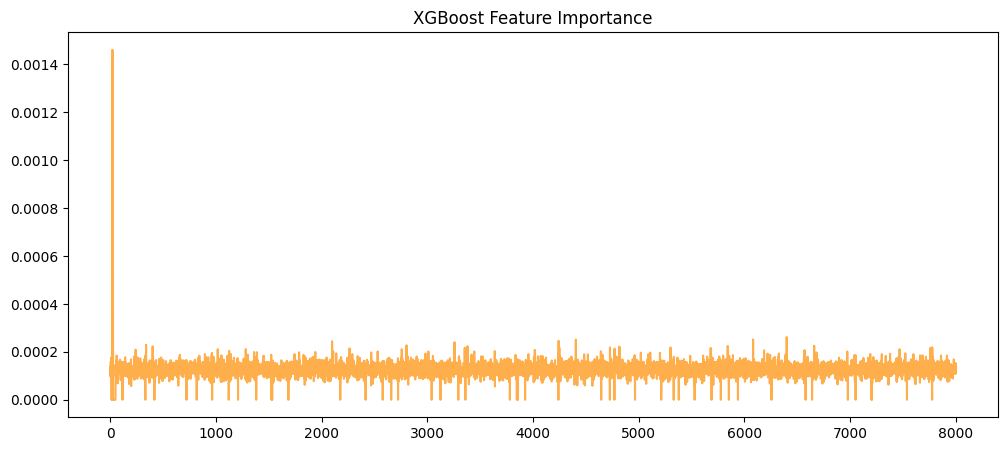

In [ ]:
import os
import json
import gc
import numpy as np
import comet_ml
import matplotlib.pyplot as plt
import joblib
from google.colab import userdata, drive
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, precision_score, recall_score, f1_score
from sklearn.utils import resample

# ============================================================================
# 1. INITIALIZE & CONFIG
# ============================================================================
comet_api_key = userdata.get('comet_api_key')
experiment = comet_ml.Experiment(
    api_key=comet_api_key,
    project_name="audio-steganalysis-baselines"
)
experiment.set_name("XGBoost (Full Dataset - Logged)")

config = {
    "model_type": "XGBoost",
    "n_estimators": 1000,
    "learning_rate": 0.1,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "tree_method": "hist",
    "random_state": 42
}
experiment.log_parameters(config)

# ============================================================================
# 2. SCALING & MEMORY MANAGEMENT
# ============================================================================
scaler = StandardScaler()
print("Scaling Data...")
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
del X_train, X_val
gc.collect()

# ============================================================================
# 3. TRAINING
# ============================================================================
print(f"Training XGBoost for {config['n_estimators']} rounds...")

model = XGBClassifier(
    **config,
    objective='binary:logistic',
    eval_metric=['logloss', 'auc', 'error']
)

model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_val_scaled, y_val)],
    verbose=20
)

# SAVE STEP
SAVE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines"
os.makedirs(SAVE_DIR, exist_ok=True)
joblib.dump(model, os.path.join(SAVE_DIR, "xgboost_baseline.joblib"))
joblib.dump(scaler, os.path.join(SAVE_DIR, "scaler_xgboost.joblib"))

# ============================================================================
# 4. EVALUATION & COMPREHENSIVE LOGGING
# ============================================================================
y_prob = model.predict_proba(X_val_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_val, y_pred)
auc = roc_auc_score(y_val, y_prob)
prec = precision_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

# Log metrics to Comet for easy table comparison
experiment.log_metrics({
    "final_accuracy": acc,
    "final_auc": auc,
    "final_precision": prec,
    "final_recall": rec,
    "final_f1": f1
})

experiment.log_confusion_matrix(y_val, y_pred, title="Final XGBoost CM")

results = model.evals_result()
for i in range(len(results['validation_0']['logloss'])):
    experiment.log_metrics({
        "train_acc_iter": 1 - results['validation_0']['error'][i],
        "val_acc_iter": 1 - results['validation_1']['error'][i],
        "val_auc_iter": results['validation_1']['auc'][i],
        "val_logloss": results['validation_1']['logloss'][i]
    }, step=i)

# 5. Feature Importance Plot
importances = model.feature_importances_
plt.figure(figsize=(12, 5))
plt.plot(importances, color='darkorange', alpha=0.7)
plt.title("XGBoost Feature Importance")
plt.savefig("xgb_feature_importance.png")
experiment.log_image("xgb_feature_importance.png")

print(f"\n--- Final XGBoost Report ---")
print(f"ACC: {acc:.4f} | AUC: {auc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
print("\nDetailed Report:")
print(classification_report(y_val, y_pred))

experiment.end()

 XGBOOST - Run test extraction script first

In [ ]:
import os
import gc
import joblib
import numpy as np
import pandas as pd
import comet_ml
from tqdm import tqdm
from google.colab import drive, userdata
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ============================================================================
# 1. PATH DEFINITIONS & SETUP
# ============================================================================
drive.mount('/content/drive')

# Input Data Paths
TENSOR_DIR = "/content/test_processing/3channel_tensors"
TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"

# Model/Artifact Paths
SAVE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines"
MODEL_PATH = os.path.join(SAVE_DIR, "xgboost_baseline.joblib")
SCALER_PATH = os.path.join(SAVE_DIR, "scaler_xgboost.joblib")

# ============================================================================
# 2. METADATA & ADAPTER FUNCTIONS
# ============================================================================

def load_test_metadata_map(excel_path):
    print("\nLoading Test Set Metadata...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)
    stego_tabs = ["test_lable_english_CNV", "test_lable_english_PMS",
                  "test_lable_chinese_CNV", "test_lable_chinese_PMS"]
    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue
        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                raw_algo = str(row.iloc[1]).strip()
                algo = "CNV" if raw_algo == "QIM" else raw_algo
                try: rate = round(float(row.iloc[2]), 1)
                except: rate = 0.0
                meta_map[fname] = {'algo': algo, 'rate': rate}
    return meta_map

def extract_test_features_baseline(tensor_dir, meta_map, byte_limit=24000):
    X_test_baseline, y_test_baseline, metadata_list = [], [], []
    for sub in ['cover', 'stego']:
        current_dir = os.path.join(tensor_dir, sub)
        if not os.path.exists(current_dir): continue
        files = sorted([f for f in os.listdir(current_dir) if f.endswith('.npy')])
        is_stego = (sub == 'stego')
        print(f"Extracting {sub} features...")
        for fname in tqdm(files):
            matrix = np.load(os.path.join(current_dir, fname)).flatten()
            features = np.pad(matrix, (0, max(0, byte_limit - len(matrix))), 'constant')[:byte_limit]
            X_test_baseline.append(features)
            y_test_baseline.append(1 if is_stego else 0)
            base_name = fname.replace(".npy", "")
            info = meta_map.get(base_name, {'algo': 'Cover', 'rate': 0.0}) if is_stego else {'algo': 'Cover', 'rate': 0.0}
            metadata_list.append({'base_name': base_name, 'is_stego': is_stego, 'algo': info['algo'], 'rate': info['rate']})
    return np.array(X_test_baseline, dtype=np.float32), np.array(y_test_baseline), metadata_list

def evaluate_baseline_stratified(model, X, y, metadata_list, threshold=0.5):
    all_probs = model.predict_proba(X)[:, 1]
    all_preds = (all_probs >= threshold).astype(int)
    metadata_df = pd.DataFrame(metadata_list)
    results = {'overall': {
        'accuracy': accuracy_score(y, all_preds),
        'precision': precision_score(y, all_preds, zero_division=0),
        'recall': recall_score(y, all_preds, zero_division=0),
        'f1': f1_score(y, all_preds, zero_division=0),
        'auc': roc_auc_score(y, all_probs),
        'confusion_matrix': confusion_matrix(y, all_preds).tolist()},
        'per_algorithm': {}, 'per_payload': {}}

    for algo in ['CNV', 'PMS']:
        mask = ((metadata_df['algo'] == algo) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            results['per_algorithm'][algo] = {'n_samples': int(mask.sum()), 'acc': accuracy_score(y[mask], all_preds[mask]), 'auc': roc_auc_score(y[mask], all_probs[mask])}

    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((metadata_df['rate'] == rate) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            results['per_payload'][f'{rate:.1f}'] = {'n_samples': int(mask.sum()), 'acc': accuracy_score(y[mask], all_preds[mask]), 'auc': roc_auc_score(y[mask], all_probs[mask])}
    return results

def print_stratified_results(results):
    print("\n" + "="*80 + "\nSTRATIFIED TEST RESULTS\n" + "="*80)
    o = results['overall']
    print(f"OVERALL -> Acc: {o['accuracy']:.4f} | AUC: {o['auc']:.4f} | F1: {o['f1']:.4f}")
    print("\nPER-ALGORITHM:")
    for algo, m in results['per_algorithm'].items():
        print(f"{algo:<10} | N: {m['n_samples']:<6} | Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f}")
    print("\nPER-PAYLOAD:")
    for rate, m in sorted(results['per_payload'].items()):
        print(f"Rate {rate:<5} | N: {m['n_samples']:<6} | Acc: {m['acc']:.4f} | AUC: {m['auc']:.4f}")

# ============================================================================
# 3. EXECUTION
# ============================================================================

# 1. Load Everything
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

# Count files to pre-allocate memory
all_test_files = []
for sub in ['cover', 'stego']:
    d = os.path.join(TENSOR_DIR, sub)
    if os.path.exists(d):
        all_test_files.extend([(os.path.join(d, f), sub == 'stego') for f in os.listdir(d) if f.endswith('.npy')])

num_test = len(all_test_files)
print(f"Total Test Samples: {num_test}")
X_test = np.zeros((num_test, 8000), dtype=np.float32)
y_test = np.zeros(num_test, dtype=np.int8)
metadata_list = []

print("Extracting Test Features...")
for i, (path, is_stego) in enumerate(tqdm(all_test_files)):
    matrix = np.load(path).flatten()
    feat_len = min(len(matrix), 8000)
    X_test[i, :feat_len] = matrix[:feat_len]
    y_test[i] = 1 if is_stego else 0

    # Metadata
    base_name = os.path.basename(path).replace(".npy", "")
    info = global_test_meta.get(base_name, {'algo': 'Cover', 'rate': 0.0}) if is_stego else {'algo': 'Cover', 'rate': 0.0}
    metadata_list.append({'base_name': base_name, 'is_stego': is_stego, 'algo': info['algo'], 'rate': info['rate']})

del all_test_files
gc.collect()

# ============================================================================
# 3. SCALING & PREDICTION
# ============================================================================
print("Loading Model & Scaler...")
model = joblib.load(os.path.join(SAVE_DIR, "xgboost_baseline.joblib"))
scaler = joblib.load(os.path.join(SAVE_DIR, "scaler_xgboost.joblib"))

print("Scaling and Predicting...")
X_test = scaler.transform(X_test)
all_probs = model.predict_proba(X_test)[:, 1]
all_preds = (all_probs >= 0.5).astype(int)

# ============================================================================
# 4. STRATIFIED EVALUATION
# ============================================================================

xgb_test_results = evaluate_baseline_stratified(
    model=model,
    X=X_test,
    y=y_test,
    metadata_list=metadata_list,
    threshold=0.5
)

del X_test
gc.collect()

print_stratified_results(xgb_test_results)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Loading Test Set Metadata...
Total Test Samples: 50000
Extracting Test Features...


100%|██████████| 50000/50000 [00:54<00:00, 915.27it/s] 


Loading Model & Scaler...
Scaling and Predicting...

STRATIFIED TEST RESULTS
OVERALL -> Acc: 0.5476 | AUC: 0.5687 | F1: 0.5476

PER-ALGORITHM:
CNV        | N: 37500  | Acc: 0.5616 | AUC: 0.5965
PMS        | N: 37500  | Acc: 0.5338 | AUC: 0.5409

PER-PAYLOAD:
Rate 0.1   | N: 31000  | Acc: 0.5386 | AUC: 0.5337
Rate 0.2   | N: 31500  | Acc: 0.5451 | AUC: 0.5568
Rate 0.3   | N: 31000  | Acc: 0.5502 | AUC: 0.5803
Rate 0.4   | N: 31500  | Acc: 0.5569 | AUC: 0.6023


##**SimpleBitCNN baseline**

In [ ]:
import os
import gc
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import comet_ml
from torch.utils.data import DataLoader, TensorDataset
from google.colab import drive, userdata
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Mount Drive and Init Comet
drive.mount('/content/drive')
comet_api_key = userdata.get('comet_api_key')
experiment = comet_ml.Experiment(api_key=comet_api_key, project_name="audio-steganalysis-baselines")
experiment.set_name("SimpleBitCNN (1D - 8000 bits)")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Running on: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/b76e783f4fcd43efa9883455486f4ab5



 Running on: cuda


In [ ]:
class SimpleBitCNN(nn.Module):
    def __init__(self):
        super(SimpleBitCNN, self).__init__()
        # Input shape: (Batch, 1, 8000)
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=11, stride=2, padding=5),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),

            nn.Conv1d(16, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # Global Average Pooling
        )

        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1) # Binary Output
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = SimpleBitCNN().to(device)

In [ ]:
X_train_t = torch.FloatTensor(X_train[:, :8000]).unsqueeze(1)
y_train_t = torch.FloatTensor(y_train).view(-1, 1)
X_val_t = torch.FloatTensor(X_val[:, :8000]).unsqueeze(1)
y_val_t = torch.FloatTensor(y_val).view(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=128)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
for epoch in range(20):
    model.train()
    total_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Validation
    model.eval()
    all_probs = []
    with torch.no_grad():
        for inputs, _ in val_loader:
            outputs = model(inputs.to(device))
            all_probs.extend(torch.sigmoid(outputs).cpu().numpy())

    val_auc = roc_auc_score(y_val, all_probs)
    print(f"Epoch {epoch+1:02d} | Loss: {total_loss/len(train_loader):.4f} | Val AUC: {val_auc:.4f}")
    experiment.log_metrics({"train_loss": total_loss/len(train_loader), "val_auc": val_auc}, step=epoch)

# SAVE STEP
SAVE_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/simple_bit_cnn.pth"
torch.save(model.state_dict(), SAVE_PATH)
print(f" Model saved to: {SAVE_PATH}")

Epoch 01 | Loss: 0.6922 | Val AUC: 0.5496
Epoch 02 | Loss: 0.6893 | Val AUC: 0.5576
Epoch 03 | Loss: 0.6869 | Val AUC: 0.5686
Epoch 04 | Loss: 0.6838 | Val AUC: 0.5712
Epoch 05 | Loss: 0.6815 | Val AUC: 0.5753
Epoch 06 | Loss: 0.6793 | Val AUC: 0.5758
Epoch 07 | Loss: 0.6765 | Val AUC: 0.5767
Epoch 08 | Loss: 0.6745 | Val AUC: 0.5795
Epoch 09 | Loss: 0.6728 | Val AUC: 0.5776
Epoch 10 | Loss: 0.6711 | Val AUC: 0.5786
Epoch 11 | Loss: 0.6697 | Val AUC: 0.5740
Epoch 12 | Loss: 0.6682 | Val AUC: 0.5739
Epoch 13 | Loss: 0.6667 | Val AUC: 0.5732
Epoch 14 | Loss: 0.6654 | Val AUC: 0.5773
Epoch 15 | Loss: 0.6637 | Val AUC: 0.5701
Epoch 16 | Loss: 0.6627 | Val AUC: 0.5711
Epoch 17 | Loss: 0.6617 | Val AUC: 0.5728
Epoch 18 | Loss: 0.6608 | Val AUC: 0.5737
Epoch 19 | Loss: 0.6594 | Val AUC: 0.5715
Epoch 20 | Loss: 0.6584 | Val AUC: 0.5664
 Model saved to: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/simple_bit_cnn.pth


In [ ]:
import os
import gc
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
from google.colab import drive
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ============================================================================
# 1. SETUP & PATHS
# ============================================================================
drive.mount('/content/drive')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
TENSOR_DIR = "/content/test_processing/3channel_tensors"
TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"
MODEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/simple_bit_cnn.pth"

# ============================================================================
# 2. MODEL DEFINITION (Must match your training architecture)
# ============================================================================
class SimpleBitCNN(nn.Module):
    def __init__(self):
        super(SimpleBitCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=11, stride=2, padding=5),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),
            nn.Conv1d(16, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

# Load Model
model = SimpleBitCNN().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print(f" SimpleBitCNN Loaded from: {MODEL_PATH}")

# ============================================================================
# 3. METADATA & EXTRACTION (Channel 1 Only)
# ============================================================================
def load_test_metadata_map(excel_path):
    print("\nLoading Test Set Metadata...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)
    stego_tabs = ["test_lable_english_CNV", "test_lable_english_PMS",
                  "test_lable_chinese_CNV", "test_lable_chinese_PMS"]
    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue
        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                raw_algo = str(row.iloc[1]).strip()
                # Standardization: QIM is often labeled as CNV in research papers
                algo = "CNV" if raw_algo == "QIM" else raw_algo
                try: rate = round(float(row.iloc[2]), 1)
                except: rate = 0.0
                meta_map[fname] = {'algo': algo, 'rate': rate}
    return meta_map

global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

# Prepare File List
all_test_files = []
for sub in ['cover', 'stego']:
    d = os.path.join(TENSOR_DIR, sub)
    if os.path.exists(d):
        all_test_files.extend([(os.path.join(d, f), sub == 'stego') for f in os.listdir(d) if f.endswith('.npy')])

num_test = len(all_test_files)
X_test = np.zeros((num_test, 1, 8000), dtype=np.float32)
y_test = np.zeros(num_test, dtype=np.int8)
metadata_list = []

print(f"Extracting Channel 1 (8,000 bits) for {num_test} samples...")
for i, (path, is_stego) in enumerate(tqdm(all_test_files)):
    matrix = np.load(path).flatten()
    feat_len = min(len(matrix), 8000)
    X_test[i, 0, :feat_len] = matrix[:feat_len]
    y_test[i] = 1 if is_stego else 0

    base_name = os.path.basename(path).replace(".npy", "")
    info = global_test_meta.get(base_name, {'algo': 'Cover', 'rate': 0.0}) if is_stego else {'algo': 'Cover', 'rate': 0.0}
    metadata_list.append({'base_name': base_name, 'is_stego': is_stego, 'algo': info['algo'], 'rate': info['rate']})

test_loader = DataLoader(TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)), batch_size=256)

del X_test
gc.collect()

# ============================================================================
# 4. INFERENCE & EVALUATION
# ============================================================================
all_probs = []
print("Running Inference...")
with torch.no_grad():
    for inputs, _ in tqdm(test_loader):
        outputs = torch.sigmoid(model(inputs.to(device)))
        all_probs.extend(outputs.cpu().numpy().flatten())

all_probs = np.array(all_probs)
all_preds = (all_probs >= 0.5).astype(int)
metadata_df = pd.DataFrame(metadata_list)

def get_stratified_report(y_true, y_pred, y_prob, meta_df):
    results = {'overall': {
        'acc': accuracy_score(y_true, y_pred),
        'auc': roc_auc_score(y_true, y_prob),
        'f1': f1_score(y_true, y_pred, zero_division=0)},
        'algo': {}, 'payload': {}}

    for algo in ['CNV', 'PMS']:
        mask = ((meta_df['algo'] == algo) | (~meta_df['is_stego'])).values
        results['algo'][algo] = {'acc': accuracy_score(y_true[mask], y_pred[mask]), 'auc': roc_auc_score(y_true[mask], y_prob[mask])}

    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((meta_df['rate'] == rate) | (~meta_df['is_stego'])).values
        results['payload'][f'{rate:.1f}'] = {'acc': accuracy_score(y_true[mask], y_pred[mask]), 'auc': roc_auc_score(y_true[mask], y_prob[mask])}
    return results

cnn_results = get_stratified_report(y_test, all_preds, all_probs, metadata_df)

# ============================================================================
# 5. FINAL THESIS OUTPUT
# ============================================================================
print("\n" + "="*80 + "\nSIMPLE BITSTREAM CNN TEST RESULTS\n" + "="*80)
o = cnn_results['overall']
print(f"OVERALL -> Acc: {o['acc']:.4f} | AUC: {o['auc']:.4f} | F1: {o['f1']:.4f}")
print("\nPER-ALGORITHM (Acc / AUC):")
for k, v in cnn_results['algo'].items():
    print(f"{k:<10} -> {v['acc']:.4f} / {v['auc']:.4f}")
print("\nPER-PAYLOAD (Acc / AUC):")
for k, v in sorted(cnn_results['payload'].items()):
    print(f"Rate {k:<5} -> {v['acc']:.4f} / {v['auc']:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 SimpleBitCNN Loaded from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/simple_bit_cnn.pth

Loading Test Set Metadata...
Extracting Channel 1 (8,000 bits) for 50000 samples...


100%|██████████| 50000/50000 [00:41<00:00, 1192.29it/s]


Running Inference...


100%|██████████| 196/196 [00:01<00:00, 99.26it/s] 



SIMPLE BITSTREAM CNN TEST RESULTS
OVERALL -> Acc: 0.5032 | AUC: 0.5968 | F1: 0.0164

PER-ALGORITHM (Acc / AUC):
CNV        -> 0.6700 / 0.6530
PMS        -> 0.6665 / 0.5406

PER-PAYLOAD (Acc / AUC):
Rate 0.1   -> 0.8054 / 0.5400
Rate 0.2   -> 0.7932 / 0.5810
Rate 0.3   -> 0.8068 / 0.6105
Rate 0.4   -> 0.7957 / 0.6524


##**1D CNN - Baseline**

In [ ]:
import os
import json
import random
import numpy as np
import torch
from datetime import datetime
from torch.utils.data import Dataset, ConcatDataset, Subset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
import shutil
from tqdm import tqdm

# ============================================================================
# CONFIGURATION
# ============================================================================
BASE_DIR = "/content/dataset_local"

# ----------------------------------------------------------------------------
# Route the saved split indices directly to Google Drive
# ----------------------------------------------------------------------------
SOURCE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples"
os.makedirs(SOURCE_DIR, exist_ok=True)

# Directing the script to exact local folders
COVER_DIR = os.path.join(BASE_DIR, "cover")
STEGO_DIR = os.path.join(BASE_DIR, "stego")

# ----------------------------------------------------------------------------
# Direct path to the Excel file in Google Drive
# ----------------------------------------------------------------------------
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/train_lable.xlsx"

SEED = 42
VAL_RATIO = 0.15
TEST_RATIO = 0.0
BATCH_SIZE = 128

# ============================================================================
# 1. DATASET CLASS
# ============================================================================
def load_excel_metadata(excel_path):
    print("Loading Excel metadata...")
    meta_map = {}
    if not os.path.exists(excel_path):
        print(f" [!] Excel file not found at {excel_path}. Metadata will be empty.")
        return meta_map

    xls = pd.ExcelFile(excel_path)
    tabs = ["train_lable_english_CNV", "train_lable_english_PMS",
            "train_lable_chinese_CNV", "train_lable_chinese_PMS"]

    for tab in tabs:
        if tab not in xls.sheet_names: continue
        current_algo = "CNV" if "CNV" in tab else "PMS"
        df = pd.read_excel(xls, sheet_name=tab)

        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0
                meta_map[fname] = {'algo': current_algo, 'rate': rate}

    print(f" -> Loaded Excel metadata for {len(meta_map)} samples.")
    return meta_map

class MatrixDataset(Dataset):
    def __init__(self, data_folder, label, meta_map=None):
        self.data_folder = data_folder
        self.label = label

        # Grab all .npy files
        self.files = [f for f in os.listdir(data_folder) if f.endswith(".npy")]
        self.files = sorted(self.files)

        # Base names (e.g., 'Chinese112894.npy' -> 'Chinese112894')
        self.base_names = [f.replace(".npy", "") for f in self.files]

        # ---> METADATA TRACKING <---
        self.meta_map = meta_map or {}
        self.metadata = []
        for b in self.base_names:
            if b in self.meta_map:
                self.metadata.append(self.meta_map[b])
            else:
                self.metadata.append({'algo': 'Cover' if label == 0 else 'Unknown', 'rate': 0.0})

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_folder, self.files[idx])
        # Load the (3, 100, 80) float32 tensor
        matrix = np.load(file_path)

        # --- Reshape for 1D CNN (3, 100, 80) -> (3, 8000) ---
        matrix = matrix.reshape(3, 8000).astype(np.float32)

        tensor = torch.from_numpy(matrix)
        return tensor, torch.tensor(self.label, dtype=torch.float32).view(1) # Float for BCE loss

    def get_metadata(self, idx):
        return {
            'base_name': self.base_names[idx],
            'algo': self.metadata[idx]['algo'],
            'rate': self.metadata[idx]['rate'],
            'is_stego': self.label == 1
        }

def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f" -> Global Seed locked to: {seed}")

# ============================================================================
# 2. GROUP-AWARE SPLIT FUNCTION
# ============================================================================
def create_group_aware_splits(cover_dataset, stego_dataset,
                              val_ratio=0.15, test_ratio=0.0, seed=42,
                              save_indices=True, experiment_name="group_aware_matrices"):
    print("\nGenerating Forensic Group-Aware Splits (Train/Val only)...")

    # 1. Extract base names to form groups
    all_groups = np.array(cover_dataset.base_names + stego_dataset.base_names)
    all_indices = np.arange(len(all_groups))

    print(f"  Total Samples: {len(all_groups)}")
    print(f"  Unique Sources: {len(set(all_groups))}")

    # 2. Split Train vs Val (Now test_ratio is 0.0)
    gss = GroupShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
    train_idx, val_idx = next(gss.split(all_indices, groups=all_groups))

    # 3. Test index is empty
    test_idx = np.array([])

    # 4. Shuffle Indices
    np.random.shuffle(train_idx)
    np.random.shuffle(val_idx)

    # 5. Leakage Verification
    train_groups_set = set(all_groups[train_idx])
    val_groups_set = set(all_groups[val_idx])

    leakage_tv = train_groups_set.intersection(val_groups_set)

    if len(leakage_tv) > 0:
        raise ValueError(f"CRITICAL LEAKAGE DETECTED! Overlap: {len(leakage_tv)}")
    else:
        print("  LEAKAGE CHECK PASSED: 0 overlapping audio sources.")

    # 6. Create Datasets
    full_dataset = ConcatDataset([cover_dataset, stego_dataset])
    train_ds = Subset(full_dataset, train_idx)
    val_ds   = Subset(full_dataset, val_idx)
    test_ds  = Subset(full_dataset, test_idx) # This will be empty

    print(f"  Train: {len(train_ds)} | Val: {len(val_ds)} | Test (Local): {len(test_ds)}")

    # 7. Save Indices
    if save_indices:
        split_info = {
            "experiment_name": experiment_name,
            "timestamp": datetime.now().isoformat(),
            "random_seed": seed,
            "indices": {
                "train": train_idx.tolist(),
                "val": val_idx.tolist(),
                "test": test_idx.tolist()
            }
        }
        save_path = os.path.join(SOURCE_DIR, f"split_indices_{experiment_name}_seed{seed}.json")
        with open(save_path, 'w') as f:
            json.dump(split_info, f)
        print(f"  Split indices saved to: {save_path}")

    return train_ds, val_ds, test_ds

def load_split_indices(filepath, full_dataset):
    """
    Loads previously saved training/validation indices from a JSON file
    to ensure consistency across different sessions.
    """
    print(f"Loading split from: {filepath}")
    with open(filepath, 'r') as f:
        data = json.load(f)

    train_ds = Subset(full_dataset, data["indices"]["train"])
    val_ds   = Subset(full_dataset, data["indices"]["val"])
    test_ds  = Subset(full_dataset, data["indices"]["test"])

    return train_ds, val_ds, test_ds

# ============================================================================
# 3. MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    print(f"{'='*50}\nDataset Preparation Pipeline (85/15 Split)\n{'='*50}")
    set_global_seed(SEED)

    global_meta_map = load_excel_metadata(EXCEL_PATH)

    print("\nLoading datasets...")
    cover_dataset = MatrixDataset(data_folder=COVER_DIR, label=0)
    stego_dataset = MatrixDataset(data_folder=STEGO_DIR, label=1, meta_map=global_meta_map)

    full_dataset = ConcatDataset([cover_dataset, stego_dataset])

    EXPERIMENT_NAME = "stego-detection-3channel"
    SPLIT_FILE = os.path.join(SOURCE_DIR, f"split_indices_{EXPERIMENT_NAME}_seed{SEED}.json")

    if os.path.exists(SPLIT_FILE):
        print("\nFound existing split file. Loading...")
        train_dataset, val_dataset, test_dataset = load_split_indices(SPLIT_FILE, full_dataset)
    else:
        print("\nCreating NEW group-aware split (No local test set)...")
        train_dataset, val_dataset, test_dataset = create_group_aware_splits(
            cover_dataset, stego_dataset,
            val_ratio=VAL_RATIO, test_ratio=0.0, seed=SEED,
            save_indices=True, experiment_name=EXPERIMENT_NAME
        )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    print(f"\n Pipeline Ready. Using {len(train_dataset)} for training and {len(val_dataset)} for validation.")

    # Verification Print
    x, y = next(iter(train_loader))
    print(f"Batch Shape: {x.shape} -> [Batch, Channels, Frames, Bits]")
    print(f"Labels Shape: {y.shape}")

Dataset Preparation Pipeline (85/15 Split)
 -> Global Seed locked to: 42
Loading Excel metadata...
 -> Loaded Excel metadata for 382296 samples.

Loading datasets...

Found existing split file. Loading...
Loading split from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples/split_indices_stego-detection-3channel_seed42.json

 Pipeline Ready. Using 84984 for training and 14998 for validation.
Batch Shape: torch.Size([128, 3, 8000]) -> [Batch, Channels, Frames, Bits]
Labels Shape: torch.Size([128, 1])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import gc

class MultiChannelBitCNN(nn.Module):
    def __init__(self):
        super(MultiChannelBitCNN, self).__init__()
        # Input: (Batch, 3 Channels, 8000 bits)
        self.features = nn.Sequential(
            nn.Conv1d(3, 32, kernel_size=11, stride=2, padding=5),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(32, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1) # Condenses 8000 bits down to 1 feature map
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 1) # Binary output
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

In [ ]:
import os
import gc
import json
import psutil
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import comet_ml
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset, TensorDataset, Subset, ConcatDataset
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import GroupShuffleSplit
import joblib

# ============================================================================
# 1. INITIALIZE COMET & HYPERPARAMS
# ============================================================================
comet_api_key = userdata.get('comet_api_key')
experiment = comet_ml.Experiment(
    api_key=comet_api_key,
    project_name="audio-steganalysis-baselines"
)
experiment.set_name("MultiChannel-1D-CNN (Strong Baseline)")

config = {
    "model_type": "1D-CNN",
    "learning_rate": 0.0005,
    "batch_size": 128,
    "epochs": 20,
    "channels": 3,
    "input_len": 8000,
    "device": str(device)
}
experiment.log_parameters(config)

# ============================================================================
# 2. MODEL, OPTIMIZER, CRITERION
# ============================================================================
model = MultiChannelBitCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=config["learning_rate"])
criterion = nn.BCEWithLogitsLoss()

print(f" Starting 3-Channel CNN Training for {config['epochs']} epochs...")

# ============================================================================
# 3. TRAINING LOOP
# ============================================================================
for epoch in range(config["epochs"]):
    model.train()
    epoch_loss = 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{config['epochs']}"):
        inputs, labels = inputs.to(device), labels.to(device).float().view(-1, 1)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # --- VALIDATION PHASE ---
    model.eval()
    all_probs = []
    all_targets = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = torch.sigmoid(model(inputs.to(device)))
            all_probs.extend(outputs.cpu().numpy().flatten())
            all_targets.extend(labels.numpy().flatten())

    # Calculate Standardized Metrics
    all_probs = np.array(all_probs)
    all_targets = np.array(all_targets)
    all_preds = (all_probs >= 0.5).astype(int)

    val_auc = roc_auc_score(all_targets, all_probs)
    val_acc = accuracy_score(all_targets, all_preds)
    val_f1 = f1_score(all_targets, all_preds, zero_division=0)
    val_prec = precision_score(all_targets, all_preds, zero_division=0)
    val_rec = recall_score(all_targets, all_preds, zero_division=0)

    experiment.log_metrics({
        "loss": epoch_loss / len(train_loader),
        "val_auc": val_auc,
        "val_accuracy": val_acc,
        "val_f1": val_f1,
        "val_precision": val_prec,
        "val_recall": val_rec
    }, step=epoch)

    print(f" -> [Epoch {epoch+1:02d}] Loss: {epoch_loss/len(train_loader):.4f} | AUC: {val_auc:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}")

# ============================================================================
# 4. FINAL EVALUATION & SAVE
# ============================================================================
experiment.log_confusion_matrix(all_targets, all_preds, title="Final CNN Confusion Matrix")

SAVE_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/strong_3channel_cnn.pth"
torch.save(model.state_dict(), SAVE_PATH)

print(f"\n Strong Baseline Saved to: {SAVE_PATH}")
print(classification_report(all_targets, all_preds))

experiment.end()

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch, sklearn.
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : MultiChannel-1D-CNN (Strong Baseline)
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/178f7e0bb1314496b3bb7696f68b8bc3
COMET INFO:   Others:
COMET INFO:     Name         : MultiChannel-1D-CNN (Strong Baseline)
COMET INFO:     notebook_url : https://colab.research.google.com/notebook#fileId=15DVhh97Z6qjPf3lCb5j5QROL1SEKBJDE
COMET INFO:   Parameters:
COMET INFO:     batch_size    : 128
COMET INFO:     channels      : 3
COMET INFO:     device        : cuda
COMET INFO:     epochs       

 Starting 3-Channel CNN Training for 20 epochs...


Epoch 1/20: 100%|██████████| 664/664 [01:44<00:00,  6.35it/s]


 -> [Epoch 01] Loss: 0.6921 | AUC: 0.5520 | Acc: 0.5220 | F1: 0.6515


Epoch 2/20: 100%|██████████| 664/664 [01:38<00:00,  6.77it/s]


...

Epoch 20/20: 100%|██████████| 664/664 [01:20<00:00,  8.27it/s]
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_tr

 -> [Epoch 20] Loss: 0.5762 | AUC: 0.5753 | Acc: 0.5510 | F1: 0.5151


Streaming output truncated to the last 5000 lines.
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(0.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.float32(1.0), ignoring it
COMET WARNING: Invalid y_true value np.


 Strong Baseline Saved to: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/strong_3channel_cnn.pth
              precision    recall  f1-score   support

         0.0       0.54      0.63      0.58      7499
         1.0       0.56      0.48      0.52      7499

    accuracy                           0.55     14998
   macro avg       0.55      0.55      0.55     14998
weighted avg       0.55      0.55      0.55     14998



COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : MultiChannel-1D-CNN (Strong Baseline)
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/audio-steganalysis-baselines/e47f1e57a3bb429bb0adffcf675a6dbe
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     loss [20]          : (0.5761707368116062, 0.692132546420557)
COMET INFO:     val_accuracy [20]  : (0.5, 0.5600080010668089)
COMET INFO:     val_auc [20]       : (0.5519810962571157, 0.5949927252601988)
COMET INFO:     val_f1 [20]        : (0.018989845707503627, 0.6666666666666666)
COMET INFO:     val_prec

In [ ]:
import os
import gc
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
from google.colab import drive
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ============================================================================
# 1. SETUP & PATHS
# ============================================================================
drive.mount('/content/drive')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths
TENSOR_DIR = "/content/test_processing/3channel_tensors"
TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"
MODEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/strong_3channel_cnn.pth"

# ============================================================================
# 2. LOAD METADATA & MODEL
# ============================================================================

def load_test_metadata_map(excel_path):
    print("\nLoading Test Set Metadata...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)
    stego_tabs = ["test_lable_english_CNV", "test_lable_english_PMS",
                  "test_lable_chinese_CNV", "test_lable_chinese_PMS"]
    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue
        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                raw_algo = str(row.iloc[1]).strip()
                algo = "CNV" if raw_algo == "QIM" else raw_algo
                try: rate = round(float(row.iloc[2]), 1)
                except: rate = 0.0
                meta_map[fname] = {'algo': algo, 'rate': rate}
    return meta_map

model = MultiChannelBitCNN().to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print(f" Model loaded from: {MODEL_PATH}")

# ============================================================================
# 3. EXTRACTION (3-Channel Reshaping)
# ============================================================================
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

all_test_files = []
for sub in ['cover', 'stego']:
    d = os.path.join(TENSOR_DIR, sub)
    if os.path.exists(d):
        all_test_files.extend([(os.path.join(d, f), sub == 'stego') for f in os.listdir(d) if f.endswith('.npy')])

num_test = len(all_test_files)
print(f"Total Test Samples: {num_test}")

# Pre-allocate for 3 channels (N, 3, 8000)
X_test = np.zeros((num_test, 3, 8000), dtype=np.float32)
y_test = np.zeros(num_test, dtype=np.int8)
metadata_list = []

print("Extracting & Reshaping Test Tensors...")
for i, (path, is_stego) in enumerate(tqdm(all_test_files)):
    # Reshape (3, 100, 80) -> (3, 8000)
    matrix = np.load(path).reshape(3, 8000)
    X_test[i] = matrix
    y_test[i] = 1 if is_stego else 0

    base_name = os.path.basename(path).replace(".npy", "")
    info = global_test_meta.get(base_name, {'algo': 'Cover', 'rate': 0.0}) if is_stego else {'algo': 'Cover', 'rate': 0.0}
    metadata_list.append({'base_name': base_name, 'is_stego': is_stego, 'algo': info['algo'], 'rate': info['rate']})

test_loader = DataLoader(TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test)), batch_size=256)

del X_test
gc.collect()

# ============================================================================
# 4. INFERENCE & STRATIFIED EVALUATION
# ============================================================================
all_probs = []
print("Running Inference on GPU...")
with torch.no_grad():
    for inputs, _ in tqdm(test_loader):
        outputs = torch.sigmoid(model(inputs.to(device)))
        all_probs.extend(outputs.cpu().numpy().flatten())

all_probs = np.array(all_probs)
all_preds = (all_probs >= 0.5).astype(int)
metadata_df = pd.DataFrame(metadata_list)

def get_stratified_report(y_true, y_pred, y_prob, meta_df):
    results = {'overall': {
        'acc': accuracy_score(y_true, y_pred),
        'auc': roc_auc_score(y_true, y_prob),
        'f1': f1_score(y_true, y_pred, zero_division=0)},
        'algo': {}, 'payload': {}}

    for algo in ['CNV', 'PMS']:
        mask = ((meta_df['algo'] == algo) | (~meta_df['is_stego'])).values
        results['algo'][algo] = {'acc': accuracy_score(y_true[mask], y_pred[mask]), 'auc': roc_auc_score(y_true[mask], y_prob[mask])}

    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((meta_df['rate'] == rate) | (~meta_df['is_stego'])).values
        results['payload'][f'{rate:.1f}'] = {'acc': accuracy_score(y_true[mask], y_pred[mask]), 'auc': roc_auc_score(y_true[mask], y_prob[mask])}
    return results

cnn_results = get_stratified_report(y_test, all_preds, all_probs, metadata_df)

# ============================================================================
# 5. PRINT THE THESIS TABLE
# ============================================================================
print("\n" + "="*80 + "\nSTRONG CNN STRATIFIED TEST RESULTS\n" + "="*80)
o = cnn_results['overall']
print(f"OVERALL -> Acc: {o['acc']:.4f} | AUC: {o['auc']:.4f} | F1: {o['f1']:.4f}")
print("\nPER-ALGORITHM (Acc / AUC):")
for k, v in cnn_results['algo'].items():
    print(f"{k:<10} -> {v['acc']:.4f} / {v['auc']:.4f}")
print("\nPER-PAYLOAD (Acc / AUC):")
for k, v in sorted(cnn_results['payload'].items()):
    print(f"Rate {k:<5} -> {v['acc']:.4f} / {v['auc']:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model loaded from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/strong_3channel_cnn.pth

Loading Test Set Metadata...
Total Test Samples: 50000
Extracting & Reshaping Test Tensors...


100%|██████████| 50000/50000 [01:24<00:00, 594.64it/s]


Running Inference on GPU...


100%|██████████| 196/196 [00:05<00:00, 36.28it/s]



STRONG CNN STRATIFIED TEST RESULTS
OVERALL -> Acc: 0.5944 | AUC: 0.6363 | F1: 0.5787

PER-ALGORITHM (Acc / AUC):
CNV        -> 0.6489 / 0.7300
PMS        -> 0.5649 / 0.5426

PER-PAYLOAD (Acc / AUC):
Rate 0.1   -> 0.6006 / 0.5681
Rate 0.2   -> 0.6131 / 0.6247
Rate 0.3   -> 0.6223 / 0.6575
Rate 0.4   -> 0.6313 / 0.6912


#**BASELINE COMPARISON**


MASTER BASELINE COMPARISON TABLE


,Model,Accuracy,AUC,F1-Score
0,Proposed Model,0.670400,0.731700,0.618000
1,Model w PsycoAc Attn,0.665800,0.727500,0.614700
7,Strong 1D-CNN,0.594400,0.636300,0.578700
6,Simple BitCNN,0.503200,0.596800,0.016400
5,XGBoost,0.547600,0.568700,0.547600
2,LogReg,0.520200,0.529200,0.515000
4,Random Forest,0.517100,0.522400,0.505600
3,SVM,0.518100,0.518800,0.527700


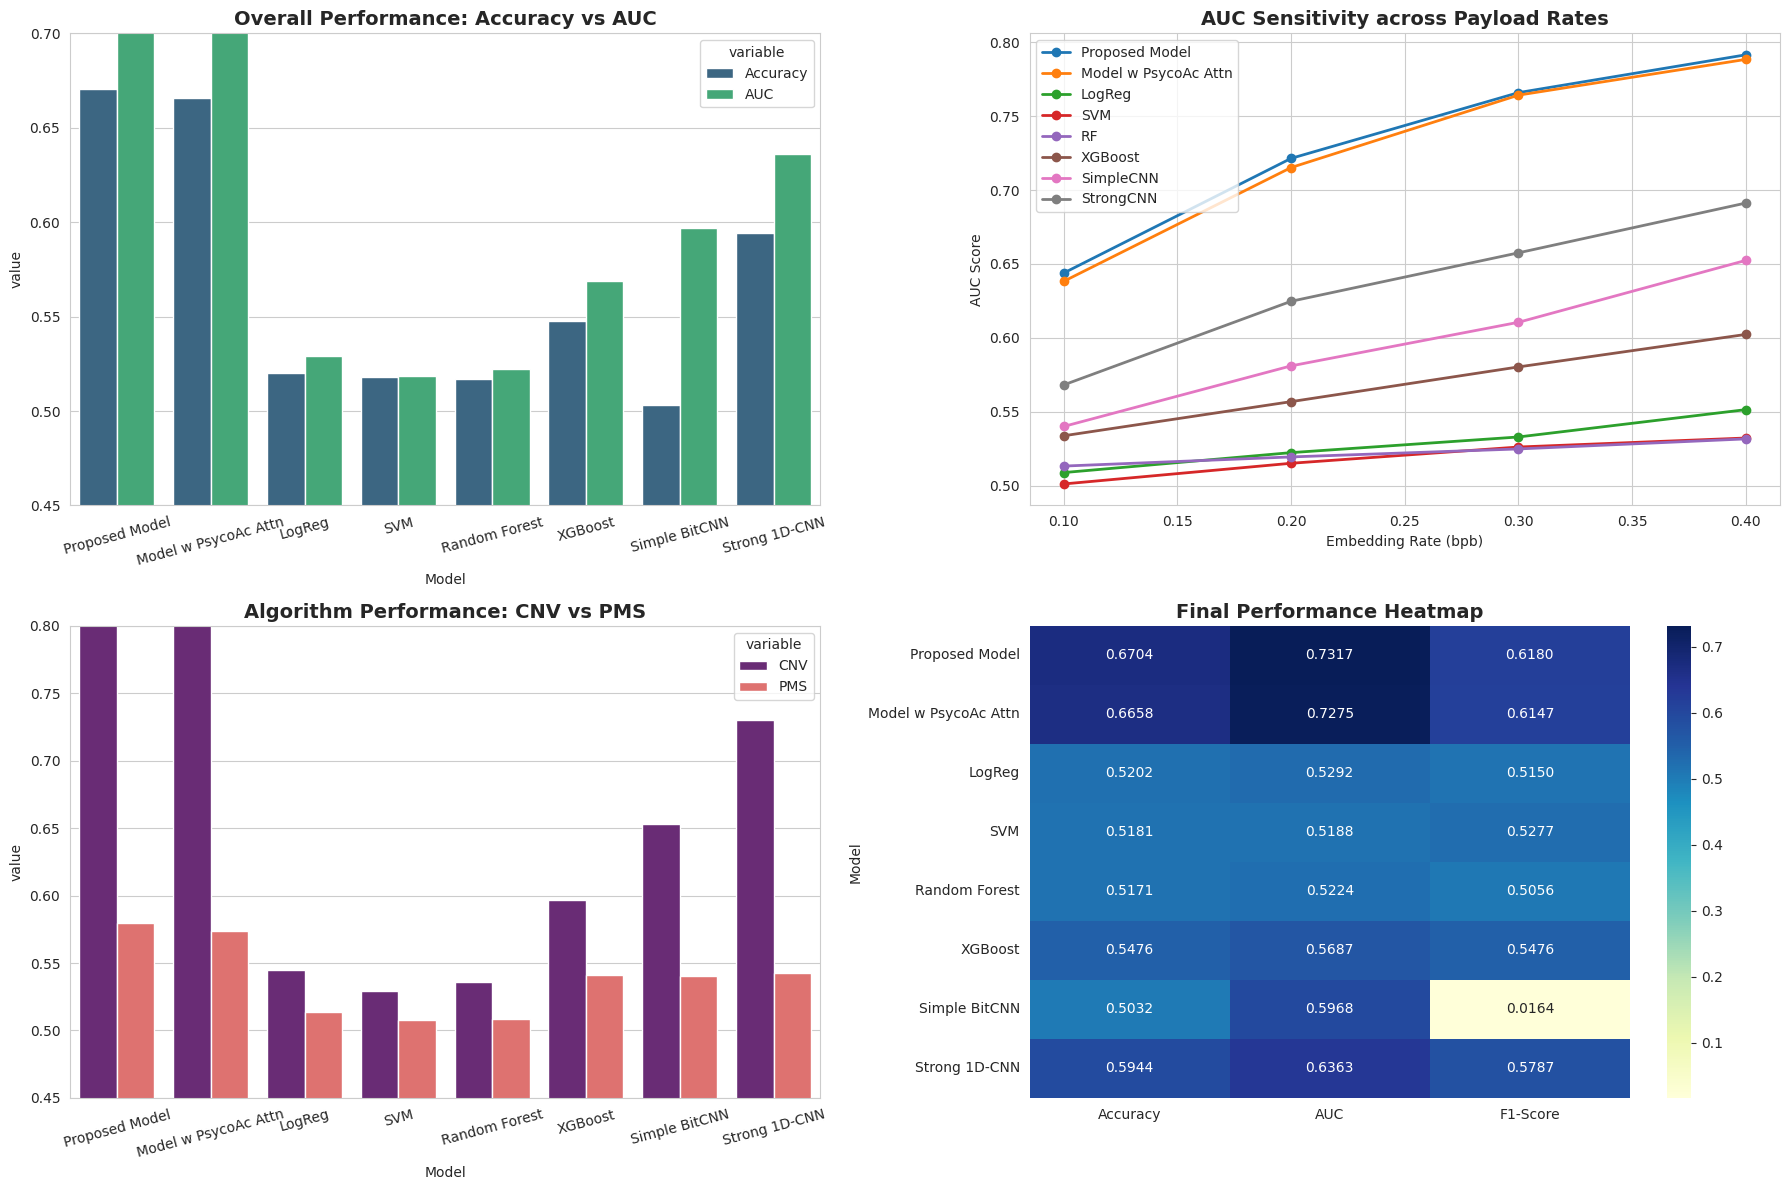

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================================
# 1. CONSOLIDATE DATA
# ============================================================================
models = ["Proposed Model", "Model w PsycoAc Attn", "LogReg", "SVM", "Random Forest", "XGBoost", "Simple BitCNN", "Strong 1D-CNN"]

# Overall Metrics
overall_data = {
    "Model": models,
    "Accuracy": [0.6704, 0.6658, 0.5202, 0.5181, 0.5171, 0.5476, 0.5032, 0.5944],
    "AUC":      [0.7317, 0.7275, 0.5292, 0.5188, 0.5224, 0.5687, 0.5968, 0.6363],
    "F1-Score": [0.6180, 0.6147, 0.5150, 0.5277, 0.5056, 0.5476, 0.0164, 0.5787]
}

# Per-Algorithm AUC
algo_auc = {
    "Model": models,
    "CNV": [0.8834, 0.8811, 0.5448, 0.5295, 0.5361, 0.5965, 0.6530, 0.7300],
    "PMS": [0.5800, 0.5739, 0.5136, 0.5081, 0.5087, 0.5409, 0.5406, 0.5426]
}

# Per-Payload AUC
payload_auc = {
    "Rate": [0.1, 0.2, 0.3, 0.4],
    "Proposed Model": [0.6438, 0.7214, 0.7659, 0.7915],
    "Model w PsycoAc Attn": [0.6382, 0.7152, 0.7642, 0.7884],
    "LogReg": [0.5088, 0.5223, 0.5329, 0.5514],
    "SVM":    [0.5011, 0.5151, 0.5261, 0.5322],
    "RF":     [0.5132, 0.5194, 0.5248, 0.5316],
    "XGBoost":[0.5337, 0.5568, 0.5803, 0.6023],
    "SimpleCNN":[0.5400, 0.5810, 0.6105, 0.6524],
    "StrongCNN":[0.5681, 0.6247, 0.6575, 0.6912]
}

# Convert to DataFrames
df_overall = pd.DataFrame(overall_data)
df_algo = pd.DataFrame(algo_auc)
df_payload = pd.DataFrame(payload_auc)

# ============================================================================
# 2. GENERATE MASTER TABLE
# ============================================================================
print("\n" + "="*50)
print("MASTER BASELINE COMPARISON TABLE")
print("="*50)
display(df_overall.sort_values(by="AUC", ascending=False).style.background_gradient(cmap='Greens'))

# ============================================================================
# 3. VISUALIZATIONS
# ============================================================================
plt.figure(figsize=(18, 12))
sns.set_style("whitegrid")

# Graph 1: Overall AUC vs Accuracy Comparison
plt.subplot(2, 2, 1)
df_melted = df_overall.melt(id_vars="Model", value_vars=["Accuracy", "AUC"])
sns.barplot(data=df_melted, x="Model", y="value", hue="variable", palette="viridis")
plt.title("Overall Performance: Accuracy vs AUC", fontsize=14, fontweight='bold')
plt.ylim(0.45, 0.70)
plt.xticks(rotation=15)

# Graph 2: AUC Performance by Embedding Rate (Line Graph)
plt.subplot(2, 2, 2)
for model in ["Proposed Model", "Model w PsycoAc Attn", "LogReg", "SVM", "RF", "XGBoost", "SimpleCNN", "StrongCNN"]:
    plt.plot(df_payload["Rate"], df_payload[model], marker='o', label=model, linewidth=2)
plt.title("AUC Sensitivity across Payload Rates", fontsize=14, fontweight='bold')
plt.xlabel("Embedding Rate (bpb)")
plt.ylabel("AUC Score")
plt.legend()

# Graph 3: Model Robustness (CNV vs PMS Algorithms)
plt.subplot(2, 2, 3)
df_algo_melted = df_algo.melt(id_vars="Model", value_vars=["CNV", "PMS"])
sns.barplot(data=df_algo_melted, x="Model", y="value", hue="variable", palette="magma")
plt.title("Algorithm Performance: CNV vs PMS", fontsize=14, fontweight='bold')
plt.ylim(0.45, 0.80)
plt.xticks(rotation=15)

# Graph 4: The Model Heatmap
plt.subplot(2, 2, 4)
heatmap_data = df_overall.set_index("Model")[["Accuracy", "AUC", "F1-Score"]]
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt=".4f")
plt.title("Final Performance Heatmap", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

#**ABLATION STUDY**

##**Dataset script**

In [ ]:
import os
import json
import random
import numpy as np
import torch
from datetime import datetime
from torch.utils.data import Dataset, ConcatDataset, Subset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
import shutil
from tqdm import tqdm

# ============================================================================
# CONFIGURATION
# ============================================================================
BASE_DIR = "/content/dataset_local"

# ----------------------------------------------------------------------------
# Route the saved split indices directly to Google Drive
# ----------------------------------------------------------------------------
SOURCE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples"
os.makedirs(SOURCE_DIR, exist_ok=True)

# Directing the script to exact local folders
COVER_DIR = os.path.join(BASE_DIR, "cover")
STEGO_DIR = os.path.join(BASE_DIR, "stego")

# ----------------------------------------------------------------------------
# Direct path to the Excel file in Google Drive
# ----------------------------------------------------------------------------
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/train_lable.xlsx"

SEED = 42
VAL_RATIO = 0.15
TEST_RATIO = 0.0
BATCH_SIZE = 128

# ============================================================================
# 1. DATASET CLASS
# ============================================================================
def load_excel_metadata(excel_path):
    print("Loading Excel metadata...")
    meta_map = {}
    if not os.path.exists(excel_path):
        print(f" [!] Excel file not found at {excel_path}. Metadata will be empty.")
        return meta_map

    xls = pd.ExcelFile(excel_path)
    tabs = ["train_lable_english_CNV", "train_lable_english_PMS",
            "train_lable_chinese_CNV", "train_lable_chinese_PMS"]

    for tab in tabs:
        if tab not in xls.sheet_names: continue
        current_algo = "CNV" if "CNV" in tab else "PMS"
        df = pd.read_excel(xls, sheet_name=tab)

        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0
                meta_map[fname] = {'algo': current_algo, 'rate': rate}

    print(f" -> Loaded Excel metadata for {len(meta_map)} samples.")
    return meta_map

class MatrixDataset(Dataset):
    def __init__(self, data_folder, label, meta_map=None):
        self.data_folder = data_folder
        self.label = label

        # Grab all .npy files
        self.files = [f for f in os.listdir(data_folder) if f.endswith(".npy")]
        self.files = sorted(self.files)

        # Base names (e.g., 'Chinese112894.npy' -> 'Chinese112894')
        self.base_names = [f.replace(".npy", "") for f in self.files]

        # ---> METADATA TRACKING <---
        self.meta_map = meta_map or {}
        self.metadata = []
        for b in self.base_names:
            if b in self.meta_map:
                self.metadata.append(self.meta_map[b])
            else:
                self.metadata.append({'algo': 'Cover' if label == 0 else 'Unknown', 'rate': 0.0})

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_folder, self.files[idx])
        # Load the (3, 100, 80) float32 tensor
        matrix = np.load(file_path)
        tensor = torch.from_numpy(matrix)

        return tensor, torch.tensor(self.label, dtype=torch.long)

    def get_metadata(self, idx):
        return {
            'base_name': self.base_names[idx],
            'algo': self.metadata[idx]['algo'],
            'rate': self.metadata[idx]['rate'],
            'is_stego': self.label == 1
        }

def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f" -> Global Seed locked to: {seed}")

# ============================================================================
# 2. GROUP-AWARE SPLIT FUNCTION (REMOVING TEST SPLIT)
# ============================================================================
def create_group_aware_splits(cover_dataset, stego_dataset,
                              val_ratio=0.15, test_ratio=0.0, seed=42,
                              save_indices=True, experiment_name="group_aware_matrices"):
    print("\nGenerating Forensic Group-Aware Splits (Train/Val only)...")

    # 1. Extract base names to form groups
    all_groups = np.array(cover_dataset.base_names + stego_dataset.base_names)
    all_indices = np.arange(len(all_groups))

    print(f"  Total Samples: {len(all_groups)}")
    print(f"  Unique Sources: {len(set(all_groups))}")

    # 2. Split Train vs Val
    gss = GroupShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
    train_idx, val_idx = next(gss.split(all_indices, groups=all_groups))

    # 3. Test index is empty
    test_idx = np.array([])

    # 4. Shuffle Indices
    np.random.shuffle(train_idx)
    np.random.shuffle(val_idx)

    # 5. Leakage Verification
    train_groups_set = set(all_groups[train_idx])
    val_groups_set = set(all_groups[val_idx])

    leakage_tv = train_groups_set.intersection(val_groups_set)

    if len(leakage_tv) > 0:
        raise ValueError(f"CRITICAL LEAKAGE DETECTED! Overlap: {len(leakage_tv)}")
    else:
        print("  LEAKAGE CHECK PASSED: 0 overlapping audio sources.")

    # 6. Create Datasets
    full_dataset = ConcatDataset([cover_dataset, stego_dataset])
    train_ds = Subset(full_dataset, train_idx)
    val_ds   = Subset(full_dataset, val_idx)
    test_ds  = Subset(full_dataset, test_idx) # This will be empty

    print(f"  Train: {len(train_ds)} | Val: {len(val_ds)} | Test (Local): {len(test_ds)}")

    # 7. Save Indices
    if save_indices:
        split_info = {
            "experiment_name": experiment_name,
            "timestamp": datetime.now().isoformat(),
            "random_seed": seed,
            "indices": {
                "train": train_idx.tolist(),
                "val": val_idx.tolist(),
                "test": test_idx.tolist()
            }
        }
        save_path = os.path.join(SOURCE_DIR, f"split_indices_{experiment_name}_seed{seed}.json")
        with open(save_path, 'w') as f:
            json.dump(split_info, f)
        print(f"  Split indices saved to: {save_path}")

    return train_ds, val_ds, test_ds

def load_split_indices(filepath, full_dataset):
    """
    Loads previously saved training/validation indices from a JSON file
    to ensure consistency across different sessions.
    """
    print(f"Loading split from: {filepath}")
    with open(filepath, 'r') as f:
        data = json.load(f)

    train_ds = Subset(full_dataset, data["indices"]["train"])
    val_ds   = Subset(full_dataset, data["indices"]["val"])
    test_ds  = Subset(full_dataset, data["indices"]["test"])

    return train_ds, val_ds, test_ds

# ============================================================================
# 3. MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    print(f"{'='*50}\nDataset Preparation Pipeline (85/15 Split)\n{'='*50}")
    set_global_seed(SEED)

    global_meta_map = load_excel_metadata(EXCEL_PATH)

    print("\nLoading datasets...")
    cover_dataset = MatrixDataset(data_folder=COVER_DIR, label=0)
    stego_dataset = MatrixDataset(data_folder=STEGO_DIR, label=1, meta_map=global_meta_map)

    full_dataset = ConcatDataset([cover_dataset, stego_dataset])

    EXPERIMENT_NAME = "stego-detection-3channel"
    SPLIT_FILE = os.path.join(SOURCE_DIR, f"split_indices_{EXPERIMENT_NAME}_seed{SEED}.json")

    if os.path.exists(SPLIT_FILE):
        print("\nFound existing split file. Loading...")
        train_dataset, val_dataset, test_dataset = load_split_indices(SPLIT_FILE, full_dataset)
    else:
        print("\nCreating NEW group-aware split (No local test set)...")
        train_dataset, val_dataset, test_dataset = create_group_aware_splits(
            cover_dataset, stego_dataset,
            val_ratio=VAL_RATIO, test_ratio=0.0, seed=SEED,
            save_indices=True, experiment_name=EXPERIMENT_NAME
        )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    print(f"\n Pipeline Ready. Using {len(train_dataset)} for training and {len(val_dataset)} for validation.")

    # Verification Print
    x, y = next(iter(train_loader))
    print(f"Batch Shape: {x.shape} -> [Batch, Channels, Frames, Bits]")
    print(f"Labels Shape: {y.shape}")

Dataset Preparation Pipeline (85/15 Split)
 -> Global Seed locked to: 42
Loading Excel metadata...
 -> Loaded Excel metadata for 382296 samples.

Loading datasets...

Found existing split file. Loading...
Loading split from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples/split_indices_stego-detection-3channel_seed42.json

 Pipeline Ready. Using 84984 for training and 14998 for validation.
Batch Shape: torch.Size([128, 3, 100, 80]) -> [Batch, Channels, Frames, Bits]
Labels Shape: torch.Size([128])


In [ ]:
from google.colab import userdata

comet_api_key = userdata.get('comet_api_key')

##**No high-pass layer**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================================
# 1. ARCHITECTURE COMPONENTS (Unchanged)
# ============================================================================

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                   padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        attn_weights = self.sigmoid(out)
        return x * attn_weights, attn_weights

# ============================================================================
# 2. UPDATED STEGOCNN (Removed High-Pass Layer)
# ============================================================================

class StegoCNN(nn.Module):
    def __init__(self):
        super().__init__()


        # Input is now only 3 channels (Raw, Temp-Diff, Stability)
        self.init_conv = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.dw_conv = DepthwiseSeparableConv(32, 64, dropout=0.1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.attention = SpatialAttention()

        self.res_block1 = ResidualBlock(64, dropout=0.1)
        self.se1 = SEBlock(64, reduction=16)
        self.res_block2 = ResidualBlock(64, dropout=0.1)
        self.se2 = SEBlock(64, reduction=16)

        # Global stats (Mean + Std) = 128 features total
        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # 1. Pass the 3-channel tensor directly into the pipeline
        x = self.init_conv(x)

        # 2. Feature extraction
        x = self.pool2(self.dw_conv(x))
        x, attn_weights = self.attention(x)

        # 3. Residual & Attention refinement
        x = self.res_block1(x)
        x = self.se1(x)
        x = self.res_block2(x)
        x = self.se2(x)

        # 4. Statistical Pooling
        mean_x = torch.mean(x, dim=[2, 3])
        std_x = torch.std(x, dim=[2, 3])
        x = torch.cat([mean_x, std_x], dim=1)

        out = self.fc(x)
        return out, attn_weights

# --- QUICK SANITY CHECK ---
if __name__ == "__main__":
    model = StegoCNN()
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Trainable Parameters: {total_params:,}")

    # Dummy input: [Batch, Channels(3), Height(100), Width(80)]
    dummy_input = torch.randn(32, 3, 100, 80)
    output, attention_map = model(dummy_input)

    print(f"Model Output Shape: {output.shape} -> Expected: [32, 1]")
    print(f"Attention Map Shape: {attention_map.shape}")

Total Trainable Parameters: 170,563
Model Output Shape: torch.Size([32, 1]) -> Expected: [32, 1]
Attention Map Shape: torch.Size([32, 1, 25, 20])


In [ ]:
import comet_ml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import os
import glob
import pandas as pd
import time
import shutil
from tqdm import tqdm
from collections import defaultdict
from sklearn.metrics import roc_curve

# =====================================================
# 1. CONFIGURATION
# =====================================================
COMET_API_KEY = comet_api_key
CHECKPOINT_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_High_Pass_1"
PER_SEED_HISTORY_DIR = "/content/temp_seed_histories"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PER_SEED_HISTORY_DIR, exist_ok=True)

NUM_EPOCHS = 114
LR = 1.0e-04
GRADIENT_CLIP = 1.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weight = torch.tensor([1.05]).to(device)
smoothing = 0.1


# =====================================================
# 2. UTILITIES
# =====================================================

def find_best_threshold(labels, probs):
    fpr, tpr, thresholds = roc_curve(labels, probs)
    # Youden's J statistic: sensitivity + specificity - 1
    optimal_idx = np.argmax(tpr - fpr)
    return thresholds[optimal_idx]

def collect_probs_labels(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for matrices, labels in loader:
            matrices = matrices.to(device)
            logits, _ = model(matrices)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels).flatten(), np.array(all_probs).flatten()

def finalize_forensic_threshold(model, val_loader):
    labels, probs = collect_probs_labels(model, val_loader)
    final_thr = find_best_threshold(labels, probs)
    return final_thr

def save_artifacts_to_drive():
    """Safety: Syncs local progress to Google Drive."""
    print(" Syncing logs to Drive...")
    drive_hist = os.path.join(CHECKPOINT_DIR, "per_seed_histories")
    os.makedirs(drive_hist, exist_ok=True)
    if os.path.exists(PER_SEED_HISTORY_DIR):
        for csv_file in glob.glob(os.path.join(PER_SEED_HISTORY_DIR, "*.csv")):
            shutil.copy(csv_file, drive_hist)

# =====================================================
# 3. CORE TRAINING FUNCTION
# =====================================================

def train_and_evaluate(seed, variant_name, model_constructor, train_loader, val_loader, full_dataset):
    experiment = comet_ml.Experiment(api_key=COMET_API_KEY, project_name="stego-detection-3channel")
    experiment.set_name(f"{variant_name}_seed{seed}")
    EARLY_STOP_PATIENCE = 100


    hyper_params = {
        "learning_rate": LR,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "seed": seed,
        "gradient_clip": GRADIENT_CLIP,
        "optimizer": "AdamW",
        "scheduler": "CosineAnnealingLR",
        "weight_decay": 0.00019,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "pos_weight": pos_weight.item(),
        "label_smoothing": smoothing,
    }
    experiment.log_parameters(hyper_params)

    torch.manual_seed(seed)
    model = model_constructor().to(device)

    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1.01e-03)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='mean')

    best_val_auc = -1.0
    patience_counter = 0

    history = defaultdict(list)
    start_epoch = 0

    last_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_last.pt")
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_best.pt")

    if os.path.exists(last_ckpt_path):
        print(f" Resuming from: {last_ckpt_path}")
        ckpt = torch.load(last_ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_epoch = ckpt['epoch']
        best_val_auc = ckpt.get('best_val_auc', -1.0)
        history = defaultdict(list, ckpt.get('history', {}))

    for epoch in range(start_epoch, NUM_EPOCHS):
        # --- TRAIN PHASE ---
        model.train()
        t_probs, t_labels, t_loss_run = [], [], 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN]")
        for matrices, labels in pbar:
            matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
            # label smoothing
            smoothed_labels = labels * (1 - smoothing) + 0.5 * smoothing
            optimizer.zero_grad()
            logits, _ = model(matrices)
            loss = criterion(logits, smoothed_labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            optimizer.step()

            t_loss_run += loss.item() * matrices.size(0)
            t_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            t_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # --- VALIDATION PHASE ---
        model.eval()
        v_probs, v_labels, v_loss_run = [], [], 0.0
        with torch.no_grad():
            for matrices, labels in val_loader:
                matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
                logits, _ = model(matrices)
                v_loss_run += criterion(logits, labels).item() * matrices.size(0)
                v_probs.extend(torch.sigmoid(logits).cpu().numpy())
                v_labels.extend(labels.cpu().numpy())

        scheduler.step()

        # Metric Calculations
        def get_metrics(l, p):
            l, p = np.array(l).flatten(), np.array(p).flatten()
            fixed_thr = 0.5
            preds = (p >= fixed_thr).astype(int)

            return {
                "acc": accuracy_score(l, preds) * 100,
                "f1": f1_score(l, preds, zero_division=0),
                "pre": precision_score(l, preds, zero_division=0),
                "rec": recall_score(l, preds, zero_division=0),
                "auc": roc_auc_score(l, p) if len(np.unique(l)) > 1 else 0.0
            }

        tm = get_metrics(t_labels, t_probs)
        vm = get_metrics(v_labels, v_probs)

        # --- THE PRINT STATEMENT ---
        print(f"\n" + "="*50)
        print(f" EPOCH {epoch+1} REPORT")
        print(f"="*50)
        print(f"METRIC    | TRAIN      | VALIDATION")
        print(f"----------|------------|-----------")
        print(f"LOSS      | {t_loss_run/len(t_labels):.4f}     | {v_loss_run/len(v_labels):.4f}")
        print(f"ACCURACY  | {tm['acc']:.2f}%     | {vm['acc']:.2f}%")
        print(f"F1-SCORE  | {tm['f1']:.4f}     | {vm['f1']:.4f}")
        print(f"PRECISION | {tm['pre']:.4f}     | {vm['pre']:.4f}")
        print(f"RECALL    | {tm['rec']:.4f}     | {vm['rec']:.4f}")
        print(f"AUC       | {tm['auc']:.4f}     | {vm['auc']:.4f}")
        print(f"="*50 + "\n")

        # LOG EVERYTHING
        epoch_stats = {f"t_{k}": v for k, v in tm.items()}
        epoch_stats.update({f"v_{k}": v for k, v in vm.items()})
        epoch_stats.update({"t_loss": t_loss_run/len(t_labels), "v_loss": v_loss_run/len(v_labels)})

        for k, v in epoch_stats.items(): history[k].append(v)
        experiment.log_metrics(epoch_stats, step=epoch)

        # --- SAVE LOGIC  ---
        ckpt_data = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': dict(history),
            'best_val_auc': best_val_auc
        }

        torch.save(ckpt_data, last_ckpt_path)

        # --- EARLY STOPPING LOGIC ---
        if vm['auc'] > best_val_auc:
            best_val_auc = vm['auc']
            patience_counter = 0

            best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_best.pt")
            torch.save(ckpt_data, best_ckpt_path)
            print(f"  New Best Validation AUC: {best_val_auc:.4f} (Model Saved!)")
        else:
            patience_counter += 1
            print(f"  Early Stopping Counter: {patience_counter}/{EARLY_STOP_PATIENCE}")

        pd.DataFrame(history).to_csv(os.path.join(PER_SEED_HISTORY_DIR, f"{variant_name}_seed{seed}_history.csv"), index=False)
        save_artifacts_to_drive()

        # Trigger Early Stop
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\n EARLY STOPPING TRIGGERED! No improvement in Validation AUC for {EARLY_STOP_PATIENCE} epochs.")
            print(f"Restoring weights from the best epoch...")
            break
    experiment.end()


if __name__ == "__main__":
    variant = "Auspex_Forensic_Final_No_High_Pass_1"
    seed = 42

    def my_model_builder():
        return StegoCNN()

    # 1. RUN THE TRAINING
    train_and_evaluate(seed, variant, my_model_builder,
                       train_loader, val_loader, full_dataset)

    # 2. LOAD BEST MODEL AND FINALIZE THRESHOLD
    print("\n" + "="*50)
    print(" TRAINING COMPLETE. FINALIZING FORENSIC THRESHOLD...")
    print("="*50)

    best_model = my_model_builder().to(device)
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant}_seed{seed}_best.pt")

    if os.path.exists(best_ckpt_path):
        checkpoint = torch.load(best_ckpt_path, map_location=device, weights_only=False)
        best_model.load_state_dict(checkpoint['model_state_dict'])

        # LOCKING THE THRESHOLD
        final_thr = finalize_forensic_threshold(best_model, val_loader)

        print(f"\n[FORENSIC ANALYSIS COMPLETE]")
        print(f"Optimal Forensic Threshold (Youden's J): {final_thr:.4f}")
        print(f"Any probability >= {final_thr:.4f} is classified as STEGO.")
        print("="*50)

        with open(os.path.join(CHECKPOINT_DIR, "forensic_threshold.txt"), "w") as f:
            f.write(str(final_thr))
    else:
        print(f"Error: Could not find best checkpoint at {best_ckpt_path}")

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch, sklearn.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/maryam-sarah/stego-detection-3channel/d2cc846251d84071a4927bc196bef8ee

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


 Resuming from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_High_Pass_1/Auspex_Forensic_Final_No_High_Pass_1_seed42_last.pt


Epoch 113/114 [TRAIN]: 100%|██████████| 664/664 [02:04<00:00,  5.35it/s, loss=0.7070]



 EPOCH 113 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6343     | 0.6803
ACCURACY  | 67.12%     | 59.27%
F1-SCORE  | 0.6616     | 0.5972
PRECISION | 0.6816     | 0.5907
RECALL    | 0.6426     | 0.6038
AUC       | 0.7352     | 0.6396

  Early Stopping Counter: 1/100
 Syncing logs to Drive...


Epoch 114/114 [TRAIN]: 100%|██████████| 664/664 [01:52<00:00,  5.90it/s, loss=0.6275]



 EPOCH 114 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6355     | 0.6808
ACCURACY  | 66.91%     | 59.25%
F1-SCORE  | 0.6621     | 0.6011
PRECISION | 0.6765     | 0.5887
RECALL    | 0.6484     | 0.6141
AUC       | 0.7329     | 0.6395

  Early Stopping Counter: 2/100
 Syncing logs to Drive...


COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Auspex_Forensic_Final_No_High_Pass_1_seed42
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/stego-detection-3channel/d2cc846251d84071a4927bc196bef8ee
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     t_acc [2]  : (66.91377200414196, 67.12322319495433)
COMET INFO:     t_auc [2]  : (0.7328759059997353, 0.7351718648122203)
COMET INFO:     t_f1 [2]   : (0.6615548610606391, 0.6621326091658456)
COMET INFO:     t_loss [2] : (0.6342519352600577, 0.6355427063298092)
COMET INFO:     t_pre [2]  : (0.6764547016


 TRAINING COMPLETE. FINALIZING FORENSIC THRESHOLD...

[FORENSIC ANALYSIS COMPLETE]
Optimal Forensic Threshold (Youden's J): 0.5141
Any probability >= 0.5141 is classified as STEGO.


##**Without tensor**

In [ ]:
import os
import json
import random
import numpy as np
import torch
from datetime import datetime
from torch.utils.data import Dataset, ConcatDataset, Subset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
import shutil
from tqdm import tqdm

# ============================================================================
# CONFIGURATION
# ============================================================================
BASE_DIR = "/content/dataset_local"

# ----------------------------------------------------------------------------
# Route the saved split indices directly to Google Drive
# ----------------------------------------------------------------------------
SOURCE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples"
os.makedirs(SOURCE_DIR, exist_ok=True)

# Directing the script to exact local folders
COVER_DIR = os.path.join(BASE_DIR, "cover")
STEGO_DIR = os.path.join(BASE_DIR, "stego")

# ----------------------------------------------------------------------------
# Direct path to the Excel file in Google Drive
# ----------------------------------------------------------------------------
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/train_lable.xlsx"

SEED = 42
VAL_RATIO = 0.15
TEST_RATIO = 0.0
BATCH_SIZE = 128

# ============================================================================
# 1. DATASET CLASS
# ============================================================================
def load_excel_metadata(excel_path):
    print("Loading Excel metadata...")
    meta_map = {}
    if not os.path.exists(excel_path):
        print(f" [!] Excel file not found at {excel_path}. Metadata will be empty.")
        return meta_map

    xls = pd.ExcelFile(excel_path)
    tabs = ["train_lable_english_CNV", "train_lable_english_PMS",
            "train_lable_chinese_CNV", "train_lable_chinese_PMS"]

    for tab in tabs:
        if tab not in xls.sheet_names: continue
        current_algo = "CNV" if "CNV" in tab else "PMS"
        df = pd.read_excel(xls, sheet_name=tab)

        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0
                meta_map[fname] = {'algo': current_algo, 'rate': rate}

    print(f" -> Loaded Excel metadata for {len(meta_map)} samples.")
    return meta_map

class MatrixDataset(Dataset):
    def __init__(self, data_folder, label, meta_map=None):
        self.data_folder = data_folder
        self.label = label

        # Grab all .npy files
        self.files = [f for f in os.listdir(data_folder) if f.endswith(".npy")]
        self.files = sorted(self.files)

        # Base names (e.g., 'Chinese112894.npy' -> 'Chinese112894')
        self.base_names = [f.replace(".npy", "") for f in self.files]

        # ---> METADATA TRACKING <---
        self.meta_map = meta_map or {}
        self.metadata = []
        for b in self.base_names:
            if b in self.meta_map:
                self.metadata.append(self.meta_map[b])
            else:
                self.metadata.append({'algo': 'Cover' if label == 0 else 'Unknown', 'rate': 0.0})

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_folder, self.files[idx])
        # Load the (3, 100, 80) matrix
        matrix = np.load(file_path)

        # Slice to keep only Channel 0 (Raw Bits)
        matrix = matrix[0:1, :, :]
        # -----------------------------

        tensor = torch.from_numpy(matrix).float() # Ensure float32 for the model
        return tensor, torch.tensor(self.label, dtype=torch.long)

    def get_metadata(self, idx):
        return {
            'base_name': self.base_names[idx],
            'algo': self.metadata[idx]['algo'],
            'rate': self.metadata[idx]['rate'],
            'is_stego': self.label == 1
        }

def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f" -> Global Seed locked to: {seed}")

# ============================================================================
# 2. GROUP-AWARE SPLIT FUNCTION (REMOVING TEST SPLIT)
# ============================================================================
def create_group_aware_splits(cover_dataset, stego_dataset,
                              val_ratio=0.15, test_ratio=0.0, seed=42,
                              save_indices=True, experiment_name="group_aware_matrices"):
    print("\nGenerating Forensic Group-Aware Splits (Train/Val only)...")

    # 1. Extract base names to form groups
    all_groups = np.array(cover_dataset.base_names + stego_dataset.base_names)
    all_indices = np.arange(len(all_groups))

    print(f"  Total Samples: {len(all_groups)}")
    print(f"  Unique Sources: {len(set(all_groups))}")

    # 2. Split Train vs Val (Now test_ratio is 0.0)
    gss = GroupShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
    train_idx, val_idx = next(gss.split(all_indices, groups=all_groups))

    # 3. Test index is empty
    test_idx = np.array([])

    # 4. Shuffle Indices
    np.random.shuffle(train_idx)
    np.random.shuffle(val_idx)

    # 5. Leakage Verification
    train_groups_set = set(all_groups[train_idx])
    val_groups_set = set(all_groups[val_idx])

    leakage_tv = train_groups_set.intersection(val_groups_set)

    if len(leakage_tv) > 0:
        raise ValueError(f"CRITICAL LEAKAGE DETECTED! Overlap: {len(leakage_tv)}")
    else:
        print("  LEAKAGE CHECK PASSED: 0 overlapping audio sources.")

    # 6. Create Datasets
    full_dataset = ConcatDataset([cover_dataset, stego_dataset])
    train_ds = Subset(full_dataset, train_idx)
    val_ds   = Subset(full_dataset, val_idx)
    test_ds  = Subset(full_dataset, test_idx)

    print(f"  Train: {len(train_ds)} | Val: {len(val_ds)} | Test (Local): {len(test_ds)}")

    # 7. Save Indices
    if save_indices:
        split_info = {
            "experiment_name": experiment_name,
            "timestamp": datetime.now().isoformat(),
            "random_seed": seed,
            "indices": {
                "train": train_idx.tolist(),
                "val": val_idx.tolist(),
                "test": test_idx.tolist()
            }
        }
        save_path = os.path.join(SOURCE_DIR, f"split_indices_{experiment_name}_seed{seed}.json")
        with open(save_path, 'w') as f:
            json.dump(split_info, f)
        print(f"  Split indices saved to: {save_path}")

    return train_ds, val_ds, test_ds

def load_split_indices(filepath, full_dataset):
    """
    Loads previously saved training/validation indices from a JSON file
    to ensure consistency across different sessions.
    """
    print(f"Loading split from: {filepath}")
    with open(filepath, 'r') as f:
        data = json.load(f)

    train_ds = Subset(full_dataset, data["indices"]["train"])
    val_ds   = Subset(full_dataset, data["indices"]["val"])
    test_ds  = Subset(full_dataset, data["indices"]["test"])

    return train_ds, val_ds, test_ds

# ============================================================================
# 3. MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    print(f"{'='*50}\nDataset Preparation Pipeline (85/15 Split)\n{'='*50}")
    set_global_seed(SEED)

    global_meta_map = load_excel_metadata(EXCEL_PATH)

    print("\nLoading datasets...")
    cover_dataset = MatrixDataset(data_folder=COVER_DIR, label=0)
    stego_dataset = MatrixDataset(data_folder=STEGO_DIR, label=1, meta_map=global_meta_map)

    full_dataset = ConcatDataset([cover_dataset, stego_dataset])

    EXPERIMENT_NAME = "stego-detection-3channel"
    SPLIT_FILE = os.path.join(SOURCE_DIR, f"split_indices_{EXPERIMENT_NAME}_seed{SEED}.json")

    if os.path.exists(SPLIT_FILE):
        print("\nFound existing split file. Loading...")
        train_dataset, val_dataset, test_dataset = load_split_indices(SPLIT_FILE, full_dataset)
    else:
        print("\nCreating NEW group-aware split (No local test set)...")
        train_dataset, val_dataset, test_dataset = create_group_aware_splits(
            cover_dataset, stego_dataset,
            val_ratio=VAL_RATIO, test_ratio=0.0, seed=SEED,
            save_indices=True, experiment_name=EXPERIMENT_NAME
        )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    print(f"\n Pipeline Ready. Using {len(train_dataset)} for training and {len(val_dataset)} for validation.")

    # Verification Print
    x, y = next(iter(train_loader))
    print(f"Batch Shape: {x.shape} -> [Batch, Channels, Frames, Bits]")
    print(f"Labels Shape: {y.shape}")

Dataset Preparation Pipeline (85/15 Split)
 -> Global Seed locked to: 42
Loading Excel metadata...
 -> Loaded Excel metadata for 382296 samples.

Loading datasets...

Found existing split file. Loading...
Loading split from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples/split_indices_stego-detection-3channel_seed42.json

 Pipeline Ready. Using 84984 for training and 14998 for validation.
Batch Shape: torch.Size([128, 1, 100, 80]) -> [Batch, Channels, Frames, Bits]
Labels Shape: torch.Size([128])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualPathwayForensicLayer(nn.Module):
    """
    Dual-Pathway Preprocessing Block:
    1. Fixed Pathway: Deterministic high-pass filters to prevent signal smoothing.
    2. Learnable Pathway: Dynamic filters to catch unforeseen stego traces.
    """
    def __init__(self):
        super().__init__()

        # --- FIXED PATHWAY (Deterministic Truths) ---
        # 1st Order (Sudden flips)
        hp1 = torch.tensor([[[[-1., 1.]]]], dtype=torch.float32)
        # 2nd Order (Local curvature)
        hp2 = torch.tensor([[[[-1., 2., -1.]]]], dtype=torch.float32)
        # 3rd Order (Complex sequential flips)
        hp3 = torch.tensor([[[[-1., 3., -3., 1.]]]], dtype=torch.float32)
        # 3x3 Spatial Laplacian (Cross-dimensional anomalies)
        hp_spatial = torch.tensor([[[[-1., -1., -1.],
                                     [-1.,  8., -1.],
                                     [-1., -1., -1.]]]], dtype=torch.float32)

        self.register_buffer('kernel1', hp1)
        self.register_buffer('kernel2', hp2)
        self.register_buffer('kernel3', hp3)
        self.register_buffer('kernel_spatial', hp_spatial)

        # --- LEARNABLE PATHWAY (Dynamic Features) ---
        # Extracts 2 learnable channels from the raw bits
        self.learnable_filters = nn.Conv2d(1, 2, kernel_size=3, padding=1, bias=False)
        nn.init.xavier_normal_(self.learnable_filters.weight)

    def forward(self, x):
        # Apply residuals to Channel 1 (Raw Bits)
        raw_bits = x[:, 0:1, :, :]

        # 1. Apply Fixed Kernels
        res1 = F.conv2d(raw_bits, self.kernel1, padding=(0, 0))
        res2 = F.conv2d(raw_bits, self.kernel2, padding=(0, 0))
        res3 = F.conv2d(raw_bits, self.kernel3, padding=(0, 0))
        res_sp = F.conv2d(raw_bits, self.kernel_spatial, padding=1) # 3x3 needs padding=1

        # Pad 1D residuals to match original (100, 80) dimensions
        res1 = F.pad(res1, (0, 1, 0, 0))
        res2 = F.pad(res2, (1, 1, 0, 0))
        res3 = F.pad(res3, (1, 2, 0, 0)) # Pad to offset kernel size 4

        # 2. Apply Learnable Kernels
        learned_res = self.learnable_filters(raw_bits)

        # Return all 6 generated channels (4 fixed + 2 learned)
        return torch.cat([res1, res2, res3, res_sp, learned_res], dim=1)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================================
# 1. ARCHITECTURE COMPONENTS
# ============================================================================

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                   padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)

# --- Lightweight Channel Attention (SE Block) ---
class SEBlock(nn.Module):
    """Squeeze-and-Excitation block to recalibrate channel saliency."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SpatialAttention(nn.Module):
    """Generates the XAI Heatmap for forensic review."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        attn_weights = self.sigmoid(out)
        return x * attn_weights, attn_weights

# ============================================================================
# 2. MAIN STEGANALYSIS MODEL (Bit-Flip Removed)
# ============================================================================

class StegoCNN_No_Tensor(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. High-Pass Layer stays exactly the same
        self.hp_layer = DualPathwayForensicLayer()

        # 2. init_conv now takes 7 channels
        self.init_conv = nn.Sequential(
            nn.Conv2d(7, 64, kernel_size=1, bias=False), # Changed 9 -> 7
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Rest of the architecture remains identical
        self.dw_conv = DepthwiseSeparableConv(32, 64, dropout=0.1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.attention = SpatialAttention()
        self.res_block1 = ResidualBlock(64, dropout=0.1)
        self.se1 = SEBlock(64, reduction=16)
        self.res_block2 = ResidualBlock(64, dropout=0.1)
        self.se2 = SEBlock(64, reduction=16)
        self.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(128, 1))

    def forward(self, x):
        # x is now [Batch, 1, 100, 80]

        # 1. Extract High-Pass features (Expects 1 channel)
        hp_features = self.hp_layer(x)

        # 2. Concatenate [Batch, 1, 100, 80] + [Batch, 6, 100, 80] -> [7 Channels]
        x = torch.cat([x, hp_features], dim=1)

        # 3. Main Pipeline
        x = self.init_conv(x)
        x = self.pool2(self.dw_conv(x))
        x, attn_weights = self.attention(x)
        x = self.res_block1(x)
        x = self.se1(x)
        x = self.res_block2(x)
        x = self.se2(x)

        mean_x = torch.mean(x, dim=[2, 3])
        std_x = torch.std(x, dim=[2, 3])
        x = torch.cat([mean_x, std_x], dim=1)

        out = self.fc(x)
        return out, attn_weights

# --- SANITY CHECK ---
if __name__ == "__main__":
    # 1. Instantiate the ablation class
    model = StegoCNN_No_Tensor().to(device)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Trainable Parameters: {total_params:,}")

    # 2. Input must be 1-channel for this ablation study
    dummy_input = torch.randn(32, 1, 100, 80).to(device)

    output, attention_map = model(dummy_input)

    print(f"Model Output Shape: {output.shape} -> Expected: [32, 1]")
    print(f"Attention Map Shape: {attention_map.shape} -> Expected: [32, 1, 25, 20]")

Total Trainable Parameters: 170,837
Model Output Shape: torch.Size([32, 1]) -> Expected: [32, 1]
Attention Map Shape: torch.Size([32, 1, 25, 20]) -> Expected: [32, 1, 25, 20]


In [ ]:
import comet_ml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import os
import glob
import pandas as pd
import time
import shutil
from tqdm import tqdm
from collections import defaultdict
from sklearn.metrics import roc_curve

# =====================================================
# 1. CONFIGURATION
# =====================================================
COMET_API_KEY = comet_api_key
CHECKPOINT_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_Tensor_1"
PER_SEED_HISTORY_DIR = "/content/temp_seed_histories"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PER_SEED_HISTORY_DIR, exist_ok=True)

NUM_EPOCHS = 100
LR = 1.0e-04
GRADIENT_CLIP = 1.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weight = torch.tensor([1.05]).to(device)
smoothing = 0.1


# =====================================================
# 2. UTILITIES
# =====================================================

def find_best_threshold(labels, probs):
    fpr, tpr, thresholds = roc_curve(labels, probs)
    # Youden's J statistic: sensitivity + specificity - 1
    optimal_idx = np.argmax(tpr - fpr)
    return thresholds[optimal_idx]

def collect_probs_labels(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for matrices, labels in loader:
            matrices = matrices.to(device)
            logits, _ = model(matrices)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels).flatten(), np.array(all_probs).flatten()

def finalize_forensic_threshold(model, val_loader):
    labels, probs = collect_probs_labels(model, val_loader)
    final_thr = find_best_threshold(labels, probs)
    return final_thr

def save_artifacts_to_drive():
    """Safety: Syncs local progress to Google Drive."""
    print(" Syncing logs to Drive...")
    drive_hist = os.path.join(CHECKPOINT_DIR, "per_seed_histories")
    os.makedirs(drive_hist, exist_ok=True)
    if os.path.exists(PER_SEED_HISTORY_DIR):
        for csv_file in glob.glob(os.path.join(PER_SEED_HISTORY_DIR, "*.csv")):
            shutil.copy(csv_file, drive_hist)

# =====================================================
# 3. CORE TRAINING FUNCTION
# =====================================================

def train_and_evaluate(seed, variant_name, model_constructor, train_loader, val_loader, full_dataset):
    experiment = comet_ml.Experiment(api_key=COMET_API_KEY, project_name="stego-detection-3channel")
    experiment.set_name(f"{variant_name}_seed{seed}")
    EARLY_STOP_PATIENCE = 100


    hyper_params = {
        "learning_rate": LR,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "seed": seed,
        "gradient_clip": GRADIENT_CLIP,
        "optimizer": "AdamW",
        "scheduler": "CosineAnnealingLR",
        "weight_decay": 0.00019,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "pos_weight": pos_weight.item(),
        "label_smoothing": smoothing,
    }
    experiment.log_parameters(hyper_params)

    torch.manual_seed(seed)
    model = model_constructor().to(device)

    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1.01e-03)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='mean')

    best_val_auc = -1.0
    patience_counter = 0

    history = defaultdict(list)
    start_epoch = 0

    last_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_last.pt")
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_best.pt")

    if os.path.exists(last_ckpt_path):
        print(f" Resuming from: {last_ckpt_path}")
        ckpt = torch.load(last_ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_epoch = ckpt['epoch']
        best_val_auc = ckpt.get('best_val_auc', -1.0)
        history = defaultdict(list, ckpt.get('history', {}))

    for epoch in range(start_epoch, NUM_EPOCHS):
        # --- TRAIN PHASE ---
        model.train()
        t_probs, t_labels, t_loss_run = [], [], 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN]")
        for matrices, labels in pbar:
            matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
            # label smoothing
            smoothed_labels = labels * (1 - smoothing) + 0.5 * smoothing
            optimizer.zero_grad()
            logits, _ = model(matrices)
            loss = criterion(logits, smoothed_labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            optimizer.step()

            t_loss_run += loss.item() * matrices.size(0)
            t_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            t_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # --- VALIDATION PHASE ---
        model.eval()
        v_probs, v_labels, v_loss_run = [], [], 0.0
        with torch.no_grad():
            for matrices, labels in val_loader:
                matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
                logits, _ = model(matrices)
                v_loss_run += criterion(logits, labels).item() * matrices.size(0)
                v_probs.extend(torch.sigmoid(logits).cpu().numpy())
                v_labels.extend(labels.cpu().numpy())

        scheduler.step()

        # Metric Calculations
        def get_metrics(l, p):
            l, p = np.array(l).flatten(), np.array(p).flatten()
            fixed_thr = 0.5
            preds = (p >= fixed_thr).astype(int)

            return {
                "acc": accuracy_score(l, preds) * 100,
                "f1": f1_score(l, preds, zero_division=0),
                "pre": precision_score(l, preds, zero_division=0),
                "rec": recall_score(l, preds, zero_division=0),
                "auc": roc_auc_score(l, p) if len(np.unique(l)) > 1 else 0.0
            }

        tm = get_metrics(t_labels, t_probs)
        vm = get_metrics(v_labels, v_probs)

        # --- THE PRINT STATEMENT ---
        print(f"\n" + "="*50)
        print(f" EPOCH {epoch+1} REPORT")
        print(f"="*50)
        print(f"METRIC    | TRAIN      | VALIDATION")
        print(f"----------|------------|-----------")
        print(f"LOSS      | {t_loss_run/len(t_labels):.4f}     | {v_loss_run/len(v_labels):.4f}")
        print(f"ACCURACY  | {tm['acc']:.2f}%     | {vm['acc']:.2f}%")
        print(f"F1-SCORE  | {tm['f1']:.4f}     | {vm['f1']:.4f}")
        print(f"PRECISION | {tm['pre']:.4f}     | {vm['pre']:.4f}")
        print(f"RECALL    | {tm['rec']:.4f}     | {vm['rec']:.4f}")
        print(f"AUC       | {tm['auc']:.4f}     | {vm['auc']:.4f}")
        print(f"="*50 + "\n")

        # LOG EVERYTHING
        epoch_stats = {f"t_{k}": v for k, v in tm.items()}
        epoch_stats.update({f"v_{k}": v for k, v in vm.items()})
        epoch_stats.update({"t_loss": t_loss_run/len(t_labels), "v_loss": v_loss_run/len(v_labels)})

        for k, v in epoch_stats.items(): history[k].append(v)
        experiment.log_metrics(epoch_stats, step=epoch)

        # --- SAVE LOGIC ---
        ckpt_data = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': dict(history),
            'best_val_auc': best_val_auc
        }

        torch.save(ckpt_data, last_ckpt_path)

        # --- EARLY STOPPING LOGIC ---
        if vm['auc'] > best_val_auc:
            best_val_auc = vm['auc']
            patience_counter = 0

            best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_best.pt")
            torch.save(ckpt_data, best_ckpt_path)
            print(f"  New Best Validation AUC: {best_val_auc:.4f} (Model Saved!)")
        else:
            patience_counter += 1
            print(f"  Early Stopping Counter: {patience_counter}/{EARLY_STOP_PATIENCE}")

        pd.DataFrame(history).to_csv(os.path.join(PER_SEED_HISTORY_DIR, f"{variant_name}_seed{seed}_history.csv"), index=False)
        save_artifacts_to_drive()

        # Trigger Early Stop
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\n EARLY STOPPING TRIGGERED! No improvement in Validation AUC for {EARLY_STOP_PATIENCE} epochs.")
            print(f"Restoring weights from the best epoch...")
            break
    experiment.end()


if __name__ == "__main__":
    variant = "Auspex_Forensic_Final_No_Tensor_1"
    seed = 42

    def my_model_builder():
        return StegoCNN_No_Tensor()

    # 1. RUN THE TRAINING
    train_and_evaluate(seed, variant, my_model_builder,
                       train_loader, val_loader, full_dataset)

    # 2. POST-TRAINING
    print("\n" + "="*50)
    print(" TRAINING COMPLETE. FINALIZING FORENSIC THRESHOLD...")
    print("="*50)

    best_model = my_model_builder().to(device)
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant}_seed{seed}_best.pt")

    if os.path.exists(best_ckpt_path):
        checkpoint = torch.load(best_ckpt_path, map_location=device, weights_only=False)
        best_model.load_state_dict(checkpoint['model_state_dict'])

        # LOCKING THE THRESHOLD
        final_thr = finalize_forensic_threshold(best_model, val_loader)

        print(f"\n[FORENSIC ANALYSIS COMPLETE]")
        print(f"Optimal Forensic Threshold (Youden's J): {final_thr:.4f}")
        print(f"Any probability >= {final_thr:.4f} is classified as STEGO.")
        print("="*50)

        with open(os.path.join(CHECKPOINT_DIR, "forensic_threshold.txt"), "w") as f:
            f.write(str(final_thr))
    else:
        print(f"Error: Could not find best checkpoint at {best_ckpt_path}")

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: torch, sklearn.
COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Auspex_Forensic_Final_No_Tensor_1_seed42
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/stego-detection-3channel/853ebd6d47ae4c41bb9030faccdb1eec
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     t_acc [93]  : (49.98940977125106, 65.5876400263579)
COMET INFO:     t_auc [93]  : (0.5016179790295858, 0.7136870671444628)
COMET INFO:     t_f1 [93]   : (0.5501159085857036, 0.638972902907228)

 Resuming from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_Tensor_1/Auspex_Forensic_Final_No_Tensor_1_seed42_last.pt


Epoch 94/100 [TRAIN]: 100%|██████████| 664/664 [01:41<00:00,  6.55it/s, loss=0.6358]



 EPOCH 94 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6441     | 0.6666
ACCURACY  | 65.35%     | 60.36%
F1-SCORE  | 0.6364     | 0.5766
PRECISION | 0.6694     | 0.6188
RECALL    | 0.6065     | 0.5398
AUC       | 0.7134     | 0.6495

  Early Stopping Counter: 1/100
 Syncing logs to Drive...


Epoch 95/100 [TRAIN]: 100%|██████████| 664/664 [01:43<00:00,  6.40it/s, loss=0.6228]


...


 EPOCH 99 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6439     | 0.6672
ACCURACY  | 65.59%     | 60.48%
F1-SCORE  | 0.6395     | 0.5730
PRECISION | 0.6714     | 0.6232
RECALL    | 0.6105     | 0.5303
AUC       | 0.7147     | 0.6494

  Early Stopping Counter: 6/100
 Syncing logs to Drive...


Epoch 100/100 [TRAIN]: 100%|██████████| 664/664 [01:39<00:00,  6.67it/s, loss=0.6586]



 EPOCH 100 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6424     | 0.6671
ACCURACY  | 65.81%     | 60.47%
F1-SCORE  | 0.6408     | 0.5704
PRECISION | 0.6749     | 0.6246
RECALL    | 0.6100     | 0.5249
AUC       | 0.7168     | 0.6494

  Early Stopping Counter: 7/100
 Syncing logs to Drive...


COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Auspex_Forensic_Final_No_Tensor_1_seed42
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/stego-detection-3channel/9975c24b3df947afa2481c1fb4700c8b
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     t_acc [7]  : (65.34877153346513, 65.80650475383601)
COMET INFO:     t_auc [7]  : (0.7134494754228491, 0.7168458692390018)
COMET INFO:     t_f1 [7]   : (0.6364175124083266, 0.6415373062671574)
COMET INFO:     t_loss [7] : (0.6423953619872312, 0.6441459733584972)
COMET INFO:     t_pre [7]  : (0.6693937977247


 TRAINING COMPLETE. FINALIZING FORENSIC THRESHOLD...

[FORENSIC ANALYSIS COMPLETE]
Optimal Forensic Threshold (Youden's J): 0.5002
Any probability >= 0.5002 is classified as STEGO.


##**No spatial attention**

In [ ]:
import os
import json
import random
import numpy as np
import torch
from datetime import datetime
from torch.utils.data import Dataset, ConcatDataset, Subset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
import pandas as pd
import shutil
from tqdm import tqdm

# ============================================================================
# CONFIGURATION
# ============================================================================
BASE_DIR = "/content/dataset_local"

# ----------------------------------------------------------------------------
# Route the saved split indices directly to Google Drive
# ----------------------------------------------------------------------------
SOURCE_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples"
os.makedirs(SOURCE_DIR, exist_ok=True)

# Directing the script to exact local folders
COVER_DIR = os.path.join(BASE_DIR, "cover")
STEGO_DIR = os.path.join(BASE_DIR, "stego")

# ----------------------------------------------------------------------------
# Direct path to the Excel file in Google Drive
# ----------------------------------------------------------------------------
EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/train_lable.xlsx"

SEED = 42
VAL_RATIO = 0.15
TEST_RATIO = 0.0
BATCH_SIZE = 128

# ============================================================================
# 1. DATASET CLASS
# ============================================================================
def load_excel_metadata(excel_path):
    print("Loading Excel metadata...")
    meta_map = {}
    if not os.path.exists(excel_path):
        print(f" [!] Excel file not found at {excel_path}. Metadata will be empty.")
        return meta_map

    xls = pd.ExcelFile(excel_path)
    tabs = ["train_lable_english_CNV", "train_lable_english_PMS",
            "train_lable_chinese_CNV", "train_lable_chinese_PMS"]

    for tab in tabs:
        if tab not in xls.sheet_names: continue
        current_algo = "CNV" if "CNV" in tab else "PMS"
        df = pd.read_excel(xls, sheet_name=tab)

        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0
                meta_map[fname] = {'algo': current_algo, 'rate': rate}

    print(f" -> Loaded Excel metadata for {len(meta_map)} samples.")
    return meta_map

class MatrixDataset(Dataset):
    def __init__(self, data_folder, label, meta_map=None):
        self.data_folder = data_folder
        self.label = label

        # Grab all .npy files
        self.files = [f for f in os.listdir(data_folder) if f.endswith(".npy")]
        self.files = sorted(self.files)

        # Base names (e.g., 'Chinese112894.npy' -> 'Chinese112894')
        self.base_names = [f.replace(".npy", "") for f in self.files]

        # ---> METADATA TRACKING <---
        self.meta_map = meta_map or {}
        self.metadata = []
        for b in self.base_names:
            if b in self.meta_map:
                self.metadata.append(self.meta_map[b])
            else:
                self.metadata.append({'algo': 'Cover' if label == 0 else 'Unknown', 'rate': 0.0})

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_folder, self.files[idx])
        # Load the (3, 100, 80) float32 tensor
        matrix = np.load(file_path)
        tensor = torch.from_numpy(matrix)

        return tensor, torch.tensor(self.label, dtype=torch.long)

    def get_metadata(self, idx):
        return {
            'base_name': self.base_names[idx],
            'algo': self.metadata[idx]['algo'],
            'rate': self.metadata[idx]['rate'],
            'is_stego': self.label == 1
        }

def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f" -> Global Seed locked to: {seed}")

# ============================================================================
# 2. GROUP-AWARE SPLIT FUNCTION (REMOVING TEST SPLIT)
# ============================================================================
def create_group_aware_splits(cover_dataset, stego_dataset,
                              val_ratio=0.15, test_ratio=0.0, seed=42,
                              save_indices=True, experiment_name="group_aware_matrices"):
    print("\nGenerating Forensic Group-Aware Splits (Train/Val only)...")

    # 1. Extract base names to form groups
    all_groups = np.array(cover_dataset.base_names + stego_dataset.base_names)
    all_indices = np.arange(len(all_groups))

    print(f"  Total Samples: {len(all_groups)}")
    print(f"  Unique Sources: {len(set(all_groups))}")

    # 2. Split Train vs Val (Now test_ratio is 0.0)
    gss = GroupShuffleSplit(n_splits=1, test_size=val_ratio, random_state=seed)
    train_idx, val_idx = next(gss.split(all_indices, groups=all_groups))

    # 3. Test index is empty
    test_idx = np.array([])

    # 4. Shuffle Indices
    np.random.shuffle(train_idx)
    np.random.shuffle(val_idx)

    # 5. Leakage Verification
    train_groups_set = set(all_groups[train_idx])
    val_groups_set = set(all_groups[val_idx])

    leakage_tv = train_groups_set.intersection(val_groups_set)

    if len(leakage_tv) > 0:
        raise ValueError(f"CRITICAL LEAKAGE DETECTED! Overlap: {len(leakage_tv)}")
    else:
        print("  LEAKAGE CHECK PASSED: 0 overlapping audio sources.")

    # 6. Create Datasets
    full_dataset = ConcatDataset([cover_dataset, stego_dataset])
    train_ds = Subset(full_dataset, train_idx)
    val_ds   = Subset(full_dataset, val_idx)
    test_ds  = Subset(full_dataset, test_idx) # This will be empty

    print(f"  Train: {len(train_ds)} | Val: {len(val_ds)} | Test (Local): {len(test_ds)}")

    # 7. Save Indices
    if save_indices:
        split_info = {
            "experiment_name": experiment_name,
            "timestamp": datetime.now().isoformat(),
            "random_seed": seed,
            "indices": {
                "train": train_idx.tolist(),
                "val": val_idx.tolist(),
                "test": test_idx.tolist()
            }
        }
        save_path = os.path.join(SOURCE_DIR, f"split_indices_{experiment_name}_seed{seed}.json")
        with open(save_path, 'w') as f:
            json.dump(split_info, f)
        print(f"  Split indices saved to: {save_path}")

    return train_ds, val_ds, test_ds

def load_split_indices(filepath, full_dataset):
    """
    Loads previously saved training/validation indices from a JSON file
    to ensure consistency across different sessions.
    """
    print(f"Loading split from: {filepath}")
    with open(filepath, 'r') as f:
        data = json.load(f)

    train_ds = Subset(full_dataset, data["indices"]["train"])
    val_ds   = Subset(full_dataset, data["indices"]["val"])
    test_ds  = Subset(full_dataset, data["indices"]["test"])

    return train_ds, val_ds, test_ds

# ============================================================================
# 3. MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    print(f"{'='*50}\nDataset Preparation Pipeline (85/15 Split)\n{'='*50}")
    set_global_seed(SEED)

    global_meta_map = load_excel_metadata(EXCEL_PATH)

    print("\nLoading datasets...")
    cover_dataset = MatrixDataset(data_folder=COVER_DIR, label=0)
    stego_dataset = MatrixDataset(data_folder=STEGO_DIR, label=1, meta_map=global_meta_map)

    full_dataset = ConcatDataset([cover_dataset, stego_dataset])

    EXPERIMENT_NAME = "stego-detection-3channel"
    SPLIT_FILE = os.path.join(SOURCE_DIR, f"split_indices_{EXPERIMENT_NAME}_seed{SEED}.json")

    if os.path.exists(SPLIT_FILE):
        print("\nFound existing split file. Loading...")
        train_dataset, val_dataset, test_dataset = load_split_indices(SPLIT_FILE, full_dataset)
    else:
        print("\nCreating NEW group-aware split (No local test set)...")
        train_dataset, val_dataset, test_dataset = create_group_aware_splits(
            cover_dataset, stego_dataset,
            val_ratio=VAL_RATIO, test_ratio=0.0, seed=SEED,
            save_indices=True, experiment_name=EXPERIMENT_NAME
        )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    print(f"\n Pipeline Ready. Using {len(train_dataset)} for training and {len(val_dataset)} for validation.")

    # Verification Print
    x, y = next(iter(train_loader))
    print(f"Batch Shape: {x.shape} -> [Batch, Channels, Frames, Bits]")
    print(f"Labels Shape: {y.shape}")

Dataset Preparation Pipeline (85/15 Split)
 -> Global Seed locked to: 42
Loading Excel metadata...
 -> Loaded Excel metadata for 382296 samples.

Loading datasets...

Found existing split file. Loading...
Loading split from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/split_indices_100k_samples/split_indices_stego-detection-3channel_seed42.json

 Pipeline Ready. Using 84984 for training and 14998 for validation.
Batch Shape: torch.Size([128, 3, 100, 80]) -> [Batch, Channels, Frames, Bits]
Labels Shape: torch.Size([128])


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DualPathwayForensicLayer(nn.Module):
    """
    Dual-Pathway Preprocessing Block:
    1. Fixed Pathway: Deterministic high-pass filters to prevent signal smoothing.
    2. Learnable Pathway: Dynamic filters to catch unforeseen stego traces.
    """
    def __init__(self):
        super().__init__()

        # --- FIXED PATHWAY (Deterministic Truths) ---
        # 1st Order (Sudden flips)
        hp1 = torch.tensor([[[[-1., 1.]]]], dtype=torch.float32)
        # 2nd Order (Local curvature)
        hp2 = torch.tensor([[[[-1., 2., -1.]]]], dtype=torch.float32)
        # 3rd Order (Complex sequential flips)
        hp3 = torch.tensor([[[[-1., 3., -3., 1.]]]], dtype=torch.float32)
        # 3x3 Spatial Laplacian (Cross-dimensional anomalies)
        hp_spatial = torch.tensor([[[[-1., -1., -1.],
                                     [-1.,  8., -1.],
                                     [-1., -1., -1.]]]], dtype=torch.float32)

        self.register_buffer('kernel1', hp1)
        self.register_buffer('kernel2', hp2)
        self.register_buffer('kernel3', hp3)
        self.register_buffer('kernel_spatial', hp_spatial)

        # --- LEARNABLE PATHWAY (Dynamic Features) ---
        # Extracts 2 learnable channels from the raw bits
        self.learnable_filters = nn.Conv2d(1, 2, kernel_size=3, padding=1, bias=False)
        nn.init.xavier_normal_(self.learnable_filters.weight)

    def forward(self, x):
        # Apply residuals to Channel 1 (Raw Bits)
        raw_bits = x[:, 0:1, :, :]

        # 1. Apply Fixed Kernels
        res1 = F.conv2d(raw_bits, self.kernel1, padding=(0, 0))
        res2 = F.conv2d(raw_bits, self.kernel2, padding=(0, 0))
        res3 = F.conv2d(raw_bits, self.kernel3, padding=(0, 0))
        res_sp = F.conv2d(raw_bits, self.kernel_spatial, padding=1) # 3x3 needs padding=1

        # Pad 1D residuals to match original (100, 80) dimensions
        res1 = F.pad(res1, (0, 1, 0, 0))
        res2 = F.pad(res2, (1, 1, 0, 0))
        res3 = F.pad(res3, (1, 2, 0, 0)) # Pad to offset kernel size 4

        # 2. Apply Learnable Kernels
        learned_res = self.learnable_filters(raw_bits)

        # Return all 6 generated channels (4 fixed + 2 learned)
        return torch.cat([res1, res2, res3, res_sp, learned_res], dim=1)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ============================================================================
# 1. ARCHITECTURE COMPONENTS
# ============================================================================

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                   padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

# ============================================================================
# 3. MAIN STEGANALYSIS MODEL
# ============================================================================

class StegoCNN_No_Attention(nn.Module):
    def __init__(self):
        super().__init__()
        self.hp_layer = DualPathwayForensicLayer()

        self.init_conv = nn.Sequential(
            nn.Conv2d(9, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.dw_conv = DepthwiseSeparableConv(32, 64, dropout=0.1)
        self.pool2 = nn.MaxPool2d(2, 2)


        self.res_block1 = ResidualBlock(64, dropout=0.1)
        self.se1 = SEBlock(64, reduction=16)
        self.res_block2 = ResidualBlock(64, dropout=0.1)
        self.se2 = SEBlock(64, reduction=16)

        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # 1. Extract Dual-Pathway Residuals
        hp_features = self.hp_layer(x)

        # 2. Concatenate with original input
        x = torch.cat([x, hp_features], dim=1)

        # 3. Feature Extraction Pipeline
        x = self.init_conv(x)
        x = self.pool2(self.dw_conv(x))


        x = self.res_block1(x)
        x = self.se1(x)
        x = self.res_block2(x)
        x = self.se2(x)

        # 4. Statistical Pooling
        mean_x = torch.mean(x, dim=[2, 3])
        std_x = torch.std(x, dim=[2, 3])
        x = torch.cat([mean_x, std_x], dim=1)

        out = self.fc(x)
        return out

# --- QUICK SANITY CHECK ---
if __name__ == "__main__":
    model = StegoCNN_No_Attention()
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Trainable Parameters: {total_params:,}")

    dummy_input = torch.randn(32, 3, 100, 80)
    output = model(dummy_input)

    print(f"Model Output Shape: {output.shape} -> Expected: [32, 1]")

Total Trainable Parameters: 170,867
Model Output Shape: torch.Size([32, 1]) -> Expected: [32, 1]


In [ ]:
import comet_ml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import os
import glob
import pandas as pd
import time
import shutil
from tqdm import tqdm
from collections import defaultdict
from sklearn.metrics import roc_curve

# =====================================================
# 1. CONFIGURATION
# =====================================================
COMET_API_KEY = comet_api_key
CHECKPOINT_DIR = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_Attention_1"
PER_SEED_HISTORY_DIR = "/content/temp_seed_histories"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(PER_SEED_HISTORY_DIR, exist_ok=True)

NUM_EPOCHS = 100
LR = 1.0e-04
GRADIENT_CLIP = 1.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weight = torch.tensor([1.05]).to(device)
smoothing = 0.1


# =====================================================
# 2. UTILITIES
# =====================================================

def find_best_threshold(labels, probs):
    fpr, tpr, thresholds = roc_curve(labels, probs)
    # Youden's J statistic: sensitivity + specificity - 1
    optimal_idx = np.argmax(tpr - fpr)
    return thresholds[optimal_idx]

def collect_probs_labels(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for matrices, labels in loader:
            matrices = matrices.to(device)
            logits = model(matrices)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_labels).flatten(), np.array(all_probs).flatten()

def finalize_forensic_threshold(model, val_loader):
    labels, probs = collect_probs_labels(model, val_loader)
    final_thr = find_best_threshold(labels, probs)
    return final_thr

def save_artifacts_to_drive():
    """Safety: Syncs local progress to Google Drive."""
    print(" Syncing logs to Drive...")
    drive_hist = os.path.join(CHECKPOINT_DIR, "per_seed_histories")
    os.makedirs(drive_hist, exist_ok=True)
    if os.path.exists(PER_SEED_HISTORY_DIR):
        for csv_file in glob.glob(os.path.join(PER_SEED_HISTORY_DIR, "*.csv")):
            shutil.copy(csv_file, drive_hist)

# =====================================================
# 3. CORE TRAINING FUNCTION
# =====================================================

def train_and_evaluate(seed, variant_name, model_constructor, train_loader, val_loader, full_dataset):
    experiment = comet_ml.Experiment(api_key=COMET_API_KEY, project_name="stego-detection-3channel")
    experiment.set_name(f"{variant_name}_seed{seed}")
    EARLY_STOP_PATIENCE = 100


    hyper_params = {
        "learning_rate": LR,
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "seed": seed,
        "gradient_clip": GRADIENT_CLIP,
        "optimizer": "AdamW",
        "scheduler": "CosineAnnealingLR",
        "weight_decay": 0.00019,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "pos_weight": pos_weight.item(),
        "label_smoothing": smoothing,
    }
    experiment.log_parameters(hyper_params)

    torch.manual_seed(seed)
    model = model_constructor().to(device)

    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1.01e-03)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='mean')

    best_val_auc = -1.0
    patience_counter = 0

    history = defaultdict(list)
    start_epoch = 0

    last_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_last.pt")
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_best.pt")

    if os.path.exists(last_ckpt_path):
        print(f" Resuming from: {last_ckpt_path}")
        ckpt = torch.load(last_ckpt_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        start_epoch = ckpt['epoch']
        best_val_auc = ckpt.get('best_val_auc', -1.0)
        history = defaultdict(list, ckpt.get('history', {}))

    for epoch in range(start_epoch, NUM_EPOCHS):
        # --- TRAIN PHASE ---
        model.train()
        t_probs, t_labels, t_loss_run = [], [], 0.0
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN]")
        for matrices, labels in pbar:
            matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
            # label smoothing
            smoothed_labels = labels * (1 - smoothing) + 0.5 * smoothing
            optimizer.zero_grad()
            logits = model(matrices)
            loss = criterion(logits, smoothed_labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)
            optimizer.step()

            t_loss_run += loss.item() * matrices.size(0)
            t_probs.extend(torch.sigmoid(logits).detach().cpu().numpy())
            t_labels.extend(labels.cpu().numpy())

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # --- VALIDATION PHASE ---
        model.eval()
        v_probs, v_labels, v_loss_run = [], [], 0.0
        with torch.no_grad():
            for matrices, labels in val_loader:
                matrices, labels = matrices.to(device), labels.to(device).float().unsqueeze(1)
                logits = model(matrices)
                v_loss_run += criterion(logits, labels).item() * matrices.size(0)
                v_probs.extend(torch.sigmoid(logits).cpu().numpy())
                v_labels.extend(labels.cpu().numpy())

        scheduler.step()

        # Metric Calculations
        def get_metrics(l, p):
            l, p = np.array(l).flatten(), np.array(p).flatten()
            fixed_thr = 0.5
            preds = (p >= fixed_thr).astype(int)

            return {
                "acc": accuracy_score(l, preds) * 100,
                "f1": f1_score(l, preds, zero_division=0),
                "pre": precision_score(l, preds, zero_division=0),
                "rec": recall_score(l, preds, zero_division=0),
                "auc": roc_auc_score(l, p) if len(np.unique(l)) > 1 else 0.0
            }

        tm = get_metrics(t_labels, t_probs)
        vm = get_metrics(v_labels, v_probs)

        # --- THE PRINT STATEMENT ---
        print(f"\n" + "="*50)
        print(f" EPOCH {epoch+1} REPORT")
        print(f"="*50)
        print(f"METRIC    | TRAIN      | VALIDATION")
        print(f"----------|------------|-----------")
        print(f"LOSS      | {t_loss_run/len(t_labels):.4f}     | {v_loss_run/len(v_labels):.4f}")
        print(f"ACCURACY  | {tm['acc']:.2f}%     | {vm['acc']:.2f}%")
        print(f"F1-SCORE  | {tm['f1']:.4f}     | {vm['f1']:.4f}")
        print(f"PRECISION | {tm['pre']:.4f}     | {vm['pre']:.4f}")
        print(f"RECALL    | {tm['rec']:.4f}     | {vm['rec']:.4f}")
        print(f"AUC       | {tm['auc']:.4f}     | {vm['auc']:.4f}")
        print(f"="*50 + "\n")

        # LOG EVERYTHING
        epoch_stats = {f"t_{k}": v for k, v in tm.items()}
        epoch_stats.update({f"v_{k}": v for k, v in vm.items()})
        epoch_stats.update({"t_loss": t_loss_run/len(t_labels), "v_loss": v_loss_run/len(v_labels)})

        for k, v in epoch_stats.items(): history[k].append(v)
        experiment.log_metrics(epoch_stats, step=epoch)

        # --- SAVE LOGIC ----
        ckpt_data = {
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': dict(history),
            'best_val_auc': best_val_auc
        }

        torch.save(ckpt_data, last_ckpt_path)

        if vm['auc'] > best_val_auc:
            best_val_auc = vm['auc']
            patience_counter = 0

            best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant_name}_seed{seed}_best.pt")
            torch.save(ckpt_data, best_ckpt_path)
            print(f"  New Best Validation AUC: {best_val_auc:.4f} (Model Saved!)")
        else:
            patience_counter += 1
            print(f"  Early Stopping Counter: {patience_counter}/{EARLY_STOP_PATIENCE}")

        pd.DataFrame(history).to_csv(os.path.join(PER_SEED_HISTORY_DIR, f"{variant_name}_seed{seed}_history.csv"), index=False)
        save_artifacts_to_drive()

        # Trigger Early Stop
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\n EARLY STOPPING TRIGGERED! No improvement in Validation AUC for {EARLY_STOP_PATIENCE} epochs.")
            print(f"Restoring weights from the best epoch...")
            break
    experiment.end()


if __name__ == "__main__":
    variant = "Auspex_Forensic_Final_No_Attention_1"
    seed = 42

    def my_model_builder():
        return StegoCNN_No_Attention()

    # 1. RUN THE TRAINING
    train_and_evaluate(seed, variant, my_model_builder,
                       train_loader, val_loader, full_dataset)

    # 2. POST-TRAINING
    print("\n" + "="*50)
    print(" TRAINING COMPLETE. FINALIZING FORENSIC THRESHOLD...")
    print("="*50)

    best_model = my_model_builder().to(device)
    best_ckpt_path = os.path.join(CHECKPOINT_DIR, f"{variant}_seed{seed}_best.pt")

    if os.path.exists(best_ckpt_path):
        checkpoint = torch.load(best_ckpt_path, map_location=device, weights_only=False)
        best_model.load_state_dict(checkpoint['model_state_dict'])

        # LOCKING THE THRESHOLD
        final_thr = finalize_forensic_threshold(best_model, val_loader)

        print(f"\n[FORENSIC ANALYSIS COMPLETE]")
        print(f"Optimal Forensic Threshold (Youden's J): {final_thr:.4f}")
        print(f"Any probability >= {final_thr:.4f} is classified as STEGO.")
        print("="*50)

        with open(os.path.join(CHECKPOINT_DIR, "forensic_threshold.txt"), "w") as f:
            f.write(str(final_thr))
    else:
        print(f"Error: Could not find best checkpoint at {best_ckpt_path}")

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/maryam-sarah/stego-detection-3channel/54ec376cbb4a48bda5101f62711dab75

COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.


 Resuming from: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_Attention_1/Auspex_Forensic_Final_No_Attention_1_seed42_last.pt


Epoch 41/100 [TRAIN]: 100%|██████████| 664/664 [02:10<00:00,  5.09it/s, loss=0.6583]



 EPOCH 41 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6662     | 0.6584
ACCURACY  | 61.88%     | 60.81%
F1-SCORE  | 0.5982     | 0.5892
PRECISION | 0.6324     | 0.6190
RECALL    | 0.5675     | 0.5621
AUC       | 0.6685     | 0.6584

  Early Stopping Counter: 1/100
 Syncing logs to Drive...


Epoch 42/100 [TRAIN]: 100%|██████████| 664/664 [01:59<00:00,  5.56it/s, loss=0.6683]


...


 EPOCH 99 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6403     | 0.6656
ACCURACY  | 65.94%     | 61.03%
F1-SCORE  | 0.6474     | 0.6020
PRECISION | 0.6711     | 0.6152
RECALL    | 0.6253     | 0.5894
AUC       | 0.7218     | 0.6571

  Early Stopping Counter: 43/100
 Syncing logs to Drive...


Epoch 100/100 [TRAIN]: 100%|██████████| 664/664 [01:42<00:00,  6.49it/s, loss=0.6390]



 EPOCH 100 REPORT
METRIC    | TRAIN      | VALIDATION
----------|------------|-----------
LOSS      | 0.6418     | 0.6658
ACCURACY  | 65.81%     | 61.02%
F1-SCORE  | 0.6460     | 0.6040
PRECISION | 0.6698     | 0.6138
RECALL    | 0.6238     | 0.5945
AUC       | 0.7196     | 0.6569

  Early Stopping Counter: 44/100
 Syncing logs to Drive...


COMET WARNING: Couldn't retrieve and log Google Colab notebook content, reason: 'NoneType' object is not subscriptable
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : Auspex_Forensic_Final_No_Attention_1_seed42
COMET INFO:     url                   : https://www.comet.com/maryam-sarah/stego-detection-3channel/54ec376cbb4a48bda5101f62711dab75
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     t_acc [60]  : (61.8469358938153, 65.98418525840158)
COMET INFO:     t_auc [60]  : (0.6685368887462901, 0.7218248396922912)
COMET INFO:     t_f1 [60]   : (0.5981767441860465, 0.6474027872527044)
COMET INFO:     t_loss [60] : (0.6403258563849837, 0.666195416640149)
COMET INFO:     t_pre [60]  : (0.6303334


 TRAINING COMPLETE. FINALIZING FORENSIC THRESHOLD...

[FORENSIC ANALYSIS COMPLETE]
Optimal Forensic Threshold (Youden's J): 0.5411
Any probability >= 0.5411 is classified as STEGO.


#**ABLATION SUMMARY**

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# --- 1. CONFIGURATION ---
TEST_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test"
LOCAL_TEMP = "/content/test_processing"
RAW_EXTRACT = os.path.join(LOCAL_TEMP, "raw_audios")
TENSOR_DIR = os.path.join(LOCAL_TEMP, "3channel_tensors")

os.makedirs(RAW_EXTRACT, exist_ok=True)
os.makedirs(os.path.join(TENSOR_DIR, "cover"), exist_ok=True)
os.makedirs(os.path.join(TENSOR_DIR, "stego"), exist_ok=True)

# --- 2. EXTRACT RAR FILES (Fixed Flags) ---
print(" Extracting Test RARs to local disk...")
!unrar x -o+ "{TEST_BASE}/g729a_0.rar" "{RAW_EXTRACT}/cover/"
!unrar x -o+ "{TEST_BASE}/g729a_Steg.rar" "{RAW_EXTRACT}/stego/"

# --- 3. CONVERSION FUNCTIONS ---
def process_to_3channel(src_path, dst_path):
    try:
        with open(src_path, 'rb') as f:
            data = f.read(1000)
        bits = np.unpackbits(np.frombuffer(data, dtype=np.uint8)).reshape(100, 80).astype(np.float32)

        # Channel 2: Temporal Diff
        diff = np.zeros_like(bits)
        diff[1:] = np.abs(bits[1:] - bits[:-1])

        # Channel 3: Stability
        mean_bits = np.mean(bits, axis=0, keepdims=True)
        stability = np.abs(bits - mean_bits)

        # Stack and Save
        multi_channel = np.stack([bits, diff, stability], axis=0)
        np.save(dst_path, multi_channel)
        return True
    except Exception as e:
        return False

print("\n Converting Test Audios to 3-Channel Tensors...")
for sub in ['cover', 'stego']:
    src_dir = os.path.join(RAW_EXTRACT, sub)

    # Handles nested folders created by unrar
    if not os.path.exists(src_dir):
        print(f" Warning: {src_dir} not found. Skipping.")
        continue

    # Check if files are hidden in a nested subfolder (e.g., cover/cover/)
    sub_content = os.listdir(src_dir)
    if len(sub_content) == 1 and os.path.isdir(os.path.join(src_dir, sub_content[0])):
        actual_src = os.path.join(src_dir, sub_content[0])
    else:
        actual_src = src_dir

    dst_dir = os.path.join(TENSOR_DIR, sub)
    files = [f for f in os.listdir(actual_src) if f.endswith('.g729a')]

    if not files:
        print(f" No .g729a files found in {actual_src}")
        continue

    for fname in tqdm(files, desc=f"Processing {sub}"):
        process_to_3channel(os.path.join(actual_src, fname),
                            os.path.join(dst_dir, fname.replace('.g729a', '.npy')))

print("\n Test data ready in:", TENSOR_DIR)

Streaming output truncated to the last 5000 lines.
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267063.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267065.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267068.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267070.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267071.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267072.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267073.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267074.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267075.g729a 

Processing stego: 100%|██████████| 25000/25000 [00:24<00:00, 1012.50it/s]


 Test data ready in: /content/test_processing/3channel_tensors


##**No high-pass**

In [ ]:
#========================================================
# STRATIFIED EVALUATION
# ========================================================

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, accuracy_score

TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"

def load_test_metadata_map(excel_path):
    print("\n Loading Test Set Metadata (6 Tabs)...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)

    stego_tabs = [
        "test_lable_english_CNV", "test_lable_english_PMS",
        "test_lable_chinese_CNV", "test_lable_chinese_PMS"
    ]

    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue

        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                raw_algo = str(row.iloc[1]).strip()
                algo = "CNV" if raw_algo == "QIM" else raw_algo

                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0

                meta_map[fname] = {'algo': algo, 'rate': rate}

    print(f"  Loaded metadata for {len(meta_map)} stego files.")
    return meta_map

# Load it
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

def extract_metadata_for_indices(full_dataset, indices, meta_map):
    """
    Extract metadata for dataset indices.
    Works with ConcatDataset([cover_dataset, stego_dataset])
    """
    metadata_list = []

    # Access underlying datasets
    cover_ds = full_dataset.datasets[0]
    stego_ds = full_dataset.datasets[1]
    n_covers = len(cover_ds)

    for idx in indices:
        if idx < n_covers:
            # Cover sample
            path = cover_ds.files[idx]
            is_stego = False
        else:
            # Stego sample
            local_idx = idx - n_covers
            path = stego_ds.files[local_idx]
            is_stego = True

        base_name = os.path.basename(path).replace(".npy", "")

        if is_stego and base_name in meta_map:
            info = meta_map[base_name]
        else:
            info = {'algo': 'Cover', 'rate': 0.0}

        metadata_list.append({
            'base_name': base_name,
            'is_stego': is_stego,
            'algo': info['algo'],
            'rate': info['rate']
        })

    return metadata_list


def evaluate_stratified(model, loader, metadata_list, device='cuda', threshold=0.5141):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    # Collect predictions
    with torch.no_grad():
        for matrix, label in loader:
            matrix, label = matrix.to(device), label.to(device)
            logits, _ = model(matrix)
            probs = torch.sigmoid(logits).squeeze()
            preds = (probs >= threshold).float()

            # Handles single-item batches to avoid dimension errors
            if probs.dim() == 0:
                all_probs.append(probs.item())
                all_preds.append(preds.item())
            else:
                all_probs.extend(probs.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

            all_labels.extend(label.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    metadata_df = pd.DataFrame(metadata_list)

    # ===== OVERALL METRICS =====
    results = {
        'overall': {
            'accuracy': accuracy_score(all_labels, all_preds),
            'precision': precision_score(all_labels, all_preds, zero_division=0),
            'recall': recall_score(all_labels, all_preds, zero_division=0),
            'f1': f1_score(all_labels, all_preds, zero_division=0),
            'auc': roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.0,
            'confusion_matrix': confusion_matrix(all_labels, all_preds).tolist()
        }
    }

    # ===== PER-ALGORITHM METRICS =====
    results['per_algorithm'] = {}
    for algo in ['CNV', 'PMS']:
        mask = ((metadata_df['algo'] == algo) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            a_preds, a_labels, a_probs = all_preds[mask], all_labels[mask], all_probs[mask]
            results['per_algorithm'][algo] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(a_labels, a_preds), # ADDED
                'precision': precision_score(a_labels, a_preds, zero_division=0),
                'recall': recall_score(a_labels, a_preds, zero_division=0),
                'f1': f1_score(a_labels, a_preds, zero_division=0),
                'auc': roc_auc_score(a_labels, a_probs) if len(np.unique(a_labels)) > 1 else 0.0
            }

    # ===== PER-PAYLOAD METRICS =====
    results['per_payload'] = {}
    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((metadata_df['rate'] == rate) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            r_preds, r_labels, r_probs = all_preds[mask], all_labels[mask], all_probs[mask]
            results['per_payload'][f'{rate:.1f}'] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(r_labels, r_preds), # ADDED
                'precision': precision_score(r_labels, r_preds, zero_division=0),
                'recall': recall_score(r_labels, r_preds, zero_division=0),
                'f1': f1_score(r_labels, r_preds, zero_division=0),
                'auc': roc_auc_score(r_labels, r_probs) if len(np.unique(r_labels)) > 1 else 0.0
            }

    # ===== PER-ALGORITHM-PAYLOAD COMBINATION =====
    results['per_algo_payload'] = {}
    for algo in ['CNV', 'PMS']:
        for rate in [0.1, 0.2, 0.3, 0.4]:
            mask = (((metadata_df['algo'] == algo) & (metadata_df['rate'] == rate)) | (~metadata_df['is_stego'])).values
            if mask.sum() > 10:
                c_preds, c_labels, c_probs = all_preds[mask], all_labels[mask], all_probs[mask]
                key = f'{algo}_{rate:.1f}'
                results['per_algo_payload'][key] = {
                    'n_samples': int(mask.sum()),
                    'acc': accuracy_score(c_labels, c_preds), # ADDED
                    'precision': precision_score(c_labels, c_preds, zero_division=0),
                    'recall': recall_score(c_labels, c_preds, zero_division=0),
                    'f1': f1_score(c_labels, c_preds, zero_division=0),
                    'auc': roc_auc_score(c_labels, c_probs) if len(np.unique(c_labels)) > 1 else 0.0
                }

    return results


def print_stratified_results(results):
    """Pretty-print stratified evaluation results."""

    print("\n" + "="*110)
    print("STRATIFIED EVALUATION RESULTS")
    print("="*110)

    # Overall
    print("\n OVERALL PERFORMANCE")
    print("-" * 110)
    o = results['overall']
    print(f"Accuracy:  {o['accuracy']:.4f} | Precision: {o['precision']:.4f} | Recall: {o['recall']:.4f} | F1: {o['f1']:.4f} | AUC: {o['auc']:.4f}")
    print(f"Confusion Matrix:\n{np.array(o['confusion_matrix'])}")

    # Per Algorithm
    print("\n PER-ALGORITHM PERFORMANCE")
    print("-" * 110)
    print(f"{'Algorithm':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for algo, m in results['per_algorithm'].items():
        print(f"{algo:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    # Per Payload
    print("\n PER-PAYLOAD PERFORMANCE")
    print("-" * 110)
    print(f"{'Payload':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for rate, m in sorted(results['per_payload'].items()):
        print(f"{rate:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    # Per Algorithm-Payload Combination
    print("\n PER-ALGORITHM-PAYLOAD COMBINATION")
    print("-" * 110)
    print(f"{'Algo_Rate':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for key, m in sorted(results['per_algo_payload'].items()):
        print(f"{key:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    print("=" * 110 + "\n")


 Loading Test Set Metadata (6 Tabs)...
  Loaded metadata for 25000 stego files.


In [ ]:
# --- 1. DATASET DEFINITION ---
class FinalBenchmarkDataset(Dataset):
    def __init__(self, root_dir, meta_map):
        self.samples = []
        self.metadata = []

        for label, sub in enumerate(['cover', 'stego']):
            sub_dir = os.path.join(root_dir, sub)
            for f in sorted(os.listdir(sub_dir)):
                if f.endswith('.npy'):
                    base_name = f.replace('.npy', '')
                    self.samples.append((os.path.join(sub_dir, f), label))

                    if label == 1 and base_name in meta_map:
                        info = meta_map[base_name]
                        self.metadata.append({'base_name': base_name, 'algo': info['algo'], 'rate': info['rate'], 'is_stego': True})
                    else:
                        self.metadata.append({'base_name': base_name, 'algo': 'Cover', 'rate': 0.0, 'is_stego': False})

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return torch.from_numpy(np.load(path)), torch.tensor(label, dtype=torch.long)

# --- 1. SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# A. Instantiate the Dataset
test_ds = FinalBenchmarkDataset(TENSOR_DIR, global_test_meta)

# B. Instantiate the DataLoader
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f" Dataset initialized with {len(test_ds)} samples.")

# C. Load the Model
model = StegoCNN().to(device)
STANDARD_BEST_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_High_Pass_1/Auspex_Forensic_Final_No_High_Pass_1_seed42_best.pt"

print(f" Loading Standard Best Model: {STANDARD_BEST_PATH}")
checkpoint = torch.load(STANDARD_BEST_PATH, map_location=device, weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(" Standard weights loaded. Checking for signs of life...")

# --- 2. QUICK SANITY CHECK ---
with torch.no_grad():
    for i in range(5):
        tensor, label = test_ds[i]
        logits, _ = model(tensor.unsqueeze(0).to(device))
        prob = torch.sigmoid(logits).item()
        print(f"Sample {i} | Label: {label} | Prediction Prob: {prob:.4f}")

# --- 3. EVALUATE ---
results = evaluate_stratified(model, test_loader, test_ds.metadata, device=device, threshold=0.5141)
print_stratified_results(results)

 Dataset initialized with 50000 samples.
 Loading Standard Best Model: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_High_Pass_1/Auspex_Forensic_Final_No_High_Pass_1_seed42_best.pt
 Standard weights loaded. Checking for signs of life...
Sample 0 | Label: 0 | Prediction Prob: 0.4762
Sample 1 | Label: 0 | Prediction Prob: 0.4353
Sample 2 | Label: 0 | Prediction Prob: 0.3823
Sample 3 | Label: 0 | Prediction Prob: 0.4394
Sample 4 | Label: 0 | Prediction Prob: 0.5472

STRATIFIED EVALUATION RESULTS

 OVERALL PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Accuracy:  0.6614 | Precision: 0.6721 | Recall: 0.6303 | F1: 0.6505 | AUC: 0.7280
Confusion Matrix:
[[17312  7688]
 [ 9242 15758]]

 PER-ALGORITHM PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Algorithm

##**No Tensor**

###**Test data extraction - only differes for no tensor aspect**

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# --- 1. CONFIGURATION ---
TEST_BASE = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test"
LOCAL_TEMP = "/content/test_processing"
RAW_EXTRACT = os.path.join(LOCAL_TEMP, "raw_audios")
TENSOR_DIR = os.path.join(LOCAL_TEMP, "1channel_tensors")

os.makedirs(RAW_EXTRACT, exist_ok=True)
os.makedirs(os.path.join(TENSOR_DIR, "cover"), exist_ok=True)
os.makedirs(os.path.join(TENSOR_DIR, "stego"), exist_ok=True)

# --- 2. EXTRACT RAR FILES (Fixed Flags) ---
print(" Extracting Test RARs to local disk...")
!unrar x -o+ "{TEST_BASE}/g729a_0.rar" "{RAW_EXTRACT}/cover/"
!unrar x -o+ "{TEST_BASE}/g729a_Steg.rar" "{RAW_EXTRACT}/stego/"

# --- 3. CONVERSION FUNCTIONS ---
def process_to_1channel(src_path, dst_path):
    """
    Modified for No-Tensor Ablation:
    Only extracts the raw bitstream and saves as a single-channel tensor.
    """
    try:
        with open(src_path, 'rb') as f:
            data = f.read(1000)

        # Channel 1: Raw Bits
        bits = np.unpackbits(np.frombuffer(data, dtype=np.uint8)).reshape(100, 80).astype(np.float32)

        # --- ABLATION CHANGE ---
        # Instead of calculating diff/stability and stacking,
        # Add a channel dimension to keep shape consistency (1, 100, 80)
        single_channel = bits[np.newaxis, :, :]

        np.save(dst_path, single_channel)
        return True
    except Exception as e:
        return False

print("\n Converting Test Audios to 1-Channel Tensors (Raw Bits Only)...")
for sub in ['cover', 'stego']:
    src_dir = os.path.join(RAW_EXTRACT, sub)

    # Handles nested folders created by unrar
    if not os.path.exists(src_dir):
        print(f" Warning: {src_dir} not found. Skipping.")
        continue

    sub_content = os.listdir(src_dir)
    if len(sub_content) == 1 and os.path.isdir(os.path.join(src_dir, sub_content[0])):
        actual_src = os.path.join(src_dir, sub_content[0])
    else:
        actual_src = src_dir

    dst_dir = os.path.join(TENSOR_DIR, sub)
    files = [f for f in os.listdir(actual_src) if f.endswith('.g729a')]

    if not files:
        print(f" No .g729a files found in {actual_src}")
        continue

    for fname in tqdm(files, desc=f"Processing {sub}"):
        process_to_1channel(os.path.join(actual_src, fname),
                            os.path.join(dst_dir, fname.replace('.g729a', '.npy')))

print("\n Test data ready in:", TENSOR_DIR)

Streaming output truncated to the last 5000 lines.
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267063.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267065.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267068.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267070.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267071.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267072.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267073.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267074.g729a      80%  OK 
Extracting  /content/test_processing/raw_audios/stego/g729a_Steg/English267075.g729a 

Processing stego: 100%|██████████| 25000/25000 [00:12<00:00, 2003.65it/s]


 Test data ready in: /content/test_processing/1channel_tensors


In [ ]:
#========================================================
# STRATIFIED EVALUATION
# ========================================================

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, accuracy_score

TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"

def load_test_metadata_map(excel_path):
    print("\n Loading Test Set Metadata (6 Tabs)...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)

    stego_tabs = [
        "test_lable_english_CNV", "test_lable_english_PMS",
        "test_lable_chinese_CNV", "test_lable_chinese_PMS"
    ]

    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue

        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                raw_algo = str(row.iloc[1]).strip()
                algo = "CNV" if raw_algo == "QIM" else raw_algo

                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0

                meta_map[fname] = {'algo': algo, 'rate': rate}

    print(f"  Loaded metadata for {len(meta_map)} stego files.")
    return meta_map

# Load it
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

def extract_metadata_for_indices(full_dataset, indices, meta_map):
    """
    Extract metadata for dataset indices.
    Works with ConcatDataset([cover_dataset, stego_dataset])
    """
    metadata_list = []

    # Access underlying datasets
    cover_ds = full_dataset.datasets[0]
    stego_ds = full_dataset.datasets[1]
    n_covers = len(cover_ds)

    for idx in indices:
        if idx < n_covers:
            # Cover sample
            path = cover_ds.files[idx]
            is_stego = False
        else:
            # Stego sample
            local_idx = idx - n_covers
            path = stego_ds.files[local_idx]
            is_stego = True

        base_name = os.path.basename(path).replace(".npy", "")

        if is_stego and base_name in meta_map:
            info = meta_map[base_name]
        else:
            info = {'algo': 'Cover', 'rate': 0.0}

        metadata_list.append({
            'base_name': base_name,
            'is_stego': is_stego,
            'algo': info['algo'],
            'rate': info['rate']
        })

    return metadata_list


def evaluate_stratified(model, loader, metadata_list, device='cuda', threshold=0.5002):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    # Collect predictions
    with torch.no_grad():
        for matrix, label in loader:
            matrix, label = matrix.to(device), label.to(device)
            logits, _ = model(matrix)
            probs = torch.sigmoid(logits).squeeze()
            preds = (probs >= threshold).float()

            if probs.dim() == 0:
                all_probs.append(probs.item())
                all_preds.append(preds.item())
            else:
                all_probs.extend(probs.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

            all_labels.extend(label.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    metadata_df = pd.DataFrame(metadata_list)

    # ===== OVERALL METRICS =====
    results = {
        'overall': {
            'accuracy': accuracy_score(all_labels, all_preds),
            'precision': precision_score(all_labels, all_preds, zero_division=0),
            'recall': recall_score(all_labels, all_preds, zero_division=0),
            'f1': f1_score(all_labels, all_preds, zero_division=0),
            'auc': roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.0,
            'confusion_matrix': confusion_matrix(all_labels, all_preds).tolist()
        }
    }

    # ===== PER-ALGORITHM METRICS =====
    results['per_algorithm'] = {}
    for algo in ['CNV', 'PMS']:
        mask = ((metadata_df['algo'] == algo) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            a_preds, a_labels, a_probs = all_preds[mask], all_labels[mask], all_probs[mask]
            results['per_algorithm'][algo] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(a_labels, a_preds), # ADDED
                'precision': precision_score(a_labels, a_preds, zero_division=0),
                'recall': recall_score(a_labels, a_preds, zero_division=0),
                'f1': f1_score(a_labels, a_preds, zero_division=0),
                'auc': roc_auc_score(a_labels, a_probs) if len(np.unique(a_labels)) > 1 else 0.0
            }

    # ===== PER-PAYLOAD METRICS =====
    results['per_payload'] = {}
    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((metadata_df['rate'] == rate) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            r_preds, r_labels, r_probs = all_preds[mask], all_labels[mask], all_probs[mask]
            results['per_payload'][f'{rate:.1f}'] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(r_labels, r_preds), # ADDED
                'precision': precision_score(r_labels, r_preds, zero_division=0),
                'recall': recall_score(r_labels, r_preds, zero_division=0),
                'f1': f1_score(r_labels, r_preds, zero_division=0),
                'auc': roc_auc_score(r_labels, r_probs) if len(np.unique(r_labels)) > 1 else 0.0
            }

    # ===== PER-ALGORITHM-PAYLOAD COMBINATION =====
    results['per_algo_payload'] = {}
    for algo in ['CNV', 'PMS']:
        for rate in [0.1, 0.2, 0.3, 0.4]:
            mask = (((metadata_df['algo'] == algo) & (metadata_df['rate'] == rate)) | (~metadata_df['is_stego'])).values
            if mask.sum() > 10:
                c_preds, c_labels, c_probs = all_preds[mask], all_labels[mask], all_probs[mask]
                key = f'{algo}_{rate:.1f}'
                results['per_algo_payload'][key] = {
                    'n_samples': int(mask.sum()),
                    'acc': accuracy_score(c_labels, c_preds), # ADDED
                    'precision': precision_score(c_labels, c_preds, zero_division=0),
                    'recall': recall_score(c_labels, c_preds, zero_division=0),
                    'f1': f1_score(c_labels, c_preds, zero_division=0),
                    'auc': roc_auc_score(c_labels, c_probs) if len(np.unique(c_labels)) > 1 else 0.0
                }

    return results


def print_stratified_results(results):
    """Pretty-print stratified evaluation results."""

    print("\n" + "="*110)
    print("STRATIFIED EVALUATION RESULTS")
    print("="*110)

    # Overall
    print("\n OVERALL PERFORMANCE")
    print("-" * 110)
    o = results['overall']
    print(f"Accuracy:  {o['accuracy']:.4f} | Precision: {o['precision']:.4f} | Recall: {o['recall']:.4f} | F1: {o['f1']:.4f} | AUC: {o['auc']:.4f}")
    print(f"Confusion Matrix:\n{np.array(o['confusion_matrix'])}")

    # Per Algorithm
    print("\n PER-ALGORITHM PERFORMANCE")
    print("-" * 110)
    print(f"{'Algorithm':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for algo, m in results['per_algorithm'].items():
        print(f"{algo:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    # Per Payload
    print("\n PER-PAYLOAD PERFORMANCE")
    print("-" * 110)
    print(f"{'Payload':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for rate, m in sorted(results['per_payload'].items()):
        print(f"{rate:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    # Per Algorithm-Payload Combination
    print("\n PER-ALGORITHM-PAYLOAD COMBINATION")
    print("-" * 110)
    print(f"{'Algo_Rate':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for key, m in sorted(results['per_algo_payload'].items()):
        print(f"{key:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    print("=" * 110 + "\n")


 Loading Test Set Metadata (6 Tabs)...
  Loaded metadata for 25000 stego files.


In [ ]:
# --- 1. DATASET DEFINITION ---
class FinalBenchmarkDataset(Dataset):
    def __init__(self, root_dir, meta_map):
        self.samples = []
        self.metadata = []

        for label, sub in enumerate(['cover', 'stego']):
            sub_dir = os.path.join(root_dir, sub)
            for f in sorted(os.listdir(sub_dir)):
                if f.endswith('.npy'):
                    base_name = f.replace('.npy', '')
                    self.samples.append((os.path.join(sub_dir, f), label))

                    if label == 1 and base_name in meta_map:
                        info = meta_map[base_name]
                        self.metadata.append({'base_name': base_name, 'algo': info['algo'], 'rate': info['rate'], 'is_stego': True})
                    else:
                        self.metadata.append({'base_name': base_name, 'algo': 'Cover', 'rate': 0.0, 'is_stego': False})

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return torch.from_numpy(np.load(path)), torch.tensor(label, dtype=torch.long)

# --- 1. SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# A. Instantiate the Dataset
test_ds = FinalBenchmarkDataset(TENSOR_DIR, global_test_meta)

# B. Instantiate the DataLoader
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f" Dataset initialized with {len(test_ds)} samples.")

# C. Load the Model
model = StegoCNN_No_Tensor().to(device)
STANDARD_BEST_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_Tensor_1/Auspex_Forensic_Final_No_Tensor_1_seed42_best.pt"

print(f" Loading Standard Best Model: {STANDARD_BEST_PATH}")
checkpoint = torch.load(STANDARD_BEST_PATH, map_location=device, weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(" Standard weights loaded. Checking for signs of life...")

# --- 2. QUICK SANITY CHECK ---
with torch.no_grad():
    for i in range(5):
        tensor, label = test_ds[i]
        logits, _ = model(tensor.unsqueeze(0).to(device))
        prob = torch.sigmoid(logits).item()
        print(f"Sample {i} | Label: {label} | Prediction Prob: {prob:.4f}")

# --- 3. EVALUATE ---
results = evaluate_stratified(model, test_loader, test_ds.metadata, device=device, threshold=0.5002)
print_stratified_results(results)

 Dataset initialized with 50000 samples.
 Loading Standard Best Model: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_Tensor_1/Auspex_Forensic_Final_No_Tensor_1_seed42_best.pt
 Standard weights loaded. Checking for signs of life...
Sample 0 | Label: 0 | Prediction Prob: 0.4128
Sample 1 | Label: 0 | Prediction Prob: 0.4011
Sample 2 | Label: 0 | Prediction Prob: 0.4127
Sample 3 | Label: 0 | Prediction Prob: 0.6974
Sample 4 | Label: 0 | Prediction Prob: 0.4894

STRATIFIED EVALUATION RESULTS

 OVERALL PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Accuracy:  0.6640 | Precision: 0.6922 | Recall: 0.5905 | F1: 0.6373 | AUC: 0.7290
Confusion Matrix:
[[18436  6564]
 [10237 14763]]

 PER-ALGORITHM PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Algorithm      

##**No spatial attention**

In [ ]:
#========================================================
# STRATIFIED EVALUATION
# ========================================================

import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, accuracy_score

TEST_EXCEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/test/test_lable.xlsx"

def load_test_metadata_map(excel_path):
    print("\n Loading Test Set Metadata (6 Tabs)...")
    meta_map = {}
    xls = pd.ExcelFile(excel_path)

    stego_tabs = [
        "test_lable_english_CNV", "test_lable_english_PMS",
        "test_lable_chinese_CNV", "test_lable_chinese_PMS"
    ]

    for tab in stego_tabs:
        if tab not in xls.sheet_names: continue

        df = pd.read_excel(xls, sheet_name=tab)
        for _, row in df.iterrows():
            if pd.notna(row.iloc[0]):
                fname = str(row.iloc[0]).strip()
                raw_algo = str(row.iloc[1]).strip()
                algo = "CNV" if raw_algo == "QIM" else raw_algo

                try:
                    rate = round(float(row.iloc[2]), 1)
                except:
                    rate = 0.0

                meta_map[fname] = {'algo': algo, 'rate': rate}

    print(f"  Loaded metadata for {len(meta_map)} stego files.")
    return meta_map

# Load it
global_test_meta = load_test_metadata_map(TEST_EXCEL_PATH)

def extract_metadata_for_indices(full_dataset, indices, meta_map):
    """
    Extract metadata for dataset indices.
    Works with ConcatDataset([cover_dataset, stego_dataset])
    """
    metadata_list = []

    # Access underlying datasets
    cover_ds = full_dataset.datasets[0]
    stego_ds = full_dataset.datasets[1]
    n_covers = len(cover_ds)

    for idx in indices:
        if idx < n_covers:
            # Cover sample
            path = cover_ds.files[idx]
            is_stego = False
        else:
            # Stego sample
            local_idx = idx - n_covers
            path = stego_ds.files[local_idx]
            is_stego = True

        base_name = os.path.basename(path).replace(".npy", "")

        if is_stego and base_name in meta_map:
            info = meta_map[base_name]
        else:
            info = {'algo': 'Cover', 'rate': 0.0}

        metadata_list.append({
            'base_name': base_name,
            'is_stego': is_stego,
            'algo': info['algo'],
            'rate': info['rate']
        })

    return metadata_list


def evaluate_stratified(model, loader, metadata_list, device='cuda', threshold=0.5411):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    # Collect predictions
    with torch.no_grad():
        for matrix, label in loader:
            matrix, label = matrix.to(device), label.to(device)
            logits = model(matrix)
            probs = torch.sigmoid(logits).squeeze()
            preds = (probs >= threshold).float()

            if probs.dim() == 0:
                all_probs.append(probs.item())
                all_preds.append(preds.item())
            else:
                all_probs.extend(probs.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

            all_labels.extend(label.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    metadata_df = pd.DataFrame(metadata_list)

    # ===== OVERALL METRICS =====
    results = {
        'overall': {
            'accuracy': accuracy_score(all_labels, all_preds),
            'precision': precision_score(all_labels, all_preds, zero_division=0),
            'recall': recall_score(all_labels, all_preds, zero_division=0),
            'f1': f1_score(all_labels, all_preds, zero_division=0),
            'auc': roc_auc_score(all_labels, all_probs) if len(np.unique(all_labels)) > 1 else 0.0,
            'confusion_matrix': confusion_matrix(all_labels, all_preds).tolist()
        }
    }

    # ===== PER-ALGORITHM METRICS =====
    results['per_algorithm'] = {}
    for algo in ['CNV', 'PMS']:
        mask = ((metadata_df['algo'] == algo) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            a_preds, a_labels, a_probs = all_preds[mask], all_labels[mask], all_probs[mask]
            results['per_algorithm'][algo] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(a_labels, a_preds), # ADDED
                'precision': precision_score(a_labels, a_preds, zero_division=0),
                'recall': recall_score(a_labels, a_preds, zero_division=0),
                'f1': f1_score(a_labels, a_preds, zero_division=0),
                'auc': roc_auc_score(a_labels, a_probs) if len(np.unique(a_labels)) > 1 else 0.0
            }

    # ===== PER-PAYLOAD METRICS =====
    results['per_payload'] = {}
    for rate in [0.1, 0.2, 0.3, 0.4]:
        mask = ((metadata_df['rate'] == rate) | (~metadata_df['is_stego'])).values
        if mask.sum() > 0:
            r_preds, r_labels, r_probs = all_preds[mask], all_labels[mask], all_probs[mask]
            results['per_payload'][f'{rate:.1f}'] = {
                'n_samples': int(mask.sum()),
                'acc': accuracy_score(r_labels, r_preds), # ADDED
                'precision': precision_score(r_labels, r_preds, zero_division=0),
                'recall': recall_score(r_labels, r_preds, zero_division=0),
                'f1': f1_score(r_labels, r_preds, zero_division=0),
                'auc': roc_auc_score(r_labels, r_probs) if len(np.unique(r_labels)) > 1 else 0.0
            }

    # ===== PER-ALGORITHM-PAYLOAD COMBINATION =====
    results['per_algo_payload'] = {}
    for algo in ['CNV', 'PMS']:
        for rate in [0.1, 0.2, 0.3, 0.4]:
            mask = (((metadata_df['algo'] == algo) & (metadata_df['rate'] == rate)) | (~metadata_df['is_stego'])).values
            if mask.sum() > 10:
                c_preds, c_labels, c_probs = all_preds[mask], all_labels[mask], all_probs[mask]
                key = f'{algo}_{rate:.1f}'
                results['per_algo_payload'][key] = {
                    'n_samples': int(mask.sum()),
                    'acc': accuracy_score(c_labels, c_preds), # ADDED
                    'precision': precision_score(c_labels, c_preds, zero_division=0),
                    'recall': recall_score(c_labels, c_preds, zero_division=0),
                    'f1': f1_score(c_labels, c_preds, zero_division=0),
                    'auc': roc_auc_score(c_labels, c_probs) if len(np.unique(c_labels)) > 1 else 0.0
                }

    return results


def print_stratified_results(results):
    """Pretty-print stratified evaluation results."""

    print("\n" + "="*110)
    print("STRATIFIED EVALUATION RESULTS")
    print("="*110)

    # Overall
    print("\n OVERALL PERFORMANCE")
    print("-" * 110)
    o = results['overall']
    print(f"Accuracy:  {o['accuracy']:.4f} | Precision: {o['precision']:.4f} | Recall: {o['recall']:.4f} | F1: {o['f1']:.4f} | AUC: {o['auc']:.4f}")
    print(f"Confusion Matrix:\n{np.array(o['confusion_matrix'])}")

    # Per Algorithm
    print("\n PER-ALGORITHM PERFORMANCE")
    print("-" * 110)
    print(f"{'Algorithm':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for algo, m in results['per_algorithm'].items():
        print(f"{algo:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    # Per Payload
    print("\n PER-PAYLOAD PERFORMANCE")
    print("-" * 110)
    print(f"{'Payload':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for rate, m in sorted(results['per_payload'].items()):
        print(f"{rate:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    # Per Algorithm-Payload Combination
    print("\n PER-ALGORITHM-PAYLOAD COMBINATION")
    print("-" * 110)
    print(f"{'Algo_Rate':<15} {'N':<8} {'ACC':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 110)
    for key, m in sorted(results['per_algo_payload'].items()):
        print(f"{key:<15} {m['n_samples']:<8} {m['acc']:<12.4f} {m['precision']:<12.4f} {m['recall']:<12.4f} {m['f1']:<12.4f} {m['auc']:<12.4f}")

    print("=" * 110 + "\n")


 Loading Test Set Metadata (6 Tabs)...
  Loaded metadata for 25000 stego files.


In [ ]:
# --- 1. DATASET DEFINITION ---
class FinalBenchmarkDataset(Dataset):
    def __init__(self, root_dir, meta_map):
        self.samples = []
        self.metadata = []

        for label, sub in enumerate(['cover', 'stego']):
            sub_dir = os.path.join(root_dir, sub)
            for f in sorted(os.listdir(sub_dir)):
                if f.endswith('.npy'):
                    base_name = f.replace('.npy', '')
                    self.samples.append((os.path.join(sub_dir, f), label))

                    if label == 1 and base_name in meta_map:
                        info = meta_map[base_name]
                        self.metadata.append({'base_name': base_name, 'algo': info['algo'], 'rate': info['rate'], 'is_stego': True})
                    else:
                        self.metadata.append({'base_name': base_name, 'algo': 'Cover', 'rate': 0.0, 'is_stego': False})

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return torch.from_numpy(np.load(path)), torch.tensor(label, dtype=torch.long)

# --- 1. SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# A. Instantiate the Dataset
test_ds = FinalBenchmarkDataset(TENSOR_DIR, global_test_meta)

# B. Instantiate the DataLoader
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f" Dataset initialized with {len(test_ds)} samples.")

# C. Load the Model
model = StegoCNN_No_Attention().to(device)
STANDARD_BEST_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_Attention_1/Auspex_Forensic_Final_No_Attention_1_seed42_best.pt"

print(f" Loading Standard Best Model: {STANDARD_BEST_PATH}")
checkpoint = torch.load(STANDARD_BEST_PATH, map_location=device, weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(" Standard weights loaded. Checking for signs of life...")

# --- 2. QUICK SANITY CHECK ---
with torch.no_grad():
    for i in range(5):
        tensor, label = test_ds[i]
        logits = model(tensor.unsqueeze(0).to(device))
        prob = torch.sigmoid(logits).item()
        print(f"Sample {i} | Label: {label} | Prediction Prob: {prob:.4f}")

# --- 3. EVALUATE ---
results = evaluate_stratified(model, test_loader, test_ds.metadata, device=device, threshold=0.5411)
print_stratified_results(results)

 Dataset initialized with 50000 samples.
 Loading Standard Best Model: /content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Comparison_Baselines/Auspex_Forensic_Final_No_Attention_1/Auspex_Forensic_Final_No_Attention_1_seed42_best.pt
 Standard weights loaded. Checking for signs of life...
Sample 0 | Label: 0 | Prediction Prob: 0.5650
Sample 1 | Label: 0 | Prediction Prob: 0.4513
Sample 2 | Label: 0 | Prediction Prob: 0.4412
Sample 3 | Label: 0 | Prediction Prob: 0.7177
Sample 4 | Label: 0 | Prediction Prob: 0.4100

STRATIFIED EVALUATION RESULTS

 OVERALL PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Accuracy:  0.6679 | Precision: 0.6955 | Recall: 0.5973 | F1: 0.6427 | AUC: 0.7345
Confusion Matrix:
[[18462  6538]
 [10068 14932]]

 PER-ALGORITHM PERFORMANCE
--------------------------------------------------------------------------------------------------------------
Algorithm

##**In a nutshell**

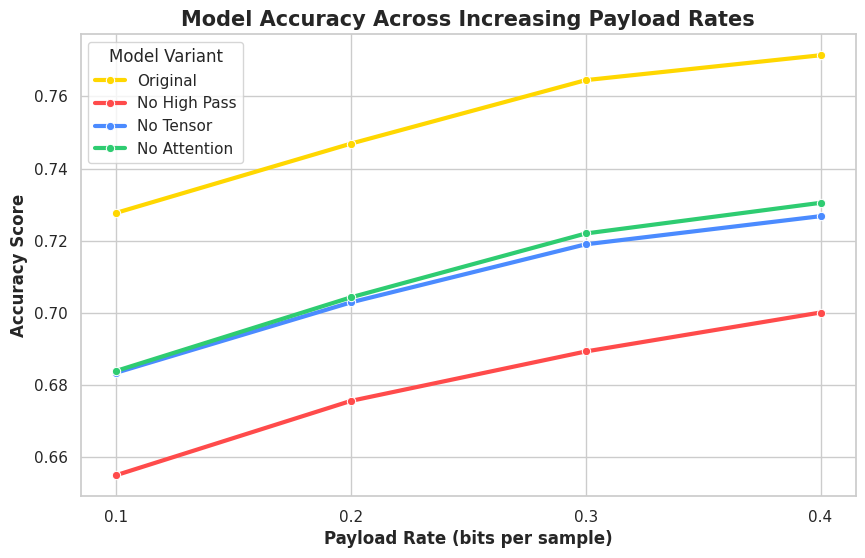

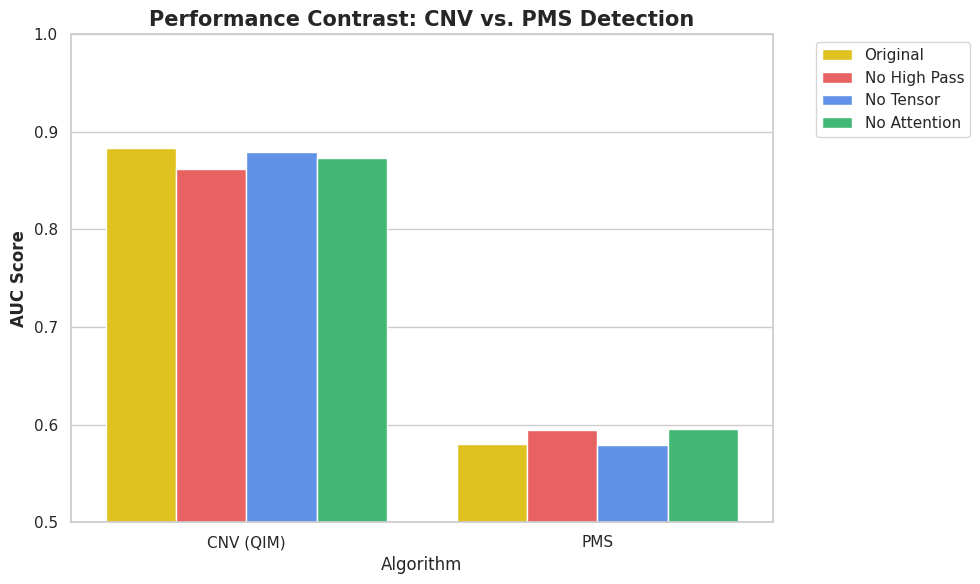

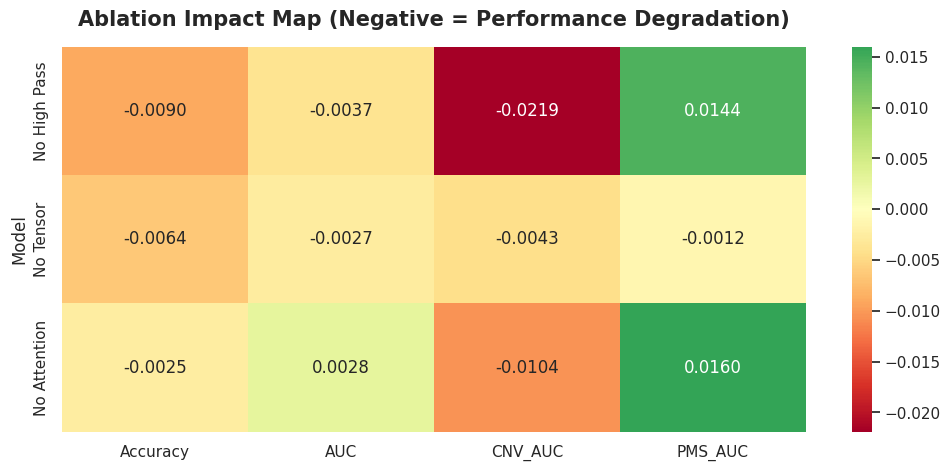

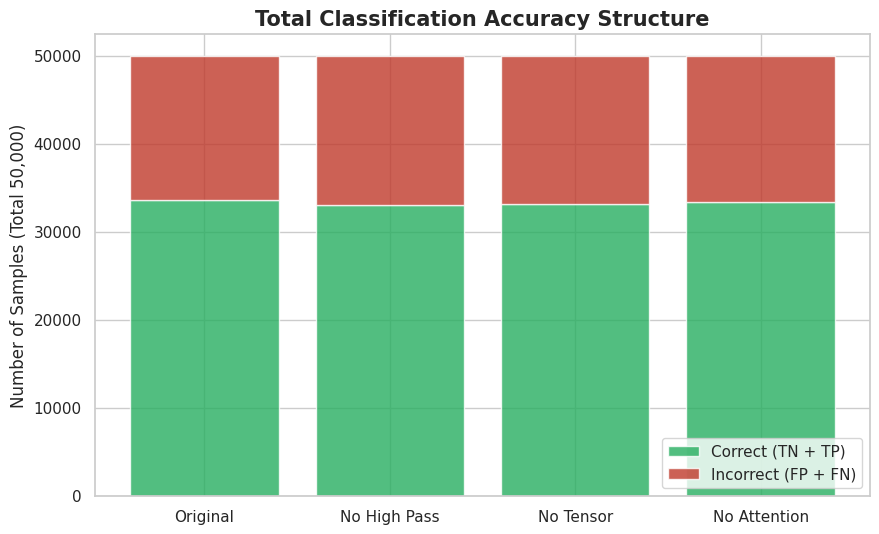

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- COLORS ---
colors = ["#FFD700", "#FF4B4B", "#4B8BFF", "#2ECC71"]
sns.set_theme(style="whitegrid")

# --- DATA: Overall Metrics ---
data_metrics = {
    'Model': ['Original', 'No High Pass', 'No Tensor', 'No Attention'],
    'Accuracy': [0.6704, 0.6614, 0.6640, 0.6679],
    'AUC': [0.7317, 0.7280, 0.7290, 0.7345],
    'CNV_AUC': [0.8834, 0.8615, 0.8791, 0.8730],
    'PMS_AUC': [0.5800, 0.5944, 0.5788, 0.5960]
}
df_metrics = pd.DataFrame(data_metrics)

# --- DATA: Payload Rates (Accuracy values extracted from logs) ---
payload_data = {
    'Rate': [0.1, 0.2, 0.3, 0.4],
    'Original': [0.7277, 0.7469, 0.7645, 0.7714],
    'No High Pass': [0.6550, 0.6756, 0.6893, 0.7001],
    'No Tensor': [0.6834, 0.7029, 0.7190, 0.7268],
    'No Attention': [0.6839, 0.7043, 0.7220, 0.7305]
}
df_payload = pd.DataFrame(payload_data).melt(id_vars='Rate', var_name='Model', value_name='Accuracy')

# --- DATA: Algorithm Comparison ---
algo_data = {
    'Algorithm': ['CNV (QIM)', 'PMS'],
    'Original': [0.8834, 0.5800],
    'No High Pass': [0.8615, 0.5944],
    'No Tensor': [0.8791, 0.5788],
    'No Attention': [0.8730, 0.5960]
}
df_algo = pd.DataFrame(algo_data).melt(id_vars='Algorithm', var_name='Model', value_name='AUC')

# --- FUNCTIONS ---

def plot_payload_line(df_p):
    plt.figure(figsize=(10, 6))
    # Note: Using 'Accuracy' here as requested
    sns.lineplot(data=df_p, x='Rate', y='Accuracy', hue='Model', marker='o', linewidth=3, palette=colors)
    plt.title("Model Accuracy Across Increasing Payload Rates", fontsize=15, fontweight='bold')
    plt.xlabel("Payload Rate (bits per sample)", fontweight='bold')
    plt.ylabel("Accuracy Score", fontweight='bold')
    plt.xticks([0.1, 0.2, 0.3, 0.4])
    plt.legend(title="Model Variant")
    plt.show()

def plot_algo_comparison(df_a):
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_a, x='Algorithm', y='AUC', hue='Model', palette=colors)
    plt.title("Performance Contrast: CNV vs. PMS Detection", fontsize=15, fontweight='bold')
    plt.ylabel("AUC Score", fontweight='bold')
    plt.ylim(0.5, 1.0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

def plot_ablation_heatmap(df_m):
    plt.figure(figsize=(12, 5))
    metrics_cols = ['Accuracy', 'AUC', 'CNV_AUC', 'PMS_AUC']
    orig_vals = df_m.iloc[0][metrics_cols].values.astype(float)
    diff_data = df_m[metrics_cols].values.astype(float) - orig_vals
    diff_df = pd.DataFrame(diff_data, columns=metrics_cols)
    diff_df['Model'] = df_m['Model']
    diff_df = diff_df.drop(0).set_index('Model')

    sns.heatmap(diff_df, annot=True, fmt=".4f", cmap="RdYlGn", center=0)
    plt.title("Ablation Impact Map (Negative = Performance Degradation)", fontsize=15, fontweight='bold', pad=15)
    plt.show()

def plot_error_structure():
    models = ['Original', 'No High Pass', 'No Tensor', 'No Attention']
    correct = [19894 + 13684, 17312 + 15758, 18436 + 14763, 18462 + 14932]
    incorrect = [5106 + 11316, 7688 + 9242, 6564 + 10237, 6538 + 10068]

    plt.figure(figsize=(10, 6))
    plt.bar(models, correct, label='Correct (TN + TP)', color='#27AE60', alpha=0.8)
    plt.bar(models, incorrect, bottom=correct, label='Incorrect (FP + FN)', color='#C0392B', alpha=0.8)
    plt.title("Total Classification Accuracy Structure", fontsize=15, fontweight='bold')
    plt.ylabel("Number of Samples (Total 50,000)")
    plt.legend(loc='lower right')
    plt.show()

# ============================================================================
# EXECUTION
# ============================================================================
plot_payload_line(df_payload)
plot_algo_comparison(df_algo)
plot_ablation_heatmap(df_metrics)
plot_error_structure()

In [ ]:
import pandas as pd
from tabulate import tabulate
from IPython.display import display

# 1. ORGANIZE DATA
models = ['Original', 'No High Pass', 'No Tensor', 'No Attention']

overall_data = {
    'Model': models,
    'Accuracy': [0.6704, 0.6614, 0.6640, 0.6679],
    'Precision': [0.7348, 0.6721, 0.6922, 0.6955],
    'Recall': [0.5333, 0.6303, 0.5905, 0.5973],
    'F1-Score': [0.6180, 0.6505, 0.6373, 0.6427],
    'AUC': [0.7317, 0.7280, 0.7290, 0.7345]
}

algo_data = {
    'Model': models,
    'CNV (QIM) AUC': [0.8834, 0.8615, 0.8791, 0.8730],
    'PMS AUC': [0.5800, 0.5944, 0.5788, 0.5960]
}

# Values extracted from PER-PAYLOAD PERFORMANCE (ACC Column)
payload_acc = {
    'Model': models,
    'Rate 0.1': [0.7277, 0.6550, 0.6834, 0.6839],
    'Rate 0.2': [0.7469, 0.6756, 0.7029, 0.7043],
    'Rate 0.3': [0.7645, 0.6893, 0.7190, 0.7220],
    'Rate 0.4': [0.7714, 0.7001, 0.7268, 0.7305]
}

# 2. CREATE DATAFRAMES
df_overall = pd.DataFrame(overall_data)
df_algo = pd.DataFrame(algo_data)
df_payload = pd.DataFrame(payload_acc)

# 3. IMPACT ANALYSIS (DELTA)
orig_acc = df_overall.iloc[0]['Accuracy']
df_impact = df_overall[['Model', 'Accuracy']].copy()
df_impact['Accuracy Drop'] = ((df_impact['Accuracy'] - orig_acc) / orig_acc * 100).round(2)
# Format the drop as a string with % sign
df_impact['Accuracy Drop (%)'] = df_impact['Accuracy Drop'].apply(lambda x: f"{x:+.2f}%")

# ============================================================================
# A: TABULATE (Best for Console/Text Logs)
# ============================================================================
def print_neat_table(df, title):
    print(f"\n--- {title} ---")
    # Using 'psql' format for a clean ASCII look
    print(tabulate(df, headers='keys', tablefmt='psql', showindex=False))

print_neat_table(df_overall, "Table 1: Overall Model Metrics")
print_neat_table(df_impact[['Model', 'Accuracy', 'Accuracy Drop (%)']], "Table 2: Ablation Impact Analysis")

# ============================================================================
# B: PANDAS STYLE (Best for Colab/Jupyter)
# ============================================================================
def style_table(df, title):
    print(f"\nDisplaying Styled Table: {title}")
    styled = df.style.set_caption(title)\
        .highlight_max(axis=0, color='lightgreen', subset=df.columns[1:])\
        .background_gradient(cmap='RdYlGn', subset=df.columns[1:])\
        .format(precision=4)\
        .set_properties(**{'text-align': 'center', 'border': '1px solid black'})\
        .set_table_styles([{'selector': 'th', 'props': [('background-color', '#34495e'), ('color', 'white')]}])
    display(styled)

style_table(df_overall, "Overall Metric Comparison")
style_table(df_payload, "Accuracy Across Payloads")
style_table(df_algo, "Algorithm Specific AUC Performance")


--- Table 1: Overall Model Metrics ---
+--------------+------------+-------------+----------+------------+--------+
| Model        |   Accuracy |   Precision |   Recall |   F1-Score |    AUC |
|--------------+------------+-------------+----------+------------+--------|
| Original     |     0.6704 |      0.7348 |   0.5333 |     0.618  | 0.7317 |
| No High Pass |     0.6614 |      0.6721 |   0.6303 |     0.6505 | 0.728  |
| No Tensor    |     0.664  |      0.6922 |   0.5905 |     0.6373 | 0.729  |
| No Attention |     0.6679 |      0.6955 |   0.5973 |     0.6427 | 0.7345 |
+--------------+------------+-------------+----------+------------+--------+

--- Table 2: Ablation Impact Analysis ---
+--------------+------------+---------------------+
| Model        |   Accuracy | Accuracy Drop (%)   |
|--------------+------------+---------------------|
| Original     |     0.6704 | +0.00%              |
| No High Pass |     0.6614 | -1.34%              |
| No Tensor    |     0.664  | -0.95%     

,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Original,0.6704,0.7348,0.5333,0.6180,0.7317
1,No High Pass,0.6614,0.6721,0.6303,0.6505,0.7280
2,No Tensor,0.6640,0.6922,0.5905,0.6373,0.7290
3,No Attention,0.6679,0.6955,0.5973,0.6427,0.7345



Displaying Styled Table: Accuracy Across Payloads


,Model,Rate 0.1,Rate 0.2,Rate 0.3,Rate 0.4
0,Original,0.7277,0.7469,0.7645,0.7714
1,No High Pass,0.6550,0.6756,0.6893,0.7001
2,No Tensor,0.6834,0.7029,0.7190,0.7268
3,No Attention,0.6839,0.7043,0.7220,0.7305



Displaying Styled Table: Algorithm Specific AUC Performance


,Model,CNV (QIM) AUC,PMS AUC
0,Original,0.8834,0.5800
1,No High Pass,0.8615,0.5944
2,No Tensor,0.8791,0.5788
3,No Attention,0.8730,0.5960


#**MODEL DEMONSTRATION**

In [ ]:
# Install everything in one go and force compatibility
!pip install --upgrade "numpy<2.1" "pandas<2.3" captum fpdf openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 59.2 MB/s eta 0:00:00
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=36d1a1c29a222f242a43bd01fdf0ea149160ca994586154da8ef61792d0097b6
  Stored in directory: /root/.cache/pip/wheels/6e/62/11/dc73d78e40a218ad52e7451f30166e94491be013a7850b5d75
Successfully built fpdf
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstal

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib
import time
from datetime import datetime
from scipy.stats import spearmanr, ttest_rel
from captum.attr import IntegratedGradients, Occlusion
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from fpdf import FPDF

# ============================================================================
# 1.  MODEL ARCHITECTURE
# ============================================================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G729A_BIT_MAP = {
    "LSP_L0": range(0, 1), "LSP_L1": range(1, 8), "LSP_L2": range(8, 13), "LSP_L3": range(13, 18),
    "Adaptive_CB_Index_P1": range(18, 26), "Parity_P0": range(26, 27), "Fixed_CB_Index_C1": range(27, 40),
    "Fixed_CB_Signs_S1": range(40, 44), "Pitch_Gain_GA1": range(44, 47), "Fixed_CB_Gain_GB1": range(47, 50),
    "Adaptive_CB_Index_P2": range(50, 55), "Fixed_CB_Index_C2": range(55, 68), "Fixed_CB_Signs_S2": range(68, 72),
    "Pitch_Gain_GA2": range(72, 75), "Fixed_CB_Gain_GB2": range(75, 78), "Unused_Sync": range(78, 80)
}

class DualPathwayForensicLayer(nn.Module):
    """
    Dual-Pathway Preprocessing Block:
    1. Fixed Pathway: Deterministic high-pass filters to prevent signal smoothing.
    2. Learnable Pathway: Dynamic filters to catch unforeseen stego traces.
    """
    def __init__(self):
        super().__init__()

        # --- FIXED PATHWAY (Deterministic Truths) ---
        # 1st Order (Sudden flips)
        hp1 = torch.tensor([[[[-1., 1.]]]], dtype=torch.float32)
        # 2nd Order (Local curvature)
        hp2 = torch.tensor([[[[-1., 2., -1.]]]], dtype=torch.float32)
        # 3rd Order (Complex sequential flips)
        hp3 = torch.tensor([[[[-1., 3., -3., 1.]]]], dtype=torch.float32)
        # 3x3 Spatial Laplacian (Cross-dimensional anomalies)
        hp_spatial = torch.tensor([[[[-1., -1., -1.],
                                     [-1.,  8., -1.],
                                     [-1., -1., -1.]]]], dtype=torch.float32)

        self.register_buffer('kernel1', hp1)
        self.register_buffer('kernel2', hp2)
        self.register_buffer('kernel3', hp3)
        self.register_buffer('kernel_spatial', hp_spatial)

        # --- LEARNABLE PATHWAY (Dynamic Features) ---
        # Extracts 2 learnable channels from the raw bits
        self.learnable_filters = nn.Conv2d(1, 2, kernel_size=3, padding=1, bias=False)
        nn.init.xavier_normal_(self.learnable_filters.weight)

    def forward(self, x):
        # Apply residuals to Channel 1 (Raw Bits)
        raw_bits = x[:, 0:1, :, :]

        # 1. Apply Fixed Kernels
        res1 = F.conv2d(raw_bits, self.kernel1, padding=(0, 0))
        res2 = F.conv2d(raw_bits, self.kernel2, padding=(0, 0))
        res3 = F.conv2d(raw_bits, self.kernel3, padding=(0, 0))
        res_sp = F.conv2d(raw_bits, self.kernel_spatial, padding=1) # 3x3 needs padding=1

        # Pad 1D residuals to match original (100, 80) dimensions
        res1 = F.pad(res1, (0, 1, 0, 0))
        res2 = F.pad(res2, (1, 1, 0, 0))
        res3 = F.pad(res3, (1, 2, 0, 0)) # Pad to offset kernel size 4

        # 2. Apply Learnable Kernels
        learned_res = self.learnable_filters(raw_bits)

        # Return all 6 generated channels (4 fixed + 2 learned)
        return torch.cat([res1, res2, res3, res_sp, learned_res], dim=1)


class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                   padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        x = F.relu(self.bn1(self.depthwise(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.pointwise(x)))
        return x

class ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.dropout = nn.Dropout2d(dropout)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.dropout(out)
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)

# --- Lightweight Channel Attention (SE Block) ---
class SEBlock(nn.Module):
    """Squeeze-and-Excitation block to recalibrate channel saliency."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

class SpatialAttention(nn.Module):
    """Generates the XAI Heatmap for forensic review."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        attn_weights = self.sigmoid(out)
        return x * attn_weights, attn_weights

class StegoCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.hp_layer = DualPathwayForensicLayer()

        # Input is now 9 channels:
        self.init_conv = nn.Sequential(
            nn.Conv2d(9, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.dw_conv = DepthwiseSeparableConv(32, 64, dropout=0.1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.attention = SpatialAttention()

        self.res_block1 = ResidualBlock(64, dropout=0.1)
        self.se1 = SEBlock(64, reduction=16)
        self.res_block2 = ResidualBlock(64, dropout=0.1)
        self.se2 = SEBlock(64, reduction=16)

        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # 1. Extract Dual-Pathway Residuals (Extracts 6 channels from raw bits)
        hp_features = self.hp_layer(x)

        # 2. Concatenate with original input
        # [Batch, 3, 100, 80] + [Batch, 6, 100, 80] -> [Batch, 9, 100, 80]
        x = torch.cat([x, hp_features], dim=1)

        # 3. Pass the 9-channel tensor into the pipeline
        x = self.init_conv(x)
        x = self.pool2(self.dw_conv(x))
        x, attn_weights = self.attention(x)

        x = self.res_block1(x)
        x = self.se1(x)
        x = self.res_block2(x)
        x = self.se2(x)

        mean_x = torch.mean(x, dim=[2, 3])
        std_x = torch.std(x, dim=[2, 3])
        x = torch.cat([mean_x, std_x], dim=1)

        out = self.fc(x)
        return out, attn_weights

# ============================================================================
# 2. PREPROCESSING
# ============================================================================

def preprocess_g729a(file_path):
    with open(file_path, 'rb') as f:
        data = f.read()[:1000]
    bits = np.unpackbits(np.frombuffer(data, dtype=np.uint8)).reshape(-1, 80).astype(np.float32)
    bits = bits[:100, :]
    diff = np.zeros_like(bits); diff[1:] = np.abs(bits[1:] - bits[:-1])
    stability = np.abs(bits - np.mean(bits, axis=0, keepdims=True))
    return torch.from_numpy(np.stack([bits, diff, stability], axis=0)).unsqueeze(0).to(DEVICE)

# ============================================================================
# 3. INTEGRATED RIGOROUS AUSPEX REPORTER
# ============================================================================

class AuspexReporter:
    def __init__(self, model, device, threshold=0.5229):
        self.model = model.to(device).eval()
        self.device = device
        self.threshold = threshold
        # Wrapped for Captum
        self.ig = IntegratedGradients(lambda x: self.model(x)[0])
        self.channel_names = ['Raw Bits', 'Temp. Diff', 'Bit Stability']
        self.img_w = 130
        self.small_img_w = 90
        self.center_x = (210 - self.img_w) / 2
        self.center_x_small = (210 - self.small_img_w) / 2

    def _get_file_hash(self, file_path):
        hasher = hashlib.md5()
        try:
            with open(file_path, 'rb') as f:
                for chunk in iter(lambda: f.read(4096), b""): hasher.update(chunk)
            return hasher.hexdigest()
        except: return "HASH_ERROR"

    def _compute_bit_flip_impact(self, tensor, batch_size=256):
        """Rigorous Causal Analysis: Physically flipping bits to measure impact."""
        self.model.eval()
        x = tensor.clone().to(self.device).contiguous()
        with torch.no_grad():
            base_prob = torch.sigmoid(self.model(x)[0]).item()

        flat_x = x.view(-1)
        num_bits = len(flat_x)
        impacts = []

        for i in range(0, num_bits, batch_size):
            end = min(i + batch_size, num_bits)
            x_batch = x.repeat(end - i, 1, 1, 1).contiguous()
            for local_idx, global_idx in enumerate(range(i, end)):
                x_batch[local_idx].view(-1)[global_idx] = 1 - x_batch[local_idx].view(-1)[global_idx]

            with torch.no_grad():
                probs = torch.sigmoid(self.model(x_batch)[0]).cpu().numpy()
                impacts.extend(np.abs(probs - base_prob))

        return np.array(impacts).reshape(tensor.squeeze(0).shape)

    def _evaluate_insertion(self, tensor, attr, steps=20):
        """Rigorous Check: Starting from a blank signal, does adding 'guilty' bits restore confidence?"""
        idx = np.argsort(-np.abs(attr).flatten())
        step_sz = len(idx) // steps
        x_orig = tensor.clone().to(self.device).contiguous()
        x_base = torch.full_like(x_orig, x_orig.mean()) # Baseline (neutral)

        insertion_scores = []
        for i in range(steps + 1):
            x_ins = x_base.clone()
            x_ins.view(-1)[idx[:i*step_sz]] = x_orig.view(-1)[idx[:i*step_sz]]
            with torch.no_grad():
                insertion_scores.append(torch.sigmoid(self.model(x_ins)[0]).item())
        return insertion_scores

    def _get_topk_sensitivity(self, tensor, attr, k=0.1):
        """Concentration Check: Does the score hold if we ONLY keep top bits?"""
        x = tensor if tensor.dim() == 4 else tensor.unsqueeze(0)
        flat_attr = attr.flatten()
        idx = np.argsort(-np.abs(flat_attr))[:int(len(flat_attr) * k)]

        x_top = torch.full_like(x, x.mean()).to(self.device)
        x_top.view(-1)[idx] = x.view(-1)[idx]
        with torch.no_grad():
            return torch.sigmoid(self.model(x_top)[0]).item()

    def _get_bottomk_sensitivity(self, tensor, attr, k=0.2):
        """Negative Control: Does the score stay stable if we remove 'unimportant' bits?"""
        x = tensor if tensor.dim() == 4 else tensor.unsqueeze(0)
        flat_attr = attr.flatten()
        idx = np.argsort(np.abs(flat_attr))[:int(len(flat_attr) * k)]

        x_stable = x.clone()
        x_stable.view(-1)[idx] = x.mean()
        with torch.no_grad():
            return torch.sigmoid(self.model(x_stable)[0]).item()
    def _evaluate_faithfulness(self, tensor, attr, steps=20):
        """Calculates how fast model confidence drops when removing 'guilty' bits."""
        idx = np.argsort(-np.abs(attr).flatten())
        step_sz = len(idx) // steps
        x_orig = tensor.clone().to(self.device).contiguous()

        deletion_scores = []
        for i in range(steps + 1):
            x_del = x_orig.clone()
            x_del.view(-1)[idx[:i*step_sz]] = x_orig.mean()
            with torch.no_grad():
                deletion_scores.append(torch.sigmoid(self.model(x_del)[0]).item())
        return deletion_scores

    def _test_robustness(self, tensor, attr_orig, flip_prob=0.01):
        """Measures if the explanation stays the same if we add a tiny bit of noise."""
        flipped = tensor.clone()
        mask = torch.rand_like(flipped) < flip_prob
        flipped[mask] = 1 - flipped[mask]

        attr_noisy = self.ig.attribute(flipped, target=0, n_steps=20).squeeze(0).cpu().detach().numpy()
        stability, _ = spearmanr(attr_orig.flatten(), attr_noisy.flatten())
        return stability

    def _get_codec_interpretation(self, attr):
        """Maps attribution back to G.729a parameters (LSP, Pitch, Codebook)."""
        bit_importance = np.abs(attr).mean(axis=0)
        forensic_summary = {}
        for param, indices in G729A_BIT_MAP.items():
            forensic_summary[param] = float(bit_importance[indices].mean())
        return sorted(forensic_summary.items(), key=lambda x: x[1], reverse=True)


    def generate_report(self, tensor, sample_name, output_path, raw_file_path=None):
        # 1. Neural Attribution (IG)
        input_t = tensor.clone().requires_grad_(True)
        with torch.no_grad():
            logits, _ = self.model(input_t)
            prob = torch.sigmoid(logits).item()

        attr = self.ig.attribute(input_t, target=0, n_steps=50).squeeze(0).cpu().detach().numpy()

        # 2. Rigorous Causal Analysis (Bit-Flip)
        bit_flip_map = self._compute_bit_flip_impact(tensor)

        # 3. Calculate Rigor Metrics (Correlation between IG and Bit-Flip)
        correlation, _ = spearmanr(np.abs(attr).flatten(), bit_flip_map.flatten())
        file_hash = self._get_file_hash(raw_file_path) if raw_file_path else "N/A"

        # 4. Generate Visuals
        img_paths = self._create_rigorous_plots(tensor.squeeze(0), attr, bit_flip_map)

        # Verdict Logic
        if prob > (self.threshold + 0.1): risk, status, b_color = "HIGH RISK", "COMPROMISED", (231, 76, 60)
        elif prob > self.threshold: risk, status, b_color = "SUSPICIOUS", "COMPROMISED", (231, 76, 60)
        elif prob > (self.threshold - 0.1): risk, status, b_color = "UNCERTAIN", "INCONCLUSIVE", (241, 196, 15)
        else: risk, status, b_color = "LIKELY CLEAN", "CLEAN", (46, 204, 113)

        pdf = FPDF()

        # --- PAGE 1: HEADER & IDENTIFICATION ---
        pdf.add_page()
        pdf.set_fill_color(30, 35, 45); pdf.rect(0, 0, 210, 40, 'F') # Slightly larger header
        pdf.set_text_color(255, 255, 255); pdf.set_font("Helvetica", 'B', 18)
        pdf.cell(190, 10, "AUSPEX: FORENSIC AUDIT", ln=True, align='C')
        pdf.set_font("Helvetica", 'I', 9)
        pdf.cell(190, 5, f"Causal Validation Enabled | MD5: {file_hash}", ln=True, align='C')
        pdf.ln(5)

        # Examiner & Methodology Identification
        pdf.set_font("Helvetica", 'B', 10); pdf.set_text_color(200, 200, 200)
        pdf.cell(95, 5, f"LEAD EXAMINER: Sarah Rahim", align='L')
        pdf.cell(95, 5, f"DATE: {datetime.now().strftime('%Y-%m-%d %H:%M')}", align='R', ln=True)
        pdf.ln(10)

        # [1] Metadata
        pdf.set_text_color(0, 0, 0); pdf.set_font("Helvetica", 'B', 10); pdf.set_fill_color(240, 240, 240)
        pdf.cell(190, 7, " [1] ANALYSIS CONTEXT & METHODOLOGY", ln=True, fill=True); pdf.set_font("Courier", '', 9); pdf.ln(1)
        pdf.cell(190, 5, f" > SAMPLE ID: {sample_name}", ln=True)
        pdf.set_font("Courier", 'B', 9)
        pdf.cell(190, 5, f" > METHOD: AUSPEX-v2 Protocol (Residual-CNN + Integrated Gradients + Causal Bit-Flip)", ln=True)
        # Calculate new rigor metrics
        stability_score = self._test_robustness(tensor, attr)
        codec_findings = self._get_codec_interpretation(attr)

        # Add to Metadata display
        pdf.cell(190, 5, f" > EXPLAINABILITY FAITHFULNESS (Spearman): {correlation:.4f}", ln=True)
        pdf.cell(190, 5, f" > EXPLANATION STABILITY (Robustness): {stability_score:.4f}", ln=True)

        topk_score = self._get_topk_sensitivity(tensor, attr, k=0.1)
        pdf.cell(190, 5, f" > TOP-10% BIT SENSITIVITY (Concentration): {topk_score:.4f}", ln=True)
        pdf.set_font("Courier", 'B', 9); pdf.cell(190, 5, f" > INITIAL FIELD VERDICT: {status}", ln=True); pdf.ln(2)

        # [2] Risk Gauge
        pdf.set_font("Helvetica", 'B', 10); pdf.cell(190, 7, " [2] CALIBRATED RISK ASSESSMENT", ln=True, fill=True); pdf.ln(3)
        pdf.set_x(45); pdf.set_font("Helvetica", 'B', 7)
        pdf.cell(40, 3, "LIKELY CLEAN", align='L'); pdf.cell(40, 3, "UNCERTAIN", align='C'); pdf.cell(40, 3, "HIGH RISK", align='R', ln=True)
        pdf.set_draw_color(200, 200, 200); pdf.rect(45, pdf.get_y(), 120, 4); pdf.set_fill_color(*b_color); pdf.rect(45, pdf.get_y(), 120 * prob, 4, 'F')
        pdf.set_draw_color(0, 0, 0); pdf.set_line_width(0.5); pdf.line(45 + (120 * self.threshold), pdf.get_y()-1, 45 + (120 * self.threshold), pdf.get_y()+5)
        pdf.set_y(pdf.get_y() + 5); pdf.set_font("Helvetica", 'B', 9)
        pdf.cell(190, 5, f"Neural Score: {prob:.4f} | Forensic Status: {status}", align='C', ln=True); pdf.ln(3)

        # [3] Combined Physical Artifact
        pdf.set_font("Helvetica", 'B', 10); pdf.cell(190, 7, " [3] PHYSICAL SIGNAL AUDIT (RAW VS RESIDUAL)", ln=True, fill=True); pdf.ln(2)
        pdf.image(img_paths[0], x=10, y=None, w=190)

        # --- PAGE 2: DECISION EVIDENCE ---
        pdf.add_page(); pdf.ln(5)
        pdf.set_font("Helvetica", 'B', 10); pdf.cell(190, 7, " [4] EXPLAINABLE DECISION EVIDENCE", ln=True, fill=True); pdf.ln(3)
        pdf.image(img_paths[2], x=self.center_x, y=None, w=self.img_w); pdf.ln(4)
        pdf.image(img_paths[3], x=self.center_x, y=None, w=self.img_w); pdf.ln(8)
        pdf.set_font("Helvetica", 'B', 10); pdf.cell(190, 7, " [5] CHANNEL ATTRIBUTION WEIGHT", ln=True, fill=True); pdf.ln(3)
        pdf.image(img_paths[4], x=self.center_x_small, y=None, w=self.small_img_w)

        # --- PAGE 3: RIGOROUS CAUSAL VALIDATION ---
        pdf.add_page(); pdf.ln(5)
        pdf.set_font("Helvetica", 'B', 10); pdf.cell(190, 7, " [6] RIGOROUS CAUSAL VALIDATION (BIT-FLIP ANALYSIS)", ln=True, fill=True); pdf.ln(3)
        pdf.image(img_paths[5], x=self.center_x, y=None, w=self.img_w)
        pdf.set_font("Helvetica", 'I', 8); pdf.ln(2)
        pdf.multi_cell(190, 4, "Note: This section compares Neural Influence (IG) with Causal Impact (Bit-Flip). High alignment (bright overlap) confirms that the bits identified by the XAI core are physically responsible for the model's verdict.")

        pdf.ln(5)
        pdf.set_font("Helvetica", 'B', 10); pdf.cell(190, 7, " [7] CODEC PARAMETER COMPROMISE ANALYSIS", ln=True, fill=True); pdf.ln(3)

        pdf.set_font("Courier", 'B', 9)
        pdf.cell(95, 7, " G.729a Parameter Field", border=1); pdf.cell(95, 7, " Neural Sensitivity (Avg Attr)", border=1, ln=True)

        pdf.set_font("Courier", '', 9)
        for param, importance in codec_findings[:8]: # Show top 8
            pdf.cell(95, 6, f" {param}", border=1)
            pdf.cell(95, 6, f" {importance:.6f}", border=1, ln=True)

        pdf.ln(5)
        pdf.image(img_paths[6], x=self.center_x, y=None, w=self.img_w)
        pdf.set_font("Helvetica", 'I', 8)
        pdf.multi_cell(190, 4, "Validation: The Deletion Curve shows the drop in model confidence as evidence is removed. A steep drop confirms the model is relying on robust forensic traces rather than noise.")

        # --- PAGE 4: GUIDANCE, LIMITATIONS & VERDICT ---
        pdf.add_page();
        pdf.ln(5); pdf.set_font("Helvetica", 'B', 10); pdf.cell(190, 7, " [8] ARTIFACT TECHNICAL DETAILS", ln=True, fill=True); pdf.ln(2)
        pdf.set_font("Helvetica", '', 8.5)
        details = [
            ("Fig 1 (Scan)", "Comparison of raw bitstream values against high-pass filtered forensic residuals."),
            ("Fig 2 (Focus)", "Spatiotemporal heatmap highlighting bit regions driving the model's primary classification."),
            ("Fig 3 (Weight)", "Quantification of neural sensitivity across raw, differential, and stability channels."),
            ("Fig 4 (Timeline)", "Temporal distribution of forensic saliency across the duration of the audio clip."),
            ("Fig 5 (Channels)", "Sensitivity distribution quantifying the influence of raw, differential, and stability features."),
            ("Fig 6 (Causal)", "Overlay validation comparing neural gradients against physical bit-flip impact results."),
            ("Fig 7 (Faithful)", "Statistical curve proving model confidence drops in direct response to evidence removal.")]
        for t, d in details:
            pdf.set_font("Helvetica", 'B', 8.5); pdf.cell(30, 4, f" {t}:", ln=0); pdf.set_font("Helvetica", '', 8.5); pdf.cell(160, 4, d, ln=True)

        # [8] Pipeline Limitations
        pdf.ln(3); pdf.set_font("Helvetica", 'B', 10); pdf.cell(190, 7, " [9] PIPELINE LIMITATIONS", ln=True, fill=True); pdf.ln(2)
        pdf.set_font("Helvetica", 'I', 8)
        lims = ["1. Sensitivity: Detection accuracy degrades at low embedding rates (< 0.1 bpc).",
                "2. Causal Scope: Bit-flip analysis is computationally intensive; limited to core bitstream.",
                "3. Attribution: Heatmaps indicate neural influence, not physical data extraction."]
        for l in lims: pdf.cell(190, 4, f" - {l}", ln=True)

        # [9] Investigative Findings
        pdf.ln(4); pdf.set_font("Helvetica", 'B', 11); pdf.cell(190, 8, " [10] INVESTIGATIVE FINDINGS", ln=True, fill=True); pdf.ln(2)
        pdf.set_font("Helvetica", '', 10)
        msg = "Findings: Indicators suggest pattern manipulation consistent with steganography." if prob > self.threshold else "Findings: Signal characteristics remain within natural variance."
        pdf.multi_cell(190, 5, f"{msg} Forensic secondary audit recommended." if prob > self.threshold else f"{msg} No further action required.")

        pdf.ln(10); pdf.set_font("Helvetica", 'B', 15); pdf.set_text_color(*b_color)
        pdf.cell(190, 15, f"!!! FINAL VERDICT: {status} !!!", border=1, ln=True, align='C')

        pdf.output(output_path)
        for p in img_paths:
            if os.path.exists(p): os.remove(p)

    def _create_rigorous_plots(self, tensor, attr, bitflip_map):
        paths = [f"v{i}.png" for i in range(1, 8)]

        def save_f(path, title, data, xl="", yl="", cmap=None, is_bar=False, sz=(10, 6)):
            plt.figure(figsize=sz)
            if is_bar:
                plt.bar(self.channel_names, data, color=['#5D6D7E', '#EB984E', '#17A589'], edgecolor='black')
                plt.ylabel(yl)
            elif cmap:
                im = plt.imshow(data, cmap=cmap, aspect='auto')
                plt.colorbar(im, fraction=0.046, pad=0.04)
                plt.xlabel(xl); plt.ylabel(yl)
            else:
                plt.fill_between(range(len(data)), data, color='teal', alpha=0.3)
                plt.plot(data, color='teal')
                plt.xlabel(xl); plt.ylabel(yl)
            plt.title(title, fontweight='bold', fontsize=14)
            plt.savefig(path, dpi=120, bbox_inches='tight'); plt.close()

        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        # Raw
        axes[0].imshow(tensor[0].cpu().numpy(), cmap='gray', aspect='auto')
        axes[0].set_title("A. Raw Bitstream Scan", fontweight='bold')
        axes[0].set_xlabel("Bit Offset (0-79)"); axes[0].set_ylabel("Frame Index")
        # Residual
        hp_k = torch.tensor([[[[-1., -1., -1.], [ -1.,  8., -1.], [-1., -1., -1.]]]]).to(self.device)
        res = F.conv2d(tensor.unsqueeze(0)[:, 0:1, :, :], hp_k, padding=1).squeeze().cpu().numpy()
        im1 = axes[1].imshow(res, cmap='inferno', aspect='auto')
        axes[1].set_title("B. Forensic Residual Scan (High-Pass)", fontweight='bold')
        axes[1].set_xlabel("Bit Offset"); axes[1].set_ylabel("Frame Index")
        plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
        plt.tight_layout(); plt.savefig(paths[0], dpi=150); plt.close() # Now paths[0] contains both

        # 3. Neural Focus (XAI)
        plt.figure(figsize=(10, 6))
        plt.imshow(tensor[0].cpu().numpy(), cmap='gray', alpha=0.3, aspect='auto')
        mask = np.abs(attr[0]) > np.percentile(np.abs(attr[0]), 98)
        overlay = np.ma.masked_where(~mask, attr[0])
        plt.imshow(overlay, cmap='cool', interpolation='none', aspect='auto')
        plt.title("3. Neural Decision Focus (XAI)", fontweight='bold')
        plt.xlabel("Bit Offset (0-79)"); plt.ylabel("Frame Index")
        plt.savefig(paths[2], dpi=120, bbox_inches='tight'); plt.close()

        # 4. Temporal Attribution
        save_f(paths[3], "4. Temporal Attribution Timeline", np.abs(attr).sum(axis=(0, 2)), xl="Frame Index (Time)", yl="Attribution Magnitude")

        # 5. Channel Influence
        imp = np.abs(attr).sum(axis=(1, 2))
        save_f(paths[4], "5. Attribution Intensity by Channel", (imp/imp.sum())*100, yl="Neural Influence (%)", is_bar=True, sz=(7, 4))

        # 6. Causal Alignment
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        h_ig = np.abs(attr).sum(axis=0); h_ig = (h_ig - h_ig.min()) / (h_ig.max() - h_ig.min() + 1e-8)
        h_bf = np.abs(bitflip_map).sum(axis=0); h_bf = (h_bf - h_bf.min()) / (h_bf.max() - h_bf.min() + 1e-8)

        titles = ["Neural IG Influence", "Causal Bit-Flip Impact", "Forensic Alignment Overlay"]
        for i, data in enumerate([h_ig, h_bf, None]):
            ax = axes[i]
            if i < 2:
                ax.imshow(data, cmap='hot' if i==0 else 'viridis', aspect='auto')
            else:
                ax.imshow(h_ig, cmap='hot', alpha=0.7, aspect='auto')
                ax.imshow(h_bf, cmap='viridis', alpha=0.3, aspect='auto')
            ax.set_title(titles[i], fontweight='bold')
            ax.set_xlabel("Bit Index"); ax.set_ylabel("Frame")
            for param, indices in G729A_BIT_MAP.items(): ax.axvline(x=indices[0], color='cyan', linestyle='--', alpha=0.1)
        plt.tight_layout(); plt.savefig(paths[5], dpi=150); plt.close()

        # 7. Dual-Curve Faithfulness
        del_scores = self._evaluate_faithfulness(tensor.unsqueeze(0), attr)
        ins_scores = self._evaluate_insertion(tensor.unsqueeze(0), attr)
        plt.figure(figsize=(10, 5))
        plt.plot(del_scores, label="Deletion (Evidence Removal)", color='#C0392B', marker='o')
        plt.plot(ins_scores, label="Insertion (Evidence Recovery)", color='#27AE60', marker='s')
        plt.title("7. Forensic Faithfulness: Dual-Curve Analysis", fontweight='bold')
        plt.xlabel("% of Top-Ranked Bits Affected (Evidence Ranking)"); plt.ylabel("Model Probability (Confidence)")
        plt.legend(); plt.grid(True, alpha=0.3); plt.savefig(paths[6], dpi=150); plt.close()

        return paths

# ============================================================================
# 4. MAIN EXECUTION
# ============================================================================

if __name__ == "__main__":
    MODEL_PATH = "/content/drive/MyDrive/IIT - University of Westminster Material/VStego800K dataset/Models/Auspex_Forensic_Final_Original_3SeedRun/Auspex_Forensic_Final_Original_3SeedRun_seed42_best.pt"
    TEST_FILE = "/content/Chinese136201.g729a"
    REPORT_PATH = "/content/Final_Forensic_Report.pdf"

    if os.path.exists(MODEL_PATH) and os.path.exists(TEST_FILE):
        print(" [!] Auspex Core Online. Initiating Rigorous field scan...")
        model = StegoCNN().to(DEVICE)
        ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model_state_dict'])

        print(f" [!] Analyzing Sample with Causal Validation: {os.path.basename(TEST_FILE)}")
        tensor = preprocess_g729a(TEST_FILE)

        reporter = AuspexReporter(model, DEVICE, threshold=0.5229)
        # Passing raw_file_path for MD5 hashing
        reporter.generate_report(tensor, os.path.basename(TEST_FILE), REPORT_PATH, raw_file_path=TEST_FILE)
        print(f" [!] Rigorous Forensic Report Complete: {REPORT_PATH}")
    else:
        print(" Error: Path verification failed.")

 [!] Auspex Core Online. Initiating Rigorous field scan...
 [!] Analyzing Sample with Causal Validation: Chinese136201.g729a
 [!] Rigorous Forensic Report Complete: /content/Final_Forensic_Report.pdf


 AUSPEX FORENSIC DASHBOARD: Chinese136201.g729a

[+] FIELD VERDICT: HIGH RISK / COMPROMISED
[+] NEURAL PROBABILITY: 0.9610
[+] FAITHFULNESS (IG vs Bit-Flip): 0.0564
[+] EXPLANATION STABILITY: 0.6997
----------------------------------------

[+] TOP CODEC PARAMETER VULNERABILITIES:
    Parity_P0           : 0.003333 ███
    LSP_L3              : 0.003214 ███
    Adaptive_CB_Index_P1: 0.003208 ███
    Pitch_Gain_GA2      : 0.003161 ███
    Pitch_Gain_GA1      : 0.003148 ███

[+] GENERATING FORENSIC VISUALS...

>> Raw Bitstream vs. Forensic Residuals


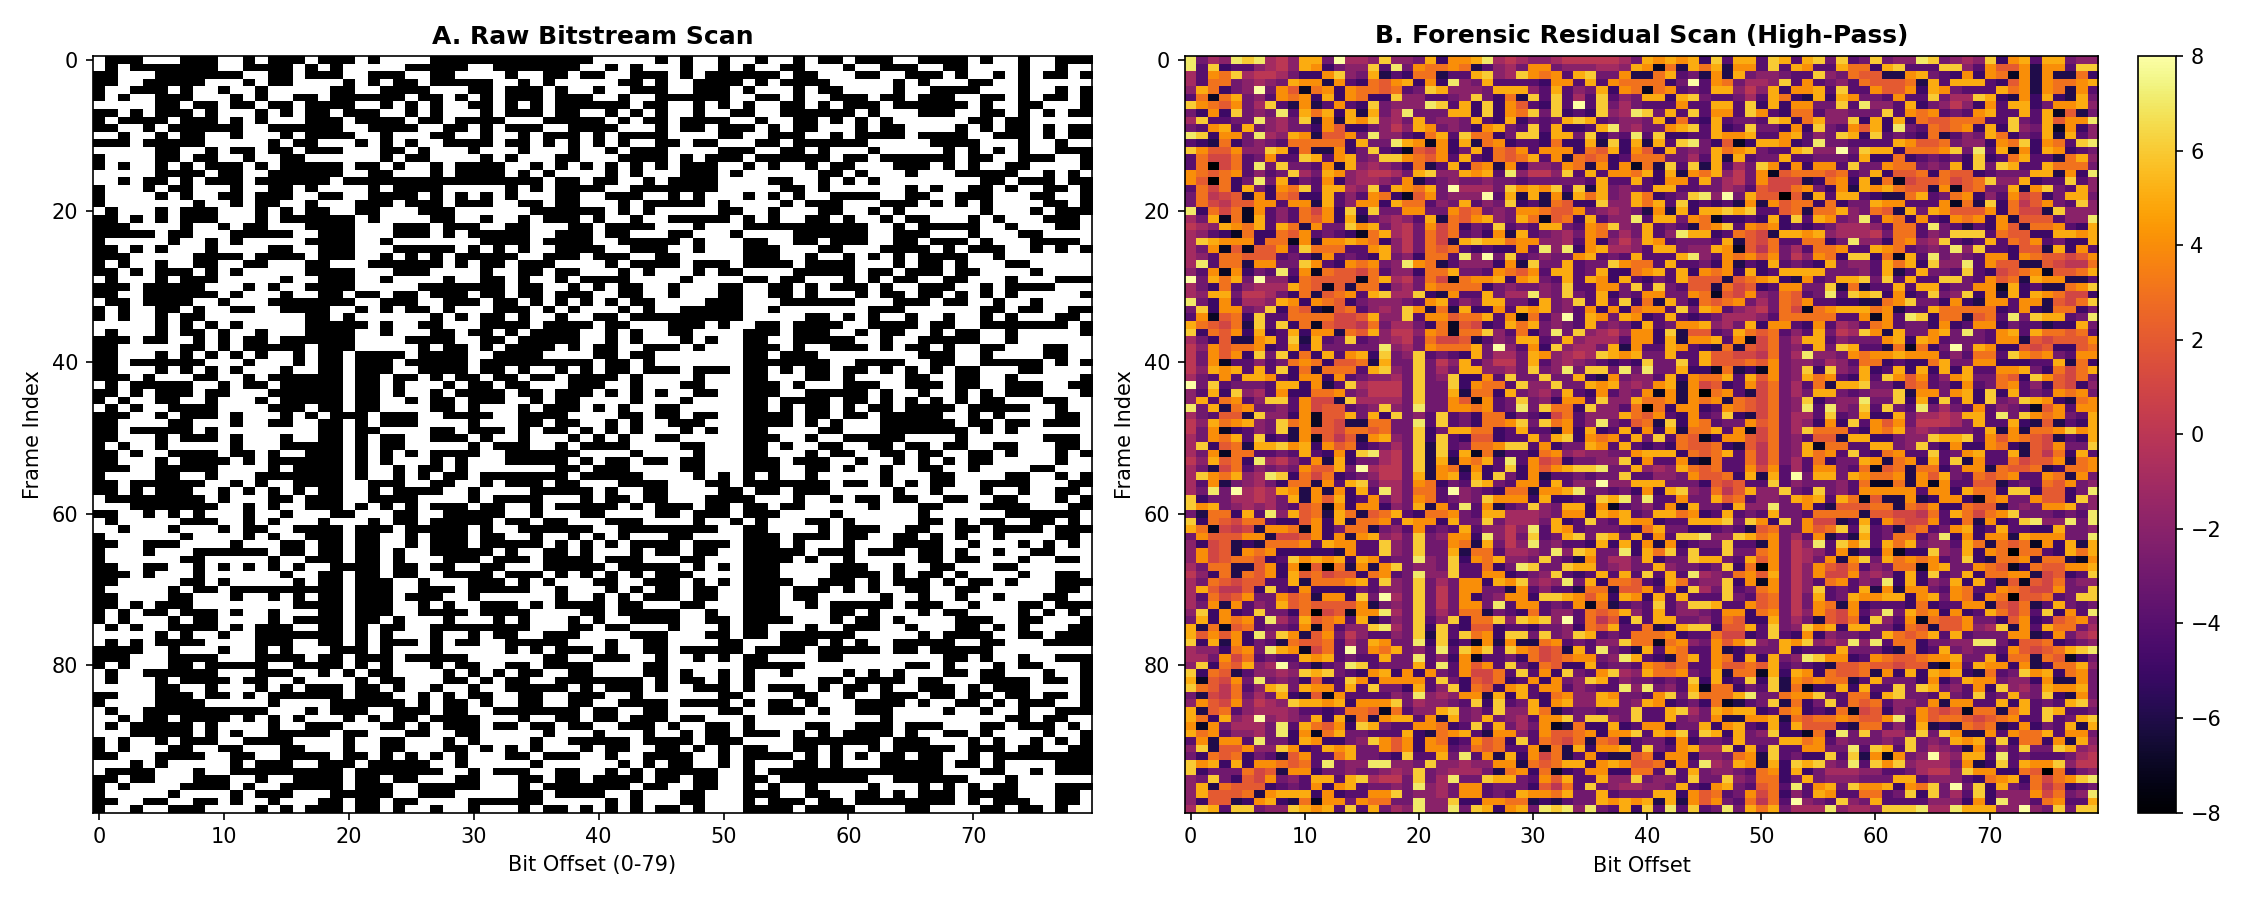


>> Neural Decision Focus (XAI Heatmap)


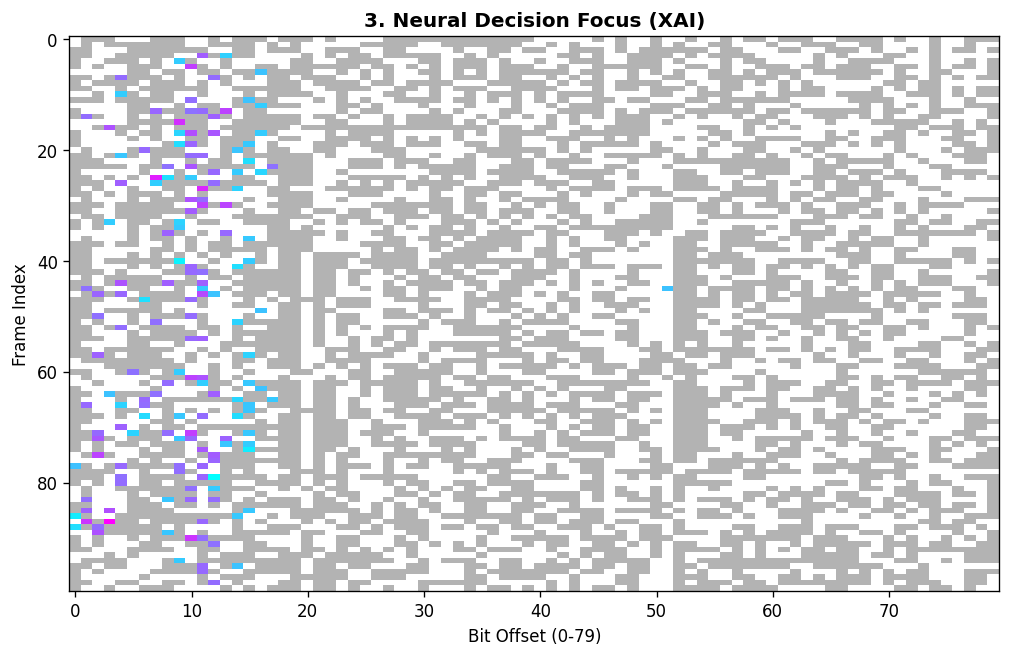


>> Temporal Attribution Timeline


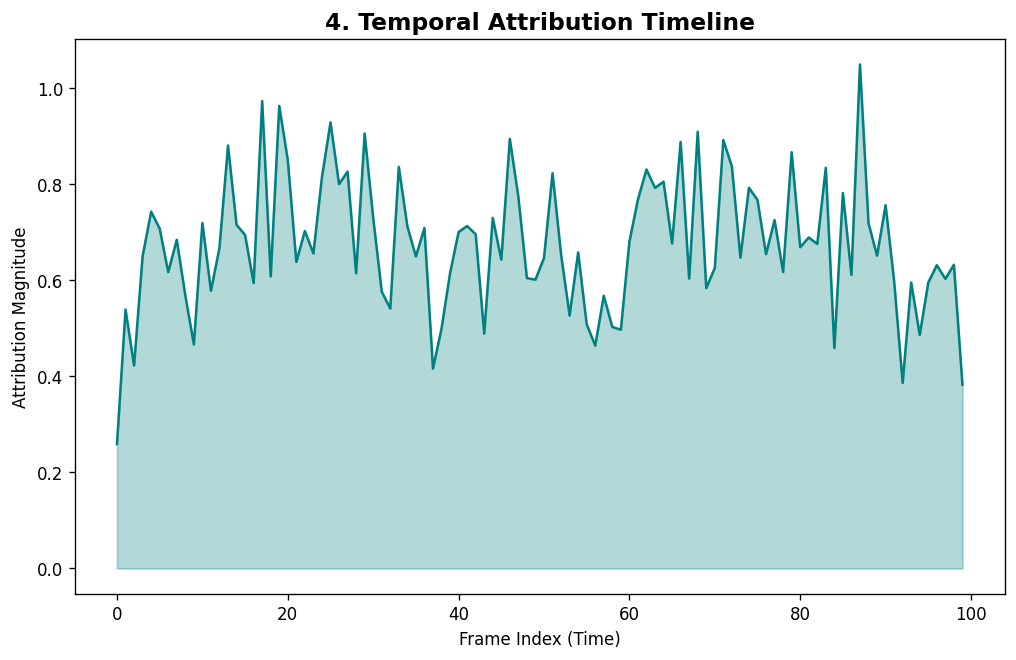


>> Channel Influence (%)


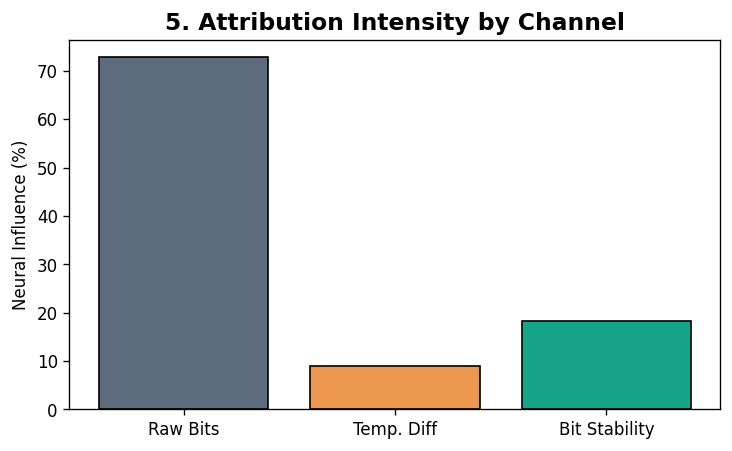


>> Causal Alignment (IG vs Bit-Flip Overlay)


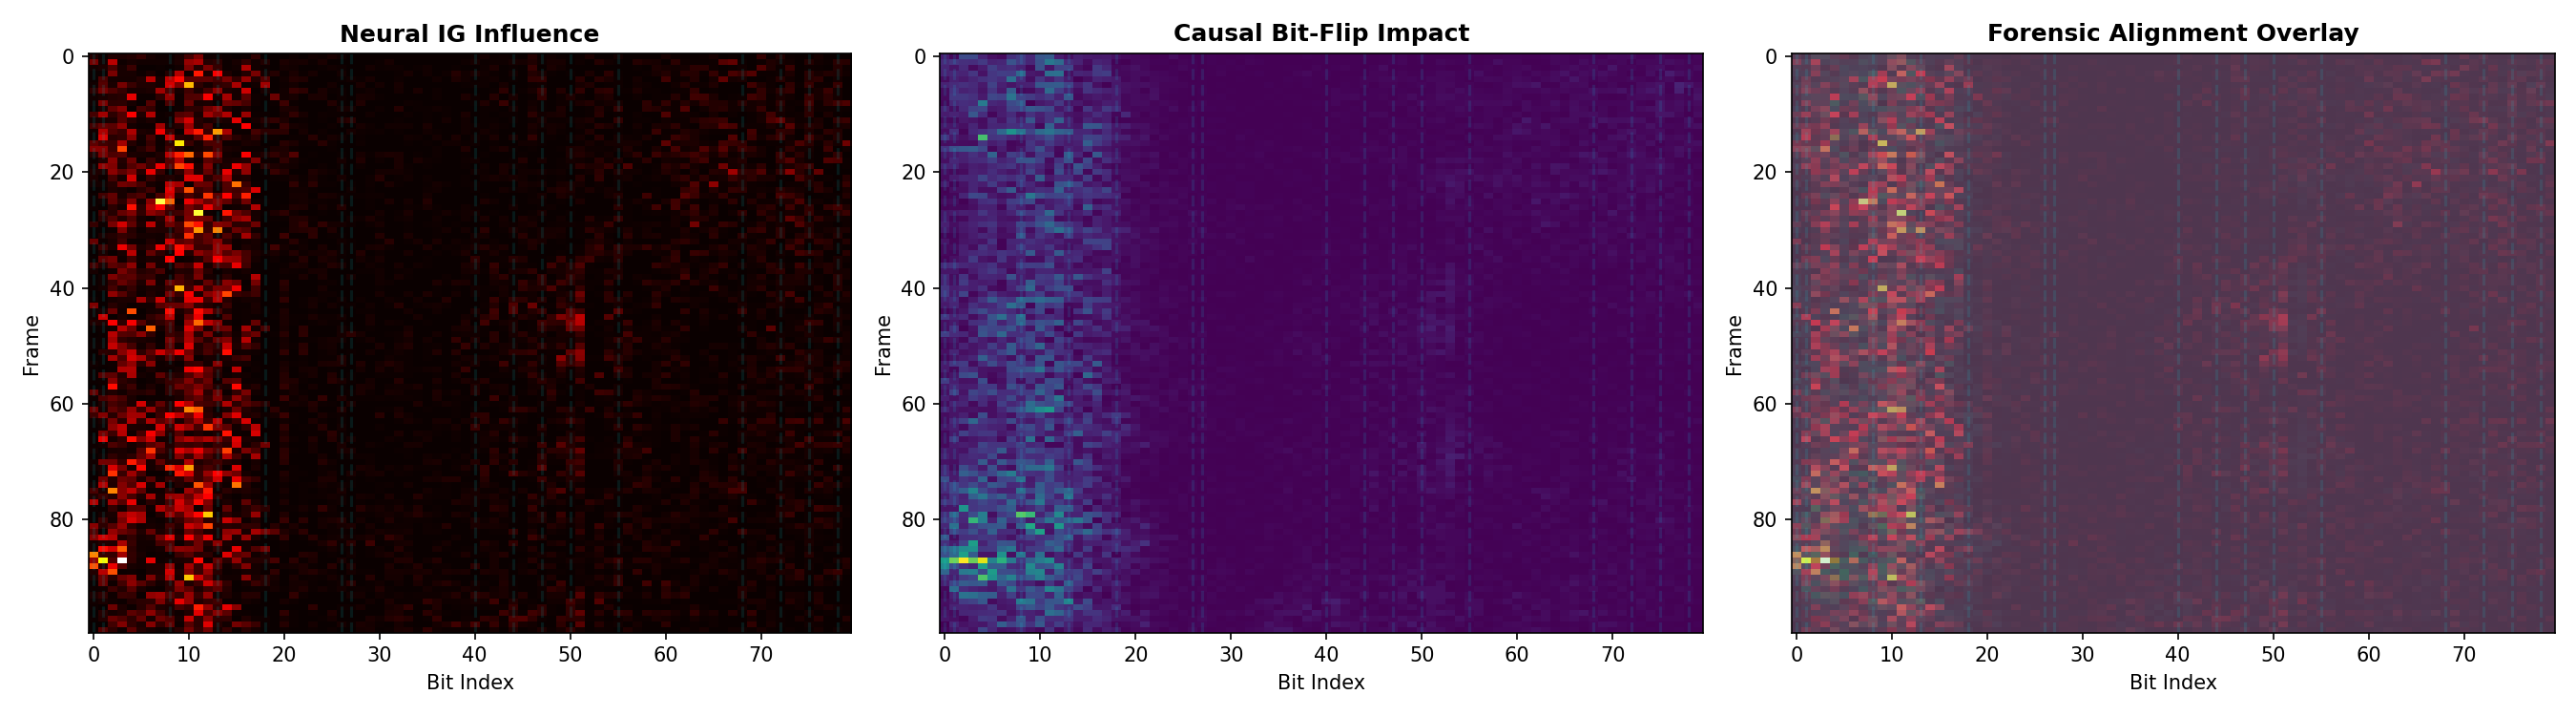


>> Forensic Faithfulness (Deletion/Insertion)


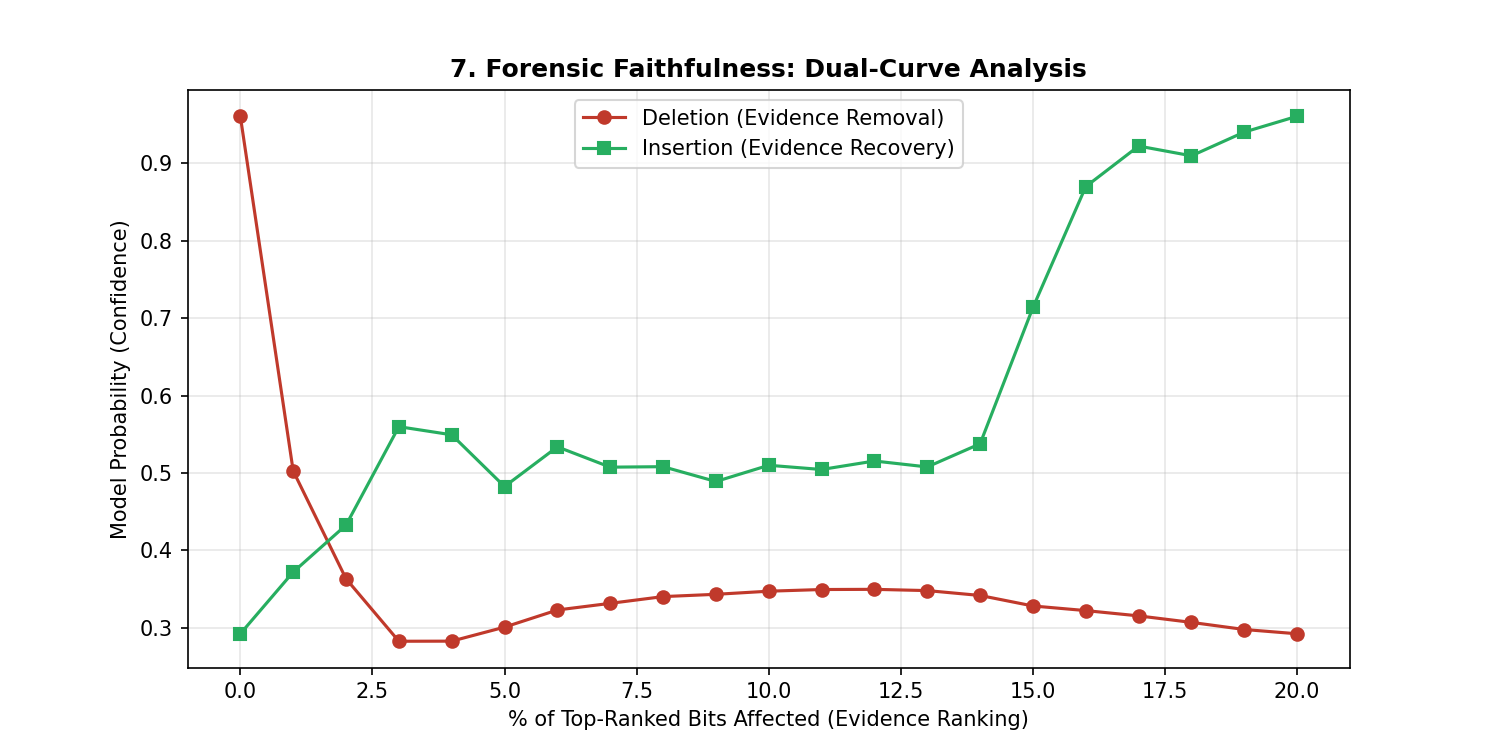

In [ ]:
# ============================================================================
# 5. CONSOLE DASHBOARD & VISUALIZATION (FIXED MAPPING)
# ============================================================================
from IPython.display import display, Image, HTML
import os

def display_forensic_dashboard(reporter, tensor, sample_name, test_file_path):
    print("="*80)
    print(f" AUSPEX FORENSIC DASHBOARD: {sample_name}")
    print("="*80)

    # 1. Re-run analysis for console output
    input_t = tensor.clone().requires_grad_(True)
    with torch.no_grad():
        logits, _ = reporter.model(input_t)
        prob = torch.sigmoid(logits).item()

    # Generate fresh attributes and bit-flip map
    attr = reporter.ig.attribute(input_t, target=0, n_steps=50).squeeze(0).cpu().detach().numpy()
    bit_flip_map = reporter._compute_bit_flip_impact(tensor)

    # Verdict Styling
    if prob > (reporter.threshold + 0.1):
        status, color = "HIGH RISK / COMPROMISED", "\033[91m" # Red
    elif prob > reporter.threshold:
        status, color = "SUSPICIOUS", "\033[93m" # Yellow
    else:
        status, color = "LIKELY CLEAN", "\033[92m" # Green

    # 2. Print Rigor Metrics
    correlation, _ = spearmanr(np.abs(attr).flatten(), bit_flip_map.flatten())
    stability = reporter._test_robustness(tensor, attr)
    codec_findings = reporter._get_codec_interpretation(attr)

    print(f"\n[+] FIELD VERDICT: {color}{status}\033[0m")
    print(f"[+] NEURAL PROBABILITY: {prob:.4f}")
    print(f"[+] FAITHFULNESS (IG vs Bit-Flip): {correlation:.4f}")
    print(f"[+] EXPLANATION STABILITY: {stability:.4f}")
    print("-" * 40)

    print("\n[+] TOP CODEC PARAMETER VULNERABILITIES:")
    for param, importance in codec_findings[:5]:
        # Scale bar for visibility
        bar_len = int(importance * 1000)
        bar = "█" * min(bar_len, 30)
        print(f"    {param.ljust(20)}: {importance:.6f} {bar}")

    # 3. Generate and Display Visuals
    print("\n[+] GENERATING FORENSIC VISUALS...")
    img_paths = reporter._create_rigorous_plots(tensor.squeeze(0), attr, bit_flip_map)

    # Correct Mapping based on  _create_rigorous_plots logic:
    # v1 (index 0): Raw vs Residual (Combined)
    # v2 (index 1): (This was skipped/redundant in plot logic)
    # v3 (index 2): Neural Decision Focus
    # v4 (index 3): Temporal Attribution
    # v5 (index 4): Channel Influence
    # v6 (index 5): Causal Alignment
    # v7 (index 6): Faithfulness Curves

    display_labels = [
        ("Raw Bitstream vs. Forensic Residuals", img_paths[0]),
        ("Neural Decision Focus (XAI Heatmap)", img_paths[2]),
        ("Temporal Attribution Timeline", img_paths[3]),
        ("Channel Influence (%)", img_paths[4]),
        ("Causal Alignment (IG vs Bit-Flip Overlay)", img_paths[5]),
        ("Forensic Faithfulness (Deletion/Insertion)", img_paths[6])
    ]

    for label, path in display_labels:
        if os.path.exists(path):
            print(f"\n>> {label}")
            display(Image(filename=path))
        else:
            print(f"\n[!] Warning: {path} not found for '{label}'")

# Execution
if 'reporter' in locals() and 'tensor' in locals():
    display_forensic_dashboard(reporter, tensor, os.path.basename(TEST_FILE), TEST_FILE)
else:
    print("Error: Reporter or Tensor not found. Please run the previous cell first.")